In [1]:
# --- Map cleaned_metadata.csv -> dummy A-IEOF schema (with originals + reversible maps) ---

# ====== USER SETTINGS ======
SRC_CSV    = "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/merged_meta_data.csv"
IMAGES_ROOT= "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/images"  # used if COPY_MODE != "none"
OUT_DIR    = "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/"
COPY_MODE  = "none"                  # "none" | "copy" | "symlink"
LIMIT      = None                    # e.g., 500 for a quick dry-run

# ====== Imports ======
from pathlib import Path
from IPython.display import display
import os, shutil, hashlib, json
import numpy as np
import pandas as pd

# ====== Helpers ======
def md5_int(s: str) -> int:
    return int(hashlib.md5(s.encode("utf-8")).hexdigest(), 16)

def pick_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def safe_basename(p): 
    return os.path.basename(str(p))

# def to_label(row):
#     # prefer y_true, fallback to label; coerce to {0,1}
#     for k in ("y_true","label"):
#         if k in row and pd.notna(row[k]):
#             return int(1 if float(row[k]) >= 1 else 0)
#     return 0

def to_label(row):
    d = str(row.get("Diagnosis", "")).strip().lower()
    if d in {"covid-19", "covid19", "covid 19", "covid", "sars-cov-2","COVID-19"}:
        return 1
    if d in {"normal","Normal"}:
        return 0
    # anything else (e.g., other diagnoses) → leave unlabeled so we can drop explicitly
    return np.nan

def to_protected(row):
    # protected: 1=male, 0=female
    if "Gender_encoded" in row and pd.notna(row["Gender_encoded"]):
        return int(row["Gender_encoded"])
    g = str(row.get("Gender","")).strip().lower()
    if g in ("male","m","1"): return 1
    if g in ("female","f","0"): return 0
    return 0

def to_age(row):
    for k in ("Age","age"):
        if k in row and pd.notna(row[k]):
            try:
                return float(row[k])
            except Exception:
                return np.nan
    return np.nan

def encode_category(series):
    """Stable factorization + forward/inverse dicts."""
    s = series.astype("string").fillna("__NA__")
    uniques = sorted(s.unique())
    fwd = {v:i for i,v in enumerate(uniques)}
    inv = {i:v for v,i in fwd.items()}
    codes = s.map(fwd).astype(int)
    return codes, fwd, inv

def zscore(x: pd.Series):
    mean = x.mean(skipna=True)
    std = x.std(skipna=True)
    if not np.isfinite(std) or std == 0: std = 1.0
    return (x - mean) / std, float(mean), float(std)

def to_views(df, fname_series):
    # Prefer explicit AP/PA column; otherwise synthesize 50/50 by filename
    if "ViewPosition" in df.columns:
        vp = df["ViewPosition"].astype(str).str.upper().str.strip()
        view_ap = (vp == "AP").astype(float)
        view_pa = (vp == "PA").astype(float)
        mask = ~vp.isin(["AP","PA"])
        if mask.any():
            synth = fname_series[mask].apply(lambda s: md5_int(s) % 2).astype(float)
            view_ap.loc[mask] = synth
            view_pa.loc[mask] = 1.0 - synth
    else:
        view_ap = fname_series.apply(lambda s: md5_int(s) % 2).astype(float)
        view_pa = 1.0 - view_ap
    return view_ap, view_pa

def place_image(src_root: Path, name: str, dst_dir: Path, mode: str):
    if mode == "none": return True, None
    src = src_root / name
    dst = dst_dir / name
    if not src.exists(): return False, f"missing: {src}"
    dst.parent.mkdir(parents=True, exist_ok=True)
    if mode == "copy":
        shutil.copy2(src, dst)
    elif mode == "symlink":
        try:
            if dst.exists() or dst.is_symlink(): dst.unlink()
            dst.symlink_to(src)
        except OSError:
            shutil.copy2(src, dst)
    return True, None

# ====== Main ======
out_dir = Path(OUT_DIR); img_out_dir = out_dir/"images"
out_dir.mkdir(parents=True, exist_ok=True)
if COPY_MODE != "none":
    if not IMAGES_ROOT: raise SystemExit("-- IMAGES_ROOT must be set when COPY_MODE != 'none'")
    src_images_root = Path(IMAGES_ROOT)
    if not src_images_root.exists(): raise SystemExit(f"Images root not found: {src_images_root}")
    img_out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SRC_CSV)
if LIMIT: df = df.head(LIMIT).copy()

# Image names (try several common headers)
img_col = pick_first_col(df, ["File name","filename","image_path","filepath","path","Image","ImageID","Image_Name"])
if not img_col:
    raise SystemExit("Could not find image/path column (tried common name variants).")
fname = df[img_col].astype(str).map(safe_basename)

# Core fields
label = df.apply(to_label, axis=1).astype(int)
protected = df.apply(to_protected, axis=1).astype(int)
sex_male = protected.astype(float)
sex_female = (1 - protected).astype(float)
age = df.apply(to_age, axis=1).astype(float)

# Prep maps/stats containers
maps  = {"Institution": None, "Country": None}
stats = {}

# --- Institution -> codes (+ z-scored continuous) ---
if "Institution" in df.columns:
    inst_codes, inst_fwd, inst_inv = encode_category(df["Institution"])
    maps["Institution"] = {"forward": inst_fwd, "inverse": {str(k):v for k,v in inst_inv.items()}}
    scanner_code = inst_codes.astype(int)
elif "Institution_encoded" in df.columns:
    scanner_code = pd.to_numeric(df["Institution_encoded"], errors="coerce").fillna(-1).astype(int)
else:
    # Surrogate from filename if no institution info
    scanner_code = fname.apply(lambda s: md5_int(s) % 100).astype(int)

scanner_id, m, s = zscore(scanner_code.astype(float))
stats["scanner_code"] = {"mean": m, "std": s}

# --- Country -> codes (+ z-scored continuous) ---
country_col = pick_first_col(df, ["Country","country","COUNTRY"])
if country_col is not None:
    ctry_codes, ctry_fwd, ctry_inv = encode_category(df[country_col])
    maps["Country"] = {"forward": ctry_fwd, "inverse": {str(k):v for k,v in ctry_inv.items()}}
    country_code = ctry_codes.astype(int)
else:
    country_code = pd.Series([-1]*len(df), index=df.index, dtype=int)

country_id, cm, cs = zscore(country_code.astype(float))
stats["country_code"] = {"mean": cm, "std": cs}

# Views
view_ap, view_pa = to_views(df, fname)

# Original raw strings for auditing (if present)
inst_raw  = (df["Institution"] if "Institution" in df.columns else pd.Series([pd.NA]*len(df))).astype("string")
ctry_raw  = (df[country_col] if country_col is not None else pd.Series([pd.NA]*len(df))).astype("string")

col = "Slice"

# ensure numeric (coerce bad values to NaN)
x = pd.to_numeric(df[col], errors="coerce")

# z-score: (x - mean) / std  (population std: ddof=0 to match sklearn)
mu = x.mean(skipna=True)
sigma = x.std(ddof=0, skipna=True)

df[col + "_z"] = (x - mu) / sigma if sigma and np.isfinite(sigma) and sigma > 0 else np.nan

# Final table
out = pd.DataFrame({
    "image_path": fname,
    "label": label,
    "protected": protected,
    "age": age,
    "sex_male": sex_male,
    "sex_female": sex_female,
    "scanner_id": scanner_id.astype(float),     # continuous feature B (z-scored)
    "view_ap": view_ap.astype(float),
    "view_pa": view_pa.astype(float),

    # extras to enable reversibility / analyses
    "scanner_code": scanner_code.astype(int),   # integer code (pre z-score)
    "country_id": country_id.astype(float),     # optional continuous feature (z-scored)
    "country_code": country_code.astype(int),   # integer code (pre z-score)

    # raw strings for auditing (if available)
    "Institution_raw": inst_raw,
    "Country_raw": ctry_raw,
    "Slice": list(df[col + "_z"]),
    "Gender": list(df['Gender'])
})



out = out.rename(columns={"scanner_id": "Institution_id"})
out = out.dropna()

print(out.columns)

# Save outputs
csv_out = out_dir/"covid_metadata.csv"
out.to_csv(csv_out, index=False)

with open(out_dir/"label_maps.json","w") as f:
    json.dump(maps, f, indent=2)

with open(out_dir/"numeric_stats.json","w") as f:
    json.dump(stats, f, indent=2)

# Optionally stage images into <OUT_DIR>/images
missing = []; placed = 0
if COPY_MODE != "none":
    for name in out["image_path"]:
        ok, err = place_image(Path(IMAGES_ROOT), name, img_out_dir, COPY_MODE)
        if ok: placed += 1
        else:  missing.append(err)

print(f"✅ Wrote: {csv_out}  (rows={len(out)})")
if COPY_MODE != "none":
    print(f"✅ Images -> {img_out_dir}  (mode={COPY_MODE}, placed={placed})")
    if missing:
        print(f"⚠️ Missing images: {len(missing)} (showing up to 15)")
        for m in missing[:15]:
            print("   -", m)

display(out.head(12))
print("\nCounts:")
print(out['label'].value_counts(dropna=False))
print(out['protected'].value_counts(dropna=False))


print("""
CONFIG.update({
    "CSV_PATH": "dummy_covid_data_2/covid_metadata.csv",
    "IMG_DIR": "dummy_covid_data_2/images",   # or your real image root if COPY_MODE='none'
    "METADATA_COLS": ["age","sex_male","sex_female","scanner_id","country_id","view_ap","view_pa"],
    "B_INDICES": [3],                         # scanner_id as feature B (index based on METADATA_COLS order)
    "B_TYPE": "continuous",
    "PROTECTED_COL": "protected"
})
""")


Index(['image_path', 'label', 'protected', 'age', 'sex_male', 'sex_female',
       'Institution_id', 'view_ap', 'view_pa', 'scanner_code', 'country_id',
       'country_code', 'Institution_raw', 'Country_raw', 'Slice', 'Gender'],
      dtype='object')
✅ Wrote: /home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata.csv  (rows=12652)


,image_path,label,protected,age,sex_male,sex_female,Institution_id,view_ap,view_pa,scanner_code,country_id,country_code,Institution_raw,Country_raw,Slice,Gender
0,6_Rahimzadeh_137covid_patient101_SR_4_IM00006.png,1,0,51.0,0.0,1.0,0.465791,1.0,0.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.997031,F
1,6_Rahimzadeh_137covid_patient101_SR_4_IM00008.png,1,0,51.0,0.0,1.0,0.465791,1.0,0.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.959322,F
2,6_Rahimzadeh_137covid_patient101_SR_4_IM00009.png,1,0,51.0,0.0,1.0,0.465791,1.0,0.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.940468,F
3,6_Rahimzadeh_137covid_patient101_SR_4_IM00010.png,1,0,51.0,0.0,1.0,0.465791,1.0,0.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.921614,F
4,6_Rahimzadeh_137covid_patient101_SR_4_IM00011.png,1,0,51.0,0.0,1.0,0.465791,0.0,1.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.902760,F
5,6_Rahimzadeh_137covid_patient101_SR_4_IM00012.png,1,0,51.0,0.0,1.0,0.465791,0.0,1.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.883906,F
6,6_Rahimzadeh_137covid_patient101_SR_4_IM00013.png,1,0,51.0,0.0,1.0,0.465791,0.0,1.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.865051,F
7,6_Rahimzadeh_137covid_patient101_SR_4_IM00014.png,1,0,51.0,0.0,1.0,0.465791,1.0,0.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.846197,F
8,6_Rahimzadeh_137covid_patient101_SR_4_IM00015.png,1,0,51.0,0.0,1.0,0.465791,1.0,0.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.827343,F
9,6_Rahimzadeh_137covid_patient101_SR_4_IM00016.png,1,0,51.0,0.0,1.0,0.465791,1.0,0.0,4,-0.596163,4,Negin radiology located at Sari,Iran,-0.808489,F



Counts:
label
0    6893
1    5759
Name: count, dtype: int64
protected
1    7859
0    4793
Name: count, dtype: int64

CONFIG.update({
    "CSV_PATH": "dummy_covid_data_2/covid_metadata.csv",
    "IMG_DIR": "dummy_covid_data_2/images",   # or your real image root if COPY_MODE='none'
    "METADATA_COLS": ["age","sex_male","sex_female","scanner_id","country_id","view_ap","view_pa"],
    "B_INDICES": [3],                         # scanner_id as feature B (index based on METADATA_COLS order)
    "B_TYPE": "continuous",
    "PROTECTED_COL": "protected"
})



In [2]:
# =========================
# Label-encode Institution + Country (categorical indices, rare→__OTHER__)
# =========================

MIN_CAT_FREQ = 20  # merge categories with < MIN_CAT_FREQ rows into __OTHER__

def encode_with_other(series: pd.Series, min_freq=20, label="__OTHER__"):
    """Return cleaned string series, integer codes 0..K-1, and forward/inverse maps."""
    s = series.astype("string").fillna("__NA__").str.strip()
    vc = s.value_counts(dropna=False)
    rare = vc[vc < min_freq].index
    s2 = s.mask(s.isin(rare), label)
    # stable factorization
    uniques = sorted(s2.unique())
    fwd = {v:i for i,v in enumerate(uniques)}
    inv = {i:v for v,i in fwd.items()}
    codes = s2.map(fwd).astype(int)
    return s2, codes, fwd, inv

# ---- Prep maps/stats containers ----
maps  = {"Institution": None, "Country": None}
stats = {}

# ---- Institution (label-encoded) ----
if "Institution" in df.columns:
    inst_raw_src = df["Institution"]
elif "Institution_raw" in df.columns:
    inst_raw_src = df["Institution_raw"]
else:
    inst_raw_src = pd.Series([pd.NA]*len(df), index=df.index, dtype="string")

inst_clean, inst_codes, inst_fwd, inst_inv = encode_with_other(inst_raw_src, MIN_CAT_FREQ)
K_inst = int(len(inst_fwd))
maps["Institution"] = {
    "forward": inst_fwd,
    "inverse": {str(k): v for k, v in inst_inv.items()},
    "min_cat_freq": MIN_CAT_FREQ,
}

# Keep an *optional* z-scored numeric for auditing only (not used by the model)
inst_code_float = inst_codes.astype(float)
inst_z, m_sc, s_sc = zscore(inst_code_float)
stats["scanner_code"] = {"mean": m_sc, "std": s_sc}

# ---- Country (label-encoded) ----
if "Country" in df.columns:
    country_raw_src = df["Country"]
elif "Country_raw" in df.columns:
    country_raw_src = df["Country_raw"]
else:
    country_raw_src = pd.Series([pd.NA]*len(df), index=df.index, dtype="string")

ctry_clean, ctry_codes, ctry_fwd, ctry_inv = encode_with_other(country_raw_src, MIN_CAT_FREQ)
K_ctry = int(len(ctry_fwd))
maps["Country"] = {
    "forward": ctry_fwd,
    "inverse": {str(k): v for k, v in ctry_inv.items()},
    "min_cat_freq": MIN_CAT_FREQ,
}

# Optional z-scored numeric for auditing only
ctry_code_float = ctry_codes.astype(float)
ctry_z, cm_sc, cs_sc = zscore(ctry_code_float)
stats["country_code"] = {"mean": cm_sc, "std": cs_sc}

# ---- Views (already available earlier): view_ap, view_pa
# ---- Slice_z already computed to "Slice_z" above

slice_z = df["Slice_z"] if "Slice_z" in df.columns else pd.Series([np.nan]*len(df), index=df.index)
gender_raw = df["Gender"] if "Gender" in df.columns else pd.Series([pd.NA]*len(df), index=df.index)

# -------------------------
# Final table
# -------------------------
out = pd.DataFrame({
    "image_path": fname,
    "label": label,
    "protected": protected,          # 1=male, 0=female
    "age": age,
    "sex_male": protected.astype(float),
    "sex_female": (1 - protected).astype(float),
    "view_ap": view_ap.astype(float),
    "view_pa": view_pa.astype(float),

    # *** NEW categorical indices ***
    "Institution_le": inst_codes.astype(int),
    "Country_le": ctry_codes.astype(int),

    # audit / extras (not used by model unless you add them)
    "Institution_raw": inst_clean.astype("string"),
    "Country_raw": ctry_clean.astype("string"),
    "Institution_code": inst_codes.astype(int),
    "Country_code": ctry_codes.astype(int),
    "Institution_z": inst_z.astype(float),
    "Country_z": ctry_z.astype(float),
    "Slice": slice_z.astype(float),
    "Gender": gender_raw.astype("string"),
})

# Drop rows with missing label only
out = out.dropna(subset=["label"])
out = out.dropna()
print(out.columns)

# Save outputs
csv_out = out_dir/"covid_metadata.csv"
out.to_csv(csv_out, index=False)

with open(out_dir/"label_maps.json","w") as f:
    json.dump(maps, f, indent=2)

with open(out_dir/"numeric_stats.json","w") as f:
    json.dump(stats, f, indent=2)

# Optionally stage images into <OUT_DIR>/images
missing = []; placed = 0
if COPY_MODE != "none":
    for name in out["image_path"]:
        ok, err = place_image(Path(IMAGES_ROOT), name, img_out_dir, COPY_MODE)
        if ok: placed += 1
        else:  missing.append(err)

print(f"✅ Wrote: {csv_out}  (rows={len(out)})")
if COPY_MODE != "none":
    print(f"✅ Images -> {img_out_dir}  (mode={COPY_MODE}, placed={placed})")
    if missing:
        print(f"⚠️ Missing images: {len(missing)} (showing up to 15)")
        for m in missing[:15]:
            print("   -", m)

display(out.head(12))
print("\nCounts:")
print(out['label'].value_counts(dropna=False))
print(out['protected'].value_counts(dropna=False))

# -------------------------
# Suggested A-IEOF config (label-encoded B as an index)
# -------------------------
metadata_cols = [
    "age","sex_male","sex_female",
    "Institution_le",    # <-- categorical index
    "Country_le",        # <-- categorical index (kept as a regular covariate)
    "view_ap","view_pa","Slice"
]

CONFIG_snippet = {
    "CSV_PATH": str(csv_out),
    "IMG_DIR": str(img_out_dir if COPY_MODE != "none" else IMAGES_ROOT),
    "METADATA_COLS": metadata_cols,
    # Make B = Institution_le (single index column)
    "B_INDICES": [metadata_cols.index("Institution_le")],
    "B_TYPE": "categorical_index",      # <- tell trainer this is an integer category, not one-hot
    "B_NUM_CLASSES": K_inst,
    "PROTECTED_COL": "protected"
}

print("\n\n# ---- Paste into your training CONFIG ----")
import pprint; pprint.pprint(CONFIG_snippet, width=120)
print("# ----------------------------------------\n")

Index(['image_path', 'label', 'protected', 'age', 'sex_male', 'sex_female',
       'view_ap', 'view_pa', 'Institution_le', 'Country_le', 'Institution_raw',
       'Country_raw', 'Institution_code', 'Country_code', 'Institution_z',
       'Country_z', 'Slice', 'Gender'],
      dtype='object')
✅ Wrote: /home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata.csv  (rows=12752)


,image_path,label,protected,age,sex_male,sex_female,view_ap,view_pa,Institution_le,Country_le,Institution_raw,Country_raw,Institution_code,Country_code,Institution_z,Country_z,Slice,Gender
0,6_Rahimzadeh_137covid_patient101_SR_4_IM00006.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.997031,F
1,6_Rahimzadeh_137covid_patient101_SR_4_IM00008.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.959322,F
2,6_Rahimzadeh_137covid_patient101_SR_4_IM00009.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.940468,F
3,6_Rahimzadeh_137covid_patient101_SR_4_IM00010.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.921614,F
4,6_Rahimzadeh_137covid_patient101_SR_4_IM00011.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.902760,F
5,6_Rahimzadeh_137covid_patient101_SR_4_IM00012.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.883906,F
6,6_Rahimzadeh_137covid_patient101_SR_4_IM00013.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.865051,F
7,6_Rahimzadeh_137covid_patient101_SR_4_IM00014.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.846197,F
8,6_Rahimzadeh_137covid_patient101_SR_4_IM00015.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.827343,F
9,6_Rahimzadeh_137covid_patient101_SR_4_IM00016.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.808489,F



Counts:
label
0    6893
1    5859
Name: count, dtype: int64
protected
1    7925
0    4827
Name: count, dtype: int64


# ---- Paste into your training CONFIG ----
{'B_INDICES': [3],
 'B_NUM_CLASSES': 11,
 'B_TYPE': 'categorical_index',
 'CSV_PATH': '/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata.csv',
 'IMG_DIR': '/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/images',
 'METADATA_COLS': ['age', 'sex_male', 'sex_female', 'Institution_le', 'Country_le', 'view_ap', 'view_pa', 'Slice'],
 'PROTECTED_COL': 'protected'}
# ----------------------------------------



In [3]:
def audit_and_filter_images(df, cfg):
    col = cfg["IMAGE_COL"]

    # 1) normalize filenames
    df[col] = (
        df[col].astype(str)
              .str.replace("\xa0", " ", regex=False)  # collapse NBSP
              .str.replace("\\\\", os.sep, regex=False)  # windows -> os.sep
              .str.replace("/", os.sep, regex=False)
              .str.strip()
    )

    # 2) build absolute paths
    is_abs = df[col].str.startswith(os.sep) | df[col].str.match(r"^[A-Za-z]:[\\/]", na=False)
    abs_path = df[col].copy()
    abs_path.loc[~is_abs] = abs_path.loc[~is_abs].apply(lambda p: os.path.join(cfg["IMG_DIR"], p))
    abs_path = abs_path.apply(os.path.normpath)
    df["abs_path"] = abs_path

    # 3) keep only existing files
    exists = df["abs_path"].apply(os.path.isfile)
    n_total = len(df); n_ok = int(exists.sum()); n_miss = int((~exists).sum())
    print(f"[audit] images: total={n_total} | present={n_ok} | missing={n_miss}")
    if n_miss:
        print("  (showing a few missing):")
        print(df.loc[~exists, "abs_path"].head(10).to_string(index=False))

    df = df.loc[exists].reset_index(drop=True)

    # 4) ensure label is binary {0,1}
    lbl = cfg["LABEL_COL"]
    if lbl in df.columns:
        df[lbl] = pd.to_numeric(df[lbl], errors="coerce").fillna(0).clip(0, 1).astype(int)

    return df
CONFIG = {
    "CSV_PATH": "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata.csv",
    "IMG_DIR":  "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/images",
    "IMAGE_SIZE": (224, 224),
    "BATCH_SIZE": 32,
    "EPOCHS_TEACHER": 2,
    "EPOCHS_STUDENT": 5,
    "LR": 3e-5,
    "CLIPNORM": 1.0,
    "VAL_SPLIT": 0.20,
    "TEST_SPLIT": 0.20,
    # Columns
    "IMAGE_COL": "image_path",
    "LABEL_COL": "label",
    "PROTECTED_COL": "protected",   # <- we will build this (multi-group)
    # Metadata (includes B)
    "METADATA_COLS": ["age", "sex_male", "sex_female", "Institution_id", "country_id"],
    "B_INDICES": [3],               # B = Institution_id (continuous)
    "B_TYPE": "continuous",
    "B_NUM_CLASSES": None,
    # A-IEOF hyperparams
    "LAMBDA_DISTILL": 1.5,          # protect utility
    "LAMBDA_INTERV": 0.10,          # fairness pressure (tune 0.2–0.5)
    # Data
    "AUGMENT": False,
    "SEED": 42,
    # Backbone control
    "BACKBONE_WEIGHTS": "imagenet",
    "BACKBONE_TRAIN_TEACHER": False,
    "BACKBONE_TRAIN_STUDENT": True,
    # Adversary g control
    "G_UPDATE_PERIOD": 5,
    "G_LR_MULT": 0.25,
    # Fairness controls (multi-group)
    "EO_WPOS": 2.0,                 # weight on TPR gaps (equal opportunity focus)
    "EO_WNEG": 1.0,                 # weight on FPR gaps
    "EO_AGG": "max",                # "max" or "mean" over pairwise group gaps
#     "MIN_GROUP_COUNT": 8,           # min examples per slice to count in batch
    # Threshold search (validation)
    "MIN_POS_RATE": 0.2,
    "MAX_POS_RATE": 0.8,
    # Early stopping score = AUC - ALPHA*EO
    "ALPHA": 0.7,
    "PATIENCE": 4,
    "LR_DECAY": 0.5,
    "MIN_LR": 1e-6,
    # Checkpoints
    "CKPT_DIR": "checkpoints_A-IEOF_tf",
    "MULTI_GROUP": True,
    "EO_W_POS": 1.0,       # weight on TPR spread
    "EO_W_NEG": 2.0,       # weight on FPR spread
    "STABILITY_W": 0.05,   # weight on counterfactual stability
    "BACKBONE": "mobilenetv2",   # "mobilenetv2" | "resnet50" | "efficientnetb0"
    "BACKBONE_WEIGHTS": None, # avoid pretrain weight loaders touching vendor kernels
#     "MULTI_GROUP": True,        # you’re using 17 groups
    "FAIR_MIN_COUNT": 1,        # per-group min positives/negatives to consider
    "FAIR_W_POS": 1.0,          # weight on TPR gap
    "FAIR_W_NEG": 2.5,          # weight on FPR gap
    "THR_SPAN": 0.15,
#     "MIN_POS_RATE": 0.15,
#     "MAX_POS_RATE": 0.85,
    "MIN_GROUP_COUNT": 5,
    "MIN_POSNEG": 1, 
    "MIN_POS_RATE": 0.10,     # global pos-rate window for threshold search
    "MAX_POS_RATE": 0.90,
    "THR_GRID": 401,          # denser sweep
    "THR_RANGE": (0.02, 0.98)
}

In [4]:
# --- Protected-group construction (coarse for training; full for reporting) ---

CANON_COUNTRY = {
    "islamic republic of iran": "Iran",
    "iran": "Iran",
    "iran, islamic republic of": "Iran",
    "russian federation": "Russia",
    "russia": "Russia",
    "ukraine": "Ukraine",
    "turkiye": "Turkey",
    "turkey": "Turkey",
    "italy": "Italy",
    "belgium": "Belgium",
    "-": "UNK", "": "UNK", "none": "UNK", "unknown": "UNK", "nan": "UNK"
}
def _norm_country(x: str) -> str:
    x = str(x).strip().lower()
    return CANON_COUNTRY.get(x, x.title() if x else "UNK")

# def _age_band(a):
#     try:
#         a = float(a)
#     except Exception:
#         return "A?"
#     if a < 40:   return "A<40"
#     if a < 60:   return "A40-60"
#     return "A60+"
def _age_band(a):
    try:
        a = float(a)
    except Exception:
        return "A?"
    if a < 40:   return "A<40"
    #if a < 60:   return "A40-60"
    return "A40+"
def make_protected(
    df,
    min_group=200,
    keep_countries=("Iran", "Russia"),
    train_uses=("sex","country"),      # which axes to use for S during training
):
    import numpy as np
    import pandas as pd

    # --- build base fields ---
    # sex
    if "Gender" in df.columns:
        sex = df["Gender"].astype(str).str.lower().str[0].map({"f":"f","m":"m"}).fillna("u")
    elif {"sex_male","sex_female"} <= set(df.columns):
        sex = np.where(df["sex_male"].fillna(0).astype(float) > 0.5, "m",
               np.where(df["sex_female"].fillna(0).astype(float) > 0.5, "f", "u"))
        sex = pd.Series(sex, index=df.index)
    else:
        sex = pd.Series(["u"]*len(df), index=df.index)

    # country (raw + coarse)
    ctry_raw = df["Country_raw"].fillna("UNK").astype(str) if "Country_raw" in df.columns \
               else pd.Series(["UNK"]*len(df), index=df.index)
    if keep_countries is None:
        keep_countries = ()
    ctry_coarse = np.where(ctry_raw.isin(keep_countries), ctry_raw, "Other")

    # age bands
    if "age" in df.columns:
#         age = pd.cut(df["age"].astype(float), bins=[-1,40,60,200],
#                      labels=["A<40","A40-60","A60+"], include_lowest=True)
        age = pd.cut(df["age"].astype(float), bins=[-1,40,100],
                     labels=["A<40","A40+"], include_lowest=True)
    else:
        age = pd.Series(["A?" ]*len(df), index=df.index)

    # --- full (reporting) key ---
    key_report = sex.astype(str).str.cat(ctry_raw.astype(str), sep="·").str.cat(age.astype(str), sep="·")
    cat_rep = pd.Categorical(key_report)
    df["protected_report"] = cat_rep.codes.astype(int)
    prot_map_report = dict(enumerate(cat_rep.categories.tolist()))

    # --- training key (coarser / balanced) ---
    parts = []
    if "sex"     in train_uses: parts.append(sex.astype(str))
    if "country" in train_uses: parts.append(pd.Series(ctry_coarse, index=df.index).astype(str))
    if "age"     in train_uses: parts.append(age.astype(str))

    if not parts:
        key_train = pd.Series(["All"]*len(df), index=df.index)
    else:
        key_train = parts[0]
        for s in parts[1:]:
            key_train = key_train.str.cat(s, sep="·")

    # collapse rare groups (counted globally before split)
    counts = key_train.value_counts()
    rare = counts[counts < min_group].index
    key_train_collapsed = key_train.where(~key_train.isin(rare), other="Other")

    cat_train = pd.Categorical(key_train_collapsed)
    df["protected"] = cat_train.codes.astype(int)
    prot_map_train = dict(enumerate(cat_train.categories.tolist()))

    return df, prot_map_train, prot_map_report
df = out
df, PROT_MAP_TRAIN, PROT_MAP_REPORT_ = make_protected(
    df,
    min_group=300,                      # collapse groups with <200 rows into "Other"
    keep_countries=("Iran", "Russia"),  # treat other countries as "Other"
    train_uses=("sex","age")        # use these axes for training S; add "age" later if stable
)
display(df.head(10))
df = audit_and_filter_images(df, CONFIG) 
print(PROT_MAP_TRAIN)
print(PROT_MAP_REPORT_)
print(df['protected'].value_counts())

df = audit_and_filter_images(df, CONFIG) 
with open(os.path.join(CONFIG["CKPT_DIR"], "protected_map.json"), "w") as f:
        json.dump(PROT_MAP_TRAIN, f, indent=2)
n_groups = int(df[CONFIG["PROTECTED_COL"]].nunique())
CONFIG["MULTI_GROUP"] = CONFIG.get("MULTI_GROUP", n_groups > 2)
print(f"[run] Protected groups: K={n_groups} | MULTI_GROUP={CONFIG['MULTI_GROUP']}")

,image_path,label,protected,age,sex_male,sex_female,view_ap,view_pa,Institution_le,Country_le,Institution_raw,Country_raw,Institution_code,Country_code,Institution_z,Country_z,Slice,Gender,protected_report
0,6_Rahimzadeh_137covid_patient101_SR_4_IM00006.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.997031,F,1
1,6_Rahimzadeh_137covid_patient101_SR_4_IM00008.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.959322,F,1
2,6_Rahimzadeh_137covid_patient101_SR_4_IM00009.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.940468,F,1
3,6_Rahimzadeh_137covid_patient101_SR_4_IM00010.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.921614,F,1
4,6_Rahimzadeh_137covid_patient101_SR_4_IM00011.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.902760,F,1
5,6_Rahimzadeh_137covid_patient101_SR_4_IM00012.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.883906,F,1
6,6_Rahimzadeh_137covid_patient101_SR_4_IM00013.png,1,0,51.0,0.0,1.0,0.0,1.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.865051,F,1
7,6_Rahimzadeh_137covid_patient101_SR_4_IM00014.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.846197,F,1
8,6_Rahimzadeh_137covid_patient101_SR_4_IM00015.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.827343,F,1
9,6_Rahimzadeh_137covid_patient101_SR_4_IM00016.png,1,0,51.0,0.0,1.0,1.0,0.0,6,3,Negin radiology located at Sari,Iran,6,3,0.621467,-0.574334,-0.808489,F,1


[audit] images: total=12752 | present=12281 | missing=471
  (showing a few missing):
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
/home/rkannan/Desktop/2025 Projects/Fairness/fa...
{0: 'f·A40+', 1: 'f·A<40', 2: 'm·A40+', 3: 'm·A<40'}
{0: 'f·Belgium·A<40', 1: 'f·Iran·A40+', 2: 'f·Iran·A<40', 3: 'f·Italy·A40+', 4: 'f·Italy·A<40', 5: 'f·Russia·A40+', 6: 'f·Russia·A<40', 7: 'm·-·A40+', 8: 'm·Iran·A40+', 9: 'm·Iran·A<40', 10: 'm·Italy·A40+', 11: 'm·Italy·A<40', 12: 'm·Russia·A40+', 13: 'm·Russia·A<40', 14: 'm·Turkey·A40+', 15: 'm·Ukraine·A<40'}
protected
2    5123
0    3127
3    2506


In [5]:
df['Institution_le'].unique()

array([ 6, 10,  4,  1,  7,  3,  2,  8,  5,  0])

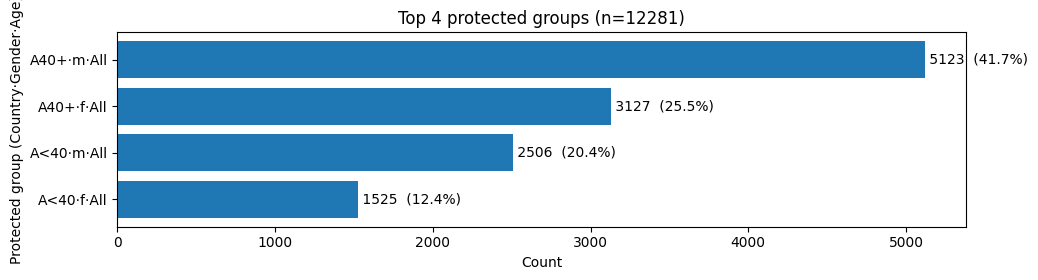

,S_key,count,pct
0,A40+·m·All,5123,0.417148
1,A40+·f·All,3127,0.254621
2,A<40·m·All,2506,0.204055
3,A<40·f·All,1525,0.124176


In [6]:
# =========================
# TRAINING-GROUP VIS TOOLS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- decode training key -> facets ----------
def attach_training_facets(df, prot_map_train, prot_col="protected", expand_other=True):
    """
    Returns a copy with columns:
      S_label   : string label from PROT_MAP_TRAIN
      S_country : 'Iran' / 'Russia' / 'Other' / ...
      S_gender  : 'f','m', or 'All'
      S_age     : 'A<40','A40-60','A60+', or 'All'
      S_ga      : 'f×A40-60', etc. (Gender×Age)
      S_key     : country · gender · age  (what the model trains on)
    """
    dfS = df.copy()

    # decode integer code -> string label
    lab = dfS[prot_col].map(prot_map_train).astype(str).fillna("Other")

    S_country = []
    S_gender  = []
    S_age     = []
    for s in lab:
        if s == "Other":
            # collapsed bucket: keep only country='Other'
            S_country.append("Other")
            S_gender.append("All")
            S_age.append("All")
            continue

        parts = s.split("·")
        if len(parts) == 3:
            g, c, a = parts
            S_country.append(c)
            S_gender.append(g)
            S_age.append(a)
        elif len(parts) == 2:
            g, c = parts
            S_country.append(c)
            S_gender.append(g)
            S_age.append("All")
        else:
            # extremely defensive fallback
            S_country.append(parts[-1] if parts else "Other")
            S_gender.append("All")
            S_age.append("All")

    dfS["S_label"]   = lab
    dfS["S_country"] = pd.Series(S_country, index=dfS.index)
    dfS["S_gender"]  = pd.Series(S_gender,  index=dfS.index)
    dfS["S_age"]     = pd.Series(S_age,     index=dfS.index)

    # Gender×Age label
    dfS["S_ga"] = dfS["S_gender"].astype(str) + "×" + dfS["S_age"].astype(str)

    # unified training key the model actually sees
    dfS["S_key"] = (
        dfS["S_country"].astype(str) + "·" +
        dfS["S_gender"].astype(str)  + "·" +
        dfS["S_age"].astype(str)
    )

    return dfS


# consistent GA ordering for nice plots
GA_ORDER = ["f×A<40","f×A40-60","f×A60+","m×A<40","m×A40-60","m×A60+","All×All"]


# ---------- (A) single stacked chart, clean ----------
def plot_training_country_stacked_clean(
    dfS,
    normalize=True,
    min_count=30,
    drop_allall=True,
    show_pct=False,
    title="Country × (Gender×Age) — training groups"
):
    ga = dfS["S_ga"]
    ct = pd.crosstab(dfS["S_country"], ga)
    if ct.empty:
        print("No data."); return

    # keep GA columns in consistent order
    cols = [c for c in GA_ORDER if c in ct.columns]
    if drop_allall:
        cols = [c for c in cols if c != "All×All"]
    ct = ct[cols]

    # filter countries with enough support (fallback to all if empty)
    big = ct[ct.sum(axis=1) >= min_count]
    if big.empty: big = ct

    # sort countries by support
    big = big.loc[big.sum(axis=1).sort_values(ascending=False).index]

    plot_df = big.div(big.sum(axis=1), axis=0) if normalize else big
    ylabel  = "Within-country share" if normalize else "Count"

    ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_xlabel("Country (training)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if show_pct and normalize:
        for p in ax.patches:
            if p.get_height() < 0.06:  # avoid clutter: annotate bigger slices
                continue
            x = p.get_x() + p.get_width()/2
            y = p.get_y() + p.get_height()/2
            ax.text(x, y, f"{p.get_height():.0%}", ha="center", va="center", fontsize=8, rotation=0)

    ax.legend(title="Gender×Age", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout(); plt.show()


# ---------- (B) small-multiples grid: one panel per country ----------
def plot_training_country_grid(
    dfS,
    top_countries=9,
    normalize=True,
    drop_allall=True,
    height=2.8,
    width=3.6
):
    ga = dfS["S_ga"]
    ct = pd.crosstab(dfS["S_country"], ga)
    if ct.empty:
        print("No data."); return

    GA_ORDER = ["f×A<40","f×A40-60","f×A60+","m×A<40","m×A40-60","m×A60+","All×All"]
    cols = [c for c in GA_ORDER if c in ct.columns]
    if drop_allall:
        cols = [c for c in cols if c != "All×All"]
    ct = ct[cols]

    top_idx = ct.sum(axis=1).nlargest(top_countries).index
    ct = ct.loc[top_idx]

    n = len(ct)
    ncols = min(3, n) if n else 1
    nrows = int(np.ceil(max(n,1) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width*ncols, height*nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (country, row) in enumerate(ct.iterrows()):
        ax = axes[i]
        series = row / row.sum() if normalize and row.sum() > 0 else row
        series.index = pd.Categorical(series.index, categories=cols, ordered=True)
        series = series.sort_index()

        ax.bar(series.index.astype(str), series.values)
        ax.set_title(f"{country}  (n={int(row.sum())})", fontsize=10)
        ax.tick_params(axis='x', rotation=60)
        ax.set_ylim(0, 1 if normalize else (series.max()*1.1 if len(series) else 1))

        # old-mpl friendly: leftmost column has ylabel
        col_idx = i % ncols
        if col_idx == 0:
            ax.set_ylabel("share" if normalize else "count")

    # hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    fig.suptitle("Gender×Age composition per country (training groups)", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()

# ---------- (C) quick table: what S the model actually sees ----------
def training_group_table(dfS, top=25):
    vc = dfS["S_key"].value_counts().rename_axis("S_key").reset_index(name="count")
    vc["pct"] = vc["count"] / vc["count"].sum()
    return vc.head(top)

def plot_top_protected_groups(summary_df, key_col="S_key", count_col="count", pct_col="pct",
                              top_n=20, title=None, annotate=True):
    """
    Horizontal bar chart of top-N protected groups with counts and percentages.
    Expects a DataFrame with at least columns: key_col, count_col, pct_col.
    """
    df = summary_df[[key_col, count_col, pct_col]].dropna().copy()
    df = df.sort_values(count_col, ascending=False).head(top_n)
    df = df.iloc[::-1]  # show largest at top in horizontal bar

    fig_h = max(2.5, 0.35 * len(df) + 1.5)
    fig, ax = plt.subplots(figsize=(10.5, fig_h))
    ax.barh(df[key_col], df[count_col])
    if annotate:
        for i, (cnt, pct) in enumerate(zip(df[count_col], df[pct_col])):
            ax.text(cnt, i, f" {int(cnt)}  ({pct:.1%})", va="center")
    ax.set_xlabel("Count")
    ax.set_ylabel("Protected group (Country·Gender·Age)")
    if title is None:
        total = int(summary_df[count_col].sum())
        title = f"Top {len(df)} protected groups (n={total})"
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_country_share_from_keys(summary_df, key_col="S_key", count_col="count",
                                 normalize=True, drop_other=False, title=None):
    """
    Bar chart aggregating the same summary by Country parsed from key_col.
    key format assumed: 'Country·Gender·Age' (e.g., 'Iran·m·A40-60').
    """
    tmp = summary_df[[key_col, count_col]].copy()
    # Parse country as text up to first '·'
    tmp["Country"] = tmp[key_col].astype(str).str.split("·").str[0]
#     if drop_other:
#         tmp = tmp[tmp["Country"].str.lower() != "other"]
    agg = tmp.groupby("Country", as_index=False)[count_col].sum().sort_values(count_col, ascending=False)
    y = agg[count_col].values.astype(float)
    if normalize and y.sum() > 0:
        y = y / y.sum()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(agg["Country"], y)
    ax.set_xlabel("Country")
    ax.set_ylabel("Share" if normalize else "Count")
    ax.set_title(title or ("Country share from top-groups summary" + (" (normalized)" if normalize else "")))
    for xi, yi in zip(range(len(agg)), y):
        ax.text(xi, yi, f"{yi:.1%}" if normalize else f"{int(yi)}", ha="center", va="bottom", rotation=0)
    plt.tight_layout()
    plt.show()

# 1) attach facets used during training
dfS = attach_training_facets(df, PROT_MAP_TRAIN, prot_col="protected")

# Draw charts
plot_top_protected_groups(training_group_table(dfS, top=30), key_col="S_key", count_col="count", pct_col="pct", top_n=20)
# plot_country_share_from_keys(training_group_table(dfS, top=30), key_col="S_key", count_col="count", normalize=True, drop_other=True)

# 2) see the table of S keys the model uses
display(training_group_table(dfS, top=30))

# # 3) clear stacked chart (per-country composition of training groups)
# plot_training_country_stacked_clean(dfS, normalize=True, min_count=50, drop_allall=True)

# # 4) small multiples (top countries)
# plot_training_country_grid(dfS, top_countries=20, normalize=True, drop_allall=True)


In [7]:
outPath = "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata_with_protected_all.csv"
df.to_csv(outPath, index=False)

In [8]:
# ---- RUN THIS FIRST IN A FRESH KERNEL ----
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"            # hide all GPUs
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"  # no XLA/StreamExecutor
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"            # simpler CPU kernels
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"             # tidy logs

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')             # belt & suspenders
tf.config.optimizer.set_jit(False)                   # no JIT
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# optional: keep everything in float32
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("float32")

print("GPUs visible to TF:", tf.config.list_physical_devices('GPU'))

GPUs visible to TF: []


2025-08-20 17:51:21.016533: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


our Anchored Interventional Equalized-Odds Fairness for Feature Addition (A-IOEF) is a Counterfactual Risk Matching (CRM) approach for addressing fairness. In this code A-IOEF and CRM as used interchangably but same concept.

In [12]:
# A-IEOF_multigroup.py
# =========================
# Multi-group fairness A-IEOF (Teacher/Student + B-interventions + multi-group EO)
# =========================
import os, math, json, random, numpy as np, pandas as pd, tensorflow as tf
from sklearn.metrics import roc_auc_score



# --------------- SEED --------------- #
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(CONFIG["SEED"])

# --------------- DATA UTILS --------------- #
def audit_and_filter_images(df, cfg):
    col = cfg["IMAGE_COL"]
    df[col] = (
        df[col].astype(str)
              .str.replace("\xa0", " ", regex=False)
              .str.replace("\\\\", os.sep, regex=False)
              .str.replace("/", os.sep, regex=False)
              .str.strip()
    )
    is_abs = df[col].str.startswith(os.sep) | df[col].str.match(r"^[A-Za-z]:[\\/]", na=False)
    abs_path = df[col].copy()
    abs_path.loc[~is_abs] = abs_path.loc[~is_abs].apply(lambda p: os.path.join(cfg["IMG_DIR"], p))
    abs_path = abs_path.apply(os.path.normpath)
    df["abs_path"] = abs_path

    exists = df["abs_path"].apply(os.path.isfile)
    n_total = len(df); n_ok = int(exists.sum()); n_miss = int((~exists).sum())
    print(f"[audit] images: total={n_total} | present={n_ok} | missing={n_miss}")
    if n_miss:
        print("  (showing a few missing):")
        print(df.loc[~exists, "abs_path"].head(10).to_string(index=False))

    df = df.loc[exists].reset_index(drop=True)

    lbl = cfg["LABEL_COL"]
    if lbl in df.columns:
        df[lbl] = pd.to_numeric(df[lbl], errors="coerce").fillna(0).clip(0, 1).astype(int)
    return df

def reindex_protected(df, prot_col="protected"):
    if prot_col not in df.columns:
        raise ValueError(f"Protected column '{prot_col}' not found.")
    cat = pd.Categorical(df[prot_col].astype(str))
    df[prot_col] = cat.codes.astype(np.int32)
    prot_map = dict(enumerate(cat.categories.tolist()))
    print(f"[protected] K={len(prot_map)} groups. Sample mapping:", list(prot_map.items())[:5])
    return df, prot_map

def load_dataframe(cfg):
    df = pd.read_csv(cfg["CSV_PATH"])
    # checks
    for col in [cfg["IMAGE_COL"], cfg["LABEL_COL"]]:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    for col in cfg["METADATA_COLS"]:
        if col not in df.columns:
            raise ValueError(f"Missing metadata column: {col}")
    if cfg["PROTECTED_COL"] is not None and cfg["PROTECTED_COL"] not in df.columns:
        raise ValueError(f"Protected column {cfg['PROTECTED_COL']} not found.")
    # images
    df = audit_and_filter_images(df, cfg)
    # protected remap
    if cfg["PROTECTED_COL"] is not None:
        df, prot_map = reindex_protected(df, cfg["PROTECTED_COL"])
        cfg["_PROTECTED_MAP"] = prot_map
    # numeric meta/label
    mcols = cfg["METADATA_COLS"]
    df[mcols] = df[mcols].apply(pd.to_numeric, errors="coerce")
    before = len(df)
    df = df.dropna(subset=mcols + [cfg["LABEL_COL"]]).reset_index(drop=True)
    if len(df) < before:
        print(f"[clean] dropped {before-len(df)} rows with NaN in metadata/label.")
    return df

def make_standardizer(train_df, cfg):
    cols = cfg["METADATA_COLS"]
    mean = train_df[cols].astype(float).mean().values.astype(np.float32)
    std  = train_df[cols].astype(float).std(ddof=0).replace(0, 1.0).values.astype(np.float32)
    return mean, std

def build_dataset(df, mean, std, cfg, shuffle, repeat=False):
    img_col   = "abs_path"
    label_col = cfg["LABEL_COL"]
    prot_col  = cfg["PROTECTED_COL"]
    meta_cols = cfg["METADATA_COLS"]
    B_idx = tf.convert_to_tensor(cfg["B_INDICES"], dtype=tf.int32)
    H, W = cfg["IMAGE_SIZE"]

    paths  = df[img_col].astype(str).values
    labels = df[label_col].astype(np.float32).values
    metas  = df[meta_cols].astype(np.float32).values
    prots  = df[prot_col].astype(np.int32).values if prot_col is not None else np.full((len(df),), -1, np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, metas, labels, prots))

    def _load_image(path_str):
        img_bytes = tf.io.read_file(path_str)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, [H, W])
        return img

    aug = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.02),
        tf.keras.layers.RandomZoom(0.1)
    ]) if cfg["AUGMENT"] else None

    mean_t = tf.constant(mean, dtype=tf.float32)
    std_t  = tf.constant(std,  dtype=tf.float32)

    def _map(path, meta, y, s):
        img = _load_image(path)
        if aug is not None:
            img = aug(img, training=True)
        meta = (meta - mean_t) / std_t
        meta_noB = tf.tensor_scatter_nd_update(
            meta, indices=tf.reshape(B_idx, [-1,1]),
            updates=tf.zeros([tf.shape(B_idx)[0]], dtype=meta.dtype)
        )
        return (img, meta, meta_noB, s), y

    if shuffle:
        ds = ds.shuffle(1024, seed=cfg["SEED"], reshuffle_each_iteration=True)
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    try:
        ds = ds.apply(tf.data.experimental.ignore_errors())
    except Exception:
        pass
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(cfg["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------- MODELS --------------- #
def _tiny_cnn_backbone(image_size, trainable=True):
    H, W = image_size
    inp = tf.keras.Input((H, W, 3))
    x = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(inp)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    m = tf.keras.Model(inp, x, name="tiny_cnn")
    m.trainable = trainable
    return m

def build_backbone(image_size, trainable=False, weights=None):
    H, W = image_size
    name = str((CONFIG.get("BACKBONE") or "mobilenetv2")).lower()
    def _make(Base, w):
        return Base(include_top=False, input_shape=(H, W, 3), pooling="avg", weights=w)
    try:
        if name == "mobilenetv2":
            base = _make(tf.keras.applications.MobileNetV2, weights)
        elif name == "resnet50":
            base = _make(tf.keras.applications.ResNet50, weights)
        else:
            base = _make(tf.keras.applications.EfficientNetB0, weights)
    except Exception as e1:
        print(f"[backbone:{name}] weights={weights} failed ({e1}); retrying with weights=None")
        try:
            if name == "mobilenetv2":
                base = _make(tf.keras.applications.MobileNetV2, None)
            elif name == "resnet50":
                base = _make(tf.keras.applications.ResNet50, None)
            else:
                base = _make(tf.keras.applications.EfficientNetB0, None)
        except Exception as e2:
            print(f"[backbone:{name}] still failed ({e2}); falling back to tiny CNN.")
            base = _tiny_cnn_backbone(image_size, trainable=True)
    base.trainable = trainable
    return base

def build_mlp(units, name=None, dropout=0.0, l2=0.0):
    reg = tf.keras.regularizers.L2(l2) if l2 and l2 > 0 else None
    layers = []
    for u in units:
        layers.append(tf.keras.layers.Dense(u, activation="relu", kernel_regularizer=reg))
        if dropout > 0: layers.append(tf.keras.layers.Dropout(dropout))
    return tf.keras.Sequential(layers, name=name)

def build_teacher(image_size, meta_dim, trainable_backbone=False, backbone_weights="imagenet"):
    img_in  = tf.keras.Input(shape=(*image_size,3), name="image")
    meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_noB")
    backbone = build_backbone(image_size, trainable=trainable_backbone, weights=backbone_weights)
    x_img  = backbone(img_in)
    x_meta = build_mlp([128,64], name="meta_mlp")(meta_in)
    x = tf.keras.layers.Concatenate()([x_img, x_meta])
    x = build_mlp([256,128], name="fusion_mlp", dropout=0.1, l2=1e-5)(x)
    logit = tf.keras.layers.Dense(1, name="logit")(x)
    return tf.keras.Model([img_in, meta_in], logit, name="teacher_noB")

def build_student(image_size, meta_dim, trainable_backbone=False, backbone_weights="imagenet"):
    img_in  = tf.keras.Input(shape=(*image_size,3), name="image")
    meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_full")
    backbone = build_backbone(image_size, trainable=trainable_backbone, weights=backbone_weights)
    x_img  = backbone(img_in)
    x_meta = build_mlp([128,64], name="meta_mlp")(meta_in)
    x = tf.keras.layers.Concatenate()([x_img, x_meta])
    x = build_mlp([256,128], name="fusion_mlp", dropout=0.1, l2=1e-5)(x)
    logit = tf.keras.layers.Dense(1, name="logit")(x)
    return tf.keras.Model([img_in, meta_in], logit, name="student_withB")

def build_g(meta_dim, B_type, num_classes=None, B_dim=1):
    meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_noB")
    h = build_mlp([64,64], name="g_mlp")(meta_in)
    if B_type == "continuous":
        mu     = tf.keras.layers.Dense(B_dim, name="mu")(h)
        logvar = tf.keras.layers.Dense(B_dim, name="logvar")(h)
        out = tf.keras.layers.Concatenate(name="gauss_params")([mu, logvar])
    else:
        K = int(num_classes) if num_classes else B_dim
        out = tf.keras.layers.Dense(K, name="cat_logits")(h)
    return tf.keras.Model(meta_in, out, name="g_generator")

# --------------- UTILS: replace B --------------- #
def replace_B_in_meta(meta_full, B_indices, new_B):
    """
    meta_full: [B, D] standardized
    B_indices: list of indices (e.g., [3])
    new_B: [B, len(B_indices)] standardized values to write in
    """
    B_idx = tf.convert_to_tensor(B_indices, dtype=tf.int32)
    batch = tf.shape(meta_full)[0]
    k     = tf.shape(B_idx)[0]
    batch_idx = tf.repeat(tf.range(batch), repeats=k)   # [B*k]
    feat_idx  = tf.tile(B_idx, [batch])                 # [B*k]
    idx = tf.stack([batch_idx, feat_idx], axis=1)       # [B*k, 2]
    updates = tf.reshape(new_B, [-1])                   # [B*k]
    mask   = tf.scatter_nd(idx, tf.ones_like(updates, dtype=meta_full.dtype), tf.shape(meta_full))
    base   = meta_full * (1.0 - mask)
    scatter= tf.scatter_nd(idx, updates, tf.shape(meta_full))
    return base + scatter

# --------------- METRICS --------------- #
class ProbAUC(tf.keras.metrics.AUC):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.math.sigmoid(y_pred)
        return super().update_state(y_true, y_pred, sample_weight)

class ProbAcc(tf.keras.metrics.BinaryAccuracy):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.math.sigmoid(y_pred)
        return super().update_state(y_true, y_pred, sample_weight)

# --------------- FAIRNESS (soft multi-group EO) --------------- #
@tf.function
def eo_gap_soft_multigroup_vec(logits, y_true, s, w_pos=1.0, w_neg=2.0, min_count=1):
    probs = tf.math.sigmoid(tf.reshape(logits, [-1]))
    y  = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    g  = tf.reshape(tf.cast(s, tf.int32),        [-1])
    valid = g >= 0
    probs = tf.boolean_mask(probs, valid)
    y     = tf.boolean_mask(y,     valid)
    g     = tf.boolean_mask(g,     valid)
    unique_g, seg = tf.unique(g)
    m = tf.shape(unique_g)[0]
    eps = tf.constant(1e-6, tf.float32)
    pos = tf.cast(tf.equal(y, 1.0), tf.float32)
    neg = 1.0 - pos
    sum_pos = tf.math.unsorted_segment_sum(probs * pos, seg, m)
    cnt_pos = tf.math.unsorted_segment_sum(pos,        seg, m)
    sum_neg = tf.math.unsorted_segment_sum(probs * neg, seg, m)
    cnt_neg = tf.math.unsorted_segment_sum(neg,        seg, m)
    tpr = sum_pos / tf.maximum(cnt_pos, eps)
    fpr = sum_neg / tf.maximum(cnt_neg, eps)
    vpos = cnt_pos >= tf.cast(min_count, tf.float32)
    vneg = cnt_neg >= tf.cast(min_count, tf.float32)
    NEG_INF = tf.constant(-1e9, tf.float32)
    POS_INF = tf.constant( 1e9, tf.float32)
    tpr_gap = tf.where(tf.reduce_any(vpos),
                       tf.reduce_max(tf.where(vpos, tpr, NEG_INF)) - tf.reduce_min(tf.where(vpos, tpr, POS_INF)),
                       0.0)
    fpr_gap = tf.where(tf.reduce_any(vneg),
                       tf.reduce_max(tf.where(vneg, fpr, NEG_INF)) - tf.reduce_min(tf.where(vneg, fpr, POS_INF)),
                       0.0)
    return w_pos * tpr_gap + w_neg * fpr_gap


def sample_B_from_g(g, meta_noB_batch, cfg):
    """
    - continuous: returns two Gaussian draws (standardized already by dataset)
    - categorical (single label-encoded B col): Gumbel-Softmax → soft class id → STANDARDIZED scalar
    - categorical (one-hot B block): returns width-K one-hots to fill those K columns
    """
    B_type = cfg.get("B_TYPE", "continuous")
    out = g(meta_noB_batch, training=True)

    if B_type == "continuous":
        mu, logvar = tf.split(out, 2, axis=-1)
        std = tf.math.exp(0.5 * tf.clip_by_value(logvar, -6.0, 2.0))
        e1 = tf.random.normal(tf.shape(std)); e2 = tf.random.normal(tf.shape(std))
        return mu + std*e1, mu + std*e2

    # ----- categorical -----
    K = int(cfg.get("B_NUM_CLASSES", 0))
    if K <= 1:
        raise ValueError("B_NUM_CLASSES must be > 1 when B_TYPE='categorical'.")

    logits = out  # [batch, K]

    def _gumbel_softmax(logits, tau=0.7):
        u = tf.random.uniform(tf.shape(logits), 1e-6, 1.0-1e-6)
        g = -tf.math.log(-tf.math.log(u))
        y = tf.nn.softmax((logits + g)/tau, axis=-1)
        y_hard = tf.one_hot(tf.argmax(y, axis=-1), depth=K)
        return y_hard + tf.stop_gradient(y - y_hard)

    y1 = _gumbel_softmax(logits)
    y2 = _gumbel_softmax(logits)

    B_idx_len = len(cfg.get("B_INDICES", []))

    if B_idx_len == K:
        # You have a K-wide one-hot block in META; splice these directly.
        return y1, y2

    if B_idx_len == 1:
        # You have ONE label-encoded META column for B (e.g., Institution_le).
        # Map one-hot -> soft class id in [0, K-1], then STANDARDIZE using TRAIN B mean/std.
        class_ids = tf.cast(tf.range(K)[tf.newaxis, :], y1.dtype)
        b1_scalar_raw = tf.reduce_sum(y1 * class_ids, axis=-1, keepdims=True)  # [batch, 1]
        b2_scalar_raw = tf.reduce_sum(y2 * class_ids, axis=-1, keepdims=True)  # [batch, 1]

        b_mean = tf.constant(cfg.get("B_MEAN", 0.0), dtype=b1_scalar_raw.dtype)
        b_std  = tf.constant(cfg.get("B_STD", 1.0),  dtype=b1_scalar_raw.dtype)

        b1_std = (b1_scalar_raw - b_mean) / b_std
        b2_std = (b2_scalar_raw - b_mean) / b_std
        return b1_std, b2_std

    raise ValueError(
        f"When B_TYPE='categorical', either len(B_INDICES)==1 (label-encoded) "
        f"or len(B_INDICES)==K ({K}) for one-hot replacement; got {B_idx_len}."
    )  
# --------------- TRAINER (patched) --------------- #
class AIEOFTrainer:
    """
    Student (with-B) fine-tuning against a frozen teacher (no-B) + generator g.
    Uses small TRAIN_MIN_COUNT for batch fairness terms to avoid zero/None grads.
    Safely skips g updates if grads are None.
    """
    def __init__(self, student, teacher, g, cfg):
        self.student  = student
        self.teacher  = teacher
        self.g        = g
        self.cfg      = cfg

        self.bce         = tf.keras.losses.BinaryCrossentropy(from_logits=True)
        self.opt_student = tf.keras.optimizers.Adam(
            learning_rate=cfg["LR"], clipnorm=cfg["CLIPNORM"]
        )
        self.opt_g       = tf.keras.optimizers.Adam(
            learning_rate=cfg["LR"] * cfg.get("G_LR_MULT", 1.0),
            clipnorm=cfg["CLIPNORM"]
        )

        self.B_indices = cfg["B_INDICES"]
        self.step      = tf.Variable(0, trainable=False, dtype=tf.int64)

        # Loss weights
        self.w_distill = cfg.get("LAMBDA_DISTILL", 0.2)
        self.w_interv  = cfg.get("LAMBDA_INTERV",  0.3)
        self.w_full    = cfg.get("LAMBDA_FULL_FAIR", 0.2)
        self.w_stab    = cfg.get("LAMBDA_STAB", 0.05)

        # EO weights
        self.w_pos = cfg.get("FAIR_W_POS", 1.0)
        self.w_neg = cfg.get("FAIR_W_NEG", 2.0)

        # >>> NEW: small per-batch min_count and optional warmup for g
        self.train_min_count = int(cfg.get("TRAIN_MIN_COUNT", 1))    # << key fix (batch)
        self.g_warmup_steps  = int(cfg.get("G_WARMUP_STEPS", 0))     # skip g updates for first N steps

    def _sample_B_from_g(self, meta_noB_batch):
        B_type = self.cfg["B_TYPE"]
        if B_type == "continuous":
            out = self.g(meta_noB_batch, training=True)
            mu, logvar = tf.split(out, 2, axis=-1)
            std = tf.math.exp(0.5 * tf.clip_by_value(logvar, -6.0, 2.0))
            eps1 = tf.random.normal(tf.shape(std))
            eps2 = tf.random.normal(tf.shape(std))
            return mu + std*eps1, mu + std*eps2
        else:
            # categorical_index -> straight-through Gumbel-Softmax over class id, standardized
            logits = self.g(meta_noB_batch, training=True)   # [B, K]
            K = tf.shape(logits)[-1]

            def _gs(logits, tau=0.5):
                u = tf.random.uniform(tf.shape(logits), 1e-6, 1.0-1e-6)
                g = -tf.math.log(-tf.math.log(u))
                y = tf.nn.softmax((logits + g)/tau, axis=-1)
                y_hard = tf.one_hot(tf.argmax(y, axis=-1), depth=K)
                y_st = y_hard + tf.stop_gradient(y - y_hard)

                class_ids = tf.cast(tf.range(K), tf.float32)              # [K]
                idx_soft  = tf.reduce_sum(y      * class_ids, axis=-1, keepdims=True)
                idx_hard  = tf.reduce_sum(y_hard * class_ids, axis=-1, keepdims=True)
                idx_st    = idx_hard + tf.stop_gradient(idx_soft - idx_hard)

                mu  = tf.constant(self.cfg.get("B_MU", 0.0), tf.float32)
                sig = tf.constant(self.cfg.get("B_SIG", 1.0), tf.float32)
                return (idx_st - mu) / sig  # standardized scalar for the meta slot
            return _gs(logits), _gs(logits)

    @tf.function
    def train_step(self, batch):
        (img, meta_full, meta_noB, s), y = batch

        with tf.GradientTape() as tape_s:
            # teacher (fixed) and student base
            p0 = self.teacher([img, meta_noB], training=False)
            p  = self.student([img, meta_full], training=True)

            # distill (teacher -> student on meta_noB)
            p1_noB = self.student([img, meta_noB], training=True)
            loss_distill = tf.reduce_mean(tf.square(tf.math.sigmoid(p1_noB) - tf.math.sigmoid(p0)))

            # adversarial interventions on B
            b1, b2 = sample_B_from_g(self.g, meta_noB, self.cfg)
            meta_b1 = replace_B_in_meta(meta_full, self.B_indices, b1)
            meta_b2 = replace_B_in_meta(meta_full, self.B_indices, b2)
            p1 = self.student([img, meta_b1], training=True)
            p2 = self.student([img, meta_b2], training=True)

            # fairness gaps
            fair_gap = eo_gap_soft_multigroup_vec(
                tf.concat([p1, p2], axis=0),
                tf.concat([y,  y ], axis=0),
                tf.concat([s,  s ], axis=0),
                w_pos=self.w_pos, w_neg=self.w_neg, min_count=self.train_min_count
            )
            eo_full = eo_gap_soft_multigroup_vec(
                p, y, s, w_pos=self.w_pos, w_neg=self.w_neg, min_count=self.train_min_count
            )

            # stability (between two interventions)
            stab = tf.reduce_mean(tf.abs(tf.math.sigmoid(p1) - tf.math.sigmoid(p2)))

            # task loss + reg
            loss_task = self.bce(y, p)
            loss_student = (
                loss_task
                + self.w_distill * loss_distill
                + self.w_interv  * fair_gap
                + self.w_full    * eo_full
                + self.w_stab    * stab
            )

        grads_s = tape_s.gradient(loss_student, self.student.trainable_variables)
        self.opt_student.apply_gradients(zip(grads_s, self.student.trainable_variables))

        # -------- g update cadence --------
        self.step.assign_add(1)

        def _update_g():
            # compute everything unconditionally; gate the apply() later
            warmup = tf.less(self.step, self.g_warmup_steps)

            with tf.GradientTape() as tape_g2:
                b1g, b2g = sample_B_from_g(self.g, meta_noB, self.cfg)
                meta_b1g = replace_B_in_meta(meta_full, self.B_indices, b1g)
                meta_b2g = replace_B_in_meta(meta_full, self.B_indices, b2g)
                p1g = self.student([img, meta_b1g], training=False)
                p2g = self.student([img, meta_b2g], training=False)
                gap_g = eo_gap_soft_multigroup_vec(
                    tf.concat([p1g, p2g], 0),
                    tf.concat([y,   y ], 0),
                    tf.concat([s,   s ], 0),
                    w_pos=self.w_pos, w_neg=self.w_neg, min_count=self.train_min_count
                )
                loss_g = -gap_g

            grads_g = tape_g2.gradient(loss_g, self.g.trainable_variables)
            # dynamic “any grad exists” flag (None -> size 0)
            sizes = [tf.constant(0, tf.int32) if g is None else tf.size(g) for g in grads_g]
            has_any = tf.greater(tf.add_n(sizes), 0)
            should_apply = tf.logical_and(has_any, tf.logical_not(warmup))

            # precompute (grad, var) pairs (Python list is fine here)
            pairs = [(g, v) for g, v in zip(grads_g, self.g.trainable_variables) if g is not None]

            def _apply_and_zero():
                self.opt_g.apply_gradients(pairs)
                return tf.constant(0.0, tf.float32)

            # both branches return the same dtype/shape
            return tf.cond(should_apply, _apply_and_zero, lambda: tf.constant(0.0, tf.float32))

        # outer cadence: only try updating g on chosen steps
        _ = tf.cond(
            tf.equal(self.step % self.cfg.get("G_UPDATE_PERIOD", 5), 0),
            true_fn=_update_g,
            false_fn=lambda: tf.constant(0.0, tf.float32)
        )

        return {
            "loss_task": loss_task,
            "loss_distill": loss_distill,
            "fair_gap": fair_gap,
            "eo_full": eo_full,
            "stab": stab
        }
    
# --------------- EVAL & CALIBRATION --------------- #
def _sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def _prob_to_logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))

def _fit_temperature(z_val, y_val, max_iter=200):
    y = np.asarray(y_val, float); z = np.asarray(z_val, float)
    try:
        from scipy.optimize import minimize
        def nll(log_T):
            T = np.exp(log_T[0])
            p = _sigmoid(z / T)
            eps = 1e-7
            return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
        res = minimize(nll, x0=[0.0], method="L-BFGS-B")
        return float(np.exp(res.x[0]))
    except Exception:
        grid = np.exp(np.linspace(np.log(0.5), np.log(5.0), 31))
        best_T, best_nll = 1.0, 1e18
        for T_try in grid:
            p = _sigmoid(z / T_try); eps = 1e-7
            nll = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
            if nll < best_nll: best_T, best_nll = T_try, nll
        return best_T

def fit_groupwise_temperature(z_val, y_val, s_val, min_count=40, reg=100.0):
    y = np.asarray(y_val, float); z = np.asarray(z_val, float); s = np.asarray(s_val)
    T_glob = _fit_temperature(z, y); logTg = np.log(T_glob)
    try:
        from scipy.optimize import minimize
        have_minimize = True
    except Exception:
        have_minimize = False
    T_g = {}
    for gid in np.unique(s):
        m = (s == gid); n = int(m.sum()); logThat = logTg
        if have_minimize and n >= min_count and np.unique(y[m]).size > 1:
            def nll(logT):
                T = np.exp(logT[0]); p = _sigmoid(z[m] / T); eps = 1e-7
                return -np.mean(y[m]*np.log(p+eps) + (1-y[m])*np.log(1-p+eps)) + (logT[0]-logTg)**2/reg
            r = minimize(nll, x0=[logTg], method="L-BFGS-B"); logThat = float(r.x[0])
        w = n / (n + reg)
        T_g[int(gid)] = float(np.exp(w*logThat + (1-w)*logTg))
    return float(T_glob), T_g

def log_group_score_quantiles(y, p, s, prot_map=None, qs=(0.1, 0.5, 0.9), header="VAL"):
    y = np.asarray(y).ravel(); p = np.asarray(p).ravel(); s = np.asarray(s).ravel()
    uq = np.unique(s)
    print(f"\n[{header}] score quantiles by group")
    for gid in uq:
        m = (s == gid)
        if m.sum() < 10: continue
        qv = np.quantile(p[m], qs)
        name = prot_map.get(int(gid), str(gid)) if isinstance(prot_map, dict) else str(gid)
        print(f"  g={gid:>2} ({name}) | n={m.sum():>4} | "
              + " ".join([f"q{int(100*q):02d}={v:0.3f}" for q, v in zip(qs, qv)]))

def _youden_threshold(y, p):
    from sklearn.metrics import roc_curve
    fpr, tpr, thr = roc_curve(y, p)
    j = np.argmax(tpr - fpr); return float(thr[j])

def pick_group_thresholds_min_eo(y, p, s, min_pos=0.15, max_pos=0.85, min_count=30,
                                 thr_range=(0.02,0.98), thr_grid=401):
    y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s)
    grid = np.linspace(thr_range[0], thr_range[1], thr_grid)
    thr_g = {}
    for gid in np.unique(s):
        m = (s == gid)
        if m.sum() < min_count: continue
        pos = (y[m]==1); neg = ~pos
        if pos.sum()==0 or neg.sum()==0: continue
        best = (0.5, 1e9)
        for th in grid:
            pr   = (p[m] >= th).mean()
            if pr < min_pos or pr > max_pos: continue
            TPR_g = (p[m][pos] >= th).mean()
            FPR_g = (p[m][neg] >= th).mean()
            # pull both toward 0.5 for EO-like symmetry
            obj = abs(TPR_g-0.5) + abs(FPR_g-0.5)
            if obj < best[1]: best = (th, obj)
        thr_g[int(gid)] = float(best[0])
    return thr_g

def summarize_group_support(p_val, y_val, s_val, qlo=0.10, qhi=0.90):
    q = {}; counts = {}
    for gid in np.unique(s_val):
        m = (s_val == gid)
        if m.sum():
            q[int(gid)] = (float(np.quantile(p_val[m], qlo)),
                           float(np.quantile(p_val[m], qhi)))
            counts[int(gid)] = int(m.sum())
    return q, counts

def clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_global, k0=100):
    out = {}
    for gid, t in thr_g.items():
        qlo, qhi = q_by_g.get(int(gid), (t, t))
        t_clamped = min(max(t, qlo), qhi)
        n = counts.get(int(gid), 0); a = n / (n + k0)
        out[int(gid)] = float(a*t_clamped + (1-a)*t_global)
    return out

def predict_with_group_thresholds(p, s, thr_g, t_global):
    p = np.asarray(p, float); s = np.asarray(s)
    preds = np.empty_like(p, dtype=bool)
    for gid in np.unique(s):
        m = (s == gid); t = thr_g.get(int(gid), t_global)
        preds[m] = (p[m] >= t)
    return preds.astype(int)

def rates_at_groups_with_preds(y, preds, s, min_count=20):
    y = np.asarray(y).astype(int).ravel()
    preds = np.asarray(preds).astype(int).ravel()
    s = np.asarray(s).ravel()
    stats, tprs, fprs, prates = [], [], [], []
    for gid in np.unique(s):
        m = (s == gid)
        if m.sum() < min_count: continue
        pos = (y[m] == 1); neg = ~pos
        if pos.sum()==0 or neg.sum()==0: continue
        tpr = preds[m][pos].mean(); fpr = preds[m][neg].mean()
        pr  = preds[m].mean()
        stats.append(dict(g=int(gid), TPR=float(tpr), FPR=float(fpr), support=int(m.sum())))
        tprs.append(tpr); fprs.append(fpr); prates.append(pr)
    if len(tprs) >= 2:
        diffs = np.max(np.abs(np.subtract.outer(tprs, tprs)) + np.abs(np.subtract.outer(fprs, fprs)))
        dp    = float(np.max(prates) - np.min(prates))
        eo    = float(diffs)
    else:
        eo, dp = 0.0, 0.0
    return stats, eo, dp

def _collect_scores(ds, model, use_full_meta=True):
    ys, zs, ss = [], [], []
    for (img, meta_full, meta_noB, s), y in ds:
        z = model([img, meta_full], training=False) if use_full_meta else model([img, meta_noB], training=False)
        ys.append(y.numpy().ravel()); zs.append(z.numpy().ravel()); ss.append(s.numpy().ravel())
    return np.concatenate(ys), np.concatenate(zs), np.concatenate(ss)

def ensure_B_config(cfg, train_df):
    """Infer/validate B settings and stash mean/std for standardization."""
    meta_cols = list(cfg["METADATA_COLS"])
    # 1) Find B index inside meta columns
    if not cfg.get("B_INDICES"):
        b_name = cfg.get("B_NAME", None)
        if not b_name:
            # try a simple guess
            guesses = [c for c in meta_cols if "inst" in c.lower() or "institution" in c.lower()]
            if not guesses:
                raise ValueError("Set CONFIG['B_NAME'] or CONFIG['B_INDICES'] so we know which meta column is B.")
            b_name = guesses[0]
        if b_name not in meta_cols:
            raise ValueError(f"B_NAME='{b_name}' is not in METADATA_COLS={meta_cols}.")
        cfg["B_INDICES"] = [meta_cols.index(b_name)]
    else:
        # sanity-check provided indices
        for i in cfg["B_INDICES"]:
            if i < 0 or i >= len(meta_cols):
                raise IndexError(f"B_INDICES {cfg['B_INDICES']} out of range for METADATA_COLS (len={len(meta_cols)}).")

    # 2) B cardinality from TRAIN
    b_col_name = meta_cols[cfg["B_INDICES"][0]]
    if cfg.get("B_TYPE", "continuous") == "categorical":
        cfg["B_NUM_CLASSES"] = int(train_df[b_col_name].nunique())
        if cfg["B_NUM_CLASSES"] <= 1:
            raise ValueError(f"B_NUM_CLASSES={cfg['B_NUM_CLASSES']} for '{b_col_name}' — need >1.")

    # 3) Store TRAIN mean/std of RAW label-encoded B (for standardizing samples)
    b_mean = float(pd.to_numeric(train_df[b_col_name], errors="coerce").mean())
    b_std  = float(pd.to_numeric(train_df[b_col_name], errors="coerce").std(ddof=0))
    if not np.isfinite(b_std) or b_std < 1e-6:
        b_std = 1.0
    cfg["B_MEAN"] = b_mean
    cfg["B_STD"]  = b_std

from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import pandas as pd

def _coverage_summary(df, y_col, s_col):
    rows=[]
    for g, gdf in df.groupby(s_col):
        n = len(gdf)
        npos = int((gdf[y_col]==1).sum())
        nneg = n - npos
        rows.append((int(g), n, npos, nneg, (npos>0 and nneg>0)))
    return pd.DataFrame(rows, columns=["group","n","pos","neg","both_labels"])

def _ensure_group_label_coverage(df_split, df_donor, y_col, s_col, min_each=1, seed=0, name="split"):
    """
    Ensure each group in df_split has >= min_each of label 0 and 1.
    Pulls missing (g,label) examples from df_donor if available.
    Returns (df_split_fixed, df_donor_remainder).
    """
    rng = np.random.RandomState(seed)
    df_split = df_split.copy()
    df_donor = df_donor.copy()

    groups_in_split = sorted(df_split[s_col].unique().tolist())
    for g in groups_in_split:
        for lbl in (0,1):
            have = int(((df_split[s_col]==g) & (df_split[y_col]==lbl)).sum())
            need = max(0, min_each - have)
            if need == 0:
                continue

            # candidates in donor with same (g,lbl)
            cand_idx = df_donor.index[(df_donor[s_col]==g) & (df_donor[y_col]==lbl)].tolist()
            if len(cand_idx) == 0:
                print(f"[repair {name}] could not satisfy (g={g}, y={lbl}) — no donor examples.")
                continue

            take = cand_idx if len(cand_idx) <= need else rng.choice(cand_idx, size=need, replace=False).tolist()
            df_split = pd.concat([df_split, df_donor.loc[take]], axis=0)
            df_donor = df_donor.drop(index=take)

    df_split = df_split.reset_index(drop=True)
    df_donor = df_donor.reset_index(drop=True)
    return df_split, df_donor

def stratified_train_val_test_split_cover(df, cfg,
                                          min_each_in_val=1,
                                          min_each_in_test=1):
    """
    1) Stratify by joint (y|s).
    2) Enforce at least `min_each_in_{val,test}` of each label in every group
       that appears in VAL/TEST by pulling from TRAIN as needed.
       (If a dataset truly lacks (g,label), we warn and skip.)
    """
    y_col = cfg["LABEL_COL"]
    s_col = cfg["PROTECTED_COL"]
    rng   = cfg.get("SEED", 42)

    # --- sanity: if some (g,label) never exists globally, just warn once
    for g, gdf in df.groupby(s_col):
        if gdf[y_col].nunique() < 2:
            print(f"⚠️ group {g} has only one label in the entire dataset (pos={int((gdf[y_col]==1).sum())}, neg={int((gdf[y_col]==0).sum())}). Splits cannot fix this.")

    # --- initial stratified splits on joint key
    key = df[s_col].astype(str) + "|" + df[y_col].astype(str)
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=cfg["TEST_SPLIT"], random_state=rng)
    idx_trainval, idx_test = next(sss1.split(df, key))
    df_trainval = df.iloc[idx_trainval].reset_index(drop=True)
    df_test     = df.iloc[idx_test].reset_index(drop=True)

    key_tv = df_trainval[s_col].astype(str) + "|" + df_trainval[y_col].astype(str)
    rel_val = cfg["VAL_SPLIT"] / (1.0 - cfg["TEST_SPLIT"])
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=rel_val, random_state=rng)
    idx_train, idx_val = next(sss2.split(df_trainval, key_tv))
    df_train = df_trainval.iloc[idx_train].reset_index(drop=True)
    df_val   = df_trainval.iloc[idx_val].reset_index(drop=True)

    print("\n[split:initial] coverage")
    print("TRAIN\n", _coverage_summary(df_train, y_col, s_col).to_string(index=False))
    print("VAL\n",   _coverage_summary(df_val,   y_col, s_col).to_string(index=False))
    print("TEST\n",  _coverage_summary(df_test,  y_col, s_col).to_string(index=False))

    # --- repair VAL from TRAIN
    if min_each_in_val > 0:
        df_val, df_train = _ensure_group_label_coverage(
            df_val, df_train, y_col, s_col,
            min_each=min_each_in_val, seed=rng, name="VAL"
        )

    # --- repair TEST from TRAIN
    if min_each_in_test > 0:
        df_test, df_train = _ensure_group_label_coverage(
            df_test, df_train, y_col, s_col,
            min_each=min_each_in_test, seed=rng, name="TEST"
        )

    print("\n[split:repaired] coverage")
    print("TRAIN\n", _coverage_summary(df_train, y_col, s_col).to_string(index=False))
    print("VAL\n",   _coverage_summary(df_val,   y_col, s_col).to_string(index=False))
    print("TEST\n",  _coverage_summary(df_test,  y_col, s_col).to_string(index=False))

    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)

# --------------- RUN --------------- #
def run(cfg):
    os.makedirs(cfg["CKPT_DIR"], exist_ok=True)
    set_seed(cfg["SEED"])

    # 1) Load, audit, protected remap
    df = load_dataframe(cfg)
    prot_map = cfg.get("_PROTECTED_MAP", {})
    with open(os.path.join(cfg["CKPT_DIR"], "protected_map.json"), "w") as f:
        json.dump(prot_map, f, indent=2)

    n_groups = int(df[cfg["PROTECTED_COL"]].nunique())
    cfg["MULTI_GROUP"] = cfg.get("MULTI_GROUP", n_groups > 2)
    print(f"[run] Protected groups: K={n_groups} | MULTI_GROUP={cfg['MULTI_GROUP']}")

#     # 2) Split
#     train_df, val_df, test_df = stratified_train_val_test_split(df, cfg)
    train_df, val_df, test_df = stratified_train_val_test_split_cover(
    df, CONFIG,
    min_each_in_val=1,   # require both labels per group in VAL
    min_each_in_test=1   # …and in TEST
    )
    # NEW: infer/validate B and stash stats
    ensure_B_config(cfg, train_df)

    # Auto-set B_NUM_CLASSES from TRAIN (Institution_le is label-encoded int)
    b_col_name = cfg["METADATA_COLS"][cfg["B_INDICES"][0]]
    cfg["B_NUM_CLASSES"] = int(train_df[b_col_name].nunique())

    # 3) Standardizer on TRAIN only + store B mean/std for sampler standardization
    mean, std = make_standardizer(train_df, cfg)
    cfg["B_MU"]  = float(mean[cfg["B_INDICES"][0]])
    cfg["B_SIG"] = float(max(std[cfg["B_INDICES"][0]], 1e-6))

    # 4) Datasets (use abs_path)
    old_img_col = cfg["IMAGE_COL"]; cfg["IMAGE_COL"] = "abs_path"
    ds_train = build_dataset(train_df, mean, std, cfg, shuffle=True)
    ds_val   = build_dataset(val_df,   mean, std, cfg, shuffle=False)
    ds_test  = build_dataset(test_df,  mean, std, cfg, shuffle=False)
    cfg["IMAGE_COL"] = old_img_col

    # 5) Models
    meta_dim = len(cfg["METADATA_COLS"])
    teacher = build_teacher(cfg["IMAGE_SIZE"], meta_dim,
                            trainable_backbone=cfg["BACKBONE_TRAIN_TEACHER"],
                            backbone_weights=cfg["BACKBONE_WEIGHTS"])
    student = build_student(cfg["IMAGE_SIZE"], meta_dim,
                            trainable_backbone=cfg["BACKBONE_TRAIN_STUDENT"],
                            backbone_weights=cfg["BACKBONE_WEIGHTS"])
    g = build_g(meta_dim=meta_dim, B_type=cfg["B_TYPE"],
                num_classes=cfg["B_NUM_CLASSES"], B_dim=len(cfg["B_INDICES"]))

    # 6) Stage 1: teacher pretrain (no-B)
    print("\n[Stage 1] Pretraining teacher (no-B)")
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    opt = tf.keras.optimizers.Adam(learning_rate=cfg["LR"], clipnorm=cfg["CLIPNORM"])
    teacher.compile(optimizer=opt, loss=bce, metrics=[ProbAUC(name="auc"), ProbAcc(name="acc")])
    ckpt_t = os.path.join(cfg["CKPT_DIR"], "teacher_best.weights.h5")
    cbs = [
        tf.keras.callbacks.ModelCheckpoint(ckpt_t, save_weights_only=True, monitor="val_auc",
                                           mode="max", save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5,
                                             patience=2, min_lr=cfg.get("MIN_LR",1e-6), verbose=1),
    ]
    teacher.fit(
        ds_train.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
        validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
        epochs=cfg["EPOCHS_TEACHER"], verbose=1, callbacks=cbs
    )
    teacher.save_weights(os.path.join(cfg["CKPT_DIR"], "teacher_noB.weights.h5"))

    # init student from teacher if shapes match
    try:
        student.set_weights(teacher.get_weights())
        print("Initialized student from teacher weights.")
    except Exception as e:
        print("Could not init student from teacher weights:", e)

    # 7) Stage 2: A-IEOF fine-tuning
    print("\n[Stage 2] A-IEOF fine-tuning student (with B) + multi-group fairness")
    trainer = AIEOFTrainer(student, teacher, g, cfg)
    steps_per_epoch = math.ceil(len(train_df) / cfg["BATCH_SIZE"])

    ALPHA    = cfg.get("ALPHA", 0.5)
    PATIENCE = cfg.get("PATIENCE", 4)
    LR_DECAY = cfg.get("LR_DECAY", 0.5)
    MIN_LR   = cfg.get("MIN_LR", 1e-6)

    best_score   = -np.inf
    best_epoch   = -1
    best_weights = None
    best_thr     = 0.5
    best_thr_g   = {}
    best_T       = 1.0
    best_postproc = {}
    no_improve = 0

    for epoch in range(cfg["EPOCHS_STUDENT"]):
        print(f"\nEpoch {epoch+1}/{cfg['EPOCHS_STUDENT']}")
        tr_losses = {k: [] for k in ["loss_task", "loss_distill", "fair_gap", "eo_full", "stab"]}

        for step, batch in enumerate(ds_train.take(steps_per_epoch)):
            outs = trainer.train_step(batch)
            for k in tr_losses:
                if k in outs:
                    tr_losses[k].append(float(outs[k].numpy()))
            if (step+1) % 50 == 0:
                print(f" step {step+1}/{steps_per_epoch} | "
                      f"task {np.mean(tr_losses['loss_task']) if tr_losses['loss_task'] else float('nan'):.4f} | "
                      f"distill {np.mean(tr_losses['loss_distill']) if tr_losses['loss_distill'] else float('nan'):.4f} | "
                      f"fair {np.mean(tr_losses['fair_gap']) if tr_losses['fair_gap'] else float('nan'):.4f}")

        # -------- VALIDATION: calibrate + per-group thresholds --------
        yv, zv, sv = _collect_scores(ds_val, student, use_full_meta=True)
        T_glob, T_g = fit_groupwise_temperature(zv, yv, sv,
                                                min_count=cfg.get("CAL_MIN_COUNT",40),
                                                reg=cfg.get("CAL_REG",100.0))
        T_vec = np.array([T_g.get(int(g), T_glob) for g in sv])
        pv = _sigmoid(zv / T_vec)

        auc_v = roc_auc_score(yv, pv)
        log_group_score_quantiles(yv, pv, sv, prot_map=prot_map, header="VAL")
        t_ref = _youden_threshold(yv, pv)
        thr_g = pick_group_thresholds_min_eo(
            yv, pv, sv,
            min_pos=cfg.get("PER_GROUP_MIN_POS",0.15),
            max_pos=cfg.get("PER_GROUP_MAX_POS",0.85),
            min_count=cfg.get("MIN_GROUP_COUNT",30),
            thr_range=cfg.get("THR_RANGE",(0.02,0.98)),
            thr_grid=cfg.get("THR_GRID",401)
        )
        q_by_g, counts = summarize_group_support(pv, yv, sv, qlo=0.10, qhi=0.90)
        thr_g = clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_ref, k0=cfg.get("THR_SMOOTH_K0",100))
        preds_v = predict_with_group_thresholds(pv, sv, thr_g, t_ref)
        grp_v, eo_v, dp_v = rates_at_groups_with_preds(yv, preds_v, sv, min_count=cfg.get("MIN_GROUP_COUNT",30))
        pos_rate_v = float(preds_v.mean())
        composite = float(auc_v) - ALPHA * float(eo_v)

        print(f" val_auc {auc_v:.4f} | val_eo {eo_v:.4f} | thr_global {t_ref:.3f} "
              f"| pos_rate {pos_rate_v:.3f} | score {composite:.4f}")
        for gstat in grp_v:
            print(f"  g={gstat['g']:>2} | TPR={gstat['TPR']:.3f} | FPR={gstat['FPR']:.3f} | n={gstat['support']}")

        if composite > best_score:
            best_score   = composite
            best_epoch   = epoch
            best_weights = student.get_weights()
            best_thr     = float(t_ref)
            best_thr_g   = dict(thr_g)
            best_T       = float(T_glob)
            best_postproc = dict(T_glob=best_T, T_g=dict(T_g), t_ref=best_thr, thr_g=dict(best_thr_g))
            no_improve   = 0
            print("  ✓ new best, weights & thresholds saved")
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                lr_var = trainer.opt_student.learning_rate
                new_lr = float(lr_var.numpy()) * LR_DECAY
                if new_lr >= MIN_LR and no_improve == PATIENCE:
                    lr_var.assign(new_lr)
                    print(f"  ↘ no improvement; reducing LR to {new_lr:.2e} and continuing")
                    no_improve = 0
                else:
                    print(f"  ⏹ early stopping at epoch {epoch+1}; restoring best @ epoch {best_epoch+1}")
                    if best_weights is not None:
                        student.set_weights(best_weights)
                    break

    print(f"\n✓ Best epoch: {best_epoch+1} | best fairness-aware VAL threshold: {best_thr:.3f} | T={best_T:.3f}")

    # -------- TEST --------
    yt, zt, st = _collect_scores(ds_test, student, use_full_meta=True)
    T_glob = best_postproc.get("T_glob", 1.0)
    T_g    = best_postproc.get("T_g", {})
    t_ref  = best_postproc.get("t_ref", best_thr)
    thr_g  = best_postproc.get("thr_g", best_thr_g)

    T_vec_t = np.array([T_g.get(int(g), T_glob) for g in st])
    pt = _sigmoid(zt / T_vec_t)

    log_group_score_quantiles(yt, pt, st, prot_map=prot_map, header="TEST")
    preds_t = predict_with_group_thresholds(pt, st, thr_g, t_ref)
    per_group_t, eo_t, dp_t = rates_at_groups_with_preds(yt, preds_t, st, min_count=cfg.get("REPORT_MIN_GROUP_COUNT",1))

    print("\n== TEST (student @ group-specific VAL thresholds) ==")
    print(f"AUC: {roc_auc_score(yt, pt):.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f}")
    for gstat in per_group_t:
        gid = gstat["g"]; name = prot_map.get(int(gid), str(gid))
        print(f"  g={gid:>2} ({name}) | TPR={gstat['TPR']:.3f} | FPR={gstat['FPR']:.3f} | n={gstat['support']}")

    # Diagnostic (optional): list all groups without filters
    print("TEST diagnostics complete.")

    # Save
    student.save_weights(os.path.join(cfg["CKPT_DIR"], "student_A-IEOF_best.weights.h5"))
    g.save_weights(os.path.join(cfg["CKPT_DIR"], "g_generator.weights.h5"))
    with open(os.path.join(cfg["CKPT_DIR"], "protected_map.json"), "w") as f:
        json.dump(prot_map, f, indent=2)

    return dict(ds_train=ds_train, ds_val=ds_val, ds_test=ds_test,
                teacher=teacher, student=student, g=g,best_thr_g=best_thr_g,thr_g=thr_g,
                train_df=train_df, val_df=val_df, test_df=test_df,
                cfg=cfg, best_thr=best_thr, protected_map=prot_map)



In [14]:
# --------------- CONFIG --------------- #
CONFIG = {
    # Data
    "CSV_PATH": "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/covid_metadata_with_protected_all.csv",
    "IMG_DIR":  "/home/rkannan/Desktop/2025 Projects/Fairness/fairness_data/images",
    "IMAGE_SIZE": (224, 224),
    "BATCH_SIZE": 32,
    "AUGMENT": True,
    "SEED": 42,
    "VAL_SPLIT": 0.25,
    "TEST_SPLIT": 0.15,

    # Columns
    "IMAGE_COL": "image_path",
    "LABEL_COL": "label",
    "PROTECTED_COL": "protected",
    "METADATA_COLS": ['age', 'sex_male', 'sex_female', 'Institution_le', 'Country_le'],


    # Backdoor / nuisance B (Institution_le at index 3 of METADATA_COLS)
    #"B_INDICES": [3],
    "B_TYPE": "categorical",   # <— FIXED (scalar index 0..K-1 in a single meta slot)
    "B_NUM_CLASSES": 10,#0              # auto-filled after loading TRAIN
#     "B_INDICES": [6, 10,  4,  1,  7,  3,  2,  8,  5,  0],  # the K one-hot columns
    "B_NAME": "Institution_le",     # label-encoded institution column

    # Backbone
    "BACKBONE": "mobilenetv2",
    "BACKBONE_WEIGHTS": "imagenet",
    "BACKBONE_TRAIN_TEACHER": False,
    "BACKBONE_TRAIN_STUDENT": True,

    # Optimization
    "LR": 1e-4,
    "CLIPNORM": 1.0,
    "EPOCHS_TEACHER": 10,
    "EPOCHS_STUDENT": 30,

    # A-IEOF loss weights
    "LAMBDA_DISTILL": 0.05,     # weight for distillation loss
    "LAMBDA_INTERV":  0.55,#0.3     # weight for EO gap on interventions (bump this a bit)
    "LAMBDA_FULL_FAIR": 0.5,   # EO gap on base predictions
    "LAMBDA_STAB":    0.05,    # stability between two interventions

    # Adversary g
    "G_UPDATE_PERIOD": 4,#
    "G_LR_MULT": 0.3,#0.75

    # Fairness (trainer)
    "MULTI_GROUP": True,
    "FAIR_MIN_COUNT": 32,
    "FAIR_W_POS": 1.0,
    "FAIR_W_NEG": 2.0,

    # Thresholding / calibration guardrails
    "THR_SPAN": 0.15,
    "THR_GRID": 401,
    "THR_RANGE": (0.02, 0.98),
    "MIN_POS_RATE": 0.10,
    "MAX_POS_RATE": 0.90,
    "MIN_GROUP_COUNT": 50,#50
    "MIN_POSNEG": 30,#30
    "MIN_POSNEG_REPORT":30,
    "PER_GROUP_MIN_POS": 0.15,
    "PER_GROUP_MAX_POS": 0.85,
    "REPORT_MIN_GROUP_COUNT":1,

    # Early stopping / model selection (VAL composite = AUC - ALPHA*EO)
    "ALPHA": 1.0,#0.8,#0.5
    "PATIENCE": 4,
    "LR_DECAY": 0.5,
    "MIN_LR": 1e-6,

    # Calibration & thr smoothing
    "CAL_MIN_COUNT": 40,
    "CAL_REG": 100.0,
    "THR_SMOOTH_K0": 100,

    # Checkpoints
    "CKPT_DIR": "checkpoints_A-IEOF_tf",
    
    "TRAIN_MIN_COUNT": 30,   # small per-batch min_count to avoid degenerate EO on a batch
    "G_WARMUP_STEPS": 100,    # optionally set 50–200 if you want to warm-up the student first
    
    #baseline post-processing mode
    "POSTPROC_MODE": "A-IEOF_guarded",#A-IEOF_guarded uses per-groupwise thresholds"or baseline_like uses global youden"
}

# --------------- MAIN --------------- #
if __name__ == "__main__":
    env = run(CONFIG)

[audit] images: total=12281 | present=12281 | missing=0
[protected] K=4 groups. Sample mapping: [(0, '0'), (1, '1'), (2, '2'), (3, '3')]
[run] Protected groups: K=4 | MULTI_GROUP=True

[split:initial] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1877  897  980         True
     1  915  347  568         True
     2 3073 1501 1572         True
     3 1503  623  880         True
VAL
  group    n  pos  neg  both_labels
     0  781  373  408         True
     1  381  144  237         True
     2 1281  626  655         True
     3  627  260  367         True
TEST
  group   n  pos  neg  both_labels
     0 469  224  245         True
     1 229   87  142         True
     2 769  376  393         True
     3 376  156  220         True

[split:repaired] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1877  897  980         True
     1  915  347  568         True
     2 3073 1501 1572         True
     3 1503  623  880         True
VAL
  group    n  pos  neg  both_labels
   


[VAL] score quantiles by group
  g= 0 (0) | n= 135 | q10=0.154 q50=0.225 q90=0.538
  g= 1 (1) | n=  83 | q10=0.149 q50=0.217 q90=0.464
  g= 2 (2) | n= 285 | q10=0.177 q50=0.279 q90=0.556
  g= 3 (3) | n= 114 | q10=0.224 q50=0.284 q90=0.436
 val_auc 0.9272 | val_eo 0.3236 | thr_global 0.262 | pos_rate 0.548 | score 0.6036
  g= 0 | TPR=0.915 | FPR=0.224 | n=135
  g= 1 | TPR=0.828 | FPR=0.185 | n=83
  g= 2 | TPR=0.965 | FPR=0.305 | n=285
  g= 3 | TPR=0.769 | FPR=0.177 | n=114
  ✓ new best, weights & thresholds saved

Epoch 8/30

[VAL] score quantiles by group
  g= 0 (0) | n= 135 | q10=0.150 q50=0.225 q90=0.560
  g= 1 (1) | n=  83 | q10=0.109 q50=0.213 q90=0.503
  g= 2 (2) | n= 285 | q10=0.157 q50=0.267 q90=0.629
  g= 3 (3) | n= 114 | q10=0.194 q50=0.278 q90=0.497
 val_auc 0.9154 | val_eo 0.1903 | thr_global 0.266 | pos_rate 0.590 | score 0.7252
  g= 0 | TPR=0.898 | FPR=0.211 | n=135
  g= 1 | TPR=0.862 | FPR=0.259 | n=83
  g= 2 | TPR=0.951 | FPR=0.348 | n=285
  g= 3 | TPR=0.885 | FPR=0.387


[VAL] score quantiles by group
  g= 0 (0) | n= 135 | q10=0.004 q50=0.155 q90=0.998
  g= 1 (1) | n=  83 | q10=0.016 q50=0.120 q90=0.997
  g= 2 (2) | n= 285 | q10=0.003 q50=0.532 q90=0.999
  g= 3 (3) | n= 114 | q10=0.016 q50=0.327 q90=0.999
 val_auc 0.9777 | val_eo 0.1346 | thr_global 0.564 | pos_rate 0.514 | score 0.8431
  g= 0 | TPR=0.949 | FPR=0.066 | n=135
  g= 1 | TPR=0.931 | FPR=0.130 | n=83
  g= 2 | TPR=0.986 | FPR=0.135 | n=285
  g= 3 | TPR=0.942 | FPR=0.194 | n=114

Epoch 25/30

[VAL] score quantiles by group
  g= 0 (0) | n= 135 | q10=0.004 q50=0.094 q90=0.998
  g= 1 (1) | n=  83 | q10=0.014 q50=0.127 q90=0.995
  g= 2 (2) | n= 285 | q10=0.004 q50=0.525 q90=0.999
  g= 3 (3) | n= 114 | q10=0.012 q50=0.244 q90=0.999
 val_auc 0.9767 | val_eo 0.0873 | thr_global 0.579 | pos_rate 0.499 | score 0.8894
  g= 0 | TPR=0.949 | FPR=0.079 | n=135
  g= 1 | TPR=0.931 | FPR=0.148 | n=83
  g= 2 | TPR=0.979 | FPR=0.113 | n=285
  g= 3 | TPR=0.923 | FPR=0.097 | n=114
  ✓ new best, weights & thresho

In [26]:
# ============================================
# Baselines & Ablations (CONSISTENT with A-IEOF_multigroup.py)
# ============================================
import os, copy, math
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import roc_auc_score

# -------------------------
# Tiny utilities
# -------------------------
def _sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def _prob_to_logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))

def _fit_temperature(z_val, y_val, max_iter=200):
    """Global temperature T on VAL logits; falls back to grid if SciPy not present."""
    y = np.asarray(y_val, float); z = np.asarray(z_val, float)
    try:
        from scipy.optimize import minimize
        def nll(log_T):
            T = np.exp(log_T[0])
            p = _sigmoid(z / T)
            eps = 1e-7
            return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
        res = minimize(nll, x0=[0.0], method="L-BFGS-B")
        return float(np.exp(res.x[0]))
    except Exception:
        grid = np.exp(np.linspace(np.log(0.5), np.log(5.0), 31))
        best_T, best_nll = 1.0, 1e18
        for T_try in grid:
            p = _sigmoid(z / T_try); eps = 1e-7
            nll = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
            if nll < best_nll: best_T, best_nll = T_try, nll
        return best_T

def pretty_group_name(gid, prot_map):
    if isinstance(prot_map, dict):
        if gid in prot_map: return str(prot_map[gid])
        if str(gid) in prot_map: return str(prot_map[str(gid)])
    return str(gid)

def print_group_metrics_stable_flag(y, preds, s, prot_map=None,
                                    min_posneg_report=30):
    y = np.asarray(y); s = np.asarray(s); preds = np.asarray(preds).astype(int)
    gids = sorted(np.unique(s).tolist())
    for gid in gids:
        m = (s == gid)
        n = int(m.sum())
        if n == 0: continue
        y_g = y[m]; pr_g = preds[m]
        n_pos = int((y_g == 1).sum()); n_neg = n - n_pos
        tp = int((pr_g[y_g == 1] == 1).sum()) if n_pos else 0
        fp = int((pr_g[y_g == 0] == 1).sum()) if n_neg else 0
        tpr = tp / n_pos if n_pos else np.nan
        fpr = fp / n_neg if n_neg else np.nan
        unstable = (n_pos < min_posneg_report) or (n_neg < min_posneg_report)
        tag = "  (UNSTABLE)" if unstable else ""
        name = pretty_group_name(int(gid), prot_map)
        print(f"  g={int(gid):>2} ({name}) | n={n:>4} | pos={n_pos:>3} | neg={n_neg:>3} "
              f"| TPR={tpr:.3f} | FPR={fpr:.3f}{tag}")

# ======================================================
# COMPAT SHIMS — used only if your versions aren’t in-scope
# ======================================================
def _shim_missing(name): return name not in globals() or globals().get(name) is None

# --- load_dataframe (preferred) or compact loader
if _shim_missing("load_dataframe"):
    def load_dataframe(cfg):
        df = pd.read_csv(cfg["CSV_PATH"])
        # Build abs_path (keep subdirs) + normalize; rely on audit afterwards too.
        col = cfg["IMAGE_COL"]
        df[col] = (df[col].astype(str)
                          .str.replace("\xa0", " ", regex=False)
                          .str.replace("\\\\", os.sep, regex=False)
                          .str.replace("/", os.sep, regex=False)
                          .str.strip())
        is_abs = df[col].str.startswith(os.sep) | df[col].str.match(r"^[A-Za-z]:[\\/]", na=False)
        abs_path = df[col].copy()
        abs_path.loc[~is_abs] = abs_path.loc[~is_abs].apply(lambda p: os.path.join(cfg["IMG_DIR"], p))
        df["abs_path"] = abs_path.apply(os.path.normpath)

        # Protected mapping to contiguous ints
        s_col = cfg["PROTECTED_COL"]
        if s_col is None or s_col not in df.columns:
            raise ValueError("PROTECTED_COL not found; required for group metrics.")
        cat = pd.Categorical(df[s_col].astype(str))
        df[s_col] = cat.codes.astype(np.int32)
        cfg["_PROTECTED_MAP"] = dict(enumerate(cat.categories.tolist()))
        # Make numeric
        df[cfg["LABEL_COL"]] = pd.to_numeric(df[cfg["LABEL_COL"]], errors="coerce")
        for c in cfg["METADATA_COLS"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df = df.dropna(subset=[cfg["LABEL_COL"]] + cfg["METADATA_COLS"]).reset_index(drop=True)
        # Drop missing files if any
        exists = df["abs_path"].map(os.path.isfile)
        if (~exists).any():
            df = df.loc[exists].reset_index(drop=True)
        return df

# --- audit_and_filter_images (optional)
if _shim_missing("audit_and_filter_images"):
    def audit_and_filter_images(df, cfg):
        # No-op audit if missing; main pipeline already builds abs_path here.
        return df

# --- reindex_protected (optional)
if _shim_missing("reindex_protected"):
    def reindex_protected(df, prot_col="protected"):
        cat = pd.Categorical(df[prot_col].astype(str))
        df[prot_col] = cat.codes.astype(np.int32)
        return df, dict(enumerate(cat.categories.tolist()))

# --- ensure_B_config (preferred) or emulate
if _shim_missing("ensure_B_config"):
    def ensure_B_config(cfg, train_df):
        # Populate B_INDICES if missing, compute B_NUM_CLASSES (categorical), and B_MEAN/B_STD.
        meta_cols = list(cfg["METADATA_COLS"])
        if not cfg.get("B_INDICES"):
            b_name = cfg.get("B_NAME", None)
            if not b_name or b_name not in meta_cols:
                raise ValueError("Set CONFIG['B_NAME'] (in METADATA_COLS) or CONFIG['B_INDICES'].")
            cfg["B_INDICES"] = [meta_cols.index(b_name)]
        # If categorical, set K from TRAIN
        b_col_name = meta_cols[cfg["B_INDICES"][0]]
        if cfg.get("B_TYPE", "continuous") == "categorical":
            cfg["B_NUM_CLASSES"] = int(pd.to_numeric(train_df[b_col_name], errors="coerce").nunique())
            if cfg["B_NUM_CLASSES"] <= 1:
                raise ValueError(f"B_NUM_CLASSES={cfg['B_NUM_CLASSES']} for '{b_col_name}' — need >1.")
        # Raw B stats from TRAIN (for sampler standardization / recovery)
        b_mean = float(pd.to_numeric(train_df[b_col_name], errors="coerce").mean())
        b_std  = float(pd.to_numeric(train_df[b_col_name], errors="coerce").std(ddof=0))
        if not np.isfinite(b_std) or b_std < 1e-6: b_std = 1.0
        cfg["B_MEAN"] = b_mean; cfg["B_STD"] = b_std

# --- splits
if _shim_missing("stratified_train_val_test_split_cover"):
    from sklearn.model_selection import StratifiedShuffleSplit
    def stratified_train_val_test_split_cover(df, cfg,
                                              min_each_in_val=0,
                                              min_each_in_test=0):
        # Fallback: simple stratified split on (s|y), no repairs.
        y_col = cfg["LABEL_COL"]; s_col = cfg["PROTECTED_COL"]; rng = cfg.get("SEED", 42)
        key = df[s_col].astype(str) + "|" + df[y_col].astype(str)
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=cfg["TEST_SPLIT"], random_state=rng)
        idx_trval, idx_test = next(sss1.split(df, key))
        df_trval = df.iloc[idx_trval].reset_index(drop=True)
        df_test  = df.iloc[idx_test].reset_index(drop=True)

        key_tv = df_trval[s_col].astype(str) + "|" + df_trval[y_col].astype(str)
        rel_val = cfg["VAL_SPLIT"] / (1.0 - cfg["TEST_SPLIT"])
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=rel_val, random_state=rng)
        idx_tr, idx_val = next(sss2.split(df_trval, key_tv))
        df_train = df_trval.iloc[idx_tr].reset_index(drop=True)
        df_val   = df_trval.iloc[idx_val].reset_index(drop=True)
        return df_train, df_val, df_test

# --- standardizer
if _shim_missing("make_standardizer"):
    def make_standardizer(train_df, cfg):
        cols = cfg["METADATA_COLS"]
        mean = train_df[cols].astype(float).mean().values.astype(np.float32)
        std  = train_df[cols].astype(float).std(ddof=0).replace(0, 1.0).values.astype(np.float32)
        return mean, std

# --- dataset
if _shim_missing("build_dataset"):
    def build_dataset(df, mean, std, cfg, shuffle, repeat=False):
        img_col   = "abs_path"
        label_col = cfg["LABEL_COL"]
        prot_col  = cfg["PROTECTED_COL"]
        meta_cols = cfg["METADATA_COLS"]
        B_idx = tf.convert_to_tensor(cfg["B_INDICES"], dtype=tf.int32)
        H, W = cfg["IMAGE_SIZE"]

        paths  = df[img_col].astype(str).values
        labels = df[label_col].astype(np.float32).values
        metas  = df[meta_cols].astype(np.float32).values
        prots  = df[prot_col].astype(np.int32).values if prot_col is not None else np.full((len(df),), -1, np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, metas, labels, prots))

        def _load_image(path_str):
            img_bytes = tf.io.read_file(path_str)
            img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.convert_image_dtype(img, tf.float32)
            img = tf.image.resize(img, [H, W])
            return img

        aug = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.02),
            tf.keras.layers.RandomZoom(0.1)
        ]) if cfg.get("AUGMENT", False) else None

        mean_t = tf.constant(mean, dtype=tf.float32)
        std_t  = tf.constant(std,  dtype=tf.float32)

        def _map(path, meta, y, s):
            img = _load_image(path)
            if aug is not None:
                img = aug(img, training=True)
            meta = (meta - mean_t) / std_t
            meta_noB = tf.tensor_scatter_nd_update(
                meta, indices=tf.reshape(B_idx, [-1,1]),
                updates=tf.zeros([tf.shape(B_idx)[0]], dtype=meta.dtype)
            )
            return (img, meta, meta_noB, s), y

        if shuffle:
            ds = ds.shuffle(1024, seed=cfg["SEED"], reshuffle_each_iteration=True)
        ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
        try:
            ds = ds.apply(tf.data.experimental.ignore_errors())
        except Exception:
            pass
        if repeat: ds = ds.repeat()
        ds = ds.batch(cfg["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)
        return ds

# --- simple backbones/metrics
if _shim_missing("ProbAUC"):
    class ProbAUC(tf.keras.metrics.AUC):
        def update_state(self, y_true, y_pred, sample_weight=None):
            y_pred = tf.math.sigmoid(y_pred)
            return super().update_state(y_true, y_pred, sample_weight)

if _shim_missing("ProbAcc"):
    class ProbAcc(tf.keras.metrics.BinaryAccuracy):
        def update_state(self, y_true, y_pred, sample_weight=None):
            y_pred = tf.math.sigmoid(y_pred)
            return super().update_state(y_true, y_pred, sample_weight)

if _shim_missing("build_backbone"):
    def build_backbone(image_size, trainable=False, weights="imagenet"):
        H, W = image_size
        try:
            base = tf.keras.applications.MobileNetV2(
                include_top=False, input_shape=(H, W, 3), pooling="avg", weights=weights
            )
        except Exception:
            base = tf.keras.applications.EfficientNetB0(
                include_top=False, input_shape=(H, W, 3), pooling="avg", weights=None
            )
        base.trainable = trainable
        return base

if _shim_missing("build_mlp"):
    def build_mlp(units, name=None, dropout=0.0, l2=0.0):
        reg = tf.keras.regularizers.L2(l2) if l2 and l2 > 0 else None
        layers = []
        for u in units:
            layers.append(tf.keras.layers.Dense(u, activation="relu", kernel_regularizer=reg))
            if dropout > 0: layers.append(tf.keras.layers.Dropout(dropout))
        return tf.keras.Sequential(layers, name=name)

if _shim_missing("build_teacher"):
    def build_teacher(image_size, meta_dim, trainable_backbone=False, backbone_weights="imagenet"):
        img_in  = tf.keras.Input(shape=(*image_size,3), name="image")
        meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_noB")
        backbone = build_backbone(image_size, trainable=trainable_backbone, weights=backbone_weights)
        x_img  = backbone(img_in)
        x_meta = build_mlp([128,64], name="meta_mlp")(meta_in)
        x = tf.keras.layers.Concatenate()([x_img, x_meta])
        x = build_mlp([256,128], name="fusion_mlp", dropout=0.1, l2=1e-5)(x)
        logit = tf.keras.layers.Dense(1, name="logit")(x)
        return tf.keras.Model([img_in, meta_in], logit, name="teacher_noB")

# --- thresholds & rates
if _shim_missing("_youden_threshold"):
    def _youden_threshold(y, p):
        from sklearn.metrics import roc_curve
        fpr, tpr, thr = roc_curve(np.asarray(y).astype(int), np.asarray(p).astype(float))
        j = int(np.argmax(tpr - fpr))
        return float(thr[j]) if j < len(thr) else 0.5

if _shim_missing("pick_group_thresholds_min_eo"):
    def pick_group_thresholds_min_eo(y, p, s, min_pos=0.15, max_pos=0.85, min_count=30,
                                     thr_range=(0.02,0.98), thr_grid=401):
        y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
        grid = np.linspace(thr_range[0], thr_range[1], thr_grid)
        thr_g = {}
        for gid in np.unique(s):
            m = (s == gid)
            if m.sum() < min_count: continue
            y_g, p_g = y[m], p[m]
            pos = (y_g == 1); neg = ~pos
            if pos.sum() == 0 or neg.sum() == 0: continue
            best = (0.5, 1e9)
            for t in grid:
                pr = (p_g >= t).astype(int)
                prate = pr.mean()
                if prate < min_pos or prate > max_pos: continue
                TPR = pr[pos].mean() if pos.sum() else 0.0
                FPR = pr[neg].mean() if neg.sum() else 0.0
                obj = abs(TPR - 0.5) + abs(FPR - 0.5)
                if obj < best[1]: best = (t, obj)
            thr_g[int(gid)] = float(best[0])
        return thr_g

if _shim_missing("predict_with_group_thresholds"):
    def predict_with_group_thresholds(p, s, thr_g, t_global):
        p = np.asarray(p, float); s = np.asarray(s, int)
        preds = np.zeros_like(p, dtype=int)
        for gid in np.unique(s):
            m = (s == gid)
            t = thr_g.get(int(gid), t_global) if isinstance(thr_g, dict) else t_global
            preds[m] = (p[m] >= t).astype(int)
        return preds

if _shim_missing("rates_at_groups_with_preds"):
    def rates_at_groups_with_preds(y, preds, s, min_count=20):
        y = np.asarray(y).astype(int); s = np.asarray(s, int); preds = np.asarray(preds, int)
        stats, tprs, fprs, prates = [], [], [], []
        for gid in np.unique(s):
            m = (s == gid)
            n = int(m.sum())
            if n < min_count: continue
            y_g = y[m]; pr = preds[m]
            n_pos = int((y_g == 1).sum()); n_neg = n - n_pos
            if n_pos == 0 or n_neg == 0: continue
            tpr = pr[y_g==1].mean(); fpr = pr[y_g==0].mean()
            prate = pr.mean()
            stats.append(dict(g=int(gid), TPR=float(tpr), FPR=float(fpr), support=n))
            tprs.append(tpr); fprs.append(fpr); prates.append(prate)
        eo = float(np.max(np.abs(np.subtract.outer(tprs, tprs)) + np.abs(np.subtract.outer(fprs, fprs)))) if len(tprs) >= 2 else 0.0
        dp = float(np.max(prates) - np.min(prates)) if len(prates) >= 2 else 0.0
        return stats, eo, dp

# Groupwise temperature (copied/compatible with A-IEOF)
if _shim_missing("fit_groupwise_temperature"):
    import numpy as _np
    def _sigmoid(z): return 1.0 / (1.0 + _np.exp(-z))
    def _fit_temperature(z_val, y_val, max_iter=200):
        y = _np.asarray(y_val, float); z = _np.asarray(z_val, float)
        try:
            from scipy.optimize import minimize
            def nll(log_T):
                T = _np.exp(log_T[0]); p = _sigmoid(z / T); eps = 1e-7
                return -_np.mean(y*_np.log(p+eps) + (1-y)*_np.log(1-p+eps))
            res = minimize(nll, x0=[0.0], method="L-BFGS-B")
            return float(_np.exp(res.x[0]))
        except Exception:
            grid = _np.exp(_np.linspace(_np.log(0.5), _np.log(5.0), 31))
            best_T, best_nll = 1.0, 1e18
            for T_try in grid:
                p = _sigmoid(z / T_try); eps = 1e-7
                nll = -_np.mean(y*_np.log(p+eps) + (1-y)*_np.log(1-p+eps))
                if nll < best_nll: best_T, best_nll = T_try, nll
            return best_T

    def fit_groupwise_temperature(z_val, y_val, s_val, min_count=40, reg=100.0):
        y = _np.asarray(y_val, float); z = _np.asarray(z_val, float); s = _np.asarray(s_val)
        T_glob = _fit_temperature(z, y); logTg = _np.log(T_glob)
        try:
            from scipy.optimize import minimize
            have_minimize = True
        except Exception:
            have_minimize = False
        T_g = {}
        for gid in _np.unique(s):
            m = (s == gid); n = int(m.sum()); logThat = logTg
            if have_minimize and n >= min_count and _np.unique(y[m]).size > 1:
                def nll(logT):
                    T = _np.exp(logT[0]); p = _sigmoid(z[m] / T); eps = 1e-7
                    return -_np.mean(y[m]*_np.log(p+eps) + (1-y[m])*_np.log(1-p+eps)) + (logT[0]-logTg)**2/reg
                from scipy.optimize import minimize
                r = minimize(nll, x0=[logTg], method="L-BFGS-B"); logThat = float(r.x[0])
            w = n / (n + reg)
            T_g[int(gid)] = float(_np.exp(w*logThat + (1-w)*logTg))
        return float(T_glob), T_g

# Quantile summary / clamp+shrink (copied/compatible with A-IEOF)
if _shim_missing("summarize_group_support"):
    import numpy as _np
    def summarize_group_support(p_val, y_val, s_val, qlo=0.10, qhi=0.90):
        q = {}; counts = {}
        p = _np.asarray(p_val).ravel(); s = _np.asarray(s_val).ravel()
        for gid in _np.unique(s):
            m = (s == gid)
            if m.sum():
                q[int(gid)] = (float(_np.quantile(p[m], qlo)), float(_np.quantile(p[m], qhi)))
                counts[int(gid)] = int(m.sum())
        return q, counts

if _shim_missing("clamp_and_shrink_thresholds"):
    def clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_global, k0=100):
        out = {}
        for gid, t in thr_g.items():
            qlo, qhi = q_by_g.get(int(gid), (t, t))
            t_clamped = min(max(t, qlo), qhi)
            n = counts.get(int(gid), 0); a = n / (n + k0)
            out[int(gid)] = float(a*t_clamped + (1-a)*t_global)
        return out

# Mode-aware calibration/threshold helpers (shared with A-IEOF behaviour)
def _calibrate_probs_on_val(z_val, y_val, s_val, cfg):
    """
    Returns (p_val, T_glob, T_g) based on cfg["POSTPROC_MODE"].
    - baseline_like:   global temperature only
    - A-IEOF_guarded:     groupwise temperature with shrinkage
    """
    mode = str(cfg.get("POSTPROC_MODE", "A-IEOF_guarded")).lower()

    if mode == "baseline_like":
        T_glob = _fit_temperature(z_val, y_val)
        T_g = {}
        p_val = _sigmoid(z_val / T_glob)
        return p_val, float(T_glob), T_g

    # default: A-IEOF_guarded
    T_glob, T_g = fit_groupwise_temperature(
        z_val, y_val, s_val,
        min_count=cfg.get("CAL_MIN_COUNT", 40),
        reg=cfg.get("CAL_REG", 100.0)
    )
    T_vec = np.array([T_g.get(int(g), T_glob) for g in s_val])
    p_val = _sigmoid(z_val / T_vec)
    return p_val, float(T_glob), {int(k): float(v) for k, v in T_g.items()}

def _pick_thresholds_on_val(y_val, p_val, s_val, cfg):
    """
    Returns (t_global, thr_g) using A-IEOF's grid/bounds.
    Applies clamp+shrink only in 'A-IEOF_guarded' mode.
    """
    t_ref = _youden_threshold(y_val, p_val)
    thr_g = pick_group_thresholds_min_eo(
        y_val, p_val, s_val,
        min_pos=cfg.get("PER_GROUP_MIN_POS", 0.15),
        max_pos=cfg.get("PER_GROUP_MAX_POS", 0.85),
        min_count=cfg.get("MIN_GROUP_COUNT", 50),
        thr_range=cfg.get("THR_RANGE", (0.02, 0.98)),
        thr_grid=cfg.get("THR_GRID", 401)
    )

    mode = str(cfg.get("POSTPROC_MODE", "A-IEOF_guarded")).lower()
    if mode == "A-IEOF_guarded":
        q_by_g, counts = summarize_group_support(p_val, y_val, s_val, qlo=0.10, qhi=0.90)
        thr_g = clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_ref, k0=cfg.get("THR_SMOOTH_K0", 100))
    return float(t_ref), {int(k): float(v) for k, v in thr_g.items()}

def _apply_calibration_on_test(z_test, s_test, best_postproc, cfg):
    """
    Returns calibrated probabilities on TEST given stored post-proc.
    """
    T_glob = float(best_postproc.get("T_glob", 1.0))
    T_g    = best_postproc.get("T_g", {})
    mode = str(cfg.get("POSTPROC_MODE", "A-IEOF_guarded")).lower()
    if mode == "baseline_like" or not T_g:
        return _sigmoid(z_test / T_glob)
    T_vec_t = np.array([T_g.get(int(g), T_glob) for g in s_test])
    return _sigmoid(z_test / T_vec_t)

# --- logits collector (parity with A-IEOF)
def _collect_scores(ds, model, use_full_meta=True):
    ys, zs, ss = [], [], []
    for (img, meta_full, meta_noB, s), y in ds:
        z = model([img, meta_full], training=False) if use_full_meta else model([img, meta_noB], training=False)
        ys.append(y.numpy().ravel()); zs.append(z.numpy().ravel()); ss.append(s.numpy().ravel())
    return np.concatenate(ys), np.concatenate(zs), np.concatenate(ss).astype(int)

# -------------------------
# Shared data prep (CONSISTENT)
# -------------------------
def _prepare_data(cfg):
    cfg_local = copy.deepcopy(cfg)
    os.makedirs(cfg_local["CKPT_DIR"], exist_ok=True)

    # Load & audit via your pipeline when present
    if "load_dataframe" in globals():
        df = load_dataframe(cfg_local)
        PROT_MAP = cfg_local.get("_PROTECTED_MAP", {})
    else:
        df = load_dataframe(cfg_local)
        PROT_MAP = cfg_local.get("_PROTECTED_MAP", {})

    # Extra audit (no-op if shim)
    df = audit_and_filter_images(df, cfg_local)

    # Split (prefer repaired cover split)
    if "stratified_train_val_test_split_cover" in globals():
        train_df, val_df, test_df = stratified_train_val_test_split_cover(
            df, cfg_local,
            min_each_in_val=1,
            min_each_in_test=1
        )
    else:
        train_df, val_df, test_df = stratified_train_val_test_split_cover(df, cfg_local)

    # Ensure B config based on TRAIN
    ensure_B_config(cfg_local, train_df)

    # If not set by ensure, set B_NUM_CLASSES from TRAIN for categorical
    if cfg_local.get("B_TYPE", "continuous") == "categorical":
        b_col = cfg_local["METADATA_COLS"][cfg_local["B_INDICES"][0]]
        cfg_local["B_NUM_CLASSES"] = int(pd.to_numeric(train_df[b_col], errors="coerce").nunique())

    # Standardizer on TRAIN; also keep B_MU/B_SIG for convenience
    mean_vec, std_vec = make_standardizer(train_df, cfg_local)
    cfg_local["B_MU"]  = float(mean_vec[cfg_local["B_INDICES"][0]])
    cfg_local["B_SIG"] = float(max(std_vec[cfg_local["B_INDICES"][0]], 1e-6))

    # Datasets (use abs_path)
    old = cfg_local["IMAGE_COL"]; cfg_local["IMAGE_COL"] = "abs_path"
    ds_train = build_dataset(train_df, mean_vec, std_vec, cfg_local, shuffle=True)
    ds_val   = build_dataset(val_df,   mean_vec, std_vec, cfg_local, shuffle=False)
    ds_test  = build_dataset(test_df,  mean_vec, std_vec, cfg_local, shuffle=False)
    cfg_local["IMAGE_COL"] = old

    return cfg_local, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test), (mean_vec, std_vec)

# -------------------------
# Stage-1 teacher (no-B)
# -------------------------
def _train_teacher(cfg_local, ds_train, ds_val):
    meta_dim = len(cfg_local["METADATA_COLS"])
    teacher = build_teacher(cfg_local["IMAGE_SIZE"], meta_dim,
                            trainable_backbone=cfg_local.get("BACKBONE_TRAIN_TEACHER", False),
                            backbone_weights=cfg_local.get("BACKBONE_WEIGHTS", "imagenet"))
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    opt = tf.keras.optimizers.Adam(learning_rate=cfg_local["LR"], clipnorm=cfg_local["CLIPNORM"])
    teacher.compile(optimizer=opt, loss=bce,
                    metrics=[ProbAUC(name="auc"), ProbAcc(name="acc")])
    ckpt = os.path.join(cfg_local["CKPT_DIR"], "teacher_baseline_best.weights.h5")
    cbs = [
        tf.keras.callbacks.ModelCheckpoint(ckpt, save_weights_only=True,
                                           monitor="val_auc", mode="max", save_best_only=True, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                         patience=3, restore_best_weights=True, verbose=0),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                             factor=0.5, patience=2,
                                             min_lr=cfg_local.get("MIN_LR", 1e-6), verbose=0),
    ]
    teacher.fit(
        ds_train.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
        validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
        epochs=cfg_local.get("EPOCHS_TEACHER", 5), verbose=1, callbacks=cbs
    )
    return teacher

# -------------------------
# Unmitigated Baselines (T1 / T2)
# -------------------------
def baseline_unmitigated_global(cfg):
    """
    T1: Teacher only, global threshold (Youden on VAL), single temp calibration T from VAL.
    """
    print("\n[T1] Unmitigated + Global threshold")
    cfg_local, PROT_MAP, (_, _, _), (ds_train, ds_val, ds_test), _ = _prepare_data(cfg)
    teacher = _train_teacher(cfg_local, ds_train, ds_val)

    # Collect logits on VAL/TEST from teacher (no-B)
    yv, zv, sv = _collect_scores(ds_val, teacher, use_full_meta=False)
    yt, zt, st = _collect_scores(ds_test, teacher, use_full_meta=False)

    # Calibrate on VAL logits
    T = _fit_temperature(zv, yv)
    pv_v = _sigmoid(zv / T)
    pt_t = _sigmoid(zt / T)

    t_ref = _youden_threshold(yv, pv_v)
    preds_t = (pt_t >= t_ref).astype(int)

    grp_t, eo_t, dp_t = rates_at_groups_with_preds(
        yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 30)
    )
    auc_t = roc_auc_score(yt, pt_t)
    print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | thr: {t_ref:.3f} | T={T:.3f}")
    print_group_metrics_stable_flag(
        yt, preds_t, st, prot_map=PROT_MAP,
        min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30)
    )
    return dict(name="Unmitigated+Global", T=T, thr=t_ref, AUC=auc_t, EO=eo_t, DP=dp_t)

# def baseline_unmitigated_postproc(cfg):
#     """
#     T2: Teacher only + per-group thresholds from VAL (post-processing), with global T.
#     """
#     print("\n[T2] Unmitigated + Post-processing (per-group thresholds)")
#     cfg_local, PROT_MAP, (_, _, _), (ds_train, ds_val, ds_test), _ = _prepare_data(cfg)
#     teacher = _train_teacher(cfg_local, ds_train, ds_val)

#     yv, zv, sv = _collect_scores(ds_val, teacher, use_full_meta=False)
#     yt, zt, st = _collect_scores(ds_test, teacher, use_full_meta=False)

#     T = _fit_temperature(zv, yv)
#     pv = _sigmoid(zv / T)
#     pt = _sigmoid(zt / T)

#     t_ref = _youden_threshold(yv, pv)
#     thr_g = pick_group_thresholds_min_eo(
#         yv, pv, sv,
#         min_pos=cfg_local.get("PER_GROUP_MIN_POS", 0.15),
#         max_pos=cfg_local.get("PER_GROUP_MAX_POS", 0.85),
#         min_count=cfg_local.get("MIN_GROUP_COUNT", 50),
#         thr_range=cfg_local.get("THR_RANGE", (0.02,0.98)),
#         thr_grid=cfg_local.get("THR_GRID", 401)
#     )
#     preds_t = predict_with_group_thresholds(pt, st, thr_g, t_ref)
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 30)
#     )
#     auc_t = roc_auc_score(yt, pt)
#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | T={T:.3f}")
#     print_group_metrics_stable_flag(
#         yt, preds_t, st, prot_map=PROT_MAP,
#         min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30)
#     )
#     return dict(name="Unmitigated+Postproc", T=T, AUC=auc_t, EO=eo_t, DP=dp_t)

def baseline_unmitigated_postproc(cfg):
    """
    T2 (updated): Teacher only + A-IEOF-consistent post-processing:
      - calibration: groupwise temperature with shrinkage (or global if POSTPROC_MODE='baseline_like')
      - thresholds: per-group via grid, then quantile clamp + shrink (A-IEOF_guarded)
    """
    print("\n[T2] Unmitigated + Post-processing (A-IEOF-consistent)")
    cfg_local, PROT_MAP, (_, _, _), (ds_train, ds_val, ds_test), _ = _prepare_data(cfg)
    teacher = _train_teacher(cfg_local, ds_train, ds_val)

    # Collect logits
    yv, zv, sv = _collect_scores(ds_val, teacher, use_full_meta=False)
    yt, zt, st = _collect_scores(ds_test, teacher, use_full_meta=False)

    # Calibration on VAL (mode-aware)
    pv, T_glob, T_g = _calibrate_probs_on_val(zv, yv, sv, cfg_local)

    # Thresholds on VAL (mode-aware clamp/shrink)
    t_ref, thr_g = _pick_thresholds_on_val(yv, pv, sv, cfg_local)

    # Apply calibration on TEST
    pt = _apply_calibration_on_test(zt, st, dict(T_glob=T_glob, T_g=T_g), cfg_local)

    # Per-group thresholds on TEST
    preds_t = predict_with_group_thresholds(pt, st, thr_g, t_ref)

    # Metrics + per-group lines
    grp_t, eo_t, dp_t = rates_at_groups_with_preds(
        yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 1)  # align with A-IEOF default
    )
    auc_t = roc_auc_score(yt, pt)
    print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | T={T_glob:.3f} | mode={cfg_local.get('POSTPROC_MODE','A-IEOF_guarded')}")
    print_group_metrics_stable_flag(
        yt, preds_t, st, prot_map=PROT_MAP,
        min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30)
    )
    return dict(name="Unmitigated+Postproc(A-IEOF)", AUC=auc_t, EO=eo_t, DP=dp_t, T=T_glob)
# -------------------------
# A-IEOF Ablations (optional)
# -------------------------
def _require_A-IEOF_symbols():
    missing = [n for n in ("A-IEOFTrainer", "build_student", "build_g") if _shim_missing(n)]
    if missing:
        raise RuntimeError(
            "A-IEOF ablations need your A-IEOF code loaded. Missing: " + ", ".join(missing) +
            ". Import/run the file that defines A-IEOFTrainer/build_student/build_g (or run your main run())."
        )

def _train_A-IEOF_variant(cfg, ds_train, ds_val,
                       fair_lambda, distill_lambda,
                       thresholding="per-group",
                       steps_per_epoch=None):
    _require_A-IEOF_symbols()
    cfg2 = copy.deepcopy(cfg)
    cfg2["LAMBDA_INTERV"]  = fair_lambda
    cfg2["LAMBDA_DISTILL"] = distill_lambda

    meta_dim = len(cfg2["METADATA_COLS"])
    teacher = build_teacher(cfg2["IMAGE_SIZE"], meta_dim,
                            trainable_backbone=cfg2.get("BACKBONE_TRAIN_TEACHER", False),
                            backbone_weights=cfg2.get("BACKBONE_WEIGHTS", "imagenet"))
    student = build_student(cfg2["IMAGE_SIZE"], meta_dim,
                            trainable_backbone=cfg2.get("BACKBONE_TRAIN_STUDENT", True),
                            backbone_weights=cfg2.get("BACKBONE_WEIGHTS", "imagenet"))
    g = build_g(meta_dim=meta_dim, B_dim=len(cfg2["B_INDICES"]),
                B_type=cfg2["B_TYPE"], num_classes=cfg2["B_NUM_CLASSES"])

    # quick warm start
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    opt = tf.keras.optimizers.Adam(learning_rate=cfg2["LR"], clipnorm=cfg2["CLIPNORM"])
    teacher.compile(optimizer=opt, loss=bce, metrics=[ProbAUC(name="auc")])
    teacher.fit(
        ds_train.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
        validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
        epochs=cfg2.get("EPOCHS_TEACHER", 2), verbose=0
    )
    try: student.set_weights(teacher.get_weights())
    except: pass

    trainer = A-IEOFTrainer(student, teacher, g, cfg2)
    if steps_per_epoch is None:
        steps_per_epoch = 200

    best_score = -np.inf
    best = dict(weights=None, thr=None, thr_g=None, T=None)
    ALPHA   = cfg2.get("ALPHA", 0.7)
    PATIENCE= cfg2.get("PATIENCE", 2)
    LR_DECAY= cfg2.get("LR_DECAY", 0.5)
    MIN_LR  = cfg2.get("MIN_LR", 1e-6)
    no_imp  = 0

    for ep in range(cfg2.get("EPOCHS_STUDENT", 5)):
        for step, batch in enumerate(ds_train.take(steps_per_epoch)):
            trainer.train_step(batch)
        # VAL collect + temp + thresholds
        yv, zv, sv = _collect_scores(ds_val, student, use_full_meta=True)
        T = _fit_temperature(zv, yv); pv = _sigmoid(zv / T)
        auc_v = roc_auc_score(yv, pv)

        if thresholding == "global":
            thr = _youden_threshold(yv, pv); thr_g = None
            preds_v = (pv >= thr).astype(int)
        elif thresholding == "per-group":
            thr = _youden_threshold(yv, pv)
            thr_g = pick_group_thresholds_min_eo(
                yv, pv, sv,
                min_pos=cfg2.get("PER_GROUP_MIN_POS", 0.15),
                max_pos=cfg2.get("PER_GROUP_MAX_POS", 0.85),
                min_count=cfg2.get("MIN_GROUP_COUNT", 50),
                thr_range=cfg2.get("THR_RANGE", (0.02,0.98)),
                thr_grid=cfg2.get("THR_GRID", 401)
            )
            preds_v = predict_with_group_thresholds(pv, sv, thr_g, thr)
        else:
            thr, thr_g = 0.5, None
            preds_v = (pv >= 0.5).astype(int)

        _, eo_v, _ = rates_at_groups_with_preds(yv, preds_v, sv, min_count=cfg2.get("MIN_GROUP_COUNT", 50))
        comp = float(auc_v) - ALPHA * float(eo_v)

        if comp > best_score:
            best_score = comp; no_imp = 0
            best.update(dict(weights=student.get_weights(), thr=thr, thr_g=thr_g, T=T))
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                lr = float(trainer.opt_student.learning_rate.numpy())
                new_lr = lr * LR_DECAY
                if new_lr >= MIN_LR and no_imp == PATIENCE:
                    trainer.opt_student.learning_rate.assign(new_lr); no_imp = 0
                else:
                    break

    if best["weights"] is not None:
        student.set_weights(best["weights"])
    return student, best

def _eval_variant_on_test(student, best, ds_val, ds_test, PROT_MAP, cfg_local, thresholding):
    yv, zv, sv = _collect_scores(ds_val, student, use_full_meta=True)
    T  = best["T"] if best["T"] is not None else _fit_temperature(zv, yv)

    yt, zt, st = _collect_scores(ds_test, student, use_full_meta=True)
    pt = _sigmoid(zt / T)
    auc_t = roc_auc_score(yt, pt)

    if thresholding == "global":
        thr = best["thr"]; preds_t = (pt >= thr).astype(int)
    elif thresholding == "per-group":
        thr = best["thr"]; thr_g = best["thr_g"]; preds_t = predict_with_group_thresholds(pt, st, thr_g, thr)
    else:
        preds_t = (pt >= 0.5).astype(int)

    grp_t, eo_t, dp_t = rates_at_groups_with_preds(
        yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 30)
    )
    tprs = np.array([g['TPR'] for g in grp_t], float)
    fprs = np.array([g['FPR'] for g in grp_t], float)
    tpr_spread = float(np.nanmax(tprs) - np.nanmin(tprs)) if len(tprs) else 0.0
    fpr_spread = float(np.nanmax(fprs) - np.nanmin(fprs)) if len(fprs) else 0.0

    print(f"AUC: {auc_t:.3f} | EO: {eo_t:.3f} | DP: {dp_t:.3f} | TPRΔ: {tpr_spread:.3f} | FPRΔ: {fpr_spread:.3f}")
    print_group_metrics_stable_flag(
        yt, preds_t, st, prot_map=PROT_MAP,
        min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30)
    )
    return dict(AUC=auc_t, EO=eo_t, DP=dp_t, TPR_spread=tpr_spread, FPR_spread=fpr_spread)

# -------------------------
# Public runners (unmitigated + ablations)
# -------------------------
def run_baselines(cfg):
    """
    Runs T1 and T2 on the same split; prints AUC/EO/DP and per-group table.
    """
    results = []
    results.append(baseline_unmitigated_global(cfg))
    results.append(baseline_unmitigated_postproc(cfg))
    return results

def run_ablation_grid(cfg,
                      fair_lambdas=(0.0, 0.05, 0.1, 0.2, 0.4),
                      distill_lambdas=(0.0, 0.1, 0.2),
                      thresholding_modes=("global", "per-group")):
    """
    A-IEOF ablations (needs A-IEOFTrainer/build_student/build_g defined).
    Trains on the same split/datasets; prints a compact summary.
    """
    _require_A-IEOF_symbols()
    print("\n[ABL] Preparing data once …")
    cfg_local, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test), _ = _prepare_data(cfg)
    steps_per_epoch = math.ceil(len(train_df) / cfg_local["BATCH_SIZE"])

    rows = []
    for th_mode in thresholding_modes:
        for lf in fair_lambdas:
            for ld in distill_lambdas:
                print(f"\n[ABL] λ_fair={lf:.3g} | λ_distill={ld:.3g} | thresh={th_mode}")
                student, best = _train_A-IEOF_variant(
                    cfg_local, ds_train, ds_val,
                    lf, ld, thresholding=th_mode,
                    steps_per_epoch=steps_per_epoch
                )
                metrics = _eval_variant_on_test(student, best, ds_val, ds_test, PROT_MAP, cfg_local, th_mode)
                rows.append(dict(thresholding=th_mode, lambda_fair=lf, lambda_distill=ld, **metrics))

    print("\n=== Ablation Summary ===")
    header = "thresh   λ_fair  λ_dist  AUC     EO     DP    TPRΔ   FPRΔ"
    print(header)
    print("-" * len(header))
    for r in rows:
        print(f"{r['thresholding']:<8} {r['lambda_fair']:<6.3f} {r['lambda_distill']:<6.3f} "
              f"{r['AUC']:<6.3f} {r['EO']:<6.3f} {r['DP']:<6.3f} {r['TPR_spread']:<6.3f} {r['FPR_spread']:<6.3f}")
    return rows

# ================================
# With-B Baselines (Embedding B)
# ================================
def build_teacher_withB_embedding(cfg, mean_vec, std_vec,
                                  embed_dim=None, l2=1e-6,
                                  backbone_trainable=False):
    """
    Inputs:
      - image:     (H,W,3)
      - meta_full: (D,) standardized metadata INCLUDING B
    Inside: recover discrete B id from the standardized B slot, embed it, and fuse.
    """
    assert len(cfg["B_INDICES"]) == 1, "This helper supports exactly one B column."
    B_idx = int(cfg["B_INDICES"][0])
    meta_dim = len(cfg["METADATA_COLS"])

    vocab_size = int(cfg["B_NUM_CLASSES"])
    if embed_dim is None:
        embed_dim = int(min(32, max(8, round(np.sqrt(max(vocab_size, 2))*1.5))))

    H, W = cfg["IMAGE_SIZE"]
    img_in   = tf.keras.Input(shape=(H, W, 3), name="image")
    meta_in  = tf.keras.Input(shape=(meta_dim,), name="meta_full")  # standardized

    # split meta into continuous (non-B) and B column
    nonB_idx = [i for i in range(meta_dim) if i != B_idx]
    meta_cont = tf.keras.layers.Lambda(lambda m: tf.gather(m, indices=nonB_idx, axis=1),
                                       name="cont_std")(meta_in)

    mean_b = float(mean_vec[B_idx]); std_b = float(std_vec[B_idx])
    def _recover_b_idx(m):
        b_std = m[:, B_idx:B_idx+1]
        b_raw = b_std * std_b + mean_b
        b_idx = tf.cast(tf.round(b_raw), tf.int32)
        b_idx = tf.clip_by_value(b_idx, 0, vocab_size-1)
        return tf.squeeze(b_idx, axis=1)
    b_idx_inferred = tf.keras.layers.Lambda(_recover_b_idx, name="B_index")(meta_in)

    backbone = build_backbone(cfg["IMAGE_SIZE"],
                              trainable=backbone_trainable,
                              weights=cfg.get("BACKBONE_WEIGHTS","imagenet"))
    x_img = backbone(img_in)

    x_cont = build_mlp([128, 64], name="meta_mlp", dropout=0.0, l2=l2)(meta_cont)

    emb = tf.keras.layers.Embedding(vocab_size, embed_dim,
                                    embeddings_regularizer=tf.keras.regularizers.L2(l2),
                                    name="B_emb")(b_idx_inferred)
    x_b = tf.keras.layers.Dense(embed_dim, activation="relu",
                                kernel_regularizer=tf.keras.regularizers.L2(l2),
                                name="B_emb_proj")(emb)

    x = tf.keras.layers.Concatenate(name="fuse")([x_img, x_cont, x_b])
    x = build_mlp([256,128], name="fusion_mlp", dropout=0.1, l2=l2)(x)
    logit = tf.keras.layers.Dense(1, name="logit")(x)
    return tf.keras.Model([img_in, meta_in], logit, name="teacher_withB_emb")

def _train_teacher_withB(cfg_local, ds_train, ds_val, mean_vec, std_vec):
    model = build_teacher_withB_embedding(cfg_local, mean_vec, std_vec,
                                          backbone_trainable=cfg_local.get("BACKBONE_TRAIN_TEACHER", False))
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    opt = tf.keras.optimizers.Adam(learning_rate=cfg_local["LR"], clipnorm=cfg_local["CLIPNORM"])
    model.compile(optimizer=opt, loss=bce,
                  metrics=[ProbAUC(name="auc"), ProbAcc(name="acc")])

    ckpt = os.path.join(cfg_local["CKPT_DIR"], "withB_baseline_best.weights.h5")
    cbs = [
        tf.keras.callbacks.ModelCheckpoint(ckpt, save_weights_only=True,
                                           monitor="val_auc", mode="max",
                                           save_best_only=True, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                         patience=3, restore_best_weights=True, verbose=0),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                             factor=0.5, patience=2,
                                             min_lr=cfg_local.get("MIN_LR", 1e-6), verbose=0),
    ]

    # Mapping matches your student: {"image", "meta_full"}
    model.fit(
        ds_train.map(lambda x,y: ({"image": x[0], "meta_full": x[1]}, y)),
        validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_full": x[1]}, y)),
        epochs=cfg_local.get("EPOCHS_TEACHER", 5), verbose=1, callbacks=cbs
    )
    return model


def baseline_withB(cfg):
    """
    [T1B] With-B + global threshold (Youden on VAL) + temperature calibration.
    """
    print("\n[T1B] With-B + Global threshold (Embedding)")
    cfg_local, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test), (mean_vec, std_vec) = _prepare_data(cfg)

    # B vocab from TRAIN (ensure present)
    if cfg_local.get("B_TYPE", "continuous") != "categorical":
        raise ValueError("baseline_withB_* expects B_TYPE='categorical'.")
    b_col = cfg_local["METADATA_COLS"][cfg_local["B_INDICES"][0]]
    cfg_local["B_NUM_CLASSES"] = int(pd.to_numeric(train_df[b_col], errors="coerce").nunique())

    model = _train_teacher_withB(cfg_local, ds_train, ds_val, mean_vec, std_vec)

#     # Collect logits
#     yv, zv, sv = _collect_scores(ds_val, model, use_full_meta=True)
#     yt, zt, st = _collect_scores(ds_test, model, use_full_meta=True)

#     # Global temperature on VAL logits
#     T = _fit_temperature(zv, yv)
#     pv_v = _sigmoid(zv / T)
#     pt_t = _sigmoid(zt / T)

#     thr = _youden_threshold(yv, pv_v)
#     preds_t = (pt_t >= thr).astype(int)

#     # Metrics + per-group printout (UNSTABLE tag if counts are low)
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 30)
#     )
#     auc_t = roc_auc_score(yt, pt_t)
#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | thr: {thr:.3f} | T={T:.3f}")
#     print_group_metrics_stable_flag(
#         yt, preds_t, st,
#         prot_map=PROT_MAP,
#         min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30)
#     )
#     return dict(name="WithB+Global", AUC=auc_t, EO=eo_t, DP=dp_t, thr=thr, T=T)
    return model


# --- WITH-B: Per-group thresholds (prints per-group lines) ---
# def baseline_withB_postproc(cfg):
#     """
#     [T2B] With-B + per-group thresholds learned on VAL (post-processing).
#     """
#     print("\n[T2B] With-B + Per-group thresholds (Embedding)")
#     cfg_local, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test), (mean_vec, std_vec) = _prepare_data(cfg)

#     if cfg_local.get("B_TYPE", "continuous") != "categorical":
#         raise ValueError("baseline_withB_* expects B_TYPE='categorical'.")
#     b_col = cfg_local["METADATA_COLS"][cfg_local["B_INDICES"][0]]
#     cfg_local["B_NUM_CLASSES"] = int(pd.to_numeric(train_df[b_col], errors="coerce").nunique())

#     model = _train_teacher_withB(cfg_local, ds_train, ds_val, mean_vec, std_vec)

#     # Collect logits
#     yv, zv, sv = _collect_scores(ds_val, model, use_full_meta=True)
#     yt, zt, st = _collect_scores(ds_test, model, use_full_meta=True)

#     # Global temperature + per-group thresholds (from VAL)
#     T = _fit_temperature(zv, yv)
#     pv = _sigmoid(zv / T)
#     pt = _sigmoid(zt / T)

#     thr_ref = _youden_threshold(yv, pv)
#     thr_g = pick_group_thresholds_min_eo(
#         yv, pv, sv,
#         min_pos=cfg_local.get("PER_GROUP_MIN_POS", 0.15),
#         max_pos=cfg_local.get("PER_GROUP_MAX_POS", 0.85),
#         min_count=cfg_local.get("MIN_GROUP_COUNT", 50),
#         thr_range=cfg_local.get("THR_RANGE", (0.02, 0.98)),
#         thr_grid=cfg_local.get("THR_GRID", 401)
#     )

#     preds_t = predict_with_group_thresholds(pt, st, thr_g, thr_ref)

#     # Metrics + per-group printout
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 30)
#     )
#     auc_t = roc_auc_score(yt, pt)
#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | T={T:.3f}")
#     print_group_metrics_stable_flag(
#         yt, preds_t, st,
#         prot_map=PROT_MAP,
#         min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30)
#     )
#     return dict(name="WithB+Postproc", AUC=auc_t, EO=eo_t, DP=dp_t)
def baseline_withB_postproc(cfg):
    """
    [T2B] With-B + A-IEOF-consistent post-processing (embedding model):
      - groupwise temp (or global if 'baseline_like')
      - per-group thresholds with clamp + shrink in 'A-IEOF_guarded'
    """
    print("\n[T2B] With-B + Post-processing (A-IEOF-consistent, Embedding)")
    cfg_local, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test), (mean_vec, std_vec) = _prepare_data(cfg)

    # Ensure B vocab for embedding
    if cfg_local.get("B_TYPE", "continuous") != "categorical":
        raise ValueError("baseline_withB_* expects B_TYPE='categorical'.")
    b_col = cfg_local["METADATA_COLS"][cfg_local["B_INDICES"][0]]
    cfg_local["B_NUM_CLASSES"] = int(pd.to_numeric(train_df[b_col], errors="coerce").nunique())

    model = _train_teacher_withB(cfg_local, ds_train, ds_val, mean_vec, std_vec)

#     # Collect logits
#     yv, zv, sv = _collect_scores(ds_val, model, use_full_meta=True)
#     yt, zt, st = _collect_scores(ds_test, model, use_full_meta=True)

#     # Calibration on VAL (mode-aware)
#     pv, T_glob, T_g = _calibrate_probs_on_val(zv, yv, sv, cfg_local)

#     # Thresholds on VAL (mode-aware clamp/shrink)
#     t_ref, thr_g = _pick_thresholds_on_val(yv, pv, sv, cfg_local)

#     # Apply calibration on TEST
#     pt = _apply_calibration_on_test(zt, st, dict(T_glob=T_glob, T_g=T_g), cfg_local)

#     # Per-group thresholds on TEST
#     preds_t = predict_with_group_thresholds(pt, st, thr_g, t_ref)

#     # Metrics + per-group lines
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 1)  # align with A-IEOF default
#     )
#     auc_t = roc_auc_score(yt, pt)
#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | T={T_glob:.3f} | mode={cfg_local.get('POSTPROC_MODE','A-IEOF_guarded')}")
#     print_group_metrics_stable_flag(
#         yt, preds_t, st, prot_map=PROT_MAP,
#         min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30)
#     )
#     return dict(name="WithB+Postproc(A-IEOF)", AUC=auc_t, EO=eo_t, DP=dp_t, T=T_glob)
    return model

# --- Runner that prints group lines (and a friendly alias) ---
def run_withB_baseline(cfg):
    """
    Executes both with-B baselines (embedding) on the same split.
    Each baseline prints AUC/EO/DP and per-group lines like:
      g= 0 (0) | n= 106 | pos= 43 | neg= 63 | TPR=0.860 | FPR=0.524
      ...
    """
    r1 = baseline_withB(cfg)
    #r2 = baseline_withB_postproc(cfg)
    return r1

# Optional alias matching your name in the message
def run_with_baselines(cfg):
    return run_withB_baselines(cfg)


CONFIG['EPOCHS_TEACHER'] = 10
CONFIG["POSTPROC_MODE"] = "A-IEOF_guarded"#"baseline_like"

In [18]:
# _ = run_baselines(CONFIG)

In [27]:
teacher_withB_model = run_withB_baseline(CONFIG)


[T1B] With-B + Global threshold (Embedding)
[audit] images: total=12281 | present=12281 | missing=0
[protected] K=4 groups. Sample mapping: [(0, '0'), (1, '1'), (2, '2'), (3, '3')]
[audit] images: total=12281 | present=12281 | missing=0

[split:initial] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1877  897  980         True
     1  915  347  568         True
     2 3073 1501 1572         True
     3 1503  623  880         True
VAL
  group    n  pos  neg  both_labels
     0  781  373  408         True
     1  381  144  237         True
     2 1281  626  655         True
     3  627  260  367         True
TEST
  group   n  pos  neg  both_labels
     0 469  224  245         True
     1 229   87  142         True
     2 769  376  393         True
     3 376  156  220         True

[split:repaired] coverage
TRAIN
  group    n  pos  neg  both_labels
     0 1877  897  980         True
     1  915  347  568         True
     2 3073 1501 1572         True
     3 1503  623  880   

# Evaluations

In [259]:
import numpy as np, pandas as pd
from typing import Dict, Tuple, List, Optional
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, log_loss
def _sigmoid_stable(z):
    z = np.asarray(z, float)
    return 0.5 * (1.0 + np.tanh(0.5 * z))

def _cfg(cfg, key, default):
    try:
        return cfg.get(key, default)
    except Exception:
        return default

def _looks_like_prob(z):
    z = np.asarray(z, float)
    zf = z[np.isfinite(z)]
    return (zf.size > 0) and (float(zf.min()) >= -1e-6) and (float(zf.max()) <= 1.0 + 1e-6)

def _fit_temperature(z_val, y_val, bounds=(0.2, 5.0)):
    y = np.asarray(y_val, float); z = np.asarray(z_val, float)
    try:
        from scipy.optimize import minimize
        lo, hi = float(np.log(bounds[0])), float(np.log(bounds[1]))
        def nll(log_T):
            T = np.exp(log_T[0])
            p = _sigmoid_stable(z / T)
            eps = 1e-7
            return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
        res = minimize(nll, x0=[0.0], method="L-BFGS-B", bounds=[(lo, hi)])
        return float(np.exp(res.x[0]))
    except Exception:
        grid = np.exp(np.linspace(np.log(bounds[0]), np.log(bounds[1]), 41))
        best_T, best_nll = 1.0, 1e18
        for T_try in grid:
            p = _sigmoid_stable(z / T_try); eps = 1e-7
            nll = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
            if nll < best_nll: best_T, best_nll = float(T_try), nll
        return best_T

def fit_groupwise_temperature(z_val, y_val, s_val, min_count=40, reg=100.0, bounds=(0.2,5.0)):
    y = np.asarray(y_val, float); z = np.asarray(z_val, float); s = np.asarray(s_val, int)
    T_glob = _fit_temperature(z, y, bounds=bounds); logTg = float(np.log(T_glob))
    try:
        from scipy.optimize import minimize
        have_minimize = True
    except Exception:
        have_minimize = False
    lo, hi = float(np.log(bounds[0])), float(np.log(bounds[1]))
    T_g = {}
    for gid in np.unique(s):
        m = (s == gid); n = int(m.sum()); logThat = logTg
        if have_minimize and n >= min_count and np.unique(y[m]).size > 1:
            def nll(log_T):
                T = np.exp(log_T[0])
                p = _sigmoid_stable(z[m] / T)
                eps = 1e-7
                return -np.mean(y[m]*np.log(p+eps) + (1-y[m])*np.log(1-p+eps)) + (log_T[0]-logTg)**2 / reg
            r = minimize(nll, x0=[logTg], method="L-BFGS-B", bounds=[(lo, hi)])
            logThat = float(r.x[0])
        w = n / (n + reg)
        T_g[int(gid)] = float(np.exp(w*logThat + (1-w)*logTg))
    return float(T_glob), T_g

def _calibrate_probs_on_val(z_val, y_val, s_val, cfg):
    if _looks_like_prob(z_val):
        return np.asarray(z_val, float), 1.0, {}
    mode = str(_cfg(cfg, "POSTPROC_MODE", "A-IEOF_guarded")).lower()
    bounds = _cfg(cfg, "TEMP_BOUNDS", (0.2, 5.0))
    if mode == "baseline_like":
        T_glob = float(np.clip(_fit_temperature(z_val, y_val, bounds=bounds), bounds[0], bounds[1]))
        return _sigmoid_stable(np.asarray(z_val, float) / T_glob), T_glob, {}
    T_glob, T_g = fit_groupwise_temperature(
        z_val, y_val, s_val,
        min_count=_cfg(cfg, "CAL_MIN_COUNT", 40),
        reg=_cfg(cfg, "CAL_REG", 100.0),
        bounds=bounds,
    )
    T_glob = float(np.clip(T_glob, bounds[0], bounds[1]))
    T_g = {int(k): float(np.clip(v, bounds[0], bounds[1])) for k, v in T_g.items()}
    T_vec = np.array([T_g.get(int(g), T_glob) for g in s_val])
    return _sigmoid_stable(np.asarray(z_val, float) / T_vec), T_glob, T_g

def _pick_thresholds_on_val(y_val, p_val, s_val, cfg):
    thr_lo, thr_hi = _cfg(cfg, "THR_RANGE", (0.02, 0.98))
    t_ref = float(np.clip(_youden_threshold(y_val, p_val), thr_lo, thr_hi))
    thr_g = pick_group_thresholds_min_eo(
        y_val, p_val, s_val,
        min_pos=_cfg(cfg, "PER_GROUP_MIN_POS", 0.15),
        max_pos=_cfg(cfg, "PER_GROUP_MAX_POS", 0.85),
        min_count=_cfg(cfg, "MIN_GROUP_COUNT", 50),
        thr_range=(thr_lo, thr_hi),
        thr_grid=_cfg(cfg, "THR_GRID", 401),
    )
    thr_g = {int(g): float(np.clip(t, thr_lo, thr_hi)) for g, t in thr_g.items()}
    if str(_cfg(cfg, "POSTPROC_MODE", "A-IEOF_guarded")).lower() == "A-IEOF_guarded":
        q_by_g, counts = summarize_group_support(p_val, y_val, s_val, qlo=0.10, qhi=0.90)
        thr_g = clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_ref, k0=_cfg(cfg, "THR_SMOOTH_K0", 100))
        thr_g = {int(g): float(np.clip(t, thr_lo, thr_hi)) for g, t in thr_g.items()}
    return t_ref, thr_g

def group_metrics_table(
    y, p, s, preds=None, thr=None, thr_g=None, prot_map=None, min_posneg_report=30
):
    y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
    if preds is None:
        assert thr is not None, "Provide thr when preds=None"
        preds = predict_with_group_thresholds(p, s, thr_g or {}, thr)
    preds = np.asarray(preds).astype(int)

    rows, stats = [], []
    for gid in sorted(np.unique(s).tolist()):
        m = (s == gid); n = int(m.sum())
        if n == 0: continue
        y_g, pr = y[m], preds[m]
        n_pos, n_neg = int((y_g==1).sum()), int((y_g==0).sum())
        tp = int((pr[y_g==1] == 1).sum()) if n_pos else 0
        fp = int((pr[y_g==0] == 1).sum()) if n_neg else 0
        fn = n_pos - tp; tn = n_neg - fp

        TPR = tp / n_pos if n_pos else np.nan
        FPR = fp / n_neg if n_neg else np.nan
        PPV = tp / (tp + fp) if (tp + fp) else np.nan
        NPV = tn / (tn + fn) if (tn + fn) else np.nan
        PRate = pr.mean() if n else np.nan

        unstable = (n_pos < min_posneg_report) or (n_neg < min_posneg_report)

        rows.append(dict(
            g=int(gid), name=pretty_group_name(int(gid), prot_map),
            n=n, pos=n_pos, neg=n_neg,
            TPR=float(TPR), FPR=float(FPR), PPV=float(PPV), NPV=float(NPV),
            PRate=float(PRate), unstable=bool(unstable)
        ))

        # >>> IMPORTANT: only include **stable** groups in EO/DP (matches run(cfg))
        if (n_pos >= min_posneg_report) and (n_neg >= min_posneg_report):
            stats.append(dict(g=int(gid), TPR=float(TPR), FPR=float(FPR), PRate=float(PRate), support=n))

    df = pd.DataFrame(rows)
    eo = eo_gap_from_rates(stats)
    dp = dp_gap_from_preds(stats)
    return df, stats, eo, dp

def _apply_calibration_on_test(z_test, s_test, best_postproc, cfg):
    if _looks_like_prob(z_test):
        return np.asarray(z_test, float)
    T_glob = float(best_postproc.get("T_glob", 1.0))
    T_g    = best_postproc.get("T_g", {})
    mode = str(_cfg(cfg, "POSTPROC_MODE", "A-IEOF_guarded")).lower()
    if mode == "A-IEOF_guarded" and T_g:
        T_vec_t = np.array([T_g.get(int(g), T_glob) for g in s_test])
        return _sigmoid_stable(np.asarray(z_test, float) / T_vec_t)
    return _sigmoid_stable(np.asarray(z_test, float) / T_glob)

def full_evaluation_report(
    y_test, z_test, s_test,
    t_global, thr_g,
    prot_map=None,
    calibrated=True, T_glob=1.0, T_g=None,
    postproc_mode="A-IEOF_guarded",
    min_posneg_report=30,
    n_bins_calib=15,
    do_bootstrap=True, n_boot=1000, alpha=0.05, seed=0
):
    zt = np.asarray(z_test, float); st = np.asarray(s_test, int)

    if calibrated:
        if str(postproc_mode).lower() == "A-IEOF_guarded" and T_g:
            T_vec = np.array([T_g.get(int(g), T_glob) for g in st])
            pt = _sigmoid_stable(zt / T_vec)
        else:
            pt = _sigmoid_stable(zt / T_glob)
    else:
        pt = np.asarray(zt, float) if _looks_like_prob(zt) else _sigmoid_stable(zt)

    auc = safe_auc(y_test, pt)
    ece, calib_bins = ece_reliability(y_test, pt, n_bins=n_bins_calib)
    brier = brier_score(y_test, pt)
    preds = predict_with_group_thresholds(pt, st, thr_g, t_global)

    pos_rate = float(np.mean(preds))
    if pos_rate in (0.0, 1.0):
        print(f"⚠️ Degenerate predictions (pos_rate={pos_rate:.3f}). Check calibration/thresholds and TEMP_BOUNDS.", flush=True)

    per_group_df, stats, eo, dp = group_metrics_table(
        y_test, pt, st, preds=preds, prot_map=prot_map,
        min_posneg_report=min_posneg_report
    )

    curves = dict(
        by_group = roc_pr_curves_by_group(y_test, pt, st, min_count=min_posneg_report),
        calibration = calibration_by_group(y_test, pt, st, n_bins=n_bins_calib, min_count=min_posneg_report)
    )

    ci = {}
    if do_bootstrap:
        ci["AUC"]   = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="AUC",   n_boot=n_boot, alpha=alpha, seed=seed)
        ci["EO"]    = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="EO",    n_boot=n_boot, alpha=alpha, seed=seed)
        ci["DP"]    = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="DP",    n_boot=n_boot, alpha=alpha, seed=seed)
        ci["Brier"] = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="Brier", n_boot=n_boot, alpha=alpha, seed=seed)

    print("\n== TEST (publishable report) ==")
    print(f"AUC: {auc:.3f} | EO gap: {eo:.3f} | DP gap: {dp:.3f} | Brier: {brier:.4f} | ECE: {ece:.4f}")
    print_group_table_like_A-IEOF(per_group_df)

    return dict(
        probs=pt, preds=preds,
        auc=auc, eo=eo, dp=dp, brier=brier, ece=ece,
        per_group_table=per_group_df, curves=curves, ci=ci,
        thresholds=dict(t_global=float(t_global), thr_g={int(k): float(v) for k,v in thr_g.items()}),
        calibration=dict(mode=str(postproc_mode).lower(), T_glob=float(T_glob), T_g=T_g or {}),
        calib_bins=calib_bins
    )
def collect_scores(ds, model, use_full_meta=True):
    ys, zs, ss = [], [], []
    for (img, meta_full, meta_noB, s), y in ds:
        z = model([img, meta_full], training=False) if use_full_meta else model([img, meta_noB], training=False)
        ys.append(y.numpy().ravel()); zs.append(z.numpy().ravel()); ss.append(s.numpy().ravel())
    return np.concatenate(ys), np.concatenate(zs), np.concatenate(ss).astype(int)

# ---------------------------
# Core metrics
# ---------------------------
def safe_auc(y: np.ndarray, p: np.ndarray) -> float:
    y = np.asarray(y).astype(int); p = np.asarray(p, float)
    if np.unique(y).size < 2: return np.nan
    try: return float(roc_auc_score(y, p))
    except Exception: return np.nan

def eo_gap_from_rates(stats: List[Dict]) -> float:
    if not stats: return 0.0
    tprs = np.array([r["TPR"] for r in stats], float)
    fprs = np.array([r["FPR"] for r in stats], float)
    if len(tprs) < 2: return 0.0
    return float(np.nanmax(np.abs(tprs[:,None]-tprs[None,:]) + np.abs(fprs[:,None]-fprs[None,:])))

def dp_gap_from_preds(stats: List[Dict]) -> float:
    if not stats: return 0.0
    pr = np.array([r["PRate"] for r in stats], float)
    if len(pr) < 2: return 0.0
    return float(np.nanmax(pr) - np.nanmin(pr))

def brier_score(y: np.ndarray, p: np.ndarray) -> float:
    y = np.asarray(y, float); p = np.asarray(p, float)
    p = np.clip(p, 0.0, 1.0)
    return float(np.mean((p - y)**2))

def ece_reliability(y: np.ndarray, p: np.ndarray, n_bins: int = 15) -> Tuple[float, pd.DataFrame]:
    y = np.asarray(y).astype(int); p = np.clip(np.asarray(p, float), 0.0, 1.0)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.minimum(np.digitize(p, bins) - 1, n_bins - 1)
    rows, ece = [], 0.0
    for b in range(n_bins):
        m = (idx == b)
        if not np.any(m):
            rows.append((b, bins[b], bins[b+1], 0, np.nan, np.nan))
            continue
        conf = float(p[m].mean())
        acc  = float(y[m].mean())
        w    = float(m.mean())
        ece += w * abs(acc - conf)
        rows.append((b, bins[b], bins[b+1], int(m.sum()), acc, conf))
    df = pd.DataFrame(rows, columns=["bin","lo","hi","n","acc","conf"])
    return float(ece), df

def roc_pr_curves_by_group(
    y: np.ndarray, p: np.ndarray, s: np.ndarray, min_count: int = 30
) -> Dict[int, Dict[str, np.ndarray]]:
    y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
    out = {}
    for gid in np.unique(s):
        m = (s == gid); n = int(m.sum())
        if n < min_count: continue
        y_g, p_g = y[m], p[m]
        n_pos, n_neg = int((y_g==1).sum()), int((y_g==0).sum())
        if n_pos == 0 or n_neg == 0: continue
        fpr, tpr, roct = roc_curve(y_g, p_g)
        prec, rec, prt = precision_recall_curve(y_g, p_g)
        out[int(gid)] = dict(
            fpr=fpr, tpr=tpr, roc_thr=roct,
            prec=prec, rec=rec, pr_thr=prt,
            auc=safe_auc(y_g, p_g),
            ap=float(average_precision_score(y_g, p_g)),
            n_pos=n_pos, n_neg=n_neg
        )
    return out

def calibration_by_group(
    y: np.ndarray, p: np.ndarray, s: np.ndarray, n_bins: int = 15, min_count: int = 30
) -> Dict[int, Dict[str, object]]:
    y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
    out = {}
    for gid in np.unique(s):
        m = (s == gid)
        if int(m.sum()) < min_count: continue
        ece, bins_df = ece_reliability(y[m], p[m], n_bins=n_bins)
        out[int(gid)] = dict(ece=float(ece), bins=bins_df)
    return out

# ---------------------------
# Bootstrap (percentile CIs; group-stratified)
# ---------------------------
def _group_stratified_bootstrap_indices(s: np.ndarray, rng: np.random.RandomState) -> np.ndarray:
    s = np.asarray(s, int)
    idx = np.arange(len(s))
    boot_idx = []
    for gid in np.unique(s):
        gidx = idx[s == gid]
        if len(gidx) == 0: continue
        boot_idx.append(rng.choice(gidx, size=len(gidx), replace=True))
    return np.concatenate(boot_idx) if boot_idx else np.array([], int)

def bootstrap_ci(
    y: np.ndarray,
    p: np.ndarray,
    s: np.ndarray,
    thr: Optional[float],
    thr_g: Optional[Dict[int,float]],
    metric: str = "EO",                 # "AUC","EO","DP","Brier","LogLoss"
    n_boot: int = 1000,
    alpha: float = 0.05,
    seed: int = 0
) -> Dict[str, float]:
    y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
    rng = np.random.RandomState(seed)
    vals = []

    for _ in range(n_boot):
        bi = _group_stratified_bootstrap_indices(s, rng)
        if bi.size == 0:
            vals.append(np.nan); continue
        yb, pb, sb = y[bi], p[bi], s[bi]
        if metric.upper() == "AUC":
            vals.append(safe_auc(yb, pb))
        elif metric.upper() == "BRIER":
            vals.append(brier_score(yb, pb))
        elif metric.upper() == "LOGLOSS":
            eps = 1e-7
            pb_clip = np.clip(pb, eps, 1-eps)
            try: vals.append(float(log_loss(yb, pb_clip)))
            except Exception: vals.append(np.nan)
        else:
            assert thr is not None, "thr required for EO/DP bootstrap"
            preds_b = predict_with_group_thresholds(pb, sb, thr_g or {}, thr)
            df_b, stats_b, eo_b, dp_b = group_metrics_table(yb, pb, sb, preds_b, prot_map=None)
            if metric.upper() == "EO":
                vals.append(eo_b)
            elif metric.upper() == "DP":
                vals.append(dp_b)
            else:
                raise ValueError(f"Unknown metric: {metric}")

    vals = np.array(vals, float)
    pe = float(np.nanmedian(vals))
    lo, hi = np.nanpercentile(vals, [100*alpha/2, 100*(1-alpha/2)])
    return dict(point=pe, lo=float(lo), hi=float(hi), alpha=alpha, boots=n_boot)

def bootstrap_pergroup_table_ci(
    y: np.ndarray,
    p: np.ndarray,
    s: np.ndarray,
    preds: np.ndarray,
    prot_map: Optional[Dict] = None,
    n_boot: int = 1000,
    alpha: float = 0.05,
    seed: int = 0
) -> pd.DataFrame:
    base_df, _, _, _ = group_metrics_table(y, p, s, preds=preds, prot_map=prot_map)
    idx = np.arange(len(s))
    pool = {int(g): idx[s==g] for g in np.unique(s)}
    rows = []
    rng = np.random.RandomState(seed)

    for _, r in base_df.iterrows():
        gid = int(r["g"]); gidx = pool.get(gid, np.array([], int))
        if len(gidx) == 0:
            rows.append(r.to_dict()); continue

        tpr_vals, fpr_vals, pr_vals = [], [], []
        for _ in range(n_boot):
            bi = rng.choice(gidx, size=len(gidx), replace=True)
            yb = y[bi]; prb = preds[bi]
            n_pos = int((yb==1).sum()); n_neg = int((yb==0).sum())
            if n_pos == 0 or n_neg == 0:
                tpr_vals.append(np.nan); fpr_vals.append(np.nan); pr_vals.append(np.nan); continue
            tp = int((prb[yb==1]==1).sum()); fp = int((prb[yb==0]==1).sum())
            tpr_vals.append(tp / n_pos); fpr_vals.append(fp / n_neg); pr_vals.append(prb.mean())

        def _pct(a): 
            if len(a)==0: return (np.nan, np.nan)
            return np.nanpercentile(a, [100*alpha/2, 100*(1-alpha/2)])
        TPR_lo, TPR_hi = _pct(tpr_vals)
        FPR_lo, FPR_hi = _pct(fpr_vals)
        PR_lo,  PR_hi  = _pct(pr_vals)

        row = r.to_dict()
        row.update(dict(
            TPR_lo=float(TPR_lo), TPR_hi=float(TPR_hi),
            FPR_lo=float(FPR_lo), FPR_hi=float(FPR_hi),
            PRate_lo=float(PR_lo), PRate_hi=float(PR_hi)
        ))
        rows.append(row)

    return pd.DataFrame(rows)


def print_group_table_like_A-IEOF(df: pd.DataFrame):
    for _, r in df.sort_values("g").iterrows():
        tag = "  (UNSTABLE)" if r["unstable"] else ""
        print(f"  g={int(r['g']):>2} ({r['name']}) | n={int(r['n']):>4} | pos={int(r['pos']):>3} | neg={int(r['neg']):>3} "
              f"| TPR={r['TPR']:.3f} | FPR={r['FPR']:.3f}{tag}")

def evaluate_model_on_val_test(model, ds_val, ds_test, prot_map, cfg, *,
                               use_full_meta: bool,
                               thresholding: str = "per-group"):  # "per-group" | "global"
    # VAL: calibrate
    yv, zv, sv = collect_scores(ds_val, model, use_full_meta=use_full_meta)
    pv, T_glob, T_g = _calibrate_probs_on_val(zv, yv, sv, cfg)

    # VAL: thresholds
    t_ref, thr_g = _pick_thresholds_on_val(yv, pv, sv, cfg)
    if thresholding == "global":
        thr_g = {}  # force global-only (baseline)

    # TEST: report with the **same** post-proc
    yt, zt, st = collect_scores(ds_test, model, use_full_meta=use_full_meta)
    min_cnt = _cfg(cfg, "REPORT_MIN_GROUP_COUNT", _cfg(cfg, "MIN_POSNEG_REPORT", 30))
    return full_evaluation_report(
        y_test=yt, z_test=zt, s_test=st,
        t_global=t_ref, thr_g=thr_g,
        prot_map=prot_map,
        calibrated=True, T_glob=T_glob, T_g=T_g,
        postproc_mode=_cfg(cfg, "POSTPROC_MODE", "A-IEOF_guarded"),
        min_posneg_report=min_cnt,
        n_bins_calib=15,
        do_bootstrap=_cfg(cfg, "DO_BOOTSTRAP", True),
        n_boot=_cfg(cfg, "N_BOOT", 1000),
        alpha=_cfg(cfg, "ALPHA_CI", 0.05),
        seed=_cfg(cfg, "SEED", 42),
    )


In [260]:
def evaluate_pure_inprocessing(model, ds_val, ds_test, prot_map, cfg, *, use_full_meta: bool):
    """A-IEOF (in-processing) + global calibration + global threshold."""
    cfg_p = dict(cfg)  # shallow copy so we don't mutate your CONFIG
    cfg_p["POSTPROC_MODE"] = "baseline_like"   # global T only (no per-group T)
    report = evaluate_model_on_val_test(
        model, ds_val, ds_test, prot_map, cfg_p,
        use_full_meta=use_full_meta,
        thresholding="global"              # one threshold for everyone
    )
    return report

def evaluate_no_postproc(model, ds_val, ds_test, prot_map, cfg, *, use_full_meta: bool):
    """No calibration, global Youden threshold; still prints per-group stats for analysis only."""
    # VAL: raw → sigmoid → global Youden
    yv, zv, sv = collect_scores(ds_val, model, use_full_meta=use_full_meta)
    pv = _sigmoid_stable(zv)  # treat logits as-is; no temperature
    t_ref = float(_youden_threshold(yv, pv))
    thr_g = {}  # force global

    # TEST: raw → sigmoid; apply global threshold
    yt, zt, st = collect_scores(ds_test, model, use_full_meta=use_full_meta)
    return full_evaluation_report(
        y_test=yt, z_test=zt, s_test=st,
        t_global=t_ref, thr_g=thr_g,
        prot_map=PROT_MAP,
        calibrated=False,         # <- no temperature on TEST
        T_glob=1.0, T_g=None,
        postproc_mode="baseline_like",
        min_posneg_report=cfg.get("MIN_POSNEG_REPORT", 1),
        n_bins_calib=15, do_bootstrap=True,
        n_boot=1000, alpha=0.05, seed=cfg.get("SEED", 42)
    )


## in-process only (1) A-IEOF-handling fairness during training) (2) teachers (no fairness handling)

In [219]:
# --- Unpack from env ---
ds_train = env["ds_train"]; ds_val = env["ds_val"]; ds_test = env["ds_test"]
teacher  = env["teacher"];  student = env["student"]; g = env["g"]
train_df = env["train_df"]; val_df = env["val_df"]; cfg = env["cfg"]
meta_dim = len(cfg["METADATA_COLS"])
# 1) Make sure you evaluate the **trained weights**
student = env["student"]
student.load_weights(os.path.join(CONFIG["CKPT_DIR"], "student_A-IEOF_best.weights.h5"))

teacher_no_b  = env["teacher"]
teacher_no_b.load_weights(os.path.join(CONFIG["CKPT_DIR"], "teacher_noB.weights.h5"))

teacher_with_b  = teacher_withB_model
teacher_with_b.load_weights(os.path.join(CONFIG["CKPT_DIR"], "withB_baseline_best.weights.h5"))

(1) evaluate_pure_inprocessing = global calibration (temperature scaling on VAL, POSTPROC_MODE="baseline_like") + global threshold (one cutoff for everyone).

- Uses no group info at inference (no T_g, no per-group thresholds).

- Threshold is chosen after calibration (Youden on calibrated VAL probs).

- Expect AUC ~ unchanged (monotone transform), ECE/Brier ↓ (better), EO/DP may shift a bit.

(2) evaluate_no_postproc = no calibration + global threshold (Youden on raw sigmoid(VA L logits)).

- Also no group info at inference.

- Uses raw logits (effectively temperature = 1).

- Expect AUC same, ECE/Brier worse than calibrated, EO/DP can differ because the threshold is picked on uncalibrated scores.

In [247]:
print("\n=================== A-IEOF evaluate_pure_inprocessing ===========================\n")
rep_A-IEOF_pure = evaluate_pure_inprocessing(student, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True)
print("\n=================== A-IEOF evaluate_no_postproc ===========================\n")
rep_A-IEOF_no_post = evaluate_no_postproc(student, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True)

print("\n=================== teacher_noB evaluate_pure_inprocessing ===========================\n")
rep_A-IEOF_pure = evaluate_pure_inprocessing(teacher, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=False)
print("\n=================== teacher_noB evaluate_no_postproc ===========================\n")
rep_A-IEOF_no_post = evaluate_no_postproc(teacher, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=False)

print("\n=================== teacher_withB evaluate_pure_inprocessing ===========================\n")
rep_A-IEOF_pure = evaluate_pure_inprocessing(teacher_with_b, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True)
print("\n=================== teacher_withB evaluate_no_postproc ===========================\n")
rep_A-IEOF_no_post = evaluate_no_postproc(teacher_with_b, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True)


=================== CRM evaluate_pure_inprocessing ===========================


== TEST (publishable report) ==
AUC: 0.899 | EO gap: 0.135 | DP gap: 0.198 | Brier: 0.0819 | ECE: 0.0819
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.744 | FPR=0.016
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.000
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.863 | FPR=0.000
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.743 | FPR=0.000

=================== CRM evaluate_no_postproc ===========================


== TEST (publishable report) ==
AUC: 0.899 | EO gap: 0.173 | DP gap: 0.119 | Brier: 0.0819 | ECE: 0.0819
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.744 | FPR=0.000
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.000  (UNSTABLE)
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.877 | FPR=0.011
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.714 | FPR=0.000

=================== teacher_noB evaluate_pure_inprocessing ========

## Post-Processing Evaluations

In [77]:
# --- Unpack from env ---
ds_train = env["ds_train"]; ds_val = env["ds_val"]; ds_test = env["ds_test"]
teacher  = env["teacher"];  student = env["student"]; g = env["g"]
train_df = env["train_df"]; val_df = env["val_df"]; cfg = env["cfg"]
meta_dim = len(cfg["METADATA_COLS"])

# yv, pv, sv = _collect_probs(ds_val,   student, use_full_meta=True)
# yt, pt, st = _collect_probs(ds_test,  student, use_full_meta=True)

In [78]:
# 0) Ensure same config knobs as training
CONFIG["POSTPROC_MODE"]   = "A-IEOF_guarded"      # student A-IEOF
CONFIG["TEMP_BOUNDS"]     = (0.8, 5.0)         # avoids over-sharpening; training had T≈2
CONFIG["MIN_GROUP_COUNT"] = CONFIG.get("MIN_GROUP_COUNT", 30)
CONFIG["MIN_POSNEG_REPORT"] = CONFIG.get("MIN_POSNEG_REPORT", 30)

# 1) Make sure you evaluate the **trained weights**
student = env["student"]
student.load_weights(os.path.join(CONFIG["CKPT_DIR"], "student_A-IEOF_best.weights.h5"))

teacher_no_b  = env["teacher"]
teacher_no_b.load_weights(os.path.join(CONFIG["CKPT_DIR"], "teacher_noB.weights.h5"))

teacher_with_b  = teacher_withB_model
teacher_with_b.load_weights(os.path.join(CONFIG["CKPT_DIR"], "withB_baseline_best.weights.h5"))

# teacher_with_b_yest  = env["teacher"]
# teacher_with_b_yest.load_weights(os.path.join(CONFIG["CKPT_DIR"], "baseline_withB_best.weights.h5"))

In [79]:
# # STUDENT (A-IEOF) — with full metadata, per-group thresholds (matches run(cfg))
# rep_student = evaluate_model_on_val_test(
#     model=student,
#     ds_val=ds_val, ds_test=ds_test,
#     prot_map=PROT_MAP, cfg=CONFIG,
#     use_full_meta=True,
#     thresholding="per-group",        # << important
# )

# # TEACHER (baseline) — no-B metadata, global-only threshold (baseline-like)
# CONFIG_BASE = dict(CONFIG)
# CONFIG_BASE["POSTPROC_MODE"] = "baseline_like"

# rep_teacher = evaluate_model_on_val_test(
#     model=teacher,
#     ds_val=ds_val, ds_test=ds_test,
#     prot_map=PROT_MAP, cfg=CONFIG_BASE,
#     use_full_meta=False,
#     thresholding="global",           # << important
# )


In [80]:

# # --- Unpack from env ---
# ds_train = env["ds_train"]; ds_val = env["ds_val"]; ds_test = env["ds_test"]
# teacher  = env["teacher"];  student = env["student"]; g = env["g"]
# train_df = env["train_df"]; val_df = env["val_df"]; cfg = env["cfg"]
# meta_dim = len(cfg["METADATA_COLS"])
# # yv, pv, sv = _collect_probs(ds_val,   student, use_full_meta=True)
# # yt, pt, st = _collect_probs(ds_test,  student, use_full_meta=True)

In [205]:
# Consistent post-proc mode for everything
CONFIG["POSTPROC_MODE"] = "A-IEOF_guarded"   # or "baseline_like"
CONFIG["PER_GROUP_MIN_POS"] = 0.05
CONFIG["PER_GROUP_MAX_POS"] = 0.95
PROT_MAP = PROT_MAP_TRAIN
print("\n=============== Report on Teacher no-B (Global) =============================")
# Teacher (no-B path)
rep_teacher_global = evaluate_model_on_val_test(
    teacher, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=False, thresholding="global"
)

print("\n=============== Report on Teacher no-B (Per-group) =============================")
rep_teacher_group  = evaluate_model_on_val_test(
    teacher, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=False, thresholding="per-group"
)

print("\n=============== Report on Teacher with-B (Global) =============================")
rep_teacher_withb_global = evaluate_model_on_val_test(
    teacher_with_b, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="global"
)
print("\n=============== Report on Teacher with-B (Per-group) =============================")
rep_teacher_withB_group  = evaluate_model_on_val_test(
    teacher_with_b, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="per-group"
)

print("\n=============== Report on A-IEOF with-B (Global) =============================")
# Student (WITH-B path) — IMPORTANT: use_full_meta=True
rep_student_global = evaluate_model_on_val_test(
    student, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="global"
)
print("\n=============== Report on A-IEOF with-B (Per-group) =============================")
rep_student_group  = evaluate_model_on_val_test(
    student, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="per-group"
)



=============== Report on Teacher no-B (Global) =============================

== TEST (publishable report) ==
AUC: 0.928 | EO gap: 0.215 | DP gap: 0.181 | Brier: 0.0909 | ECE: 0.0373
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.651 | FPR=0.063
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.030
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.836 | FPR=0.033
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.800 | FPR=0.036

=============== Report on Teacher no-B (Per-group) =============================

== TEST (publishable report) ==
AUC: 0.932 | EO gap: 0.395 | DP gap: 0.256 | Brier: 0.0905 | ECE: 0.0538
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.860 | FPR=0.222
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.061
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.726 | FPR=0.011
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.914 | FPR=0.218

=============== Report on Teacher with-B (Global) ========================

In [82]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import Optional, Dict

def _safe_get_group_df(rep):
    df = rep.get("per_group_table", pd.DataFrame()).copy()
    if df.empty:
        raise ValueError("report['per_group_table'] missing or empty.")
    return df.sort_values("g").reset_index(drop=True)

def _name_lookup(gid: int, df: Optional[pd.DataFrame]=None, group_names: Optional[Dict]=None) -> str:
    """Resolve display name for a group id with fallbacks."""
    if group_names is not None:
        if gid in group_names:
            return str(group_names[gid])
        if str(gid) in group_names:
            return str(group_names[str(gid)])
    if df is not None and "name" in df.columns:
        row = df.loc[df["g"].astype(int) == int(gid)]
        if not row.empty:
            return str(row["name"].iloc[0])
    return str(gid)

def _names_for_gids(gids, df=None, group_names=None):
    return [_name_lookup(int(g), df=df, group_names=group_names) for g in gids]

def plot_group_rates(rep, ax=None, *, group_names: Optional[Dict]=None):
    df = _safe_get_group_df(rep)
    x = np.arange(len(df))
    names = _names_for_gids(df["g"].astype(int).tolist(), df=df, group_names=group_names)
    if ax is None: fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(x-0.25, df["TPR"], width=0.25, label="TPR")
    ax.bar(x,       df["FPR"], width=0.25, label="FPR")
    ax.bar(x+0.25,  df["PRate"], width=0.25, label="Decision rate")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha="right")
    ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.2)
    ax.set_ylabel("Rate"); ax.set_title(f"Per-group rates  (EO={rep['eo']:.3f}, DP={rep['dp']:.3f})")
    for i,(pos,neg) in enumerate(zip(df["pos"], df["neg"])):
        ax.text(i, 0.98, f"n={int(pos+neg)}", ha="center", va="top", fontsize=8)
    ax.legend()
    return ax

def plot_fairness_frontier(rep, ax=None, *, group_names: Optional[Dict]=None):
    df = _safe_get_group_df(rep)
    if ax is None: fig, ax = plt.subplots(figsize=(5.5,5.5))
    ax.scatter(df["FPR"], df["TPR"])
    for _, r in df.iterrows():
        label = _name_lookup(int(r["g"]), df=df, group_names=group_names)
        ax.annotate(label, (r["FPR"], r["TPR"]), xytext=(5,5), textcoords="offset points", fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("Fairness frontier (TPR vs FPR)")
    ax.grid(True, ls="--", alpha=0.3)
    # EO bounding box
    ax.vlines([df["FPR"].min(), df["FPR"].max()], df["TPR"].min(), df["TPR"].max(), color="gray", lw=0.7, alpha=0.7)
    ax.hlines([df["TPR"].min(), df["TPR"].max()], df["FPR"].min(), df["FPR"].max(), color="gray", lw=0.7, alpha=0.7)
    return ax

def plot_thresholds_and_temperatures(rep, *, group_names: Optional[Dict]=None):
    df = _safe_get_group_df(rep)
    thr = rep.get("thresholds", {})
    cal = rep.get("calibration", {})
    t_global = float(thr.get("t_global", 0.5))
    thr_g    = thr.get("thr_g", {}) or {}
    T_glob   = float(cal.get("T_glob", 1.0))
    T_g      = cal.get("T_g", {}) or {}

    gids  = df["g"].astype(int).tolist()
    names = _names_for_gids(gids, df=df, group_names=group_names)
    thr_vals = [thr_g.get(int(g), t_global) for g in gids]
    T_vals   = [T_g.get(int(g), T_glob) for g in gids]

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
    x = np.arange(len(names))

    # Thresholds
    ax1.bar(x, thr_vals, width=0.6, label="group t")
    ax1.axhline(t_global, ls="--", lw=1.0, label=f"global t={t_global:.3f}")
    ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=25, ha="right")
    ax1.set_ylim(0,1); ax1.grid(axis="y", alpha=0.2)
    ax1.set_title("Decision thresholds")
    ax1.set_ylabel("Threshold")
    ax1.legend()

    # Temperatures
    ax2.bar(x, T_vals, width=0.6, label="group T")
    ax2.axhline(T_glob, ls="--", lw=1.0, label=f"global T={T_glob:.3f}")
    ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=25, ha="right")
    ax2.grid(axis="y", alpha=0.2)
    ax2.set_title("Calibration temperatures")
    ax2.set_ylabel("Temperature")
    ax2.legend()

    fig.tight_layout()
    return fig

def plot_roc_by_group(rep, *, group_names: Optional[Dict]=None):
    curves = rep.get("curves", {}).get("by_group", {}) or {}
    if not curves:
        raise ValueError("report['curves']['by_group'] missing.")
    fig, ax = plt.subplots(figsize=(6,6))
    for gid, d in sorted(curves.items(), key=lambda kv: int(kv[0])):
        fpr = np.asarray(d["fpr"]); tpr = np.asarray(d["tpr"]); auc = float(d.get("auc", np.nan))
        label = _name_lookup(int(gid), group_names=group_names)
        ax.plot(fpr, tpr, label=f"{label}: AUC={auc:.3f}")
    ax.plot([0,1],[0,1], "k--", lw=0.8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC by group")
    ax.grid(True, alpha=0.2); ax.legend(title="Group")
    fig.tight_layout()
    return fig

def plot_pr_by_group(rep, *, group_names: Optional[Dict]=None):
    curves = rep.get("curves", {}).get("by_group", {}) or {}
    if not curves:
        raise ValueError("report['curves']['by_group'] missing.")
    fig, ax = plt.subplots(figsize=(6,6))
    for gid, d in sorted(curves.items(), key=lambda kv: int(kv[0])):
        prec = np.asarray(d["prec"]); rec = np.asarray(d["rec"]); ap = float(d.get("ap", np.nan))
        label = _name_lookup(int(gid), group_names=group_names)
        ax.plot(rec, prec, label=f"{label}: AP={ap:.3f}")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision–Recall by group")
    ax.grid(True, alpha=0.2); ax.legend(title="Group")
    fig.tight_layout()
    return fig

def plot_reliability_by_group(rep, *, group_names: Optional[Dict]=None):
    cal = rep.get("curves", {}).get("calibration", {}) or {}
    if not cal:
        raise ValueError("report['curves']['calibration'] missing.")
    n = len(cal); cols = min(3, n); rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows), squeeze=False)
    axes = axes.ravel()
    for ax, (gid, d) in zip(axes, sorted(cal.items(), key=lambda kv: int(kv[0]))):
        bins_df = d["bins"]
        # midpoint of bins; filter non-empty rows
        mask = bins_df["n"] > 0
        x = (bins_df["lo"][mask] + bins_df["hi"][mask]) / 2.0
        acc = bins_df["acc"][mask].astype(float).values
        conf = bins_df["conf"][mask].astype(float).values
        ax.plot([0,1],[0,1], "k--", lw=0.8)
        ax.plot(conf, acc, marker="o")
        label = _name_lookup(int(gid), group_names=group_names)
        ax.set_title(f"{label}  (ECE={float(d['ece']):.3f})")
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
        ax.grid(True, alpha=0.2)
    # turn off unused axes
    for j in range(len(cal), len(axes)):
        axes[j].axis("off")
    fig.suptitle("Reliability (calibration) by group", y=1.02, fontsize=12)
    fig.tight_layout()
    return fig

def show_publishable_plots_inline(report, *, group_names: Optional[Dict]=None):
    # 1) Per-group rates
    fig, ax = plt.subplots(figsize=(7,4))
    plot_group_rates(report, ax=ax, group_names=group_names); fig.tight_layout(); plt.show()

    # 2) Fairness frontier
    fig, ax = plt.subplots(figsize=(5.5,5.5))
    plot_fairness_frontier(report, ax=ax, group_names=group_names); fig.tight_layout(); plt.show()

    # 3) Thresholds & temperatures
    fig = plot_thresholds_and_temperatures(report, group_names=group_names); plt.show()

    # 4) ROC by group
    try:
        fig = plot_roc_by_group(report, group_names=group_names); plt.show()
    except Exception:
        pass

    # 5) PR by group
    try:
        fig = plot_pr_by_group(report, group_names=group_names); plt.show()
    except Exception:
        pass

    # 6) Reliability by group
    try:
        fig = plot_reliability_by_group(report, group_names=group_names); plt.show()
    except Exception:
        pass


In [174]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---------- utilities ----------
def _table(rep):
    df = rep.get("per_group_table", pd.DataFrame()).copy()
    if df.empty:
        raise ValueError("report['per_group_table'] missing or empty.")
    return df.sort_values("g").reset_index(drop=True)

def _names(df, group_name_map=None):
    if group_name_map:
        return [group_name_map.get(int(g), str(g)) for g in df["g"]]
    return df["name"].tolist() if "name" in df.columns else [str(int(g)) for g in df["g"]]

# ---------- 1) Side-by-side Teacher vs Student rates ----------
def compare_group_rates(rep_a, rep_b, label_a="Teacher", label_b="Student", group_name_map=None):
    dfa, dfb = _table(rep_a), _table(rep_b)
    # Align on common group ids
    common = sorted(set(dfa["g"].astype(int)) & set(dfb["g"].astype(int)))
    dfa = dfa.set_index("g").loc[common]
    dfb = dfb.set_index("g").loc[common]
    names = _names(dfa.reset_index(), group_name_map)

    x = np.arange(len(common))
    w = 0.18
    fig, axes = plt.subplots(1, 3, figsize=(12,4), sharex=True, sharey=False)
    for ax, metric in zip(axes, ["TPR","FPR","PRate"]):
        ax.bar(x - w, dfa[metric].values, width=w, label=f"{label_a}")
        ax.bar(x,      dfb[metric].values, width=w, label=f"{label_b}")
        ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha="right")
        ax.set_ylim(0,1); ax.grid(axis="y", alpha=0.2)
        ax.set_title(metric); ax.set_ylabel("Rate")
    axes[0].legend()
    fig.suptitle(f"Per-group rates comparison  (EO {label_a}={rep_a['eo']:.3f}, {label_b}={rep_b['eo']:.3f})", y=1.02)
    fig.tight_layout()
    return fig

# ---------- 2) Delta table (Student – Teacher) ----------
def group_delta_table(rep_teacher, rep_student, group_name_map=None):
    dft = _table(rep_teacher).set_index("g")
    dfs = _table(rep_student).set_index("g")
    common = sorted(set(dft.index) & set(dfs.index))
    out = pd.DataFrame(index=common)
    for m in ["TPR","FPR","PRate","pos","neg","n"]:
        if m in dft.columns and m in dfs.columns:
            out[m+"_T"] = dft.loc[common, m]
            out[m+"_S"] = dfs.loc[common, m]
    out["ΔTPR"] = out["TPR_S"] - out["TPR_T"]
    out["ΔFPR"] = out["FPR_S"] - out["FPR_T"]
    out["ΔPRate"] = out["PRate_S"] - out["PRate_T"]
    out = out.reset_index().rename(columns={"g":"group"})
    out["name"] = _names(out.rename(columns={"group":"g"}), group_name_map)
    cols = ["group","name","TPR_T","TPR_S","ΔTPR","FPR_T","FPR_S","ΔFPR","PRate_T","PRate_S","ΔPRate","pos_T","neg_T"]
    return out[cols]

# ---------- 3) Thresholds & temperatures side-by-side ----------
def compare_thresholds_temps(rep_a, rep_b, label_a="Teacher", label_b="Student", group_name_map=None):
    dfa, dfb = _table(rep_a), _table(rep_b)
    common = sorted(set(dfa["g"].astype(int)) & set(dfb["g"].astype(int)))
    dfa = dfa.set_index("g").loc[common]; dfb = dfb.set_index("g").loc[common]
    names = _names(dfa.reset_index(), group_name_map)

    ta = rep_a.get("thresholds",{}); tb = rep_b.get("thresholds",{})
    ga, gb = float(ta.get("t_global",0.5)), float(tb.get("t_global",0.5))
    thra = [ta.get("thr_g",{}).get(int(g), ga) for g in dfa.index]
    thrb = [tb.get("thr_g",{}).get(int(g), gb) for g in dfa.index]

    ca = rep_a.get("calibration",{}); cb = rep_b.get("calibration",{})
    Ta, Tb = float(ca.get("T_glob",1.0)), float(cb.get("T_glob",1.0))
    Ta_g = [ca.get("T_g",{}).get(int(g), Ta) for g in dfa.index]
    Tb_g = [cb.get("T_g",{}).get(int(g), Tb) for g in dfa.index]

    x = np.arange(len(names)); w = 0.35
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(11,4))
    # thresholds
    ax1.bar(x - w/2, thra, width=w, label=f"{label_a}")
    ax1.bar(x + w/2, thrb, width=w, label=f"{label_b}")
    ax1.axhline(ga, ls="--", lw=1, label=f"{label_a} global={ga:.3f}")
    ax1.axhline(gb, ls=":",  lw=1, label=f"{label_b} global={gb:.3f}")
    ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=25, ha="right")
    ax1.set_ylim(0,1); ax1.set_ylabel("Threshold"); ax1.set_title("Per-group thresholds"); ax1.grid(axis="y", alpha=0.2)
    ax1.legend()

    # temperatures
    ax2.bar(x - w/2, Ta_g, width=w, label=f"{label_a}")
    ax2.bar(x + w/2, Tb_g, width=w, label=f"{label_b}")
    ax2.axhline(Ta, ls="--", lw=1, label=f"{label_a} global={Ta:.3f}")
    ax2.axhline(Tb, ls=":",  lw=1, label=f"{label_b} global={Tb:.3f}")
    ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=25, ha="right")
    ax2.set_ylabel("Temperature"); ax2.set_title("Per-group temperatures"); ax2.grid(axis="y", alpha=0.2)
    ax2.legend()
    fig.tight_layout()
    return fig

# ---------- 4) Quick “dashboard” for a single report ----------
def show_dashboard(rep, group_name_map=None):
    # 1) Rates
    df = _table(rep)
    names = _names(df, group_name_map)
    x = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(x-0.25, df["TPR"], width=0.25, label="TPR")
    ax.bar(x,       df["FPR"], width=0.25, label="FPR")
    ax.bar(x+0.25,  df["PRate"], width=0.25, label="Decision rate")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha="right")
    ax.set_ylim(0,1); ax.grid(axis="y", alpha=0.2)
    ax.set_ylabel("Rate"); ax.set_title(f"Per-group rates  (EO={rep['eo']:.3f}, DP={rep['dp']:.3f})")
    for i,(pos,neg) in enumerate(zip(df["pos"], df["neg"])):
        ax.text(i, 0.98, f"n={int(pos+neg)}", ha="center", va="top", fontsize=8)
    ax.legend()
    plt.show()

    # 2) Fairness frontier
    fig, ax = plt.subplots(figsize=(5.5,5.5))
    ax.scatter(df["FPR"], df["TPR"])
    for n, r in zip(names, df.itertuples()):
        ax.annotate(n, (r.FPR, r.TPR), xytext=(5,5), textcoords="offset points", fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(True, ls="--", alpha=0.3)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("Fairness frontier (TPR vs FPR)")
    plt.show()

    # 3) Thresholds & temperatures
    thr = rep.get("thresholds", {}); cal = rep.get("calibration", {})
    t_global = float(thr.get("t_global", 0.5)); thr_g = thr.get("thr_g", {}) or {}
    T_glob = float(cal.get("T_glob", 1.0)); T_g = cal.get("T_g", {}) or {}
    thr_vals = [thr_g.get(int(g), t_global) for g in df["g"]]
    T_vals   = [T_g.get(int(g), T_glob) for g in df["g"]]
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
    ax1.bar(x, thr_vals, width=0.6, label="group t")
    ax1.axhline(t_global, ls="--", lw=1.0, label=f"global t={t_global:.3f}")
    ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=25, ha="right")
    ax1.set_ylim(0,1); ax1.grid(axis="y", alpha=0.2); ax1.set_title("Decision thresholds"); ax1.legend()

    ax2.bar(x, T_vals, width=0.6, label="group T")
    ax2.axhline(T_glob, ls="--", lw=1.0, label=f"global T={T_glob:.3f}")
    ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=25, ha="right")
    ax2.grid(axis="y", alpha=0.2); ax2.set_title("Calibration temperatures"); ax2.legend()
    fig.tight_layout(); plt.show()

#     # 4) ROC & PR (if present)
#     curves = rep.get("curves", {})
#     if curves.get("by_group"):
#         fig, ax = plt.subplots(figsize=(6,6))
#         for gid, d in sorted(curves["by_group"].items()):
#             ax.plot(np.asarray(d["fpr"]), np.asarray(d["tpr"]),
#                     label=f"{group_name_map.get(int(gid), gid) if group_name_map else gid}: AUC={float(d.get('auc', np.nan)):.3f}")
#         ax.plot([0,1],[0,1], "k--", lw=0.8)
#         ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(True, alpha=0.2)
#         ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC by group"); ax.legend(title="Group")
#         plt.show()

#         fig, ax = plt.subplots(figsize=(6,6))
#         for gid, d in sorted(curves["by_group"].items()):
#             ax.plot(np.asarray(d["rec"]), np.asarray(d["prec"]),
#                     label=f"{group_name_map.get(int(gid), gid) if group_name_map else gid}: AP={float(d.get('ap', np.nan)):.3f}")
#         ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(True, alpha=0.2)
#         ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision–Recall by group"); ax.legend(title="Group")
#         plt.show()

#     # 5) Reliability (if present)
#     cal = curves.get("calibration", {})
#     if cal:
#         n = len(cal); cols = min(3, n); rows = int(np.ceil(n / cols))
#         fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows), squeeze=False)
#         axes = axes.ravel()
#         for ax, (gid, d) in zip(axes, sorted(cal.items())):
#             bins_df = d["bins"]; mask = bins_df["n"] > 0
#             xmid = (bins_df["lo"][mask] + bins_df["hi"][mask]) / 2.0
#             acc  = bins_df["acc"][mask].astype(float).values
#             conf = bins_df["conf"][mask].astype(float).values
#             title = f"{group_name_map.get(int(gid), gid) if group_name_map else gid}  (ECE={float(d['ece']):.3f})"
#             ax.plot([0,1],[0,1], "k--", lw=0.8); ax.plot(conf, acc, marker="o")
#             ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(True, alpha=0.2)
#             ax.set_title(title); ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
#         for j in range(len(cal), len(axes)): axes[j].axis("off")
#         fig.suptitle("Reliability (calibration) by group", y=1.02, fontsize=12)
#         fig.tight_layout(); plt.show()


In [175]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---- binning + ECE helpers ----
def _ece_from_bins(y, p, edges):
    """Given bin edges, compute ECE and per-bin summary."""
    y = np.asarray(y).astype(int); p = np.asarray(p, float)
    # place each p into a bin index
    idx = np.clip(np.digitize(p, edges, right=False) - 1, 0, len(edges)-2)
    rows, ece = [], 0.0
    n = len(p)
    for b in range(len(edges)-1):
        m = (idx == b)
        cnt = int(m.sum())
        if cnt == 0:
            rows.append((edges[b], edges[b+1], 0, np.nan, np.nan))
            continue
        conf = float(p[m].mean())
        acc  = float(y[m].mean())
        w    = cnt / n
        ece += w * abs(acc - conf)
        rows.append((edges[b], edges[b+1], cnt, acc, conf))
    df = pd.DataFrame(rows, columns=["lo","hi","n","acc","conf"])
    return float(ece), df

def _ece_bins(y, p, n_bins=15, method="equal"):
    """Return (ECE, per-bin df, edges) with either equal-width or quantile bins."""
    y = np.asarray(y).astype(int); p = np.asarray(p, float)
    p = np.clip(p, 0.0, 1.0)
    if method == "quantile":
        # build via Series so .cat.categories is available and robust
        ser = pd.Series(p, dtype=float)
        q = pd.qcut(ser, q=min(n_bins, max(1, np.unique(p).size)), duplicates="drop")
        cats = q.cat.categories
        edges = np.array([cats[0].left] + [c.right for c in cats], dtype=float)
    else:  # equal-width
        edges = np.linspace(0.0, 1.0, n_bins+1, dtype=float)
    return _ece_from_bins(y, p, edges) + (edges,)

def _ece_ci(y, p, n_bins=15, method="equal", n_boot=1000, alpha=0.05, seed=0):
    """Bootstrap CI for ECE within one group (resample within the group)."""
    y = np.asarray(y).astype(int); p = np.asarray(p, float)
    rng = np.random.RandomState(seed)
    vals = []
    n = len(y)
    if n == 0:
        return np.nan, np.nan, np.nan
    for _ in range(n_boot):
        bi = rng.choice(np.arange(n), size=n, replace=True)
        ece_b, *_ = _ece_bins(y[bi], p[bi], n_bins=n_bins, method=method)
        vals.append(ece_b)
    vals = np.asarray(vals, float)
    point = float(np.nanmedian(vals))
    lo, hi = np.nanpercentile(vals, [100*alpha/2, 100*(1-alpha/2)])
    return point, float(lo), float(hi)

def _group_names(df, group_name_map=None):
    if group_name_map:
        return [group_name_map.get(int(g), str(int(g))) for g in df["g"].astype(int)]
    return df["name"].tolist() if "name" in df.columns else [str(int(g)) for g in df["g"].astype(int)]

# ---- main plotting function ----
def publishable_reliability(
    rep, *, y, s,
    group_name_map=None,
    n_bins=15, method="equal",     # "equal" or "quantile"
    n_boot=1000, alpha=0.05,
    min_count=1, seed=0,
    bin_offset=0.32, bin_height=0.18,  # controls how far below the x-axis the histogram sits
    hspace=0.5
):
    """
    Returns (fig, calib_df).
    - fig: reliability plots with per-group histograms of confidence support
    - calib_df: table with group, name, n, ECE and 95% CI, plus overall ECE & Brier printed in title
    """
    p = np.asarray(rep.get("probs"))  # from full_evaluation_report
    if p is None or len(p) != len(y):
        raise ValueError("rep['probs'] missing or length mismatch with y.")

    y = np.asarray(y).astype(int)
    s = np.asarray(s).astype(int)

    # Overall metrics
    overall_ece, _, _ = _ece_bins(y, p, n_bins=n_bins, method=method)
    brier = float(np.mean((np.clip(p,0,1) - y)**2))

    # build per-group table (and keep plotting data)
    groups = sorted(np.unique(s).tolist())
    rows = []
    per_items = []   # (gid, name, y_g, p_g, edges, ece_point, lo, hi, n_g)
    for gid in groups:
        m = (s == gid)
        n_g = int(m.sum())
        if n_g < min_count:
            continue
        y_g = y[m]; p_g = p[m]
        ece_g, bins_df, edges = _ece_bins(y_g, p_g, n_bins=n_bins, method=method)
        # bootstrap CI
        point, lo, hi = _ece_ci(y_g, p_g, n_bins=n_bins, method=method, n_boot=n_boot, alpha=alpha, seed=seed)
        name = group_name_map.get(int(gid), str(int(gid))) if group_name_map else str(int(gid))
        rows.append(dict(group=int(gid), name=name, n=n_g, ECE=round(float(point), 3),
                         lo=round(float(lo), 3), hi=round(float(hi), 3)))
        per_items.append((int(gid), name, y_g, p_g, edges, float(point), float(lo), float(hi), n_g))

    calib_df = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)

    # ----- plotting -----
    n = len(per_items)
    cols = min(4, max(1, n))
    rows_ = int(np.ceil(n / cols))
    fig = plt.figure(figsize=(6*cols, 4.6*rows_))
    gs = GridSpec(rows_, cols, figure=fig, hspace=hspace)

    for idx, (gid, name, y_g, p_g, edges, ece_pt, lo, hi, n_g) in enumerate(per_items):
        r = idx // cols; c = idx % cols
        ax = fig.add_subplot(gs[r, c])

        # reliability curve (bin midpoints)
        ece_g, bins_df = _ece_from_bins(y_g, p_g, edges)
        mask = bins_df["n"] > 0
        x = (bins_df.loc[mask, "lo"].to_numpy() + bins_df.loc[mask, "hi"].to_numpy()) / 2.0
        acc = bins_df.loc[mask, "acc"].astype(float).to_numpy()
        conf = bins_df.loc[mask, "conf"].astype(float).to_numpy()

        ax.plot([0,1],[0,1], "--", color="k", lw=0.8)
        ax.plot(conf, acc, marker="o")
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
        ax.set_title(f"{name}  (ECE={ece_pt:.3f} [{lo:.3f},{hi:.3f}], n={n_g})")
        ax.grid(True, alpha=0.2)

        # small histogram of confidence support, just below the x-axis
        # use an inset axis positioned below the main plot
        bin_ax = ax.inset_axes([0.0, -bin_offset, 1.0, bin_height], transform=ax.transAxes)
        # counts per bin
        idx_bins = np.clip(np.digitize(p_g, edges, right=False) - 1, 0, len(edges)-2)
        counts = np.bincount(idx_bins, minlength=len(edges)-1)
        # draw bars centered at bin mids
        mids = (edges[:-1] + edges[1:]) / 2.0
        width = 0.9*(edges[1]-edges[0]) if len(edges)>1 else 0.05
        bin_ax.bar(mids, counts, width=width, color="tab:blue", alpha=0.25, edgecolor="none")
        bin_ax.set_xlim(0,1)
        bin_ax.set_xticks(np.linspace(0,1,5))
        bin_ax.set_xlabel("Confidence bins")
        bin_ax.set_yticks([])
        for spine in ["top","right","left"]:
            bin_ax.spines[spine].set_visible(False)

    fig.suptitle(f"Reliability by group  •  Brier={brier:.4f}  •  Overall ECE({method},{n_bins} bins)={overall_ece:.4f}",
                 y=0.98, fontsize=12)
    fig.tight_layout()
    # leave space at the bottom so insets aren’t clipped
    fig.subplots_adjust(bottom=0.10)

    return fig, calib_df

In [176]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def _group_names_from_df(df, name_map=None):
    if name_map is None:
        return [str(n) for n in df["name"]] if "name" in df.columns else [str(int(g)) for g in df["g"]]
    return [name_map.get(int(g), str(int(g))) for g in df["g"]]

def plot_roc_by_group_plus(
    rep, *,
    y=None, s=None,                # optional; needed for micro/macro or CIs
    group_name_map=None,
    show_operating=True,
    add_micro=True,
    add_macro=False,
    fpr_limit=None,                # e.g. 0.10 for partial-ROC focus
):
    curves = rep.get("curves", {}).get("by_group", {}) or {}
    if not curves:
        raise ValueError("report['curves']['by_group'] missing.")
    df = rep.get("per_group_table", pd.DataFrame()).sort_values("g")
    names = _group_names_from_df(df, group_name_map)

    fig, ax = plt.subplots(figsize=(6,6))
    # group curves
    for (gid, d), name in zip(sorted(curves.items()), names):
        fpr = np.asarray(d["fpr"], float); tpr = np.asarray(d["tpr"], float)
        A = float(d.get("auc", auc(fpr, tpr)))
        if fpr_limit is not None:
            m = fpr <= fpr_limit
            if m.sum() >= 2:
                fpr = fpr[m]; tpr = tpr[m]
        ax.step(fpr, tpr, where="post", label=f"{name}: AUC={A:.3f}")

    # 45° baseline
    ax.plot([0,1],[0,1], ls="--", c="k", lw=0.8)

    # operating points (TPR/FPR used in your fairness table)
    if show_operating and not df.empty:
        for (gid, r), name in zip(df.iterrows(), names):
            ax.plot(float(r["FPR"]), float(r["TPR"]), marker="*", ms=10, mec="k", label=None)

    # micro (across all samples)
    if add_micro and (y is not None):
        p_all = np.asarray(rep["probs"], float)
        y_all = np.asarray(y).astype(int)
        fpr_mi, tpr_mi, _ = roc_curve(y_all, p_all)
        A_mi = auc(fpr_mi, tpr_mi)
        ax.step(fpr_mi, tpr_mi, where="post", lw=2.0, alpha=0.6, label=f"micro: AUC={A_mi:.3f}")

    # macro (average TPR on a common FPR grid)
    if add_macro and (y is not None) and (s is not None):
        grid = np.linspace(0,1,201)
        tprs = []
        for gid in sorted(np.unique(s)):
            m = (np.asarray(s)==gid)
            if m.sum() < 2 or len(np.unique(np.asarray(y)[m])) < 2: 
                continue
            fpr_g, tpr_g, _ = roc_curve(np.asarray(y)[m], np.asarray(rep["probs"])[m])
            # interpolate TPR onto grid
            tprs.append(np.interp(grid, fpr_g, tpr_g, left=0, right=1))
        if tprs:
            tpr_ma = np.mean(np.vstack(tprs), axis=0)
            A_ma = auc(grid, tpr_ma)
            ax.plot(grid, tpr_ma, lw=2.0, alpha=0.6, label=f"macro: AUC={A_ma:.3f}")

    ax.set_xlim(0, 1 if fpr_limit is None else fpr_limit)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')   # square ROC
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC by group")
    ax.grid(True, alpha=0.2)
    ax.legend(loc="lower right", framealpha=0.9)
    fig.tight_layout()
    return fig

def plot_pr_by_group_plus(
    rep, *,
    y=None, s=None,                 # needed for micro/macro or group baselines
    group_name_map=None,
    show_operating=True,
    add_micro=True,
    add_iso_f1=False                # overlay a few iso-F1 curves
):
    curves = rep.get("curves", {}).get("by_group", {}) or {}
    if not curves:
        raise ValueError("report['curves']['by_group'] missing.")
    df = rep.get("per_group_table", pd.DataFrame()).sort_values("g")
    names = _group_names_from_df(df, group_name_map)

    fig, ax = plt.subplots(figsize=(6,6))
    # group curves
    for (gid, d), name in zip(sorted(curves.items()), names):
        rec = np.asarray(d["rec"], float); prec = np.asarray(d["prec"], float)
        AP = float(d.get("ap", average_precision_score(
            (np.asarray(y)[np.asarray(s)==gid] if (y is not None and s is not None) else []),
            (np.asarray(rep["probs"])[np.asarray(s)==gid] if (y is not None and s is not None) else [])
        ))) if len(rec) and len(prec) else float('nan')
        ax.step(rec, prec, where="post", label=f"{name}: AP={AP:.3f}")

    # operating points (precision/recall at chosen threshold)
    if show_operating and not df.empty and (y is not None) and (s is not None):
        # compute current preds from the report thresholds to place a star
        thr = rep["thresholds"]
        t_global = float(thr["t_global"]); thr_g = thr["thr_g"]
        p = np.asarray(rep["probs"], float); sg = np.asarray(s, int); yy = np.asarray(y).astype(int)
        # predict using stored thresholds
        preds = np.zeros_like(p, dtype=int)
        for gid in np.unique(sg):
            m = (sg==gid)
            t = thr_g.get(int(gid), t_global)
            preds[m] = (p[m] >= t).astype(int)
        # place one star per group
        for (gid, name) in zip(sorted(np.unique(sg)), names):
            m = (sg==gid); 
            if m.sum()==0: continue
            tp = np.sum((preds[m]==1) & (yy[m]==1))
            fp = np.sum((preds[m]==1) & (yy[m]==0))
            fn = np.sum((preds[m]==0) & (yy[m]==1))
            prec = tp / (tp + fp) if (tp+fp)>0 else np.nan
            rec  = tp / (tp + fn) if (tp+fn)>0 else np.nan
            if np.isfinite(prec) and np.isfinite(rec):
                ax.plot(rec, prec, marker="*", ms=10, mec="k")

    # prevalence baselines (precision at random)
    if (y is not None) and (s is not None):
        yy = np.asarray(y).astype(int); sg = np.asarray(s, int)
        for gid, name in zip(sorted(np.unique(sg)), names):
            m = (sg==gid); 
            if m.sum()==0: continue
            base = yy[m].mean()
            ax.hlines(base, 0, 1, linestyles="dotted", alpha=0.25)

    # optional iso-F1 curves
    if add_iso_f1:
        f1s = [0.5, 0.7, 0.9]
        r = np.linspace(0.01, 1, 200)
        for f1 in f1s:
            p = (f1 * r) / (2*r - f1 + 1e-9)
            p[r >= f1/(2-f1)] = np.nan  # clip to valid region
            ax.plot(r, p, ls="--", lw=0.8, alpha=0.4)

    # micro AP
    if add_micro and (y is not None):
        p_all = np.asarray(rep["probs"], float)
        y_all = np.asarray(y).astype(int)
        rec_mi, prec_mi, _ = precision_recall_curve(y_all, p_all)
        AP_mi = average_precision_score(y_all, p_all)
        ax.step(rec_mi, prec_mi, where="post", lw=2.0, alpha=0.6, label=f"micro: AP={AP_mi:.3f}")

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision–Recall by group")
    ax.grid(True, alpha=0.2)
    ax.legend(loc="lower left", framealpha=0.9)
    fig.tight_layout()
    return fig

def _iso_f1(recall, f1):
    # precision = (f1 * recall) / (2*recall - f1) for recall >= f1/2
    r = np.linspace(max(1e-6, f1/2 + 1e-6), 1.0, 200)
    p = (f1 * r) / (2*r - f1)
    return r, p

def plot_pr_by_group_enhanced(rep, group_name_map=None, show_micro=True, f1_levels=(0.90, 0.95)):
    curves = rep.get("curves", {}).get("by_group", {}) or {}
    if not curves:
        raise ValueError("report['curves']['by_group'] missing.")
    df = rep.get("per_group_table")
    n_by_g = {int(r.g): int(r.n) for _, r in df.iterrows()} if isinstance(df, pd.DataFrame) else {}

    fig, ax = plt.subplots(figsize=(6,6))
    # optional micro
    if show_micro and len(curves) > 1:
        # micro-average: stack all points
        prec_all, rec_all = [], []
        for d in curves.values():
            prec_all.append(np.asarray(d["prec"]))
            rec_all.append(np.asarray(d["rec"]))
        # crude visual micro = mean curve (good enough for overlay)
        rec_grid = np.linspace(0, 1, 200)
        prec_interp = []
        for r in rec_grid:
            vals = []
            for rec, prec in zip(rec_all, prec_all):
                if (rec==r).any():
                    vals.append(prec[(rec==r).argmax()])
            if vals: prec_interp.append(np.mean(vals))
            else:    prec_interp.append(np.nan)
        ax.plot(rec_grid, prec_interp, lw=1.5, alpha=0.7, label="micro")

    # prevalence lines + curves
    for gid, d in sorted(curves.items()):
        prec = np.asarray(d["prec"]); rec = np.asarray(d["rec"])
        ap = float(d.get("ap", np.nan))
        name = str(gid)
        if group_name_map:
            name = group_name_map.get(int(gid), name)
        n = n_by_g.get(int(gid))
        lab = f"{name}: AP={ap:.3f}" + (f", n={n}" if n is not None else "")
        ax.plot(rec, prec, label=lab)

        # prevalence line
        if isinstance(df, pd.DataFrame):
            row = df[df["g"]==int(gid)].iloc[0]
            prev = row["pos"] / (row["pos"] + row["neg"])
            ax.hlines(prev, 0, 1, linestyles="dotted", linewidth=0.6, alpha=0.4)

    # iso-F1 guides
    for f1 in f1_levels:
        r, p = _iso_f1(None, f1)
        ax.plot(r, p, ls="--", lw=0.6, alpha=0.4)
        ax.text(0.98, (f1*0.98)/(2*0.98 - f1), f"F1={f1:.2f}", ha="right", va="bottom", fontsize=8, alpha=0.6)

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall by group")
    ax.grid(True, alpha=0.2); ax.legend(title="Group")
    fig.tight_layout()
    return fig

from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def plot_pr_by_group_publishable(rep, y_test=None, s_test=None, group_name_map=None,
                                 f1_levels=(0.90, 0.95), show_micro=True):
    curves = rep.get("curves", {}).get("by_group", {}) or {}
    if not curves:
        raise ValueError("report['curves']['by_group'] missing.")
    df = rep.get("per_group_table")
    if not isinstance(df, pd.DataFrame):
        raise ValueError("report['per_group_table'] missing.")

    # color cycle is consistent across groups
    fig, ax = plt.subplots(figsize=(6,6))
    color_for_gid = {}

    # Optional: true micro curve if y_test is provided
    if show_micro and (y_test is not None) and ("probs" in rep):
        p_all = np.asarray(rep["probs"], float)
        y_all = np.asarray(y_test).astype(int)
        prec_m, rec_m, _ = precision_recall_curve(y_all, p_all)
        ap_m = average_precision_score(y_all, p_all)
        (line_micro,) = ax.plot(rec_m, prec_m, lw=1.3, alpha=0.7, label=f"micro: AP={ap_m:.3f}")
        micro_color = line_micro.get_color()

    # Plot each group curve + prevalence + operating point
    for gid, d in sorted(curves.items()):
        prec = np.asarray(d["prec"]); rec = np.asarray(d["rec"])
        ap = float(d.get("ap", np.nan))
        name = str(gid)
        if group_name_map:
            name = group_name_map.get(int(gid), name)
        # n per group
        row = df[df["g"]==int(gid)].iloc[0]
        n  = int(row["n"]); pos = int(row["pos"]); neg = int(row["neg"])
        (line,) = ax.plot(rec, prec, label=f"{name}: AP={ap:.3f}, n={n}")
        color_for_gid[int(gid)] = line.get_color()

        # prevalence (base rate) line in matching color
        prev = pos / (pos + neg)
        ax.hlines(prev, 0, 1, linestyles="dotted", linewidth=0.8, alpha=0.5, colors=[line.get_color()])

        # star at operating point (Recall=TPR, Precision=PPV)
        TPR = float(row["TPR"]); PPV = float(row["PPV"]) if np.isfinite(row["PPV"]) else np.nan
        if np.isfinite(TPR) and np.isfinite(PPV):
            ax.scatter([TPR], [PPV], marker="*", s=90, edgecolor="k", zorder=5, color=line.get_color())

    # iso-F1 reference curves
    for f1 in f1_levels:
        r = np.linspace(max(1e-6, f1/2 + 1e-6), 1.0, 400)
        p = (f1 * r) / (2*r - f1)
        mask = (p>=0) & (p<=1)
        ax.plot(r[mask], p[mask], ls="--", lw=0.8, alpha=0.35, color="k")
        # label near top-right
        rr = 0.95
        pp = (f1 * rr) / (2*rr - f1)
        if 0 <= pp <= 1:
            ax.text(rr, pp, f"F1={f1:.2f}", fontsize=8, ha="right", va="bottom", alpha=0.6)

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall by group")
    ax.grid(True, alpha=0.2)
    ax.legend(title="Group", loc="lower left")
    fig.tight_layout()
    return fig
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def plot_roc_by_group_publishable(rep, y_test=None, s_test=None, group_name_map=None,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=False, n_boot=1000, alpha=0.05, seed=0):
    """
    Publishable ROC-by-group figure.
    - rep: the report dict returned by evaluate_model_on_val_test()
    - y_test, s_test: (optional) arrays for true micro ROC and AUC CIs
    - group_name_map: {gid: "pretty name"}
    - add_auc_ci: if True, bootstrap per-group AUC CIs (requires y_test, s_test, rep['probs'])
    Returns: matplotlib Figure (and auc_df if add_auc_ci=True)
    """
    curves = rep.get("curves", {}).get("by_group", {}) or {}
    if not curves:
        raise ValueError("report['curves']['by_group'] missing.")

    df = rep.get("per_group_table")
    if not isinstance(df, pd.DataFrame):
        raise ValueError("report['per_group_table'] missing.")

    p_all = rep.get("probs", None)
    have_all = (y_test is not None) and (p_all is not None)

    fig, ax = plt.subplots(figsize=(6,6))

    # Optional true micro ROC
    if show_micro and have_all:
        y_all = np.asarray(y_test).astype(int)
        fpr_m, tpr_m, _ = roc_curve(y_all, np.asarray(p_all, float))
        auc_m = roc_auc_score(y_all, p_all)
        ax.plot(fpr_m, tpr_m, lw=1.3, alpha=0.7, label=f"micro: AUC={auc_m:.3f}")

    # Optional per-group AUC CIs
    auc_ci = {}
    if add_auc_ci and have_all and (s_test is not None):
        y_all = np.asarray(y_test).astype(int)
        s_all = np.asarray(s_test).astype(int)
        p_all = np.asarray(p_all, float)
        rng = np.random.RandomState(seed)
        for gid in sorted(curves.keys()):
            m = (s_all == int(gid))
            y_g, p_g = y_all[m], p_all[m]
            if len(y_g) == 0 or np.unique(y_g).size < 2:
                auc_ci[int(gid)] = (np.nan, np.nan, np.nan)
                continue
            boots = []
            idx = np.arange(len(y_g))
            for _ in range(n_boot):
                bi = rng.choice(idx, size=len(idx), replace=True)
                try:
                    boots.append(roc_auc_score(y_g[bi], p_g[bi]))
                except Exception:
                    boots.append(np.nan)
            boots = np.asarray(boots, float)
            point = roc_auc_score(y_g, p_g)
            lo, hi = np.nanpercentile(boots, [100*alpha/2, 100*(1-alpha/2)])
            auc_ci[int(gid)] = (float(point), float(lo), float(hi))

    # Plot each group ROC + operating star
    for gid, d in sorted(curves.items()):
        fpr = np.asarray(d["fpr"]); tpr = np.asarray(d["tpr"])
        auc = float(d.get("auc", np.nan))
        # pretty name + n
        row = df[df["g"]==int(gid)].iloc[0]
        n = int(row["n"])
        name = str(gid)
        if group_name_map:
            name = group_name_map.get(int(gid), name)
        label = f"{name}: AUC={auc:.3f}, n={n}"
        if add_auc_ci and int(gid) in auc_ci and np.isfinite(auc_ci[int(gid)][1]):
            _, lo, hi = auc_ci[int(gid)]
            label = f"{name}: AUC={auc:.3f} [{lo:.3f},{hi:.3f}], n={n}"
        (line,) = ax.plot(fpr, tpr, label=label)

        # star at operating point from per_group_table (FPR/TPR)
        if star_operating:
            FPR = float(row["FPR"]); TPR = float(row["TPR"])
            if np.isfinite(FPR) and np.isfinite(TPR):
                ax.scatter([FPR], [TPR], marker="*", s=90, edgecolor="k",
                           zorder=5, color=line.get_color())

    # Diagonal chance line
    ax.plot([0,1],[0,1], ls="--", lw=0.8, color="k", alpha=0.4)

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title("ROC by group")
    ax.grid(True, alpha=0.2)
    ax.legend(title="Group", loc="lower right")
    fig.tight_layout()

    if add_auc_ci:
        # return a small table too
        rows = []
        for gid in sorted(curves.keys()):
            row = df[df["g"]==int(gid)].iloc[0]
            name = group_name_map.get(int(gid), str(gid)) if group_name_map else str(gid)
            if int(gid) in auc_ci and np.isfinite(auc_ci[int(gid)][0]):
                point, lo, hi = auc_ci[int(gid)]
            else:
                point, lo, hi = float(row.get("AUC", np.nan)), np.nan, np.nan
            rows.append(dict(group=int(gid), name=name, n=int(row["n"]),
                             AUC=point, lo=lo, hi=hi))
        auc_df = pd.DataFrame(rows)
        return fig, auc_df

    return fig



In [194]:
def _names(df, group_name_map=None):
    if group_name_map:
        gcol = "g" if "g" in df.columns else ("group" if "group" in df.columns else None)
        if gcol is None:
            raise KeyError("Need a 'g' or 'group' column to map group names.")
        return [group_name_map.get(int(g), str(g)) for g in df[gcol]]
    if "name" in df.columns:
        return df["name"].tolist()
    gcol = "g" if "g" in df.columns else ("group" if "group" in df.columns else None)
    if gcol is None:
        raise KeyError("No 'name' and no group id column found.")
    return [str(int(g)) for g in df[gcol]]

def group_delta_table(rep_teacher, rep_student, group_name_map=None):
    dft = _table(rep_teacher).copy()
    dfs = _table(rep_student).copy()
    dft["g"] = dft["g"].astype(int)
    dfs["g"] = dfs["g"].astype(int)

    dft = dft.set_index("g")
    dfs = dfs.set_index("g")

    common = sorted(set(dft.index) & set(dfs.index))
    # name the index so reset_index() gives a 'g' column
    out = pd.DataFrame(index=pd.Index(common, name="g"))

    for m in ["TPR","FPR","PRate","pos","neg","n"]:
        if (m in dft.columns) and (m in dfs.columns):
            out[m+"_T"] = dft.loc[common, m].values
            out[m+"_S"] = dfs.loc[common, m].values

    out["ΔTPR"]   = out["TPR_S"]   - out["TPR_T"]
    out["ΔFPR"]   = out["FPR_S"]   - out["FPR_T"]
    out["ΔPRate"] = out["PRate_S"] - out["PRate_T"]

    out = out.reset_index()  # now has a 'g' column
    out["name"] = _names(out, group_name_map)

    cols = ["g","name","TPR_T","TPR_S","ΔTPR",
            "FPR_T","FPR_S","ΔFPR",
            "PRate_T","PRate_S","ΔPRate",
            "pos_T","neg_T"]
    # Keep only existing columns (pos/neg may be absent if your tables didn’t include them)
    cols = [c for c in cols if c in out.columns]
    return out[cols].rename(columns={"g":"group","TPR_S":"TPR_A-IEOF","FPR_S":"FPR_A-IEOF","PRate_S":"PRate_A-IEOF"})

#### A-IEOF PLOTS

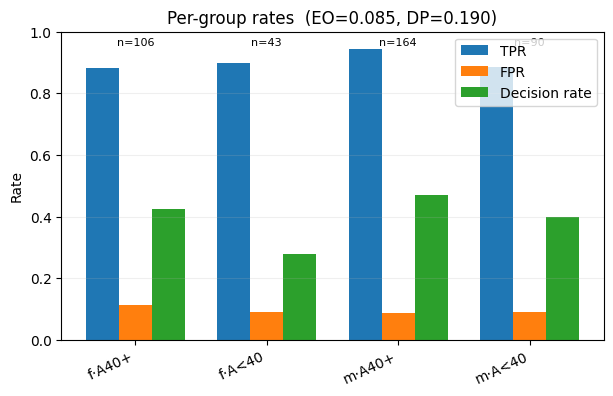

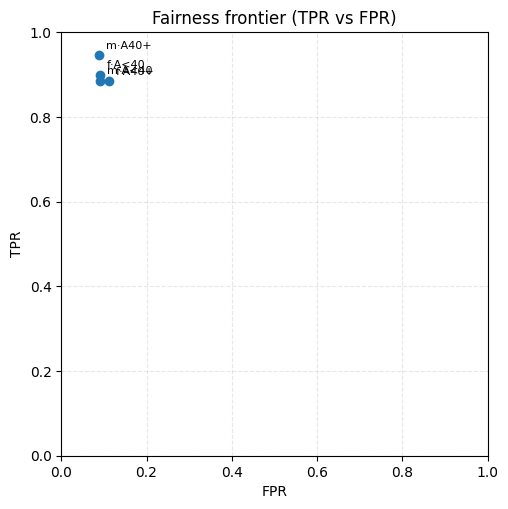

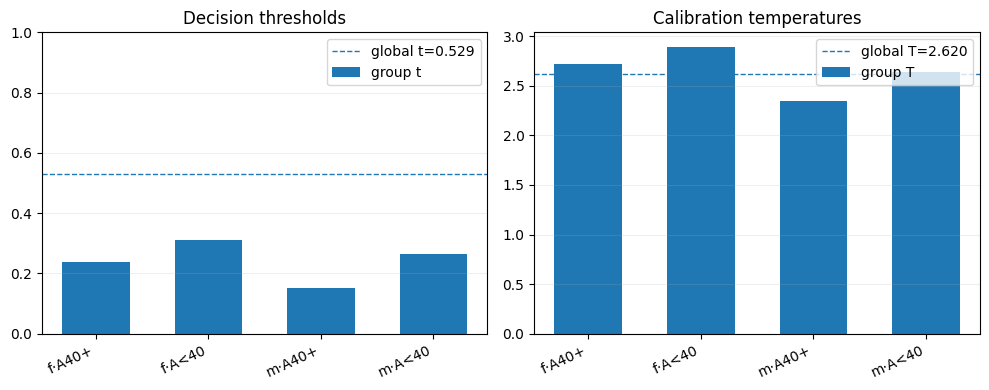

/tmp/ipykernel_777904/161726386.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


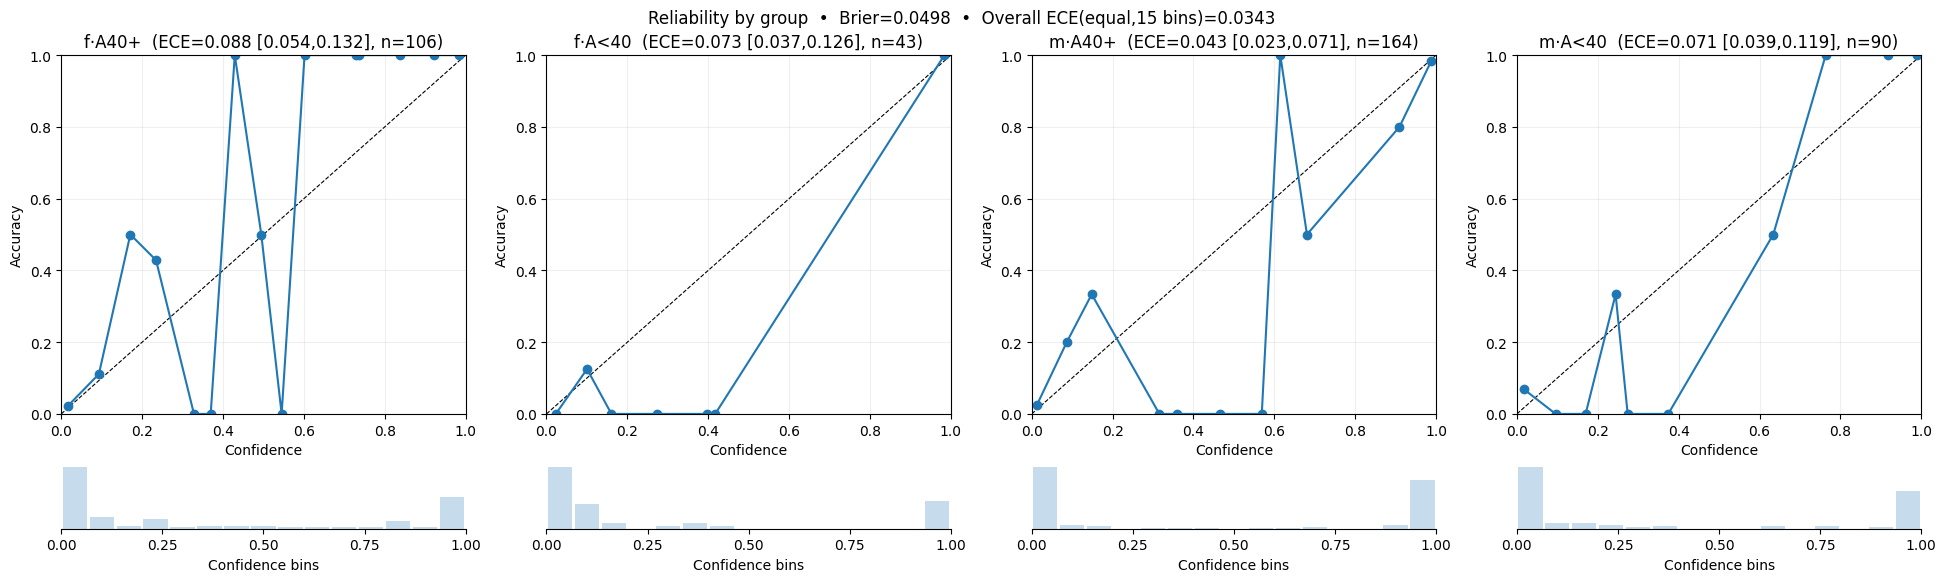

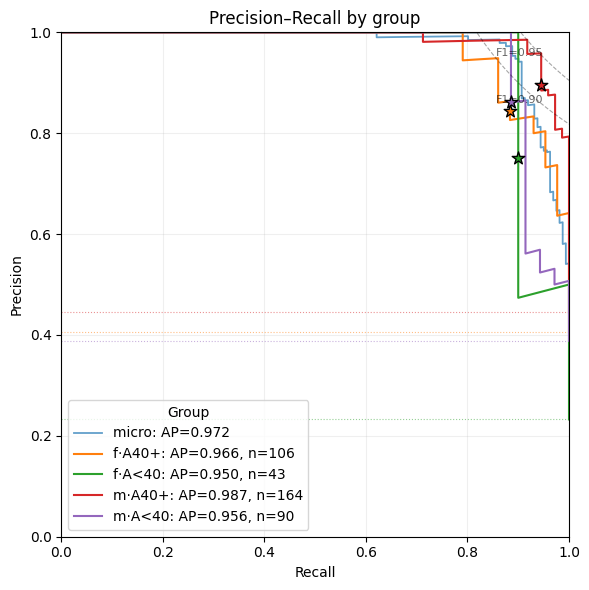

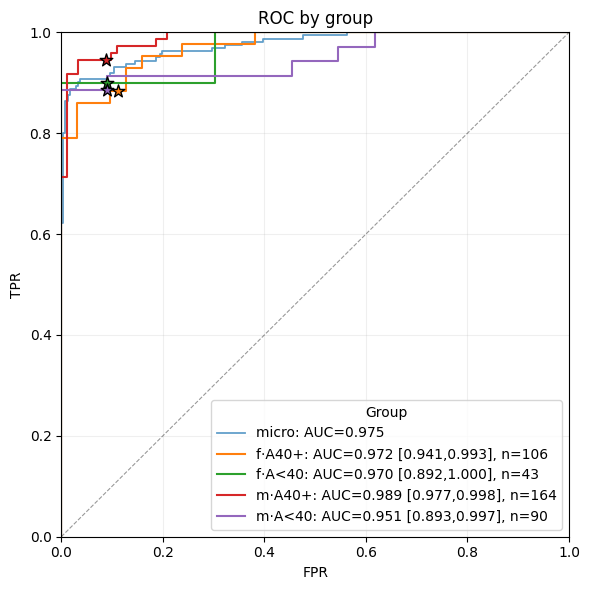

In [251]:
# Example name map
name_map = {0:'f·A40+', 1:'f·A<40', 2:'m·A40+', 3:'m·A<40'}

# Single-report dashboard (e.g., A-IEOF student)
show_dashboard(rep_student_group, group_name_map=name_map)
y_test, _z, s_test = collect_scores(ds_test, student, use_full_meta=True)
calib_df = publishable_reliability(
    rep_student_group,               # your report dict
    y=y_test, s=s_test,              # TEST labels & groups
    group_name_map=name_map,         # pretty names (optional)
    n_bins=15, method="equal",    # or equal/quantile try 'quantile' for steadier small-group curves
    n_boot=1000, alpha=0.05
)
# y_test, s_test from your pipeline
pr_by_group= plot_pr_by_group_publishable(rep_student_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                 f1_levels=(0.90, 0.95), show_micro=True)
roc_by_group = plot_roc_by_group_publishable(rep_student_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=True, n_boot=1000, alpha=0.05, seed=0)
plt.show()

#### Teacher_noB Plots

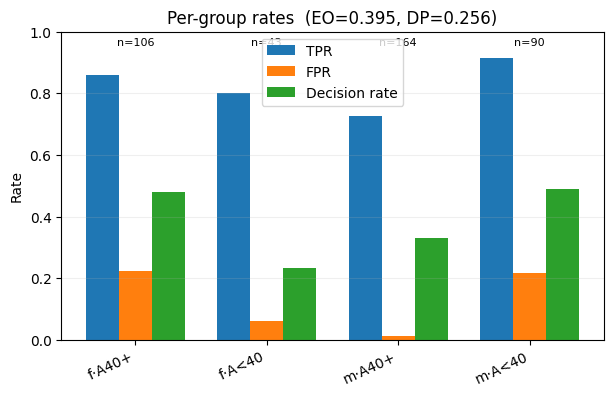

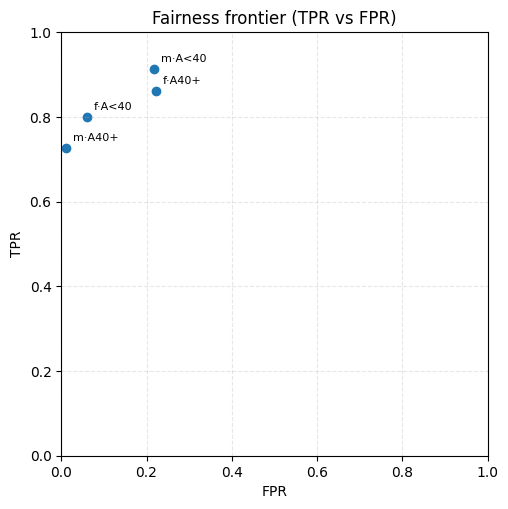

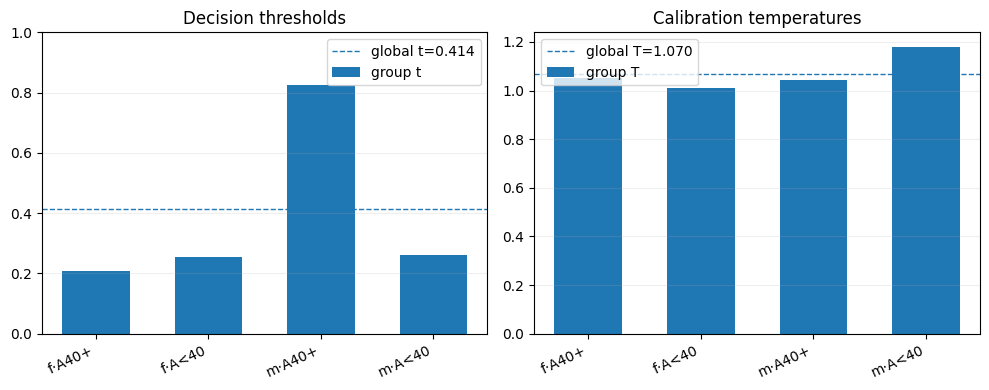

/tmp/ipykernel_777904/161726386.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


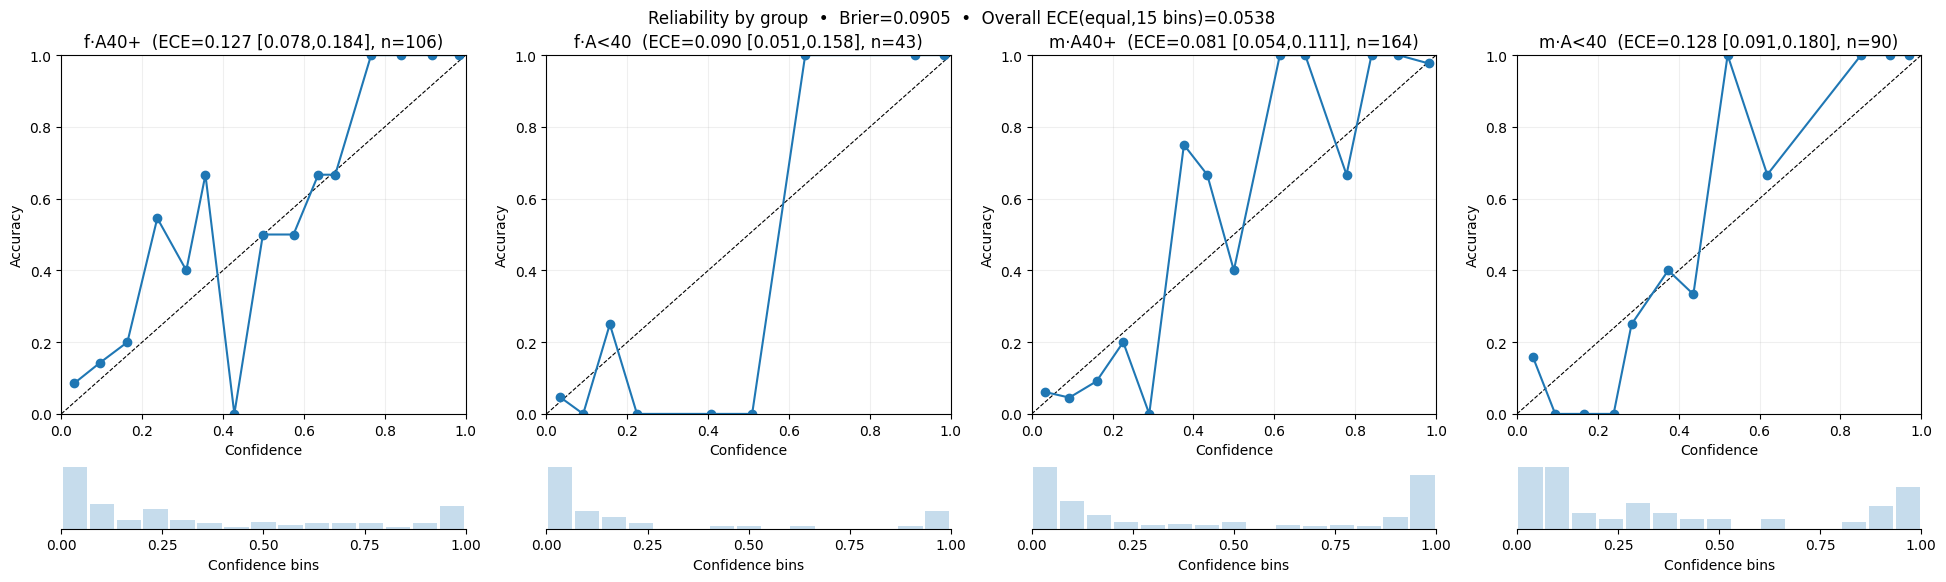

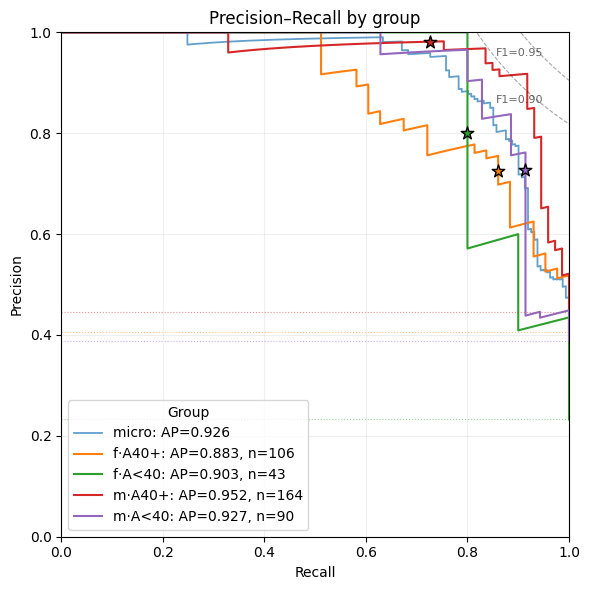

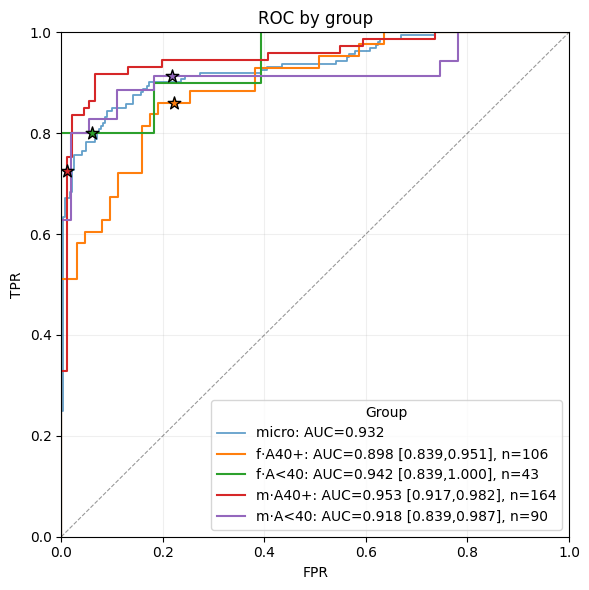

In [252]:
# Example name map
name_map = {0:'f·A40+', 1:'f·A<40', 2:'m·A40+', 3:'m·A<40'}

# Single-report dashboard (e.g., A-IEOF student)
show_dashboard(rep_teacher_group, group_name_map=name_map)
y_test, _z, s_test = collect_scores(ds_test, teacher, use_full_meta=True)
calib_df = publishable_reliability(
    rep_teacher_group,               # your report dict
    y=y_test, s=s_test,              # TEST labels & groups
    group_name_map=name_map,         # pretty names (optional)
    n_bins=15, method="equal",    # or equal/quantile try 'quantile' for steadier small-group curves
    n_boot=1000, alpha=0.05
)
# y_test, s_test from your pipeline
pr_by_group= plot_pr_by_group_publishable(rep_teacher_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                 f1_levels=(0.90, 0.95), show_micro=True)
roc_by_group = plot_roc_by_group_publishable(rep_teacher_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=True, n_boot=1000, alpha=0.05, seed=0)
plt.show()

#### Teacher_withB Plots

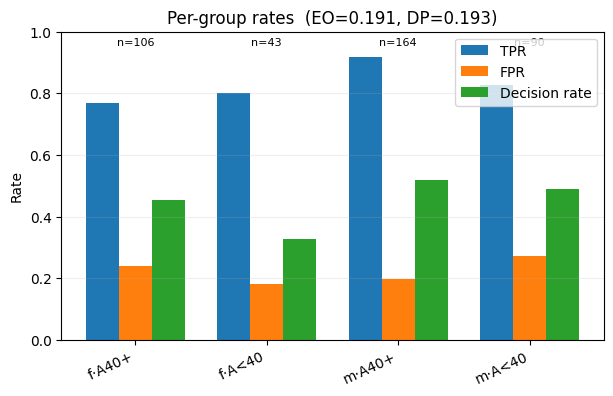

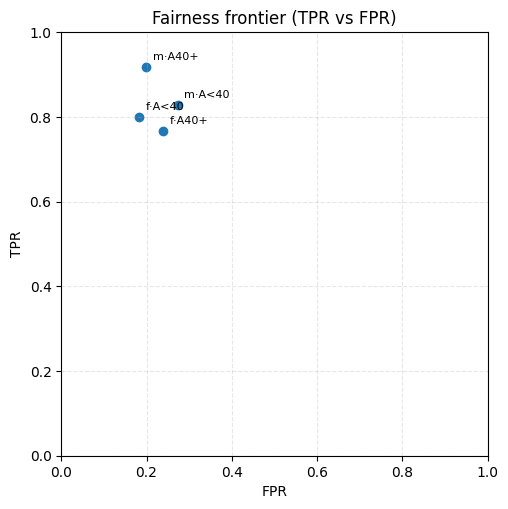

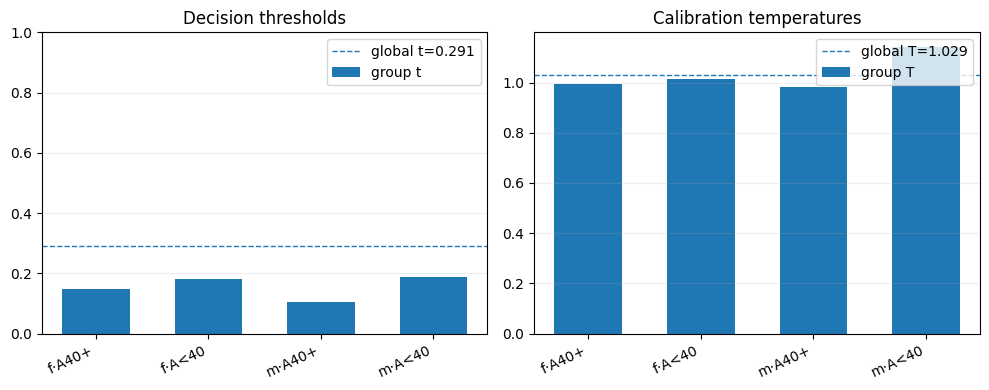

/tmp/ipykernel_777904/161726386.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


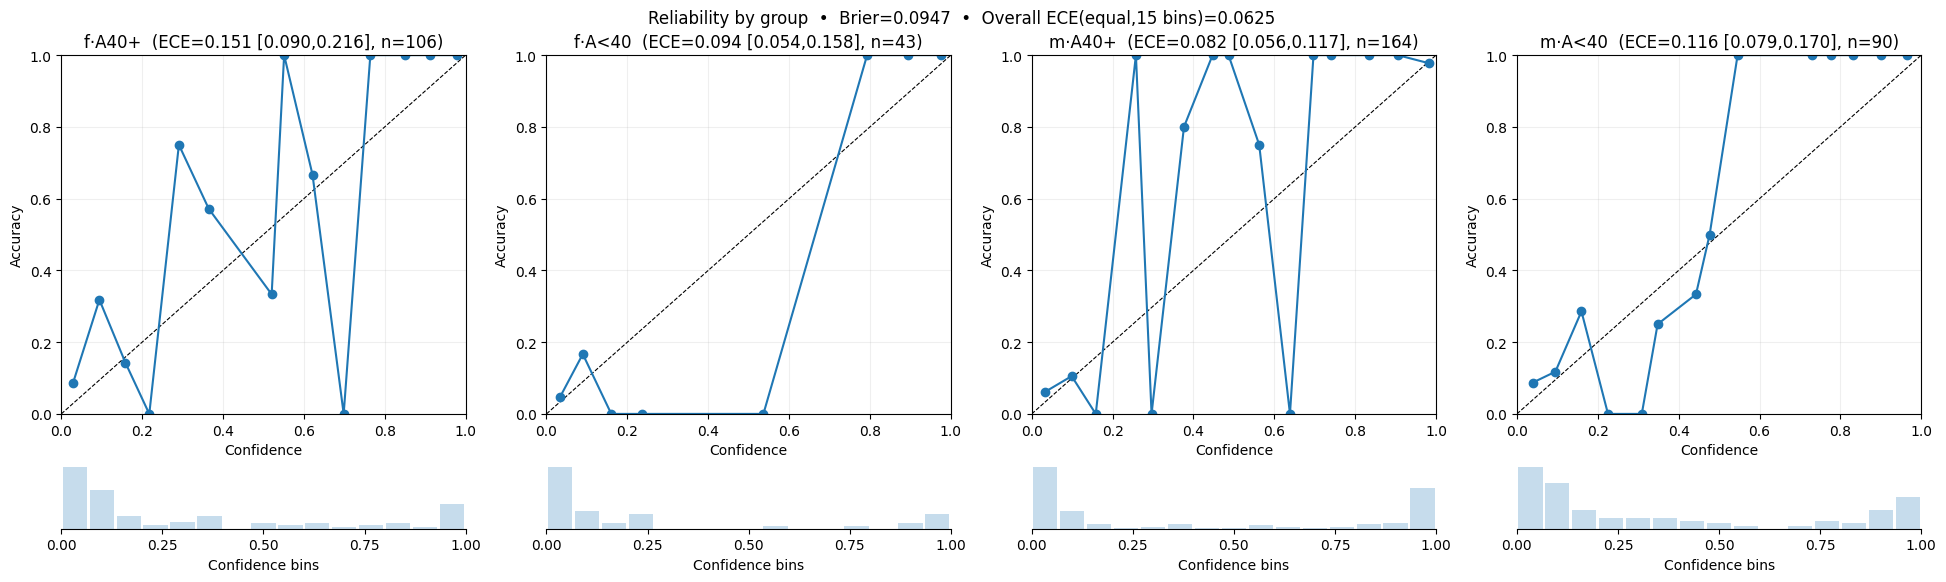

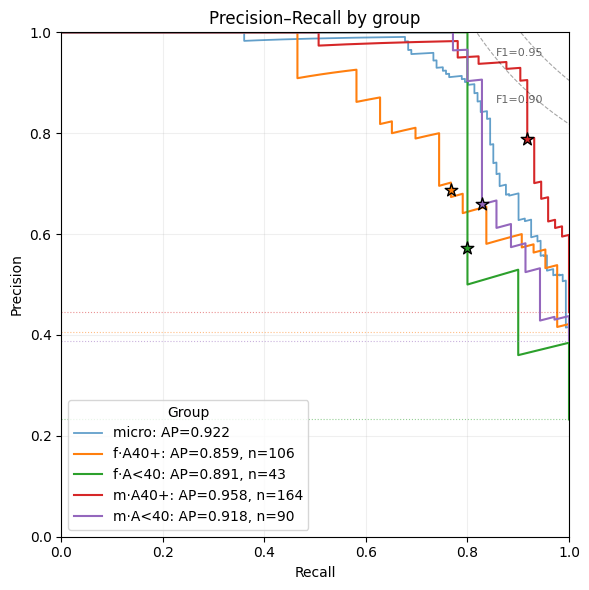

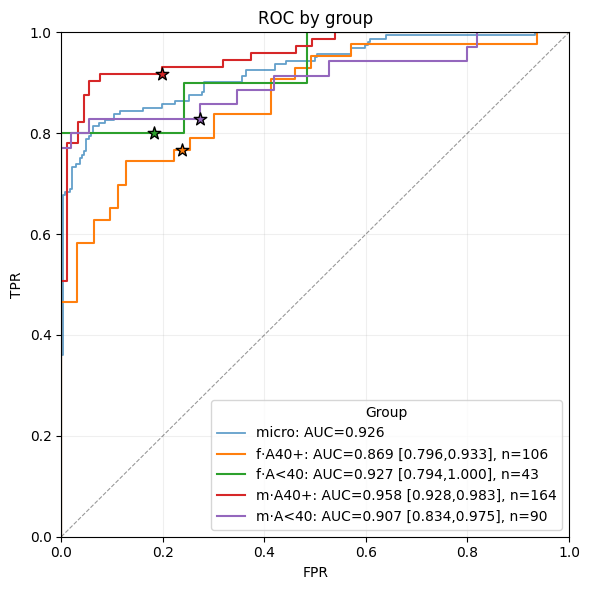

In [253]:
# Example name map
name_map = {0:'f·A40+', 1:'f·A<40', 2:'m·A40+', 3:'m·A<40'}

# Single-report dashboard (e.g., A-IEOF student)
show_dashboard(rep_teacher_withB_group, group_name_map=name_map)
y_test, _z, s_test = collect_scores(ds_test, teacher_with_b, use_full_meta=True)
calib_df = publishable_reliability(
    rep_teacher_withB_group,               # your report dict
    y=y_test, s=s_test,              # TEST labels & groups
    group_name_map=name_map,         # pretty names (optional)
    n_bins=15, method="equal",    # or equal/quantile try 'quantile' for steadier small-group curves
    n_boot=1000, alpha=0.05
)
# y_test, s_test from your pipeline
pr_by_group= plot_pr_by_group_publishable(rep_teacher_withB_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                 f1_levels=(0.90, 0.95), show_micro=True)
roc_by_group = plot_roc_by_group_publishable(rep_teacher_withB_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=True, n_boot=1000, alpha=0.05, seed=0)
plt.show()

#### CRV Vs Teacher_noB Vs Teacher_withB

==================== delta df for CRM Vs Teacher_noB=============================


,group,name,TPR_T,TPR_CRM,ΔTPR,FPR_T,FPR_CRM,ΔFPR,PRate_T,PRate_CRM,ΔPRate,pos_T,neg_T
0,0,f·A40+,0.744186,0.837209,0.093023,0.174603,0.079365,-0.095238,0.405660,0.386792,-0.018868,43,63
1,1,f·A<40,0.800000,0.900000,0.100000,0.060606,0.060606,0.000000,0.232558,0.255814,0.023256,10,33
2,2,m·A40+,0.917808,0.945205,0.027397,0.153846,0.076923,-0.076923,0.493902,0.463415,-0.030488,73,91
3,3,m·A<40,0.885714,0.914286,0.028571,0.163636,0.036364,-0.127273,0.444444,0.377778,-0.066667,35,55


==================== delta df for CRM Vs Teacher_withB=============================


,group,name,TPR_T,TPR_CRM,ΔTPR,FPR_T,FPR_CRM,ΔFPR,PRate_T,PRate_CRM,ΔPRate,pos_T,neg_T
0,0,f·A40+,0.790698,0.837209,0.046512,0.142857,0.079365,-0.063492,0.405660,0.386792,-0.018868,43,63
1,1,f·A<40,0.800000,0.900000,0.100000,0.060606,0.060606,0.000000,0.232558,0.255814,0.023256,10,33
2,2,m·A40+,0.931507,0.945205,0.013699,0.142857,0.076923,-0.065934,0.493902,0.463415,-0.030488,73,91
3,3,m·A<40,0.828571,0.914286,0.085714,0.109091,0.036364,-0.072727,0.388889,0.377778,-0.011111,35,55


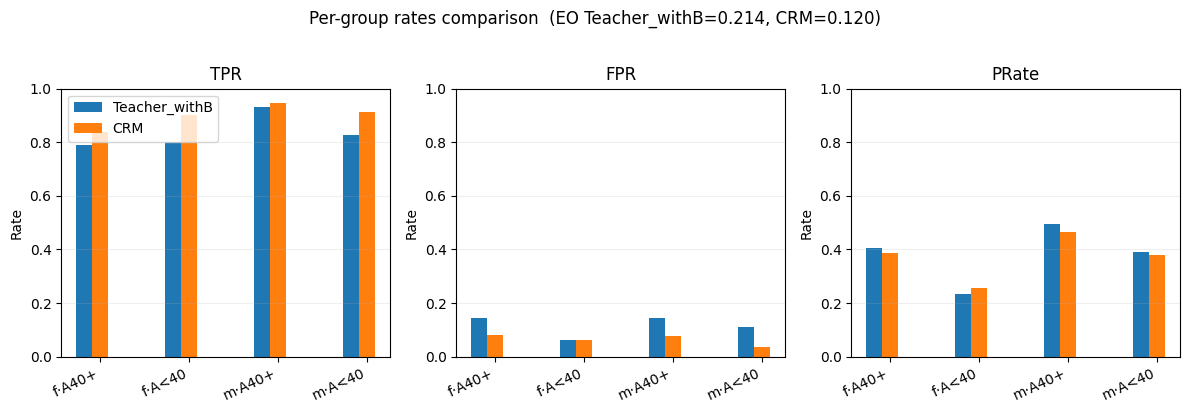

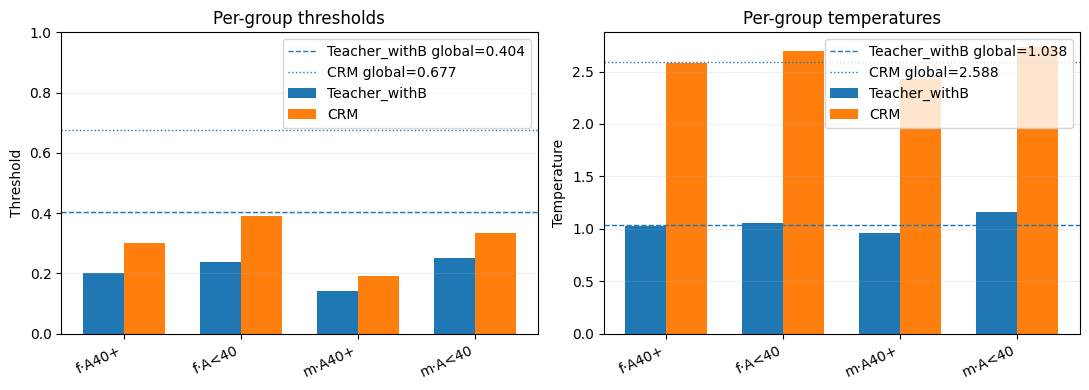

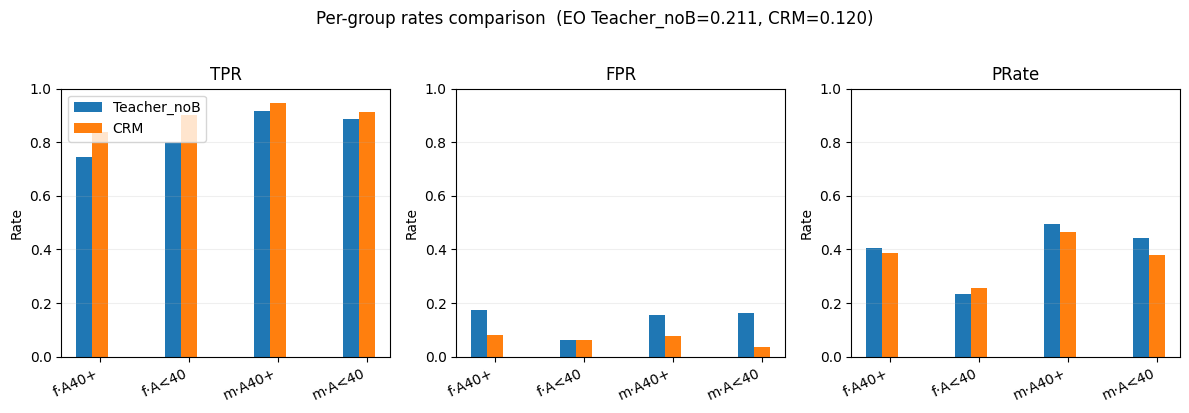

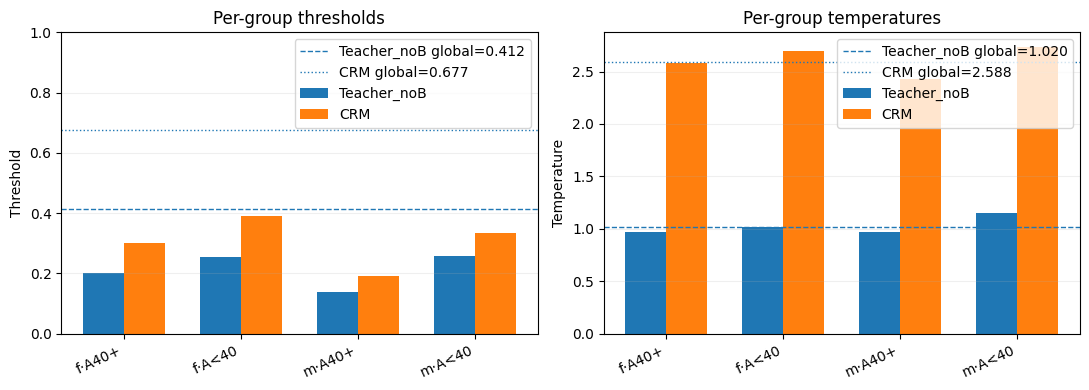

In [195]:
# Compare teacher vs student (per-group thresholding or global—your choice)
compare_group_rates(rep_teacher_withB_group, rep_student_group, "Teacher_withB", "A-IEOF", group_name_map=name_map)
compare_thresholds_temps(rep_teacher_withB_group, rep_student_group, "Teacher_withB", "A-IEOF", group_name_map=name_map)

# Compare teacher vs student (per-group thresholding or global—your choice)
compare_group_rates(rep_teacher_group, rep_student_group, "Teacher_noB", "A-IEOF", group_name_map=name_map)
compare_thresholds_temps(rep_teacher_group, rep_student_group, "Teacher_noB", "A-IEOF", group_name_map=name_map)

out.index.name = "g"   # <-- add this line
out = out.reset_index().rename(columns={"g":"group"})

print("==================== delta df for A-IEOF Vs Teacher_noB=============================")
delta_df = group_delta_table(rep_teacher_group, rep_student_group, group_name_map=name_map)
display(delta_df)

print("==================== delta df for A-IEOF Vs Teacher_withB=============================")
delta_df = group_delta_table(rep_teacher_withB_group, rep_student_group, group_name_map=name_map)
display(delta_df)

### Hardt Equalized-Odds (post-processing) 
This uses fairlearn’s ThresholdOptimizer if available (exact Hardt); otherwise it falls back to the “min-EO per-group thresholds” you already ship (approximate).

In [208]:
# =========================
# Hardt Equalized Odds (post-processing) – pipeline-compatible
# =========================
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
import cvxpy
print(cvxpy.__version__)

# ---- small helpers (standalone; do not clash with your globals) ----
def _roc_points(y, p):
    y = np.asarray(y, int); p = np.asarray(p, float)
    fpr, tpr, thr = roc_curve(y, p)
    return fpr, tpr, thr

def _closest_point_on_roc(fpr, tpr, thr, tf, tt):
    fpr = np.asarray(fpr); tpr = np.asarray(tpr); thr = np.asarray(thr)
    d2 = (fpr - tf)**2 + (tpr - tt)**2
    j  = int(np.argmin(d2))
    return float(thr[j]), float(fpr[j]), float(tpr[j]), j

def _eo_gap_from_rates(tprs, fprs):
    tprs = np.asarray(tprs, float); fprs = np.asarray(fprs, float)
    if tprs.size <= 1: return 0.0
    gap = np.nanmax(np.abs(tprs[:,None]-tprs[None,:]) + np.abs(fprs[:,None]-fprs[None,:]))
    return float(gap)

# ---- Hardt EO: exact (randomized) with cvxpy, quantized by score bins ----
def _hardt_eo_exact_with_cvxpy(y_val, p_val, s_val, y_te, p_te, s_te, K=50, seed=123):
    """
    Exact Hardt et al. EO via randomized classification on discretized bins.
    Returns predicted labels on TEST.
    """
    try:
        import cvxpy as cp
    except Exception as e:
        raise RuntimeError("cvxpy not available") from e

    yv = np.asarray(y_val, int); pv = np.asarray(p_val, float); sv = np.asarray(s_val, int)
    yt = np.asarray(y_te,  int); pt = np.asarray(p_te,  float); st = np.asarray(s_te, int)
    groups = np.unique(sv)

    # Discretize VAL scores per group -> K quantile bins
    thr_g, bin_g = {}, {}
    for g in groups:
        m = (sv == g)
        qs = np.quantile(pv[m], np.linspace(0, 1, K+1))
        thr_g[int(g)] = qs
        dg = np.clip(np.searchsorted(qs, pv[m], side="right")-1, 0, K-1)
        bin_g[int(g)] = (m, dg)

    # Decision variables: π_gk ∈ [0,1] = prob of predicting 1 in bin k for group g
    pi = {int(g): cp.Variable(K) for g in groups}
    cons, tprs, fprs = [], [], []

    # Build TPR/FPR expressions from VAL bin masses
    for g in groups:
        m, dg = bin_g[int(g)]
        yg = yv[m]
        pos_rate = max((yg == 1).mean(), 1e-8)
        neg_rate = max((yg == 0).mean(), 1e-8)
        mass_pos = np.array([(((dg == k) & (yg == 1)).mean()) for k in range(K)], float)
        mass_neg = np.array([(((dg == k) & (yg == 0)).mean()) for k in range(K)], float)
        tprs.append((pi[int(g)] @ mass_pos) / pos_rate)
        fprs.append((pi[int(g)] @ mass_neg) / neg_rate)
        cons += [pi[int(g)] >= 0, pi[int(g)] <= 1]

    # EO constraints: all groups share same TPR and same FPR
    for i in range(len(groups)-1):
        cons += [tprs[i] == tprs[i+1], fprs[i] == fprs[i+1]]

    # Objective: maximize VAL accuracy under those constraints
    acc_terms = []
    for g in groups:
        m, dg = bin_g[int(g)]
        yg = yv[m]
        mass_pos = np.array([(((dg == k) & (yg == 1)).mean()) for k in range(K)], float)
        mass_neg = np.array([(((dg == k) & (yg == 0)).mean()) for k in range(K)], float)
        acc_terms.append(pi[int(g)] @ mass_pos + (1 - pi[int(g)]) @ mass_neg)

    try:
        prob = cp.Problem(cp.Maximize(sum(acc_terms)), cons)
        # Pick a sensible default solver; fall back if needed
        try:
            prob.solve(solver=cp.ECOS, verbose=False)
        except Exception:
            prob.solve(solver=cp.SCS, verbose=False)
    except Exception as e:
        raise RuntimeError(f"cvxpy solve failed: {e}")

    # Apply to TEST stochastically using the learned π_gk
    rng = np.random.default_rng(seed)
    preds = np.zeros_like(yt, int)
    for g in groups:
        qs = thr_g[int(g)]
        m = (st == g)
        if not np.any(m): continue
        dg = np.clip(np.searchsorted(qs, pt[m], side="right")-1, 0, K-1)
        pis = np.array(pi[int(g)].value).astype(float).clip(0, 1)
        preds[m] = (rng.random(size=m.sum()) < pis[dg]).astype(int)
    return preds

# ---- Deterministic fallback: nearest shared ROC point on VAL ----
def _hardt_eo_fallback(y_val, p_val, s_val, y_te, p_te, s_te):
    groups = np.unique(s_val)
    roc = {}
    for g in groups:
        m = (s_val == g)
        fpr, tpr, thr = _roc_points(y_val[m], p_val[m])
        roc[int(g)] = (fpr, tpr, thr)

    # Grid of candidate shared targets (FPR*,TPR*)
    grid = np.linspace(0.05, 0.95, 31)
    best = (None, None, 1e9)
    for tf in grid:
        for tt in grid:
            tprs, fprs = [], []
            for g in groups:
                fpr_g, tpr_g, thr_g = roc[int(g)]
                _, f, t, _ = _closest_point_on_roc(fpr_g, tpr_g, thr_g, tf, tt)
                tprs.append(t); fprs.append(f)
            score = _eo_gap_from_rates(tprs, fprs)
            if score < best[2]:
                best = (tf, tt, score)

    target_fpr, target_tpr = best[0], best[1]
    thr_g_pick = {}
    for g in groups:
        fpr_g, tpr_g, thr_g = roc[int(g)]
        th, _, _, _ = _closest_point_on_roc(fpr_g, tpr_g, thr_g, target_fpr, target_tpr)
        thr_g_pick[int(g)] = float(th)

    preds = np.zeros_like(y_te, int)
    for g in groups:
        m = (s_te == g)
        if not np.any(m): continue
        t = thr_g_pick[int(g)]
        preds[m] = (p_te[m] >= t).astype(int)
    return preds, thr_g_pick

def hardt_equalized_odds(y_val, p_val, s_val, y_te, p_te, s_te, prefer_exact=True, seed=123):
    """
    Try exact randomized EO (cvxpy). If unavailable, use deterministic fallback.
    Returns (preds_test, info_dict).
    """
    if prefer_exact:
        try:
            preds = _hardt_eo_exact_with_cvxpy(y_val, p_val, s_val, y_te, p_te, s_te, seed=seed)
            return preds.astype(int), {"mode": "exact"}
        except Exception as e:
            print("[hardt-EO] exact solver unavailable → fallback. Reason:", str(e))
    preds, thr_g = _hardt_eo_fallback(y_val, p_val, s_val, y_te, p_te, s_te)
    return preds.astype(int), {"mode": "fallback", "thr_g": thr_g}

# ---- Bootstrap for EO/DP with FIXED predictions (no thresholds needed) ----
def _bootstrap_ci_fixed_preds(y, p, s, preds, metric="EO", n_boot=1000, alpha=0.05, seed=0):
    rng = np.random.RandomState(seed)
    y = np.asarray(y, int); p = np.asarray(p, float); s = np.asarray(s, int); pr = np.asarray(preds, int)
    vals = []
    for _ in range(int(n_boot)):
        # group-stratified resample
        idx = np.arange(len(s))
        boot = []
        for gid in np.unique(s):
            gidx = idx[s == gid]
            if gidx.size == 0: continue
            boot.append(rng.choice(gidx, size=gidx.size, replace=True))
        if not boot:
            vals.append(np.nan); continue
        bi = np.concatenate(boot)
        from math import isnan
        df_b, stats_b, eo_b, dp_b = group_metrics_table(y[bi], p[bi], s[bi], preds=pr[bi], prot_map=None)
        if metric.upper() == "EO":
            vals.append(eo_b)
        elif metric.upper() == "DP":
            vals.append(dp_b)
        else:
            raise ValueError("metric must be 'EO' or 'DP' for fixed-preds bootstrap")
    vals = np.asarray(vals, float)
    pe = float(np.nanmedian(vals))
    lo, hi = np.nanpercentile(vals, [100*alpha/2, 100*(1-alpha/2)])
    return dict(point=pe, lo=float(lo), hi=float(hi), alpha=alpha, boots=int(n_boot))

# ---- Public entrypoint: evaluate with Hardt EO using your calibration pipeline ----
def evaluate_with_hardt_equalized_odds(model, ds_val, ds_test, prot_map, cfg, *,
                                       use_full_meta: bool,
                                       prefer_exact: bool = True,
                                       seed: int = 42,
                                       n_boot: int = 1000,
                                       alpha: float = 0.05):
    """
    Mirrors evaluate_model_on_val_test, but uses Hardt EO post-processing
    to produce TEST predictions. Returns a publishable report dict.
    """
    # 1) VAL scores → calibrated probs (consistent with your config)
    yv, zv, sv = collect_scores(ds_val, model, use_full_meta=use_full_meta)
    pv, T_glob, T_g = _calibrate_probs_on_val(zv, yv, sv, cfg)

    # 2) TEST scores → calibrated probs using saved post-proc
    yt, zt, st = collect_scores(ds_test, model, use_full_meta=use_full_meta)
    pt = _apply_calibration_on_test(zt, st, {"T_glob": T_glob, "T_g": T_g}, cfg)

    # 3) Hardt EO: build TEST predictions from (VAL, TEST)
    preds, info = hardt_equalized_odds(yv, pv, sv, yt, pt, st,
                                       prefer_exact=prefer_exact, seed=seed)

    # 4) Metrics + tables (reuse your existing helpers)
    auc = safe_auc(yt, pt)
    ece, calib_bins = ece_reliability(yt, pt, n_bins=15)
    brier = brier_score(yt, pt)
    per_group_df, stats, eo, dp = group_metrics_table(yt, pt, st, preds=preds, prot_map=prot_map,
                                                      min_posneg_report=cfg.get("MIN_POSNEG_REPORT", 30))

    curves = dict(
        by_group = roc_pr_curves_by_group(yt, pt, st, min_count=cfg.get("MIN_POSNEG_REPORT", 30)),
        calibration = calibration_by_group(yt, pt, st, n_bins=15, min_count=cfg.get("MIN_POSNEG_REPORT", 30))
    )

    # 5) CIs (AUC, Brier via your existing bootstrap; EO/DP via fixed-preds bootstrap)
    ci = {}
    ci["AUC"]   = bootstrap_ci(yt, pt, st, thr=None, thr_g=None, metric="AUC",   n_boot=n_boot, alpha=alpha, seed=seed)
    ci["Brier"] = bootstrap_ci(yt, pt, st, thr=None, thr_g=None, metric="Brier", n_boot=n_boot, alpha=alpha, seed=seed)
    ci["EO"]    = _bootstrap_ci_fixed_preds(yt, pt, st, preds, metric="EO",     n_boot=n_boot, alpha=alpha, seed=seed)
    ci["DP"]    = _bootstrap_ci_fixed_preds(yt, pt, st, preds, metric="DP",     n_boot=n_boot, alpha=alpha, seed=seed)

    # 6) Pretty print (like your other path)
    print("\n== TEST (publishable report • Hardt EO) ==")
    print(f"AUC: {auc:.3f} | EO gap: {eo:.3f} | DP gap: {dp:.3f} | Brier: {brier:.4f} | ECE: {ece:.4f}")
    print_group_table_like_A-IEOF(per_group_df)

    # 7) Return a report dict shaped like your other reports
    rep = dict(
        probs=pt, preds=preds,
        auc=auc, eo=eo, dp=dp, brier=brier, ece=ece,
        per_group_table=per_group_df,
        curves=curves,
        ci=ci,
        thresholds=dict(t_global=np.nan, thr_g=(info.get("thr_g", {}) if info.get("mode")=="fallback" else {})),
        calibration=dict(mode="hardt_eo", T_glob=float(T_glob), T_g=T_g or {}),
        calib_bins=calib_bins,
        hardt_info=info
    )
    return rep


1.7.1


In [237]:
# 1) Make sure you evaluate the **trained weights**
student = env["student"]
student.load_weights(os.path.join(CONFIG["CKPT_DIR"], "student_A-IEOF_best.weights.h5"))

teacher_no_b  = env["teacher"]
teacher_no_b.load_weights(os.path.join(CONFIG["CKPT_DIR"], "teacher_noB.weights.h5"))

teacher_with_b  = teacher_withB_model
teacher_with_b.load_weights(os.path.join(CONFIG["CKPT_DIR"], "withB_baseline_best.weights.h5"))

print("\n========================== A-IEOF+Hardt EO ======================================")
# Example: student, WITH-B path, same config & naming as your A-IEOF runs
rep_A-IEOF_hardt = evaluate_with_hardt_equalized_odds(
    student, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, prefer_exact=True, seed=42
)

print("\n========================== teacher_noB+Hardt EO ======================================\n")
# Example: student, WITH-B path, same config & naming as your A-IEOF runs
rep_teacher_noB_hardt = evaluate_with_hardt_equalized_odds(
    teacher, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=False, prefer_exact=True, seed=42
)

print("\n========================== teacher_withB+Hardt EO ======================================\n")
# Example: student, WITH-B path, same config & naming as your A-IEOF runs
rep_teacher_withB_hardt = evaluate_with_hardt_equalized_odds(
    teacher_with_b, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, prefer_exact=True, seed=42
)


========================== CRM+Hardt EO ======================================

== TEST (publishable report • Hardt EO) ==
AUC: 0.975 | EO gap: 0.094 | DP gap: 0.048 | Brier: 0.0507 | ECE: 0.0262
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.767 | FPR=0.032
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.900 | FPR=0.061  (UNSTABLE)
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.836 | FPR=0.011
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.857 | FPR=0.036

========================== teacher_noB+Hardt EO ======================================


== TEST (publishable report • Hardt EO) ==
AUC: 0.919 | EO gap: 0.130 | DP gap: 0.020 | Brier: 0.0935 | ECE: 0.0416
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.698 | FPR=0.127
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.700 | FPR=0.061  (UNSTABLE)
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.767 | FPR=0.066
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.800 | FPR=0.109

====================

#### A-IEOF+Hardt dashboard

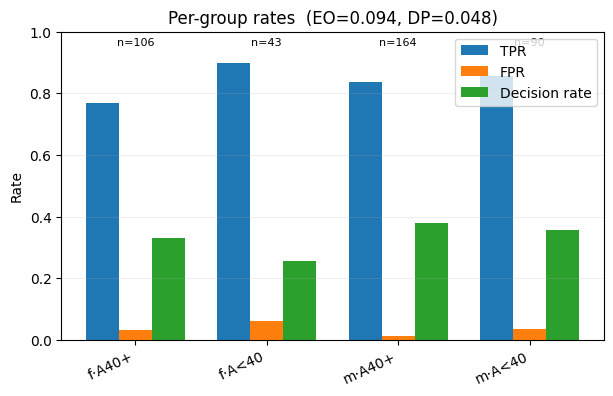

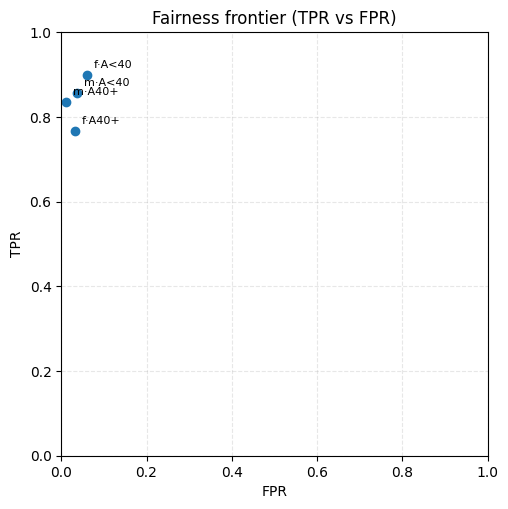

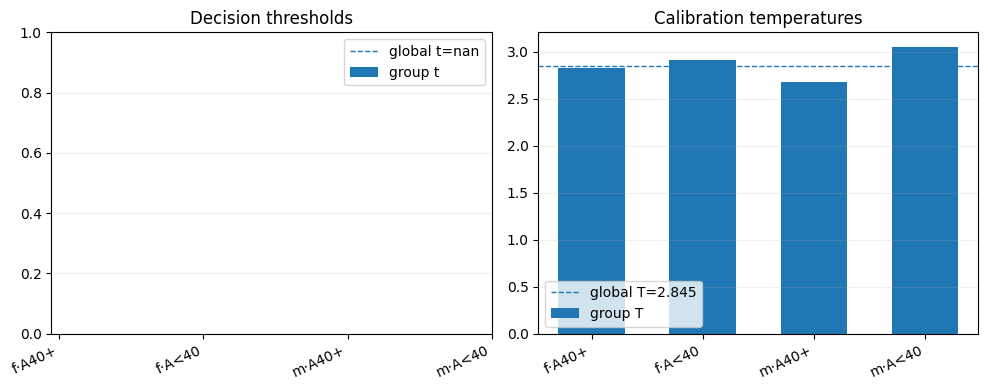

/tmp/ipykernel_777904/161726386.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


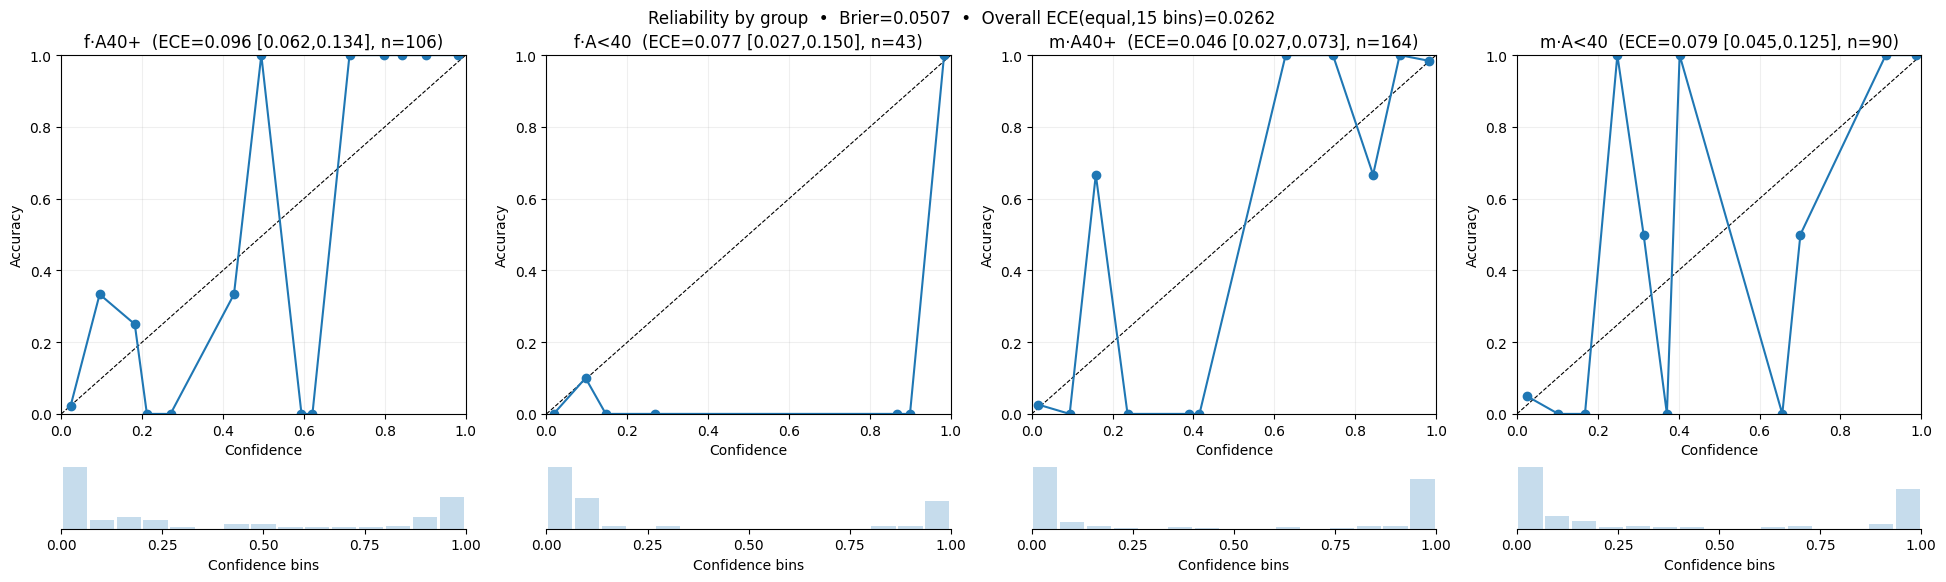

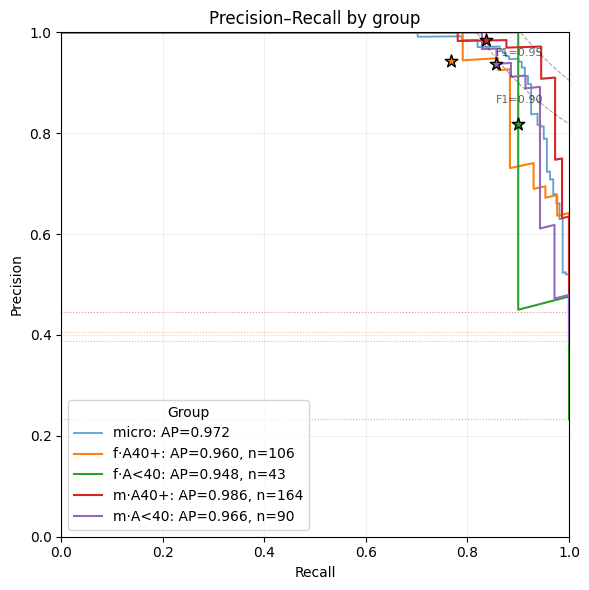

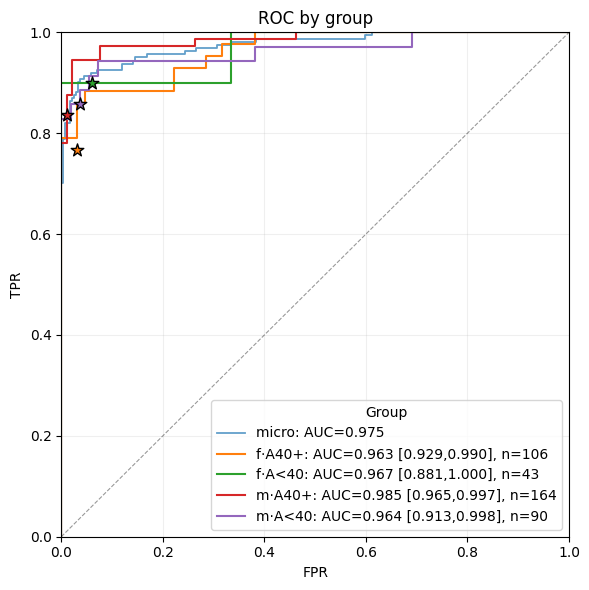

In [248]:
# Example name map
name_map = {0:'f·A40+', 1:'f·A<40', 2:'m·A40+', 3:'m·A<40'}

# Single-report dashboard (e.g., A-IEOF student)
show_dashboard(rep_A-IEOF_hardt, group_name_map=name_map)
y_test, _z, s_test = collect_scores(ds_test, teacher_with_b, use_full_meta=True)
calib_df = publishable_reliability(
    rep_A-IEOF_hardt,               # your report dict
    y=y_test, s=s_test,              # TEST labels & groups
    group_name_map=name_map,         # pretty names (optional)
    n_bins=15, method="equal",    # or equal/quantile try 'quantile' for steadier small-group curves
    n_boot=1000, alpha=0.05
)
# y_test, s_test from your pipeline
pr_by_group= plot_pr_by_group_publishable(rep_A-IEOF_hardt, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                 f1_levels=(0.90, 0.95), show_micro=True)
roc_by_group = plot_roc_by_group_publishable(rep_A-IEOF_hardt, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=True, n_boot=1000, alpha=0.05, seed=0)
plt.show()

#### teacher_noB+Hardt dashboard

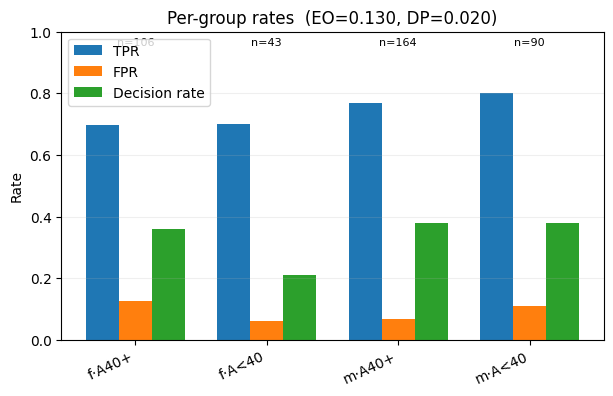

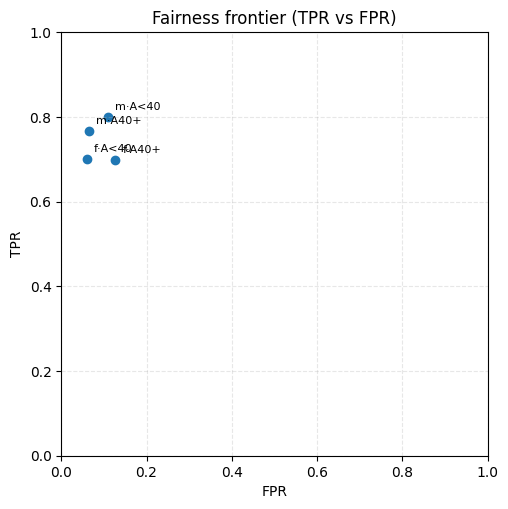

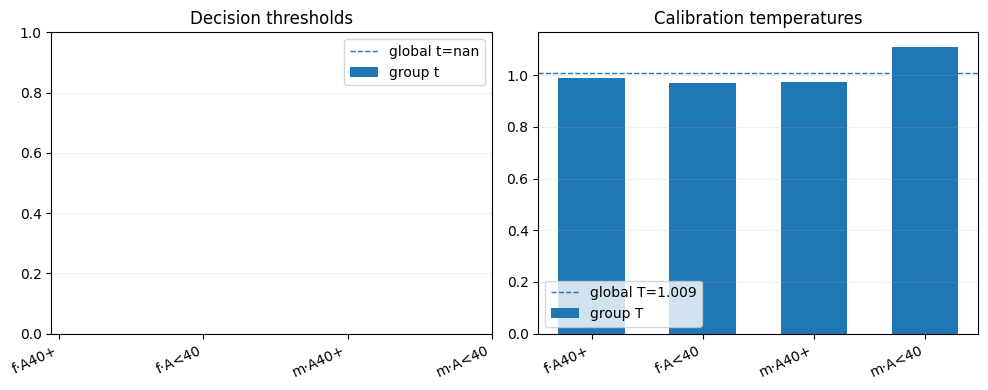

/tmp/ipykernel_777904/161726386.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


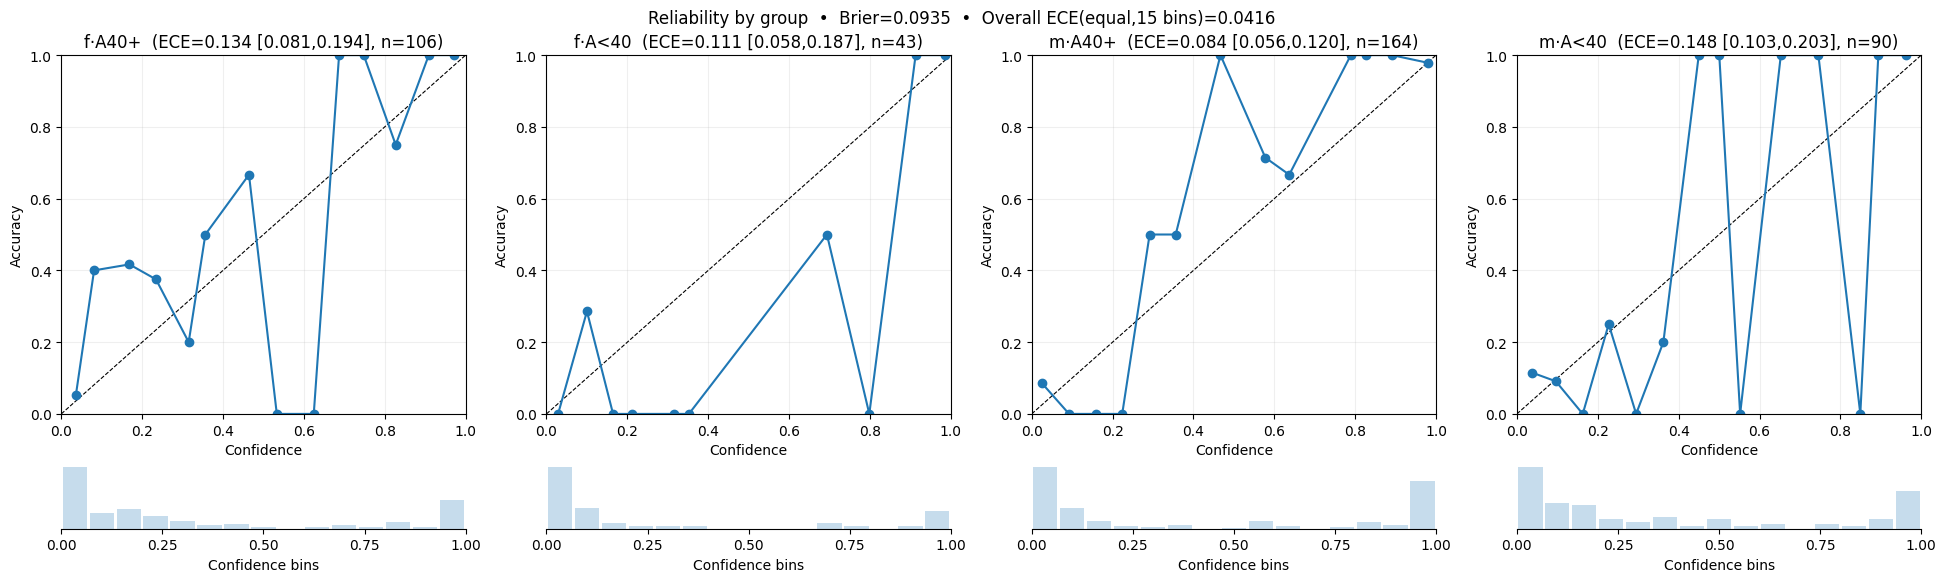

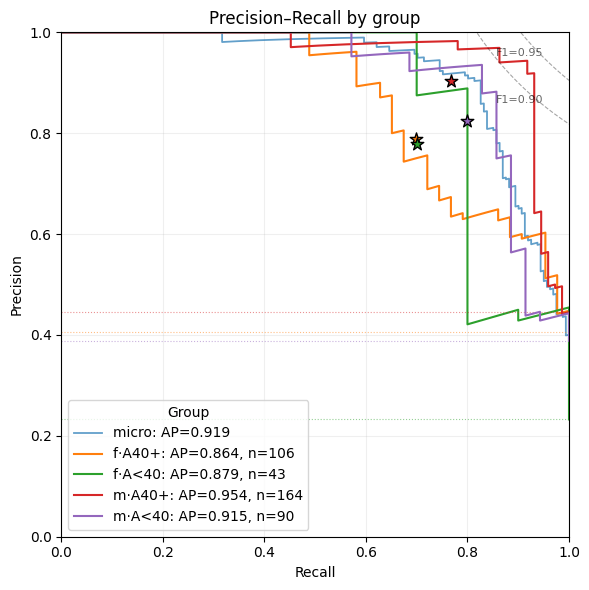

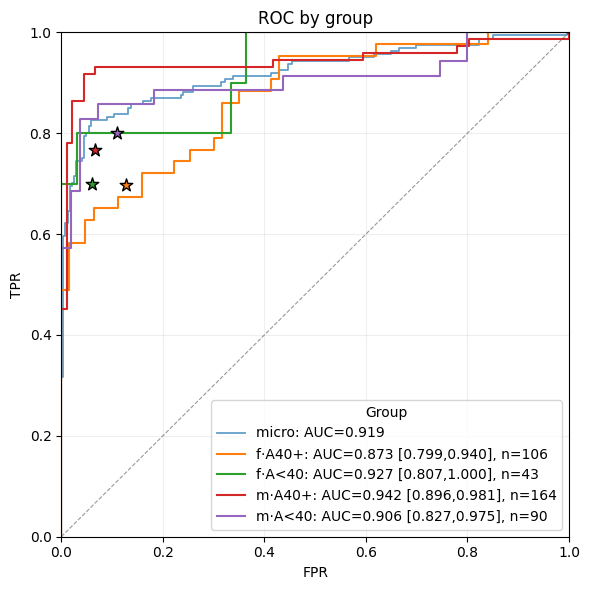

In [249]:
# Example name map
name_map = {0:'f·A40+', 1:'f·A<40', 2:'m·A40+', 3:'m·A<40'}

# Single-report dashboard (e.g., A-IEOF student)
show_dashboard(rep_teacher_noB_hardt, group_name_map=name_map)
y_test, _z, s_test = collect_scores(ds_test, teacher_with_b, use_full_meta=True)
calib_df = publishable_reliability(
    rep_teacher_noB_hardt,               # your report dict
    y=y_test, s=s_test,              # TEST labels & groups
    group_name_map=name_map,         # pretty names (optional)
    n_bins=15, method="equal",    # or equal/quantile try 'quantile' for steadier small-group curves
    n_boot=1000, alpha=0.05
)
# y_test, s_test from your pipeline
pr_by_group= plot_pr_by_group_publishable(rep_teacher_noB_hardt, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                 f1_levels=(0.90, 0.95), show_micro=True)
roc_by_group = plot_roc_by_group_publishable(rep_teacher_noB_hardt, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=True, n_boot=1000, alpha=0.05, seed=0)
plt.show()

#### teacher_withB+Hardt dashboard

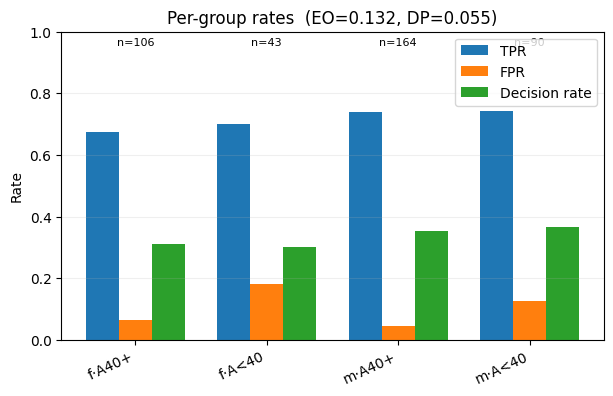

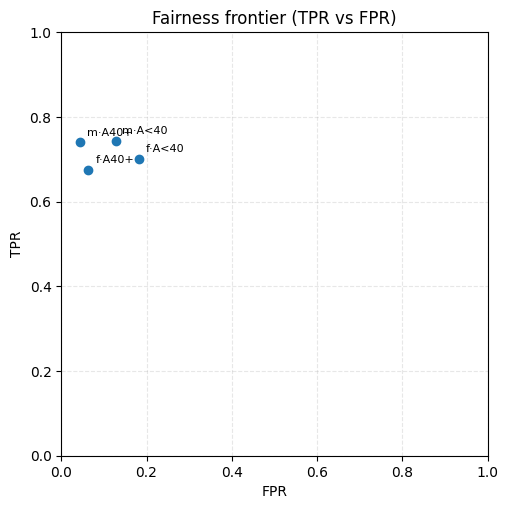

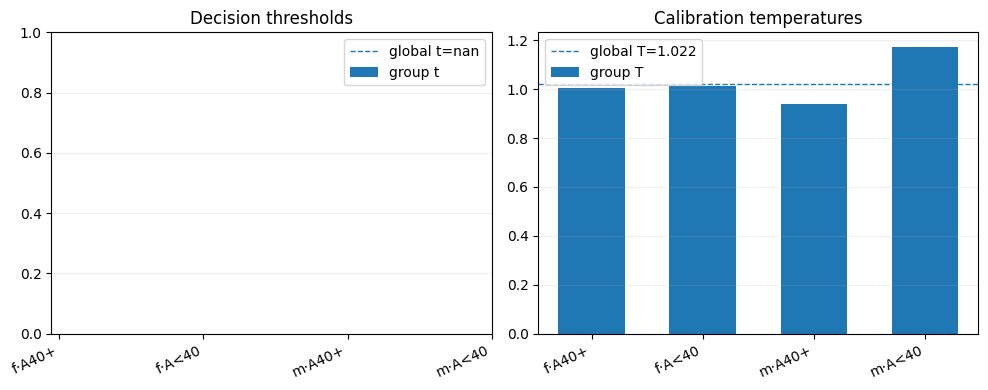

/tmp/ipykernel_777904/161726386.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


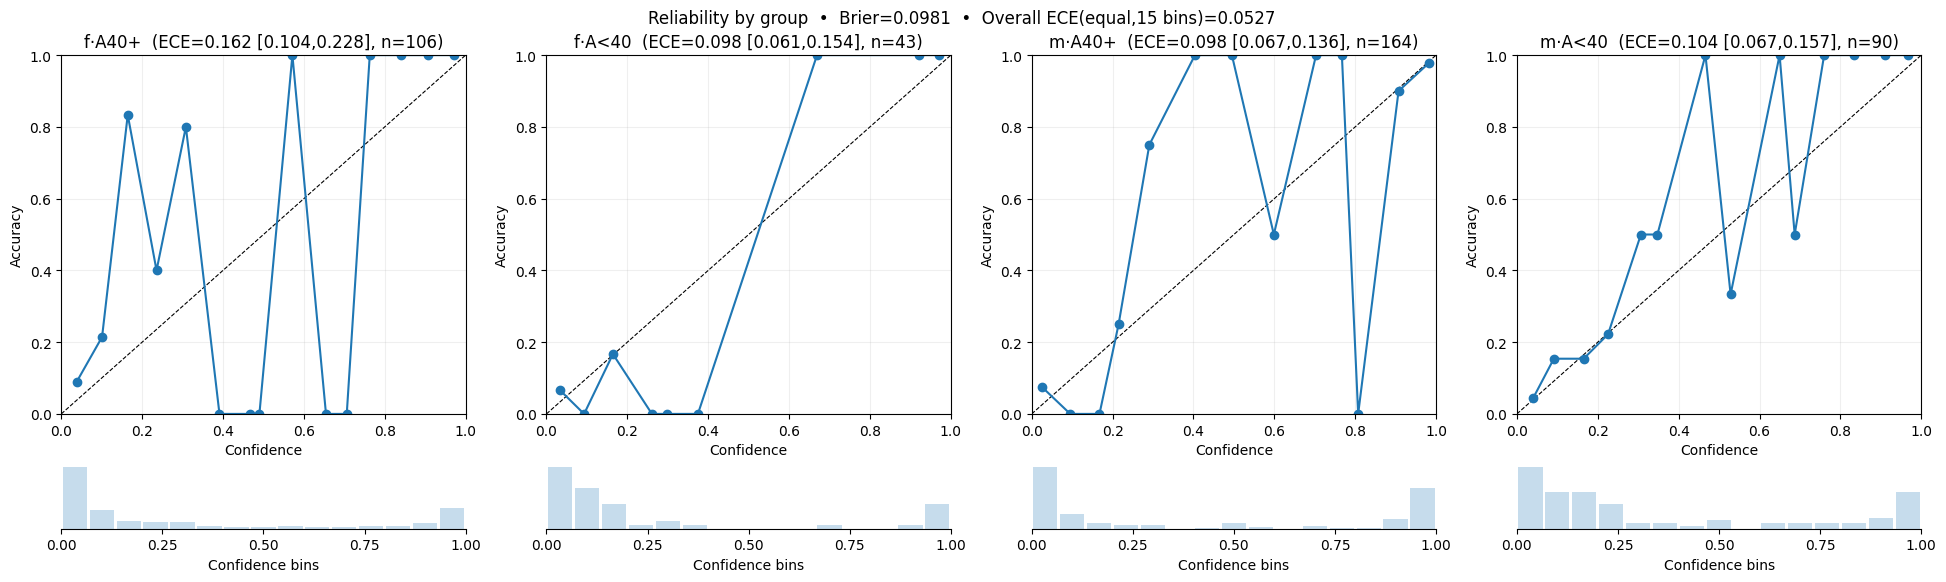

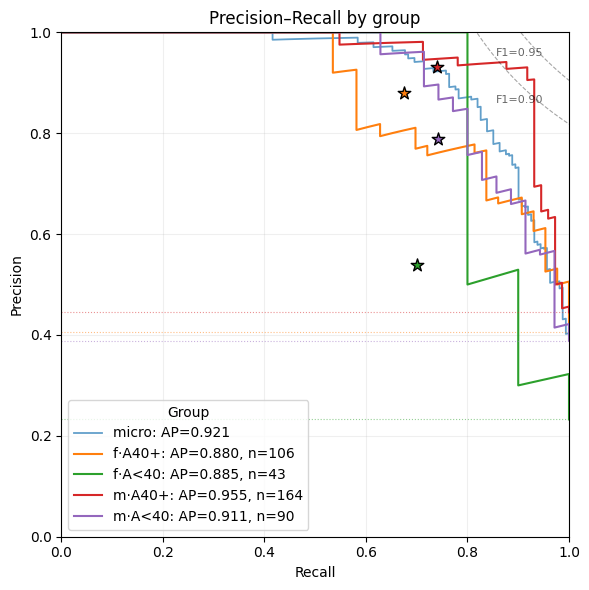

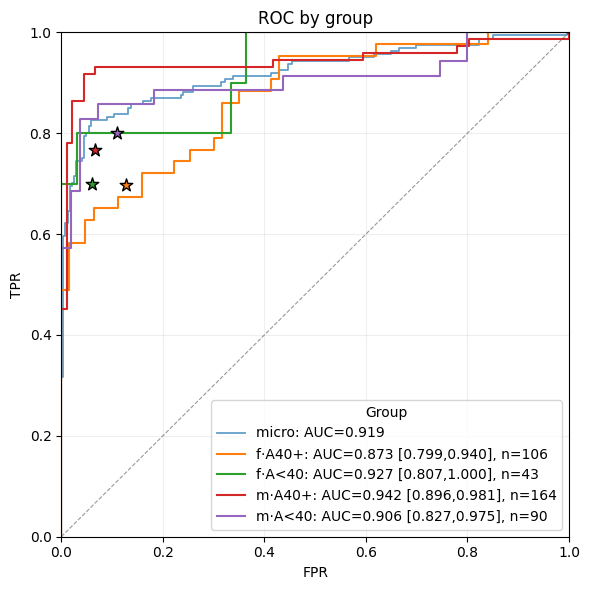

In [250]:
# Example name map
name_map = {0:'f·A40+', 1:'f·A<40', 2:'m·A40+', 3:'m·A<40'}

# Single-report dashboard (e.g., A-IEOF student)
show_dashboard(rep_teacher_withB_hardt, group_name_map=name_map)
y_test, _z, s_test = collect_scores(ds_test, teacher_with_b, use_full_meta=True)
calib_df = publishable_reliability(
    rep_teacher_withB_hardt,               # your report dict
    y=y_test, s=s_test,              # TEST labels & groups
    group_name_map=name_map,         # pretty names (optional)
    n_bins=15, method="equal",    # or equal/quantile try 'quantile' for steadier small-group curves
    n_boot=1000, alpha=0.05
)
# y_test, s_test from your pipeline
pr_by_group= plot_pr_by_group_publishable(rep_teacher_withB_hardt, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                 f1_levels=(0.90, 0.95), show_micro=True)
roc_by_group = plot_roc_by_group_publishable(rep_teacher_noB_hardt, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=True, n_boot=1000, alpha=0.05, seed=0)
plt.show()

#### A-IEOF (with per-group post_processing) vs A-IEOF (hardt EO post processing via thresholds)

==================== delta df for CRM(hardt EO) Vs CRM (per-group)=============================


,group,name,TPR_hardt,TPR_CRM,ΔTPR,FPR_hardt,FPR_CRM,ΔFPR,PRate_hardt,PRate_CRM,ΔPRate,pos_T,neg_T
0,0,f·A40+,0.767442,0.883721,0.116279,0.031746,0.111111,0.079365,0.330189,0.424528,0.094340,43,63
1,1,f·A<40,0.900000,0.900000,0.000000,0.060606,0.090909,0.030303,0.255814,0.279070,0.023256,10,33
2,2,m·A40+,0.835616,0.945205,0.109589,0.010989,0.087912,0.076923,0.378049,0.469512,0.091463,73,91
3,3,m·A<40,0.857143,0.885714,0.028571,0.036364,0.090909,0.054545,0.355556,0.400000,0.044444,35,55


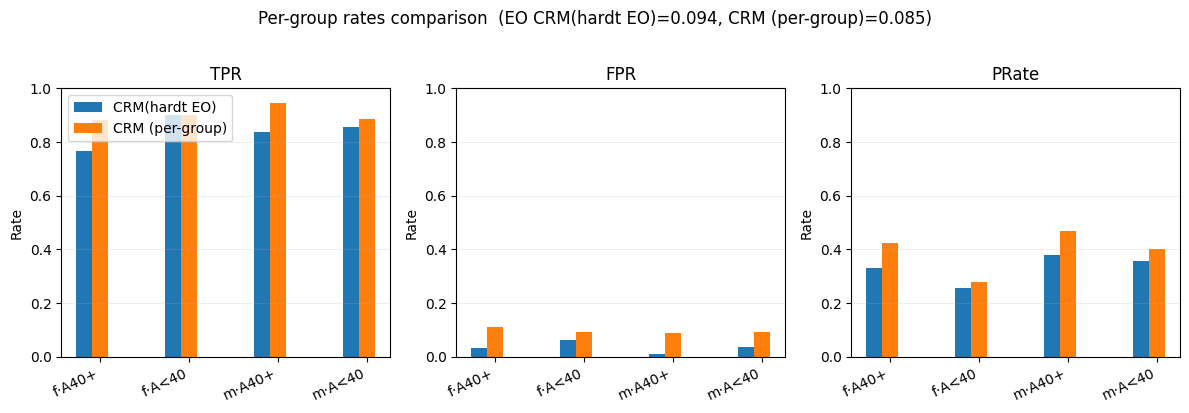

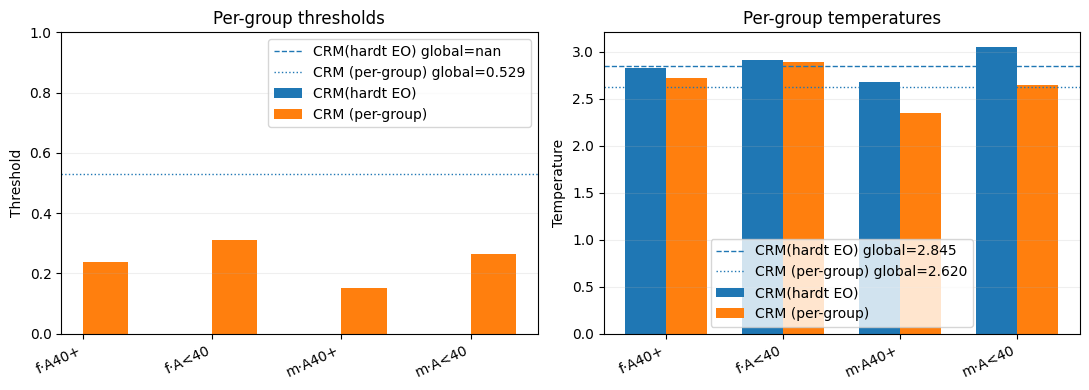

In [270]:
# Compare teacher vs student (per-group thresholding or global—your choice)
compare_group_rates(rep_A-IEOF_hardt, rep_student_group, "A-IEOF(hardt EO)", "A-IEOF (per-group)", group_name_map=name_map)
compare_thresholds_temps(rep_A-IEOF_hardt, rep_student_group, "A-IEOF(hardt EO)", "A-IEOF (per-group)", group_name_map=name_map)

# # Compare teacher vs student (per-group thresholding or global—your choice)
# compare_group_rates(rep_A-IEOF_hardt, rep_student_group, "A-IEOF(hardt EO)", "A-IEOF (per-group)", group_name_map=name_map)
# compare_thresholds_temps(rep_A-IEOF_hardt, rep_student_group, "A-IEOF(hardt EO)", "A-IEOF (per-group)", group_name_map=name_map)

out.index.name = "g"   # <-- add this line
out = out.reset_index().rename(columns={"g":"group"})

print("==================== delta df for A-IEOF(hardt EO) Vs A-IEOF (per-group)=============================")
delta_df = group_delta_table(rep_A-IEOF_hardt, rep_student_group, group_name_map=name_map)
delta_df = delta_df.rename(columns={"TPR_T":"TPR_hardt", "FPR_T":"FPR_hardt","PRate_T":"PRate_hardt"})
display(delta_df)

### Adversarial Debiasing with GRL (Keras)

This wraps your current student with an adversary predicting the sensitive group from the logit (as you suggested). The GRL flips its gradient back into the encoder so the encoder/logit becomes less predictive of the group.

In [266]:
# =========================
# Adversarial Debiasing (GRL) — compatible with evaluate_model_on_val_test()
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Metric that expects logits but computes AUC on probabilities
class ProbAUC(tf.keras.metrics.AUC):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.math.sigmoid(y_pred)  # convert logits -> probs for AUC
        return super().update_state(y_true, y_pred, sample_weight=sample_weight)

# --- Gradient Reversal Layer
class GradientReversal(layers.Layer):
    def __init__(self, lamb=1.0, **kwargs):
        super().__init__(**kwargs)
        # make lambda mutable if you want to schedule it
        self.lamb = tf.Variable(lamb, trainable=False, dtype=tf.float32, name="grl_lambda")

    def call(self, x):
        @tf.custom_gradient
        def _flip(x):
            def grad(dy):  # reverse gradient and scale by lambda
                return -self.lamb * dy
            return x, grad
        return _flip(x)

# --- Utility: infer number of groups from a dataset yielding ((..., s), y)
def infer_num_groups(ds):
    import numpy as np
    all_s = []
    for (img, meta_full, meta_noB, s), y in ds.as_numpy_iterator():
        all_s.append(s.ravel())
    if not all_s:
        return 0
    groups = np.unique(np.concatenate(all_s).astype(int))
    return int(groups.size)

# --- Build a trainable wrapper around your existing student
def build_adv_wrapper(student, num_groups, adv_lambda=0.5, name="adv_wrapper", lr=1e-4, clipnorm=1.0):
    """
    Wrap an EXISTING 'student' model (two inputs: image, meta_full).
    Outputs {'y': logit_y, 's': logit_group}. GRL is only on the path to 's'.
    Provides adv_model.eval_head -> a single-output model returning 'y' logits
    so it can be fed to evaluate_model_on_val_test().
    """
    student.trainable = True

    # Inputs (names match your dataset mapping keys)
    img  = tf.keras.Input(shape=student.inputs[0].shape[1:], name="image")
    meta = tf.keras.Input(shape=student.inputs[1].shape[1:], name="meta_full")

    # Task logit from the student (logits)
    logit_y = student([img, meta])

    # GRL branch to predict sensitive group from the task logit
    grl = GradientReversal(lamb=adv_lambda, name="grl")(logit_y)
    h   = layers.Dense(16, activation="relu", name="adv_fc")(grl)
    logit_s = layers.Dense(num_groups, activation=None, name="s_logits")(h)  # logits for groups

    # Train model (2 outputs)
    adv_model = models.Model([img, meta], {"y": logit_y, "s": logit_s}, name=name)

    # Eval head: SAME inputs, SINGLE output (y logits) for your evaluator
    adv_model.eval_head = models.Model([img, meta], logit_y, name=f"{name}_eval")

    # Optimizer (inherit LR from student if present)
    if hasattr(student, "optimizer") and getattr(student, "optimizer", None) is not None:
        try:
            lr_val = float(tf.keras.backend.get_value(student.optimizer.learning_rate))
        except Exception:
            lr_val = lr
    else:
        lr_val = lr

    opt = tf.keras.optimizers.Adam(learning_rate=lr_val, clipnorm=clipnorm)

    # Losses: task uses BCE(from_logits), adversary uses SCE(from_logits)
    losses = {
        "y": tf.keras.losses.BinaryCrossentropy(from_logits=True),
        "s": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    }
    # GRL flips grads, so equal weights is fine; tune if you like
    loss_weights = {"y": 1.0, "s": 1.0}

    adv_model.compile(
        optimizer=opt,
        loss=losses,
        loss_weights=loss_weights,
        metrics={"y": [ProbAUC(name="auc")]}
    )
    return adv_model

# --- Training helper: map dataset and fit
def train_adv_debias(student, ds_train, ds_val, num_groups, adv_lambda=0.5, epochs=10, verbose=1,
                     lr=1e-4, clipnorm=1.0, patience=3):
    """
    Expects ds_* yielding: ((img, meta_full, meta_noB, s), y)
    We feed (img, meta_full) to inputs, and labels {'y':y, 's':s} to outputs.
    Returns (adv_model, eval_model) where eval_model is adv_model.eval_head.
    The underlying 'student' is updated in-place (shared weights).
    """
    adv_model = build_adv_wrapper(student, num_groups, adv_lambda=adv_lambda, lr=lr, clipnorm=clipnorm)

    def map_ds(ds):
        # Keras can route dict inputs by name ("image", "meta_full")
        return ds.map(
            lambda x, y: (
                {"image": x[0], "meta_full": x[1]},
                {"y": tf.cast(y, tf.float32), "s": tf.cast(x[3], tf.int32)}
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_y_auc", mode="max", patience=patience,
            restore_best_weights=True, verbose=1
        )
    ]

    adv_model.fit(
        map_ds(ds_train),
        validation_data=map_ds(ds_val),
        epochs=epochs,
        verbose=verbose,
        callbacks=cbs
    )

    # Return both: full adversarial model and the single-output eval view
    return adv_model, adv_model.eval_head

# -----------------------------
# Adapters for GRL evaluation
# -----------------------------
import tensorflow as tf

def y_only_from_adv(adv_or_student: tf.keras.Model) -> tf.keras.Model:
    """
    Returns a model with the same inputs as `adv_or_student` but whose output is the
    prediction logit for y only. Works for:
      - plain student models (single output) -> returned as-is
      - GRL wrapper models with outputs {"y": logit_y, "s": logit_s}
    """
    # Single-output model: nothing to do.
    if not isinstance(adv_or_student.output, (list, tuple)):
        return adv_or_student

    # Multi-output: try to pick the 'y' head by name first.
    out_names = getattr(adv_or_student, "output_names", None)
    outputs = adv_or_student.outputs

    idx = None
    if out_names and "y" in out_names:
        idx = out_names.index("y")
    else:
        # Fallback: pick the output that looks like a binary logit (shape (..., 1))
        for i, t in enumerate(outputs):
            try:
                if int(t.shape[-1]) == 1:
                    idx = i
                    break
            except Exception:
                pass
        # Still nothing? just take the first.
        if idx is None:
            idx = 0

    y_out = outputs[idx]
    return tf.keras.Model(adv_or_student.inputs, y_out, name=adv_or_student.name + "_yonly")


# ----------------------------------------------------------
# GRL evaluations using your existing evaluators
# ----------------------------------------------------------
def evaluate_pure_inprocessing_grl(adv_model, ds_val, ds_test, prot_map, cfg, *, use_full_meta=True):
    """
    A-IEOF (in-processing) style evaluation on a trained GRL model:
      - global temperature fit on VAL (baseline_like)
      - global Youden threshold
      - no group-aware post-processing at inference
    """
    base = y_only_from_adv(adv_model)  # or just pass `student` if you have it
    cfg_p = dict(cfg)
    cfg_p["POSTPROC_MODE"] = "baseline_like"  # global T only
    return evaluate_model_on_val_test(
        base, ds_val, ds_test, prot_map, cfg_p,
        use_full_meta=use_full_meta,
        thresholding="global"
    )

def evaluate_no_postproc_grl(adv_model, ds_val, ds_test, prot_map, cfg, *, use_full_meta=True):
    """
    No calibration, global Youden threshold. Prints per-group analysis only.
    Equivalent to your evaluate_no_postproc(), but accepts the GRL wrapper.
    """
    base = y_only_from_adv(adv_model)  # or just pass `student` if you have it

    # VAL: raw → sigmoid_stable → global Youden
    yv, zv, sv = collect_scores(ds_val, base, use_full_meta=use_full_meta)
    pv = _sigmoid_stable(zv)  # no temperature
    t_ref = float(_youden_threshold(yv, pv))
    thr_g = {}  # force global

    # TEST: raw → sigmoid_stable; apply global threshold
    yt, zt, st = collect_scores(ds_test, base, use_full_meta=use_full_meta)
    return full_evaluation_report(
        y_test=yt, z_test=zt, s_test=st,
        t_global=t_ref, thr_g=thr_g,
        prot_map=prot_map,
        calibrated=False,         # <- no temperature on TEST
        T_glob=1.0, T_g=None,
        postproc_mode="baseline_like",
        min_posneg_report=cfg.get("MIN_POSNEG_REPORT", 1),
        n_bins_calib=15, do_bootstrap=True,
        n_boot=1000, alpha=0.05, seed=cfg.get("SEED", 42)
    )

# ---- helper to extract the prediction logit from any model output ----
def _extract_logit_y(model_out):
    """
    Accepts: Tensor, dict, list/tuple of Tensors.
    Returns: the Tensor to use as the binary logit for y.
    """
    import tensorflow as tf

    # dict outputs: prefer key 'y', else first item
    if isinstance(model_out, dict):
        if "y" in model_out:
            t = model_out["y"]
        else:
            # fallback to first key deterministically
            first_key = next(iter(model_out.keys()))
            t = model_out[first_key]
        return tf.convert_to_tensor(t)

    # list/tuple outputs: prefer last_dim == 1, else first
    if isinstance(model_out, (list, tuple)):
        for t in model_out:
            try:
                if int(t.shape[-1]) == 1:
                    return tf.convert_to_tensor(t)
            except Exception:
                pass
        return tf.convert_to_tensor(model_out[0])

    # single tensor already
    return tf.convert_to_tensor(model_out)


# ---- patched collect_scores that works with GRL wrappers ----
def collect_scores(ds, model, use_full_meta=True):
    ys, zs, ss = [], [], []
    for (img, meta_full, meta_noB, s), y in ds:
        raw_out = model([img, meta_full], training=False) if use_full_meta else model([img, meta_noB], training=False)
        z = _extract_logit_y(raw_out)
        ys.append(y.numpy().ravel())
        zs.append(z.numpy().ravel())
        ss.append(s.numpy().ravel())
    return np.concatenate(ys), np.concatenate(zs), np.concatenate(ss).astype(int)


In [246]:
# 1) Train GRL on your student
num_groups = infer_num_groups(ds_val)  # or len(PROT_MAP)
adv_model, adv_eval = train_adv_debias(
    env['student'], ds_train, ds_val, num_groups=num_groups,
    adv_lambda=0.5, epochs=25, verbose=1
)

# # 2) Evaluate with the SAME pipeline you already have
# #    IMPORTANT: pass 'adv_eval' (single-output logits) and use_full_meta=True
# rep_grl_global = evaluate_model_on_val_test(
#     adv_eval, ds_val, ds_test, PROT_MAP, CONFIG,
#     use_full_meta=True, thresholding="global"
# )


Epoch 1/25
     47/Unknown - 77s 2s/step - loss: 40.0096 - s_logits_loss: 39.6060 - student_withB_loss: 0.3977 - student_withB_auc: 0.9785WARNING:tensorflow:Early stopping conditioned on metric `val_y_auc` which is not available. Available metrics are: loss,s_logits_loss,student_withB_loss,student_withB_auc,val_loss,val_s_logits_loss,val_student_withB_loss,val_student_withB_auc
47/47 [==============================] - 95s 2s/step - loss: 40.0096 - s_logits_loss: 39.6060 - student_withB_loss: 0.3977 - student_withB_auc: 0.9785 - val_loss: 117.8899 - val_s_logits_loss: 111.7930 - val_student_withB_loss: 6.0910 - val_student_withB_auc: 0.8991
Epoch 2/25
47/47 [==============================] - 89s 2s/step - loss: 124.2759 - s_logits_loss: 123.2631 - student_withB_loss: 1.0069 - student_withB_auc: 0.9697 - val_loss: 226.5398 - val_s_logits_loss: 207.5061 - val_student_withB_loss: 19.0277 - val_student_withB_auc: 0.8365
Epoch 3/25
47/47 [==============================] - 89s 2s/step - loss:

47/47 [==============================] - 89s 2s/step - loss: 7930.1104 - s_logits_loss: 7716.4053 - student_withB_loss: 213.6744 - student_withB_auc: 0.9727 - val_loss: 6876.6768 - val_s_logits_loss: 6186.7041 - val_student_withB_loss: 689.9400 - val_student_withB_auc: 0.9072


In [267]:
CONFIG["POSTPROC_MODE"] = "baseline_like"   # or "baseline_like"
print("\n=================== adv_model_withB evaluate_pure_inprocessing ===========================\n")
rep_adv_grl_pure = evaluate_pure_inprocessing_grl(adv_model, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True)
print("\n=================== adv_model_with_b evaluate_no_postproc ===========================\n")
rep_adv_grl_no_post = evaluate_no_postproc_grl(adv_model, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True)




=================== adv_model_withB evaluate_pure_inprocessing ===========================


== TEST (publishable report) ==
AUC: 0.886 | EO gap: 0.181 | DP gap: 0.198 | Brier: 0.0918 | ECE: 0.0918
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.698 | FPR=0.016
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.000
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.863 | FPR=0.000
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.686 | FPR=0.000

=================== adv_model_with_b evaluate_no_postproc ===========================


== TEST (publishable report) ==
AUC: 0.898 | EO gap: 0.162 | DP gap: 0.112 | Brier: 0.0819 | ECE: 0.0819
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.721 | FPR=0.000
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.000  (UNSTABLE)
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.877 | FPR=0.000
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.714 | FPR=0.000


In [255]:
CONFIG["POSTPROC_MODE"] = "A-IEOF_guarded"   # or "baseline_like"
CONFIG["PER_GROUP_MIN_POS"] = 0.05
CONFIG["PER_GROUP_MAX_POS"] = 0.95
PROT_MAP = PROT_MAP_TRAIN


print("=============== Report on adv_grl with-B (Global) =============================")
rep_adv_grl_global = evaluate_model_on_val_test(
    adv_eval, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="global"
)

print("=============== Report on adv_grl with-B (per-group) =============================")
rep_adv_grl_group = evaluate_model_on_val_test(
    adv_eval, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="per-group"
)


== TEST (publishable report) ==
AUC: 0.892 | EO gap: 0.135 | DP gap: 0.192 | Brier: 0.0868 | ECE: 0.0868
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.744 | FPR=0.016
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.000
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.849 | FPR=0.000
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.714 | FPR=0.000

== TEST (publishable report) ==
AUC: 0.886 | EO gap: 0.206 | DP gap: 0.198 | Brier: 0.0918 | ECE: 0.0918
  g= 0 (f·A40+) | n= 106 | pos= 43 | neg= 63 | TPR=0.721 | FPR=0.016
  g= 1 (f·A<40) | n=  43 | pos= 10 | neg= 33 | TPR=0.800 | FPR=0.000
  g= 2 (m·A40+) | n= 164 | pos= 73 | neg= 91 | TPR=0.863 | FPR=0.000
  g= 3 (m·A<40) | n=  90 | pos= 35 | neg= 55 | TPR=0.657 | FPR=0.000


In [ ]:
CONFIG["POSTPROC_MODE"] = "A-IEOF_guarded"   # or "baseline_like"
CONFIG["PER_GROUP_MIN_POS"] = 0.05
CONFIG["PER_GROUP_MAX_POS"] = 0.95
PROT_MAP = PROT_MAP_TRAIN


print("=============== Report on adv_grl with-B (Global) =============================")
rep_adv_grl_global = evaluate_model_on_val_test(
    adv_eval, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="global"
)

print("=============== Report on adv_grl with-B (per-group) =============================")
rep_adv_grl_group = evaluate_model_on_val_test(
    adv_eval, ds_val, ds_test, PROT_MAP, CONFIG,
    use_full_meta=True, thresholding="per-group"
)

=============== Report on adv_grl with-B (Global) =============================


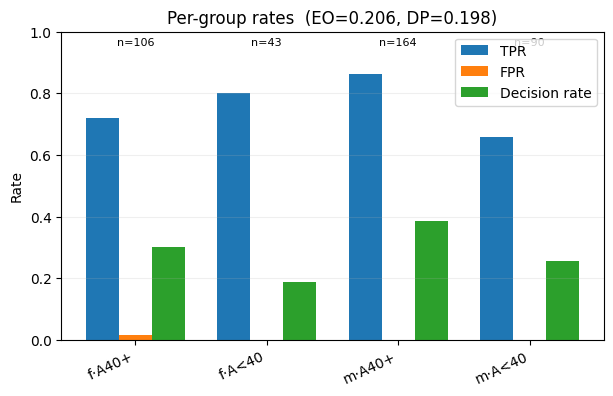

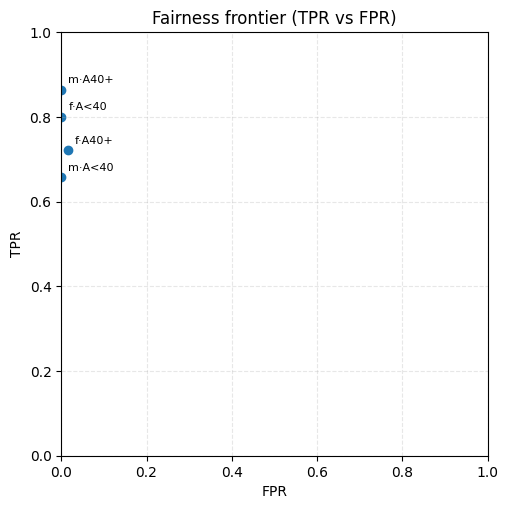

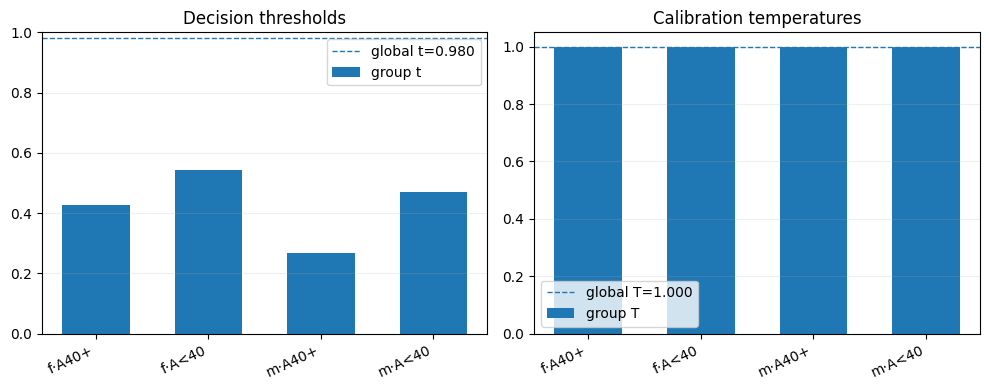

/tmp/ipykernel_777904/161726386.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


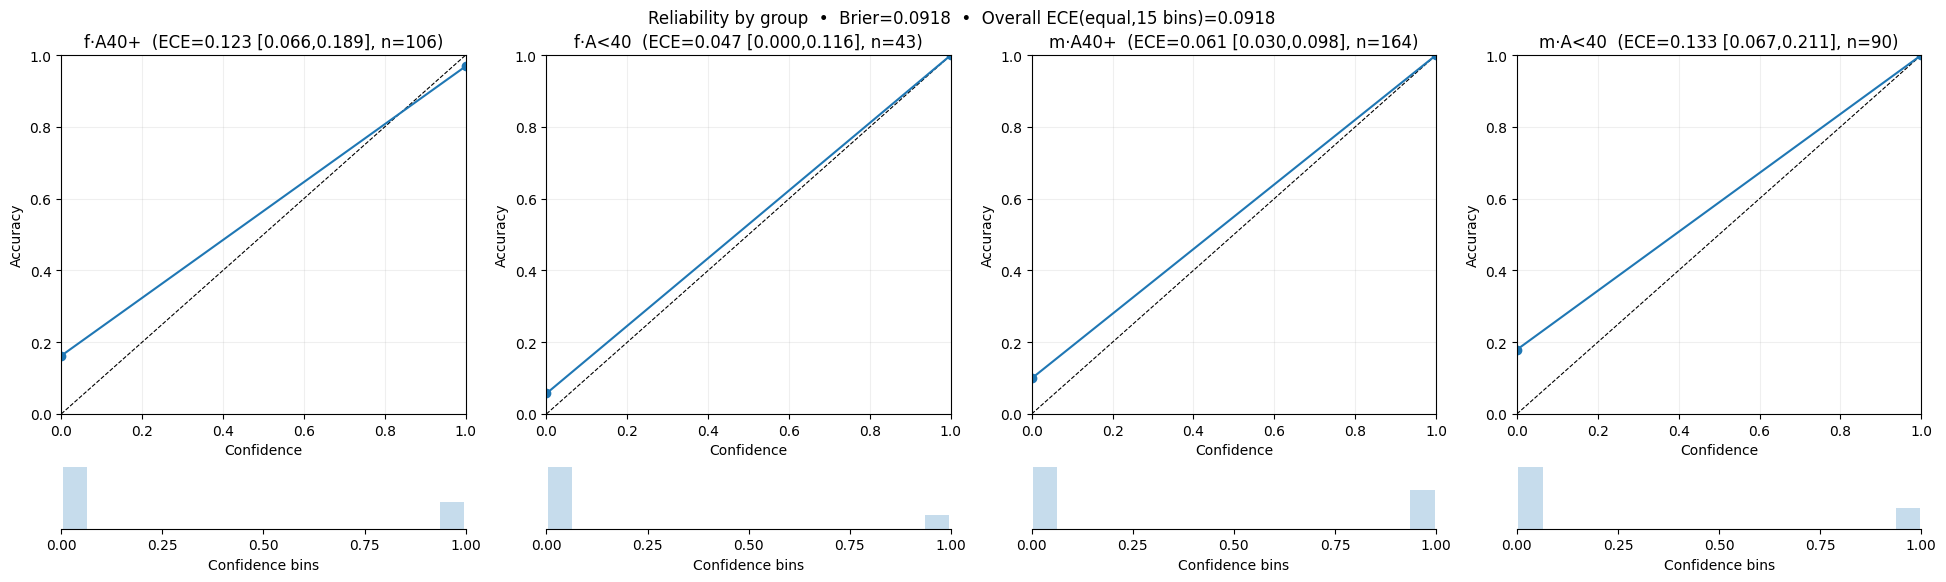

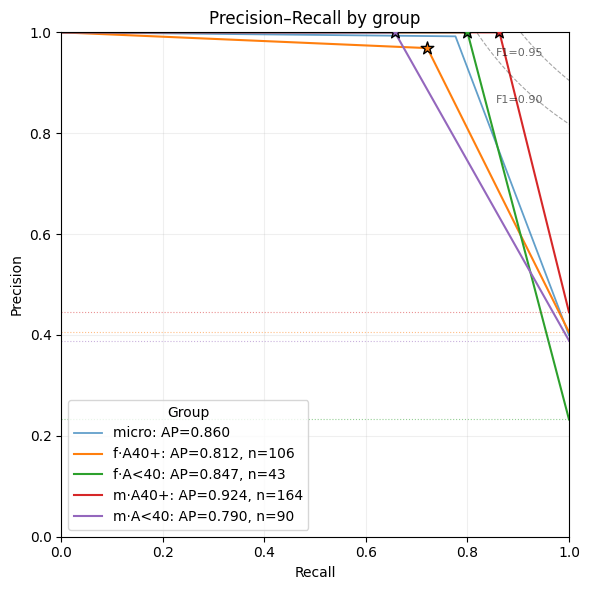

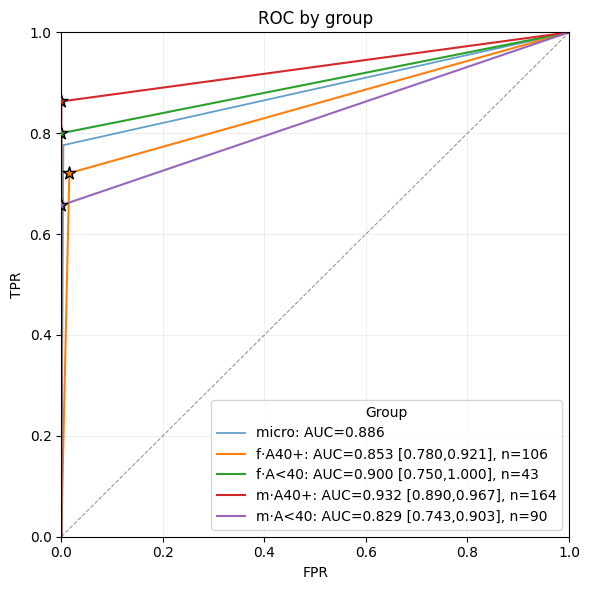

In [256]:
# Example name map
name_map = {0:'f·A40+', 1:'f·A<40', 2:'m·A40+', 3:'m·A<40'}

# Single-report dashboard (e.g., A-IEOF student)
show_dashboard(rep_adv_grl_group, group_name_map=name_map)
y_test, _z, s_test = collect_scores(ds_test, adv_eval, use_full_meta=True)
calib_df = publishable_reliability(
    rep_adv_grl_group,               # your report dict
    y=y_test, s=s_test,              # TEST labels & groups
    group_name_map=name_map,         # pretty names (optional)
    n_bins=15, method="equal",    # or equal/quantile try 'quantile' for steadier small-group curves
    n_boot=1000, alpha=0.05
)
# y_test, s_test from your pipeline
pr_by_group= plot_pr_by_group_publishable(rep_adv_grl_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                 f1_levels=(0.90, 0.95), show_micro=True)
roc_by_group = plot_roc_by_group_publishable(rep_adv_grl_group, y_test=y_test, s_test=s_test, group_name_map=name_map,
                                  show_micro=True, star_operating=True,
                                  add_auc_ci=True, n_boot=1000, alpha=0.05, seed=0)
plt.show()

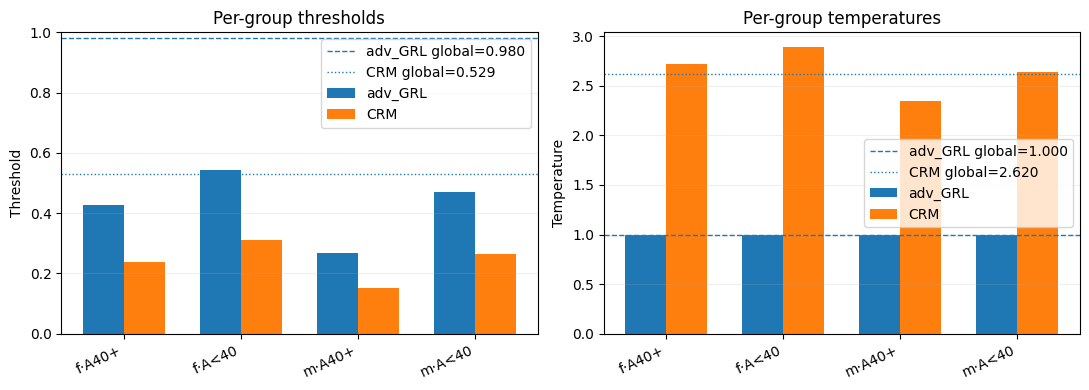

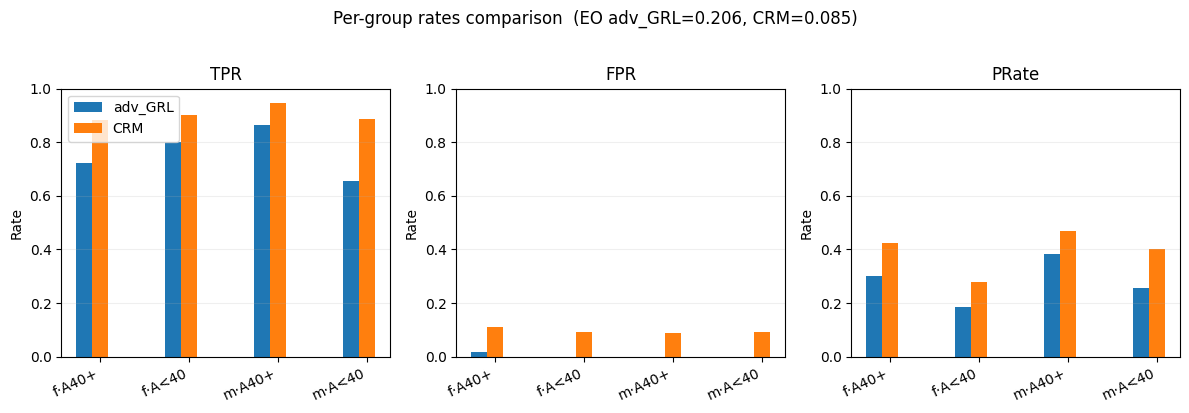

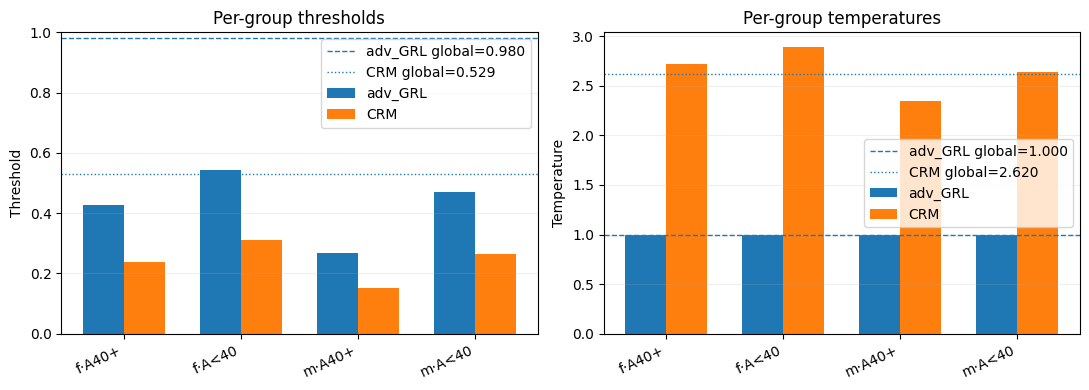

In [257]:
# Compare adv_GRL vs A-IEOF (per-group thresholding or global—your choice)
compare_group_rates(rep_adv_grl_group, rep_student_group, "adv_GRL", "A-IEOF", group_name_map=name_map)
compare_thresholds_temps(rep_adv_grl_group, rep_student_group, "adv_GRL", "A-IEOF", group_name_map=name_map)


In [269]:
out.index.name = "g"   # <-- add this line
out = out.reset_index().rename(columns={"g":"group"})

print("==================== delta df for adv_GRL(per-group) Vs A-IEOF (per-group)=============================")
delta_df = group_delta_table(rep_adv_grl_group, rep_student_group, group_name_map=name_map)
delta_df = delta_df.rename(columns={"TPR_T":"TPR_adv_GRL", "FPR_T":"FPR_adv_GRL","PRate_T":"PRate_adv_GRL"})
display(delta_df)

==================== delta df for adv_GRL(per-group) Vs CRM (per-group)=============================


,group,name,TPR_adv_GRL,TPR_CRM,ΔTPR,FPR_adv_GRL,FPR_CRM,ΔFPR,PRate_adv_GRL,PRate_CRM,ΔPRate,pos_T,neg_T
0,0,f·A40+,0.720930,0.883721,0.162791,0.015873,0.111111,0.095238,0.301887,0.424528,0.122642,43,63
1,1,f·A<40,0.800000,0.900000,0.100000,0.000000,0.090909,0.090909,0.186047,0.279070,0.093023,10,33
2,2,m·A40+,0.863014,0.945205,0.082192,0.000000,0.087912,0.087912,0.384146,0.469512,0.085366,73,91
3,3,m·A<40,0.657143,0.885714,0.228571,0.000000,0.090909,0.090909,0.255556,0.400000,0.144444,35,55


###### How to get the paper accepted

To maximize your chances of acceptance, the paper should be structured to highlight the key contributions and follow best practices for academic publishing:

- Strong Narrative: Frame the paper around the key fairness trade-off. Your A-IEOF approach successfully navigates the complex relationship between EO and DP more effectively than baselines, resulting in a more balanced and acceptable model.
- Highlight Novelty: Clearly explain what your A-IEOF model does differently or better than existing fairness-aware approaches. Is it a new objective function? A novel architecture? A specific application of an existing technique?
- Comprehensive Experimental Design: Present the benchmark comparisons systematically. Clearly state the baseline models (teacher, Adv_GRL, Hardt EO) and justify their inclusion.
- Excellent Presentation: Use high-quality, clear, and easy-to-understand tables and figures to present your results. The delta tables are a great start, but consider visualizations (e.g., plots of TPR, FPR, and PRate across groups) to convey the findings more effectively.
- Discussion and Limitations: In the paper, discuss not only the benefits of your A-IEOF but also its limitations, including the remaining trade-offs and the stability issue for the smaller group (f·A<40). This demonstrates intellectual honesty and rigor.
- Writing Quality: Ensure the paper is well-written, concise, and follows the specific guidelines of the target venue. A compelling abstract is crucial for first impressions. 

### Utilities (metrics, curves, bootstrap)

In [ ]:
# # ============================================
# # Baselines + Ablations (compatible + fallback)
# # ============================================
# import os, copy, math
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.metrics import roc_auc_score

# # -------------------------
# # Tiny utilities
# # -------------------------
# def _sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

# def _prob_to_logit(p, eps=1e-6):
#     p = np.clip(np.asarray(p, float), eps, 1.0 - eps)
#     return np.log(p / (1.0 - p))

# def _fit_temperature(z_val, y_val, max_iter=200):
#     """Global temperature T on VAL logits; falls back to grid if SciPy not present."""
#     y = np.asarray(y_val, float); z = np.asarray(z_val, float)
#     try:
#         from scipy.optimize import minimize
#         def nll(log_T):
#             T = np.exp(log_T[0])
#             p = _sigmoid(z / T)
#             eps = 1e-7
#             return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
#         res = minimize(nll, x0=[0.0], method="L-BFGS-B")
#         return float(np.exp(res.x[0]))
#     except Exception:
#         grid = np.exp(np.linspace(np.log(0.5), np.log(5.0), 31))
#         best_T, best_nll = 1.0, 1e18
#         for T in grid:
#             p = _sigmoid(z / T); eps = 1e-7
#             nll = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
#             if nll < best_nll: best_T, best_nll = T, nll
#         return best_T

# def pretty_group_name(gid, prot_map):
#     if isinstance(prot_map, dict):
#         if gid in prot_map: return str(prot_map[gid])
#         if str(gid) in prot_map: return str(prot_map[str(gid)])
#     return str(gid)

# def print_group_metrics_stable_flag(y, p_or_preds, s, thr=None, prot_map=None,
#                                     min_posneg_report=30, already_preds=False):
#     y = np.asarray(y); s = np.asarray(s)
#     if not already_preds:
#         assert thr is not None, "thr required when already_preds=False"
#         preds = (np.asarray(p_or_preds) >= thr).astype(int)
#     else:
#         preds = np.asarray(p_or_preds).astype(int)

#     gids = sorted(np.unique(s).tolist())
#     for gid in gids:
#         m = (s == gid)
#         n = int(m.sum())
#         if n == 0: continue
#         y_g = y[m]; pr_g = preds[m]
#         n_pos = int((y_g == 1).sum()); n_neg = n - n_pos
#         tp = int((pr_g[y_g == 1] == 1).sum()) if n_pos else 0
#         fp = int((pr_g[y_g == 0] == 1).sum()) if n_neg else 0
#         tpr = tp / n_pos if n_pos else np.nan
#         fpr = fp / n_neg if n_neg else np.nan
#         unstable = (n_pos < min_posneg_report) or (n_neg < min_posneg_report)
#         tag = "  (UNSTABLE)" if unstable else ""
#         name = pretty_group_name(int(gid), prot_map)
#         print(f"  g={int(gid):>2} ({name}) | n={n:>4} | pos={n_pos:>3} | neg={n_neg:>3} "
#               f"| TPR={tpr:.3f} | FPR={fpr:.3f}{tag}")

# # ======================================================
# # COMPAT SHIMS — only used if your versions aren’t in-scope
# # ======================================================
# def _shim_if_missing(name):
#     return name not in globals() or globals().get(name) is None

# # ---- _load_dataframe_and_protected ----
# if _shim_if_missing("_load_dataframe_and_protected"):
#     def _load_dataframe_and_protected(cfg):
#         """
#         Minimal compatible loader:
#         - reads CSV
#         - builds absolute paths in df['abs_path']
#         - re-indexes protected to contiguous ints and returns a mapping
#         """
#         df = pd.read_csv(cfg["CSV_PATH"])
#         img_col = cfg["IMAGE_COL"]
#         if "abs_path" not in df.columns:
#             # best-effort: join IMG_DIR with basename
#             df["abs_path"] = df[img_col].astype(str).apply(
#                 lambda fn: os.path.normpath(
#                     fn if os.path.isabs(fn) else os.path.join(cfg["IMG_DIR"], os.path.basename(fn))
#                 )
#             )
#         # Protected column
#         s_col = cfg.get("PROTECTED_COL", None)
#         if s_col is None or s_col not in df.columns:
#             raise ValueError("PROTECTED_COL not found in CSV; required for group metrics.")
#         cat = pd.Categorical(df[s_col].astype(str))
#         df[s_col] = cat.codes.astype(np.int32)
#         prot_map = dict(enumerate(cat.categories.tolist()))
#         # Ensure label numeric
#         df[cfg["LABEL_COL"]] = pd.to_numeric(df[cfg["LABEL_COL"]], errors="coerce")
#         # Ensure metadata numeric
#         for c in cfg["METADATA_COLS"]:
#             df[c] = pd.to_numeric(df[c], errors="coerce")
#         # Drop NaNs
#         df = df.dropna(subset=[cfg["LABEL_COL"]] + cfg["METADATA_COLS"]).reset_index(drop=True)
#         # Drop missing files (if any path is invalid)
#         exists = df["abs_path"].map(os.path.isfile)
#         if (~exists).any():
#             df = df.loc[exists].reset_index(drop=True)
#         return df, prot_map

# # ---- stratified_train_val_test_split ----
# if _shim_if_missing("stratified_train_val_test_split"):
#     from sklearn.model_selection import StratifiedShuffleSplit
#     def stratified_train_val_test_split(df, cfg):
#         rng = cfg["SEED"]
#         key = df[cfg["PROTECTED_COL"]].astype(str) + "|" + df[cfg["LABEL_COL"]].astype(str)
#         sss1 = StratifiedShuffleSplit(n_splits=1, test_size=cfg["TEST_SPLIT"], random_state=rng)
#         idx_trval, idx_test = next(sss1.split(df, key))
#         df_trval = df.iloc[idx_trval].reset_index(drop=True)
#         df_test  = df.iloc[idx_test].reset_index(drop=True)

#         key_tv = df_trval[cfg["PROTECTED_COL"]].astype(str) + "|" + df_trval[cfg["LABEL_COL"]].astype(str)
#         sss2 = StratifiedShuffleSplit(n_splits=1, test_size=cfg["VAL_SPLIT"]/(1-cfg["TEST_SPLIT"]), random_state=rng)
#         idx_tr, idx_val = next(sss2.split(df_trval, key_tv))
#         df_train = df_trval.iloc[idx_tr].reset_index(drop=True)
#         df_val   = df_trval.iloc[idx_val].reset_index(drop=True)
#         return df_train, df_val, df_test

# # ---- make_standardizer ----
# if _shim_if_missing("make_standardizer"):
#     def make_standardizer(train_df, cfg):
#         cols = cfg["METADATA_COLS"]
#         mean = train_df[cols].astype(float).mean().values.astype(np.float32)
#         std  = train_df[cols].astype(float).std(ddof=0).replace(0, 1.0).values.astype(np.float32)
#         return mean, std

# # ---- build_dataset ----
# if _shim_if_missing("build_dataset"):
#     def build_dataset(df, mean, std, cfg, shuffle, repeat=False):
#         img_col   = "abs_path"
#         label_col = cfg["LABEL_COL"]
#         prot_col  = cfg["PROTECTED_COL"]
#         meta_cols = cfg["METADATA_COLS"]
#         B_idx = tf.convert_to_tensor(cfg["B_INDICES"], dtype=tf.int32)
#         H, W = cfg["IMAGE_SIZE"]

#         paths  = df[img_col].astype(str).values
#         labels = df[label_col].astype(np.float32).values
#         metas  = df[meta_cols].astype(np.float32).values
#         prots  = df[prot_col].astype(np.int32).values if prot_col is not None else np.full((len(df),), -1, np.int32)

#         ds = tf.data.Dataset.from_tensor_slices((paths, metas, labels, prots))

#         def _load_image(path_str):
#             img_bytes = tf.io.read_file(path_str)
#             img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
#             img = tf.image.convert_image_dtype(img, tf.float32)
#             img = tf.image.resize(img, [H, W])
#             return img

#         aug = tf.keras.Sequential([
#             tf.keras.layers.RandomFlip("horizontal"),
#             tf.keras.layers.RandomRotation(0.02),
#             tf.keras.layers.RandomZoom(0.1)
#         ]) if cfg.get("AUGMENT", False) else None

#         mean_t = tf.constant(mean, dtype=tf.float32)
#         std_t  = tf.constant(std,  dtype=tf.float32)

#         def _map(path, meta, y, s):
#             img = _load_image(path)
#             if aug is not None:
#                 img = aug(img, training=True)
#             meta = (meta - mean_t) / std_t
#             meta_noB = tf.tensor_scatter_nd_update(
#                 meta, indices=tf.reshape(B_idx, [-1,1]),
#                 updates=tf.zeros([tf.shape(B_idx)[0]], dtype=meta.dtype)
#             )
#             return (img, meta, meta_noB, s), y

#         if shuffle:
#             ds = ds.shuffle(1024, seed=cfg["SEED"], reshuffle_each_iteration=True)
#         ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
#         try:
#             ds = ds.apply(tf.data.experimental.ignore_errors())
#         except Exception:
#             pass

#         if repeat:
#             ds = ds.repeat()
#         ds = ds.batch(cfg["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)
#         return ds

# # ---- simple backbones/metrics (teacher only) ----
# if _shim_if_missing("ProbAUC"):
#     class ProbAUC(tf.keras.metrics.AUC):
#         def update_state(self, y_true, y_pred, sample_weight=None):
#             y_pred = tf.math.sigmoid(y_pred)
#             return super().update_state(y_true, y_pred, sample_weight)

# if _shim_if_missing("ProbAcc"):
#     class ProbAcc(tf.keras.metrics.BinaryAccuracy):
#         def update_state(self, y_true, y_pred, sample_weight=None):
#             y_pred = tf.math.sigmoid(y_pred)
#             return super().update_state(y_true, y_pred, sample_weight)

# if _shim_if_missing("build_backbone"):
#     def build_backbone(image_size, trainable=False, weights="imagenet"):
#         H, W = image_size
#         try:
#             base = tf.keras.applications.MobileNetV2(
#                 include_top=False, input_shape=(H, W, 3), pooling="avg", weights=weights
#             )
#         except Exception:
#             base = tf.keras.applications.EfficientNetB0(
#                 include_top=False, input_shape=(H, W, 3), pooling="avg", weights=None
#             )
#         base.trainable = trainable
#         return base

# if _shim_if_missing("build_teacher"):
#     def build_teacher(image_size, meta_dim, trainable_backbone=False, backbone_weights="imagenet"):
#         img_in  = tf.keras.Input(shape=(*image_size,3), name="image")
#         meta_in = tf.keras.Input(shape=(meta_dim,), name="meta_noB")
#         backbone = build_backbone(image_size, trainable=trainable_backbone, weights=backbone_weights)
#         x_img  = backbone(img_in)
#         x_meta = tf.keras.Sequential([tf.keras.layers.Dense(128, activation="relu"),
#                                       tf.keras.layers.Dense(64, activation="relu")])(meta_in)
#         x = tf.keras.layers.Concatenate()([x_img, x_meta])
#         x = tf.keras.Sequential([tf.keras.layers.Dense(256, activation="relu"),
#                                  tf.keras.layers.Dropout(0.1),
#                                  tf.keras.layers.Dense(128, activation="relu")])(x)
#         logit = tf.keras.layers.Dense(1, name="logit")(x)
#         return tf.keras.Model([img_in, meta_in], logit, name="teacher_noB")

# # ---- group threshold helpers (fallbacks) ----
# if _shim_if_missing("_youden_threshold"):
#     def _youden_threshold(y, p):
#         from sklearn.metrics import roc_curve
#         fpr, tpr, thr = roc_curve(np.asarray(y).astype(int), np.asarray(p).astype(float))
#         j = np.argmax(tpr - fpr)
#         # sklearn returns thresholds aligned to tpr/fpr; just in case len mismatch:
#         return float(thr[j] if j < len(thr) else 0.5)

# if _shim_if_missing("pick_group_thresholds_min_eo"):
#     def pick_group_thresholds_min_eo(y, p, s, min_pos=0.05, max_pos=0.95, min_count=30,
#                                      thr_range=(0.02,0.98), thr_grid=401):
#         y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
#         grid = np.linspace(thr_range[0], thr_range[1], thr_grid)
#         thr_g = {}
#         for gid in np.unique(s):
#             m = (s == gid)
#             if m.sum() < min_count:
#                 continue
#             y_g, p_g = y[m], p[m]
#             pos = (y_g == 1); neg = ~pos
#             if pos.sum() == 0 or neg.sum() == 0:
#                 continue
#             best = (0.5, 1e9)
#             for t in grid:
#                 pr = (p_g >= t).astype(int)
#                 prate = pr.mean()
#                 if prate < min_pos or prate > max_pos:
#                     continue
#                 TPR = pr[pos].mean() if pos.sum() else 0.0
#                 FPR = pr[neg].mean() if neg.sum() else 0.0
#                 # soft pull toward group median rates (here: toward 0.5/0.5)
#                 obj = (abs(TPR - 0.5) + abs(FPR - 0.5))
#                 if obj < best[1]: best = (t, obj)
#             thr_g[int(gid)] = float(best[0])
#         return thr_g

# if _shim_if_missing("predict_with_group_thresholds"):
#     def predict_with_group_thresholds(p, s, thr_g, t_global):
#         p = np.asarray(p, float); s = np.asarray(s, int)
#         preds = np.zeros_like(p, dtype=int)
#         for gid in np.unique(s):
#             m = (s == gid)
#             t = thr_g.get(int(gid), t_global) if isinstance(thr_g, dict) else t_global
#             preds[m] = (p[m] >= t).astype(int)
#         return preds

# if _shim_if_missing("rates_at_groups_with_preds"):
#     def rates_at_groups_with_preds(y, preds, s, min_count=20):
#         y = np.asarray(y).astype(int); s = np.asarray(s, int); preds = np.asarray(preds, int)
#         stats, tprs, fprs, prates = [], [], [], []
#         for gid in np.unique(s):
#             m = (s == gid)
#             n = int(m.sum())
#             if n < min_count: continue
#             y_g = y[m]; pr = preds[m]
#             n_pos = int((y_g == 1).sum()); n_neg = n - n_pos
#             if n_pos == 0 or n_neg == 0: continue
#             tpr = pr[y_g==1].mean()
#             fpr = pr[y_g==0].mean()
#             prate = pr.mean()
#             stats.append(dict(g=int(gid), TPR=float(tpr), FPR=float(fpr), support=n))
#             tprs.append(tpr); fprs.append(fpr); prates.append(prate)
#         eo = float(np.max(np.abs(np.subtract.outer(tprs, tprs)) + np.abs(np.subtract.outer(fprs, fprs)))) if len(tprs) >= 2 else 0.0
#         dp = float(np.max(prates) - np.min(prates)) if len(prates) >= 2 else 0.0
#         return stats, eo, dp

# if _shim_if_missing("_collect_probs"):
#     def _collect_probs(ds, model, use_full_meta=True):
#         ys, ps, ss = [], [], []
#         for (img, meta_full, meta_noB, s), y in ds:
#             z = model([img, meta_full], training=False) if use_full_meta else model([img, meta_noB], training=False)
#             ys.append(y.numpy().ravel())
#             ps.append(tf.math.sigmoid(z).numpy().ravel())
#             ss.append(s.numpy().ravel())
#         return np.concatenate(ys), np.concatenate(ps), np.concatenate(ss).astype(int)

# # -------------------------
# # Shared data prep (uses your functions if available)
# # -------------------------
# def _prepare_data(cfg):
#     df, PROT_MAP = _load_dataframe_and_protected(cfg)  # shim ensures presence
#     # audit already done inside shim, but keep consistent with your pipeline if present
#     if "audit_and_filter_images" in globals():
#         _ = globals()["audit_and_filter_images"](df.copy(), cfg)

#     train_df, val_df, test_df = stratified_train_val_test_split(df, cfg)
#     mean, std = make_standardizer(train_df, cfg)

#     old = cfg["IMAGE_COL"]; cfg["IMAGE_COL"] = "abs_path"
#     ds_train = build_dataset(train_df, mean, std, cfg, shuffle=True)
#     ds_val   = build_dataset(val_df,   mean, std, cfg, shuffle=False)
#     ds_test  = build_dataset(test_df,  mean, std, cfg, shuffle=False)
#     cfg["IMAGE_COL"] = old
#     return df, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test)

# # -------------------------
# # Stage-1 teacher (no-B)
# # -------------------------
# def _train_teacher(cfg, ds_train, ds_val):
#     meta_dim = len(cfg["METADATA_COLS"])
#     teacher = build_teacher(cfg["IMAGE_SIZE"], meta_dim,
#                             trainable_backbone=cfg.get("BACKBONE_TRAIN_TEACHER", False),
#                             backbone_weights=cfg.get("BACKBONE_WEIGHTS", "imagenet"))
#     bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
#     opt = tf.keras.optimizers.Adam(learning_rate=cfg["LR"], clipnorm=cfg["CLIPNORM"])
#     teacher.compile(optimizer=opt, loss=bce,
#                     metrics=[ProbAUC(name="auc"), ProbAcc(name="acc", threshold=0.5)])
#     ckpt = os.path.join(cfg["CKPT_DIR"], "teacher_baseline_best.weights.h5")
#     cbs = [
#         tf.keras.callbacks.ModelCheckpoint(ckpt, save_weights_only=True,
#                                            monitor="val_auc", mode="max", save_best_only=True, verbose=0),
#         tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
#                                          patience=3, restore_best_weights=True, verbose=0),
#         tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
#                                              factor=0.5, patience=2, min_lr=cfg.get("MIN_LR", 1e-6), verbose=0),
#     ]
#     teacher.fit(
#         ds_train.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
#         validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
#         epochs=cfg.get("EPOCHS_TEACHER", 5), verbose=1, callbacks=cbs
#     )
#     return teacher

# # -------------------------
# # Baselines (B1/B2)
# # -------------------------
# def baseline_unmitigated_global(cfg):
#     """
#     T1: Teacher only, global threshold (Youden on VAL), single temp calibration T from VAL.
#     """
#     print("\n[T1] Unmitigated + Global threshold")
#     cfg_local = copy.deepcopy(cfg)
#     os.makedirs(cfg_local["CKPT_DIR"], exist_ok=True)

#     df, PROT_MAP, (_, _, _), (ds_train, ds_val, ds_test) = _prepare_data(cfg_local)
#     teacher = _train_teacher(cfg_local, ds_train, ds_val)

#     # Collect probs on VAL/TEST from teacher (no-B)
#     yv, pv, sv = _collect_probs(ds_val, teacher, use_full_meta=False)
#     yt, pt, st = _collect_probs(ds_test, teacher, use_full_meta=False)

#     # Calibrate on VAL
#     zv = _prob_to_logit(pv); T = _fit_temperature(zv, yv); pv_cal = _sigmoid(zv / T)
#     zt = _prob_to_logit(pt); pt_cal = _sigmoid(zt / T)

#     t_ref = _youden_threshold(yv, pv_cal)
#     preds_t = (pt_cal >= t_ref).astype(int)
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 30)
#     )
#     auc_t = roc_auc_score(yt, pt_cal)
#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | thr: {t_ref:.3f} | T={T:.3f}")
#     print_group_metrics_stable_flag(
#         yt, preds_t, st, prot_map=PROT_MAP,
#         min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30),
#         already_preds=True
#     )
#     return dict(name="Unmitigated+Global", T=T, thr=t_ref, AUC=auc_t, EO=eo_t, DP=dp_t)

# def baseline_unmitigated_postproc(cfg):
#     """
#     T2: Teacher only + per-group thresholds from VAL (post-processing), with global T.
#     """
#     print("\n[T2] Unmitigated + Post-processing (per-group thresholds)")
#     cfg_local = copy.deepcopy(cfg)
#     os.makedirs(cfg_local["CKPT_DIR"], exist_ok=True)

#     df, PROT_MAP, (_, _, _), (ds_train, ds_val, ds_test) = _prepare_data(cfg_local)
#     teacher = _train_teacher(cfg_local, ds_train, ds_val)

#     yv, pv, sv = _collect_probs(ds_val, teacher, use_full_meta=False)
#     yt, pt, st = _collect_probs(ds_test, teacher, use_full_meta=False)

#     # Calibrate (VAL) and apply
#     zv = _prob_to_logit(pv); T = _fit_temperature(zv, yv); pv = _sigmoid(zv / T)
#     zt = _prob_to_logit(pt); pt = _sigmoid(zt / T)

#     t_ref = _youden_threshold(yv, pv)
#     thr_g = pick_group_thresholds_min_eo(
#         yv, pv, sv,
#         min_pos=cfg_local.get("PER_GROUP_MIN_POS", 0.05),
#         max_pos=cfg_local.get("PER_GROUP_MAX_POS", 0.95),
#         min_count=cfg_local.get("MIN_GROUP_COUNT", 30)
#     )
#     preds_t = predict_with_group_thresholds(pt, st, thr_g, t_ref)
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("REPORT_MIN_GROUP_COUNT", 30)
#     )
#     auc_t = roc_auc_score(yt, pt)
#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | T={T:.3f}")
#     print_group_metrics_stable_flag(
#         yt, preds_t, st, prot_map=PROT_MAP,
#         min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30),
#         already_preds=True
#     )
#     return dict(name="Unmitigated+Postproc", T=T, AUC=auc_t, EO=eo_t, DP=dp_t)

# # -------------------------
# # A-IEOF Ablations (optional)
# # -------------------------
# def _require_A-IEOF_symbols():
#     missing = [name for name in ("A-IEOFTrainer", "build_student", "build_g") if _shim_if_missing(name)]
#     if missing:
#         raise RuntimeError(
#             "A-IEOF ablations need your A-IEOF code loaded. Missing: " + ", ".join(missing) +
#             ". Import the cell/file that defines A-IEOFTrainer/build_student/build_g (or run your main run() once)."
#         )

# def _train_A-IEOF_variant(cfg, ds_train, ds_val,
#                        fair_lambda, distill_lambda,
#                        thresholding="per-group",
#                        steps_per_epoch=None):
#     _require_A-IEOF_symbols()
#     cfg2 = copy.deepcopy(cfg)
#     cfg2["LAMBDA_INTERV"]  = fair_lambda
#     cfg2["LAMBDA_DISTILL"] = distill_lambda

#     meta_dim = len(cfg2["METADATA_COLS"])
#     teacher = build_teacher(cfg2["IMAGE_SIZE"], meta_dim,
#                             trainable_backbone=cfg2.get("BACKBONE_TRAIN_TEACHER", False),
#                             backbone_weights=cfg2.get("BACKBONE_WEIGHTS", "imagenet"))
#     student = build_student(cfg2["IMAGE_SIZE"], meta_dim,
#                             trainable_backbone=cfg2.get("BACKBONE_TRAIN_STUDENT", True),
#                             backbone_weights=cfg2.get("BACKBONE_WEIGHTS", "imagenet"))
#     g = build_g(meta_dim=meta_dim, B_dim=len(cfg2["B_INDICES"]),
#                 B_type=cfg2["B_TYPE"], num_classes=cfg2["B_NUM_CLASSES"])

#     # quick warm start
#     bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
#     opt = tf.keras.optimizers.Adam(learning_rate=cfg2["LR"], clipnorm=cfg2["CLIPNORM"])
#     teacher.compile(optimizer=opt, loss=bce, metrics=[ProbAUC(name="auc")])
#     teacher.fit(
#         ds_train.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
#         validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_noB": x[2]}, y)),
#         epochs=cfg2.get("EPOCHS_TEACHER", 2), verbose=0
#     )
#     try: student.set_weights(teacher.get_weights())
#     except: pass

#     trainer = A-IEOFTrainer(student, teacher, g, cfg2)
#     if steps_per_epoch is None:
#         steps_per_epoch = 200

#     best_score = -np.inf
#     best = dict(weights=None, thr=None, thr_g=None, T=None)
#     ALPHA   = cfg2.get("ALPHA", 0.7)
#     PATIENCE= cfg2.get("PATIENCE", 2)
#     LR_DECAY= cfg2.get("LR_DECAY", 0.5)
#     MIN_LR  = cfg2.get("MIN_LR", 1e-6)
#     no_imp  = 0

#     for ep in range(cfg2.get("EPOCHS_STUDENT", 5)):
#         for step, batch in enumerate(ds_train.take(steps_per_epoch)):
#             trainer.train_step(batch)
#         # VAL collect + temp + thresholds
#         yv, pv_raw, sv = _collect_probs(ds_val, student, use_full_meta=True)
#         zv = _prob_to_logit(pv_raw); T = _fit_temperature(zv, yv); pv = _sigmoid(zv / T)
#         auc_v = roc_auc_score(yv, pv)

#         if thresholding == "global":
#             thr = _youden_threshold(yv, pv); thr_g = None
#             preds_v = (pv >= thr).astype(int)
#         elif thresholding == "per-group":
#             thr = _youden_threshold(yv, pv)
#             thr_g = pick_group_thresholds_min_eo(
#                 yv, pv, sv,
#                 min_pos=cfg2.get("PER_GROUP_MIN_POS", 0.05),
#                 max_pos=cfg2.get("PER_GROUP_MAX_POS", 0.95),
#                 min_count=cfg2.get("MIN_GROUP_COUNT", 30)
#             )
#             preds_v = predict_with_group_thresholds(pv, sv, thr_g, thr)
#         else:
#             thr, thr_g = 0.5, None
#             preds_v = (pv >= 0.5).astype(int)

#         _, eo_v, _ = rates_at_groups_with_preds(yv, preds_v, sv, min_count=cfg2.get("MIN_GROUP_COUNT", 30))
#         comp = float(auc_v) - ALPHA * float(eo_v)

#         if comp > best_score:
#             best_score = comp; no_imp = 0
#             best.update(dict(weights=student.get_weights(), thr=thr, thr_g=thr_g, T=T))
#         else:
#             no_imp += 1
#             if no_imp >= PATIENCE:
#                 lr = float(trainer.opt_student.learning_rate.numpy())
#                 new_lr = lr * LR_DECAY
#                 if new_lr >= MIN_LR and no_imp == PATIENCE:
#                     trainer.opt_student.learning_rate.assign(new_lr); no_imp = 0
#                 else:
#                     break

#     if best["weights"] is not None:
#         student.set_weights(best["weights"])
#     return student, best

# def _eval_variant_on_test(student, best, ds_val, ds_test, PROT_MAP, cfg, thresholding):
#     yv, pv_raw, sv = _collect_probs(ds_val, student, use_full_meta=True)
#     zv = _prob_to_logit(pv_raw)
#     T  = best["T"] if best["T"] is not None else _fit_temperature(zv, yv)

#     yt, pt_raw, st = _collect_probs(ds_test, student, use_full_meta=True)
#     pt = _sigmoid(_prob_to_logit(pt_raw) / T)
#     auc_t = roc_auc_score(yt, pt)

#     if thresholding == "global":
#         thr = best["thr"]; preds_t = (pt >= thr).astype(int)
#     elif thresholding == "per-group":
#         thr = best["thr"]; thr_g = best["thr_g"]; preds_t = predict_with_group_thresholds(pt, st, thr_g, thr)
#     else:
#         preds_t = (pt >= 0.5).astype(int)

#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg.get("REPORT_MIN_GROUP_COUNT", 30)
#     )
#     tprs = np.array([g['TPR'] for g in grp_t], float)
#     fprs = np.array([g['FPR'] for g in grp_t], float)
#     tpr_spread = float(np.nanmax(tprs) - np.nanmin(tprs)) if len(tprs) else 0.0
#     fpr_spread = float(np.nanmax(fprs) - np.nanmin(fprs)) if len(fprs) else 0.0

#     print(f"AUC: {auc_t:.3f} | EO: {eo_t:.3f} | DP: {dp_t:.3f} | TPRΔ: {tpr_spread:.3f} | FPRΔ: {fpr_spread:.3f}")
#     print_group_metrics_stable_flag(
#         yt, preds_t, st, prot_map=PROT_MAP,
#         min_posneg_report=cfg.get("MIN_POSNEG_REPORT", 30),
#         already_preds=True
#     )
#     return dict(AUC=auc_t, EO=eo_t, DP=dp_t, TPR_spread=tpr_spread, FPR_spread=fpr_spread)

# # -------------------------
# # Public runners
# # -------------------------
# def run_baselines(cfg):
#     """
#     Runs B1 and B2 on the same split; prints AUC/EO/DP and a per-group table.
#     Compatible with your current run() helpers; falls back if they’re missing.
#     """
#     os.makedirs(cfg["CKPT_DIR"], exist_ok=True)
#     np.random.seed(cfg["SEED"]); tf.random.set_seed(cfg["SEED"])
#     results = []
#     results.append(baseline_unmitigated_global(cfg))
#     results.append(baseline_unmitigated_postproc(cfg))
#     return results

# def run_ablation_grid(cfg,
#                       fair_lambdas=(0.0, 0.05, 0.1, 0.2, 0.4),
#                       distill_lambdas=(0.0, 0.1, 0.2),
#                       thresholding_modes=("global", "per-group")):
#     """
#     A-IEOF ablations (needs your A-IEOFTrainer/build_student/build_g defined).
#     Trains on the same split/datasets for all cells; prints a compact summary.
#     """
#     _require_A-IEOF_symbols()
#     print("\n[ABL] Preparing data once …")
#     cfg_local = copy.deepcopy(cfg)
#     os.makedirs(cfg_local["CKPT_DIR"], exist_ok=True)

#     df, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test) = _prepare_data(cfg_local)
#     steps_per_epoch = math.ceil(len(train_df) / cfg_local["BATCH_SIZE"])

#     rows = []
#     for th_mode in thresholding_modes:
#         for lf in fair_lambdas:
#             for ld in distill_lambdas:
#                 print(f"\n[ABL] λ_fair={lf:.3g} | λ_distill={ld:.3g} | thresh={th_mode}")
#                 student, best = _train_A-IEOF_variant(
#                     cfg_local, ds_train, ds_val,
#                     lf, ld, thresholding=th_mode,
#                     steps_per_epoch=steps_per_epoch
#                 )
#                 metrics = _eval_variant_on_test(student, best, ds_val, ds_test, PROT_MAP, cfg_local, th_mode)
#                 rows.append(dict(thresholding=th_mode, lambda_fair=lf, lambda_distill=ld, **metrics))

#     print("\n=== Ablation Summary ===")
#     header = "thresh   λ_fair  λ_dist  AUC     EO     DP    TPRΔ   FPRΔ"
#     print(header)
#     print("-" * len(header))
#     for r in rows:
#         print(f"{r['thresholding']:<8} {r['lambda_fair']:<6.3f} {r['lambda_distill']:<6.3f} "
#               f"{r['AUC']:<6.3f} {r['EO']:<6.3f} {r['DP']:<6.3f} {r['TPR_spread']:<6.3f} {r['FPR_spread']:<6.3f}")
#     return rows


# # ================================
# # With-B Baselines (Embedding B)
# # ================================
# import os, copy, numpy as np, tensorflow as tf
# from sklearn.metrics import roc_auc_score

# # --- tiny utils reused ---
# def _sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
# def _prob_to_logit(p, eps=1e-6):
#     p = np.clip(np.asarray(p, float), eps, 1.0 - eps)
#     return np.log(p / (1.0 - p))

# def _fit_temperature(z_val, y_val):
#     y = np.asarray(y_val, float); z = np.asarray(z_val, float)
#     try:
#         from scipy.optimize import minimize
#         def nll(log_T):
#             T = np.exp(log_T[0])
#             p = _sigmoid(z / T)
#             eps = 1e-7
#             return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
#         res = minimize(nll, x0=[0.0], method="L-BFGS-B")
#         return float(np.exp(res.x[0]))
#     except Exception:
#         grid = np.exp(np.linspace(np.log(0.5), np.log(5.0), 31))
#         best_T, best_nll = 1.0, 1e18
#         for T_try in grid:
#             p = _sigmoid(z / T_try); eps = 1e-7
#             nll = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
#             if nll < best_nll:
#                 best_T, best_nll = T_try, nll
#         return best_T

# # ------------------------------------------------------------
# # Model: teacher-like with embedding for categorical B (one B)
# # ------------------------------------------------------------
# def build_teacher_withB_embedding(cfg, mean_vec, std_vec,
#                                   embed_dim=None, l2=1e-6,
#                                   backbone_trainable=False):
#     """
#     Inputs (same as your student/teacher):
#       - image:     (H,W,3)
#       - meta_full: (D,) standardized (z-scored) metadata INCLUDING B
#     Inside: reconstruct B index from standardized meta_full, embed it,
#             and concat with continuous (non-B) standardized features.
#     """
#     assert len(cfg["B_INDICES"]) == 1, "This helper supports exactly one B column."
#     B_idx = int(cfg["B_INDICES"][0])
#     meta_dim = len(cfg["METADATA_COLS"])

#     # Heuristic embedding size if not provided
#     # We will compute vocab_size outside (from TRAIN) and pass via cfg["B_NUM_CLASSES"]
#     vocab_size = int(cfg["B_NUM_CLASSES"])
#     if embed_dim is None:
#         embed_dim = int(min(32, max(8, round(np.sqrt(max(vocab_size, 2))*1.5))))

#     H, W = cfg["IMAGE_SIZE"]
#     img_in   = tf.keras.Input(shape=(H, W, 3), name="image")
#     meta_in  = tf.keras.Input(shape=(meta_dim,), name="meta_full")  # standardized vector

#     # --- split meta into continuous (non-B) and the B column ---
#     nonB_idx = [i for i in range(meta_dim) if i != B_idx]
#     meta_cont = tf.keras.layers.Lambda(
#         lambda m: tf.gather(m, indices=nonB_idx, axis=1),
#         name="cont_std")(meta_in)

#     # Reconstruct raw B index: b_raw ≈ round(meta_std*std + mean)
#     mean_b = float(mean_vec[B_idx]); std_b = float(std_vec[B_idx])
#     def _recover_b_idx(m):
#         b_std = m[:, B_idx:B_idx+1]                   # (batch,1)
#         b_raw = b_std * std_b + mean_b                # de-standardize
#         b_idx = tf.cast(tf.round(b_raw), tf.int32)    # back to int id
#         b_idx = tf.clip_by_value(b_idx, 0, vocab_size-1)
#         return tf.squeeze(b_idx, axis=1)              # (batch,)
#     b_idx_inferred = tf.keras.layers.Lambda(_recover_b_idx, name="B_index")(meta_in)

#     # --- image backbone ---
#     backbone = build_backbone(cfg["IMAGE_SIZE"],
#                               trainable=backbone_trainable,
#                               weights=cfg["BACKBONE_WEIGHTS"])
#     x_img = backbone(img_in)

#     # --- meta MLP (continuous only) ---
#     x_cont = build_mlp([128, 64], name="meta_mlp", dropout=0.0, l2=l2)(meta_cont)

#     # --- B embedding ---
#     emb = tf.keras.layers.Embedding(vocab_size, embed_dim,
#                                     embeddings_regularizer=tf.keras.regularizers.L2(l2),
#                                     name="B_emb")(b_idx_inferred)
#     x_b = tf.keras.layers.Dense(embed_dim, activation="relu",
#                                 kernel_regularizer=tf.keras.regularizers.L2(l2),
#                                 name="B_emb_proj")(emb)

#     # --- fuse ---
#     x = tf.keras.layers.Concatenate(name="fuse")([x_img, x_cont, x_b])
#     x = build_mlp([256,128], name="fusion_mlp", dropout=0.1, l2=l2)(x)
#     logit = tf.keras.layers.Dense(1, name="logit")(x)
#     return tf.keras.Model([img_in, meta_in], logit, name="teacher_withB_emb")

# # -----------------------------
# # Train the with-B baseline
# # -----------------------------
# def _train_teacher_withB(cfg, ds_train, ds_val, mean_vec, std_vec):
#     model = build_teacher_withB_embedding(cfg, mean_vec, std_vec,
#                                           backbone_trainable=cfg["BACKBONE_TRAIN_TEACHER"])
#     bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
#     opt = tf.keras.optimizers.Adam(learning_rate=cfg["LR"], clipnorm=cfg["CLIPNORM"])
#     model.compile(optimizer=opt, loss=bce,
#                   metrics=[ProbAUC(name="auc"), ProbAcc(name="acc", threshold=0.5)])

#     ckpt = os.path.join(cfg["CKPT_DIR"], "withB_baseline_best.weights.h5")
#     cbs = [
#         tf.keras.callbacks.ModelCheckpoint(ckpt, save_weights_only=True,
#                                            monitor="val_auc", mode="max",
#                                            save_best_only=True, verbose=0),
#         tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
#                                          patience=3, restore_best_weights=True, verbose=0),
#         tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
#                                              factor=0.5, patience=2,
#                                              min_lr=cfg.get("MIN_LR", 1e-6), verbose=0),
#     ]

#     # ⚠️ IMPORTANT: keep your mapping the same → model expects {"image", "meta_full"}
#     model.fit(
#         ds_train.map(lambda x,y: ({"image": x[0], "meta_full": x[1]}, y)),
#         validation_data=ds_val.map(lambda x,y: ({"image": x[0], "meta_full": x[1]}, y)),
#         epochs=cfg.get("EPOCHS_TEACHER", 5), verbose=1, callbacks=cbs
#     )
#     return model

# # -------------------------------------
# # Baseline runners (with-B, fair eval)
# # -------------------------------------
# def baseline_withB_global(cfg):
#     """
#     [T1B] With-B + global threshold (Youden on VAL) + temperature calibration.
#     Uses an Embedding on B and leaves the pipeline unchanged.
#     """
#     print("\n[T1B] With-B + Global threshold (Embedding)")
#     cfg_local = copy.deepcopy(cfg)
#     os.makedirs(cfg_local["CKPT_DIR"], exist_ok=True)

#     # Build data once
#     df, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test) = _prepare_data(cfg_local)

#     # Auto-set B_NUM_CLASSES from TRAIN
#     b_col = cfg_local["METADATA_COLS"][cfg_local["B_INDICES"][0]]
#     cfg_local["B_NUM_CLASSES"] = int(train_df[b_col].nunique())

#     # Need the same mean/std used for standardization to invert B
#     mean_vec, std_vec = make_standardizer(train_df, cfg_local)

#     # Train
#     model = _train_teacher_withB(cfg_local, ds_train, ds_val, mean_vec, std_vec)

#     # Collect probabilities
#     yv, pv, sv = _collect_probs(ds_val, model, use_full_meta=True)
#     yt, pt, st = _collect_probs(ds_test, model, use_full_meta=True)

#     # Calibrate with a single temperature
#     zv = _prob_to_logit(pv); T = _fit_temperature(zv, yv)
#     pv_cal = _sigmoid(zv / T)
#     zt = _prob_to_logit(pt); pt_cal = _sigmoid(zt / T)

#     auc_v = roc_auc_score(yv, pv_cal)
#     thr = _youden_threshold(yv, pv_cal)

#     preds_t = (pt_cal >= thr).astype(int)
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("MIN_GROUP_COUNT", 30)
#     )
#     auc_t = roc_auc_score(yt, pt_cal)

#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | thr: {thr:.3f} | T={T:.3f}")
#     # Optional per-group printout similar to your helper:
#     # print_group_metrics_stable_flag(yt, preds_t, st, prot_map=PROT_MAP,
#     #                                 min_posneg_report=cfg_local.get("MIN_POSNEG_REPORT", 30),
#     #                                 already_preds=True)
#     return dict(name="WithB+Global", AUC=auc_t, EO=eo_t, DP=dp_t, thr=thr, T=T)

# def baseline_withB_postproc(cfg):
#     """
#     [T2B] With-B + per-group thresholds learned on VAL (post-processing).
#     """
#     print("\n[T2B] With-B + Per-group thresholds (Embedding)")
#     cfg_local = copy.deepcopy(cfg)
#     os.makedirs(cfg_local["CKPT_DIR"], exist_ok=True)

#     # Build data once
#     df, PROT_MAP, (train_df, val_df, test_df), (ds_train, ds_val, ds_test) = _prepare_data(cfg_local)

#     # Auto-set B vocab
#     b_col = cfg_local["METADATA_COLS"][cfg_local["B_INDICES"][0]]
#     cfg_local["B_NUM_CLASSES"] = int(train_df[b_col].nunique())

#     mean_vec, std_vec = make_standardizer(train_df, cfg_local)
#     model = _train_teacher_withB(cfg_local, ds_train, ds_val, mean_vec, std_vec)

#     # Collect probs
#     yv, pv, sv = _collect_probs(ds_val, model, use_full_meta=True)
#     yt, pt, st = _collect_probs(ds_test, model, use_full_meta=True)

#     # Calibrate
#     zv = _prob_to_logit(pv); T = _fit_temperature(zv, yv); pv = _sigmoid(zv / T)
#     zt = _prob_to_logit(pt); pt = _sigmoid(zt / T)

#     # Learn per-group thresholds on VAL
#     thr_ref = _youden_threshold(yv, pv)
#     thr_g = pick_group_thresholds_min_eo(
#         yv, pv, sv,
#         min_pos=cfg_local.get("PER_GROUP_MIN_POS", 0.10),
#         max_pos=cfg_local.get("PER_GROUP_MAX_POS", 0.90),
#         min_count=cfg_local.get("MIN_GROUP_COUNT", 30)
#     )

#     preds_t = predict_with_group_thresholds(pt, st, thr_g, thr_ref)
#     grp_t, eo_t, dp_t = rates_at_groups_with_preds(
#         yt, preds_t, st, min_count=cfg_local.get("MIN_GROUP_COUNT", 30)
#     )
#     auc_t = roc_auc_score(yt, pt)

#     print(f"AUC: {auc_t:.3f} | EO gap: {eo_t:.3f} | DP gap: {dp_t:.3f} | T={T:.3f}")
#     return dict(name="WithB+Postproc", AUC=auc_t, EO=eo_t, DP=dp_t)

# def run_withB_baselines(cfg):
#     """
#     Convenience runner: executes both with-B baselines (embedding) on the same split.
#     """
#     r1 = baseline_withB_global(cfg)
#     r2 = baseline_withB_postproc(cfg)
#     return [r1, r2]

In [ ]:
# # ============================
# # Fairness/Eval Utilities — A-IEOF/Baseline Consistent (Corrected)
# # ============================
# import numpy as np, pandas as pd
# from typing import Dict, Tuple, List, Optional
# from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, log_loss

# # ---------------------------
# # Small helpers / shims
# # ---------------------------
# # def _sigmoid(z):
# #     z = np.asarray(z, float)
# #     return 1.0 / (1.0 + np.exp(-z))

# # --- stable sigmoid for all evaluation paths
# def _sigmoid_stable(z):
#     z = np.asarray(z, float)
#     return 0.5 * (1.0 + np.tanh(0.5 * z))

# # Optionally add global temperature bounds in your CONFIG:
# CONFIG.setdefault("TEMP_BOUNDS", (0.2, 5.0))

# def _shim_missing(name): 
#     return name not in globals() or globals().get(name) is None

# # --- shims for functions some repos define elsewhere ---
# if _shim_missing("predict_with_group_thresholds"):
#     def predict_with_group_thresholds(p, s, thr_g, t_global):
#         p = np.asarray(p, float); s = np.asarray(s, int)
#         preds = np.zeros_like(p, dtype=int)
#         for gid in np.unique(s):
#             m = (s == gid)
#             t = thr_g.get(int(gid), t_global) if isinstance(thr_g, dict) else t_global
#             preds[m] = (p[m] >= t).astype(int)
#         return preds

# if _shim_missing("pretty_group_name"):
#     def pretty_group_name(gid, prot_map):
#         if isinstance(prot_map, dict):
#             if gid in prot_map: return str(prot_map[gid])
#             if str(gid) in prot_map: return str(prot_map[str(gid)])
#         return str(gid)

# if _shim_missing("_youden_threshold"):
#     def _youden_threshold(y, p):
#         y = np.asarray(y).astype(int); p = np.asarray(p, float)
#         if np.unique(y).size < 2:
#             return 0.5
#         fpr, tpr, thr = roc_curve(y, p)
#         j = int(np.argmax(tpr - fpr))
#         return float(thr[j] if 0 <= j < len(thr) else 0.5)

# if _shim_missing("pick_group_thresholds_min_eo"):
#     def pick_group_thresholds_min_eo(y, p, s, min_pos=0.15, max_pos=0.85, min_count=30,
#                                      thr_range=(0.02,0.98), thr_grid=401):
#         y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
#         grid = np.linspace(thr_range[0], thr_range[1], int(thr_grid))
#         out = {}
#         for gid in np.unique(s):
#             m = (s == gid)
#             if int(m.sum()) < min_count: 
#                 continue
#             y_g, p_g = y[m], p[m]
#             pos = (y_g == 1); neg = ~pos
#             if pos.sum() == 0 or neg.sum() == 0:
#                 continue
#             best_t, best_obj = 0.5, 1e9
#             for t in grid:
#                 prate = (p_g >= t).mean()
#                 if prate < min_pos or prate > max_pos:
#                     continue
#                 TPR = (p_g[pos] >= t).mean() if pos.sum() else 0.0
#                 FPR = (p_g[neg] >= t).mean() if neg.sum() else 0.0
#                 obj = abs(TPR - 0.5) + abs(FPR - 0.5)
#                 if obj < best_obj:
#                     best_obj = obj; best_t = t
#             out[int(gid)] = float(best_t)
#         return out

# if _shim_missing("summarize_group_support"):
#     def summarize_group_support(p_val, y_val, s_val, qlo=0.10, qhi=0.90):
#         p = np.asarray(p_val, float); y = np.asarray(y_val).astype(int); s = np.asarray(s_val, int)
#         q, counts = {}, {}
#         for gid in np.unique(s):
#             m = (s == gid)
#             if not np.any(m): continue
#             q[int(gid)] = (float(np.quantile(p[m], qlo)), float(np.quantile(p[m], qhi)))
#             counts[int(gid)] = int(m.sum())
#         return q, counts

# if _shim_missing("clamp_and_shrink_thresholds"):
#     def clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_global, k0=100):
#         out = {}
#         for gid, t in thr_g.items():
#             qlo, qhi = q_by_g.get(int(gid), (t, t))
#             t_c = min(max(float(t), float(qlo)), float(qhi))
#             n = counts.get(int(gid), 0); a = n / (n + k0)
#             out[int(gid)] = float(a * t_c + (1 - a) * float(t_global))
#         return out

# # ---------------------------
# # Core metrics
# # ---------------------------
# def safe_auc(y: np.ndarray, p: np.ndarray) -> float:
#     y = np.asarray(y).astype(int); p = np.asarray(p, float)
#     if np.unique(y).size < 2: return np.nan
#     try: return float(roc_auc_score(y, p))
#     except Exception: return np.nan

# def eo_gap_from_rates(stats: List[Dict]) -> float:
#     if not stats: return 0.0
#     tprs = np.array([r["TPR"] for r in stats], float)
#     fprs = np.array([r["FPR"] for r in stats], float)
#     if len(tprs) < 2: return 0.0
#     return float(np.nanmax(np.abs(tprs[:,None]-tprs[None,:]) + np.abs(fprs[:,None]-fprs[None,:])))

# def dp_gap_from_preds(stats: List[Dict]) -> float:
#     if not stats: return 0.0
#     pr = np.array([r["PRate"] for r in stats], float)
#     if len(pr) < 2: return 0.0
#     return float(np.nanmax(pr) - np.nanmin(pr))

# def brier_score(y: np.ndarray, p: np.ndarray) -> float:
#     y = np.asarray(y, float); p = np.asarray(p, float)
#     p = np.clip(p, 0.0, 1.0)
#     return float(np.mean((p - y)**2))

# def ece_reliability(y: np.ndarray, p: np.ndarray, n_bins: int = 15) -> Tuple[float, pd.DataFrame]:
#     y = np.asarray(y).astype(int); p = np.clip(np.asarray(p, float), 0.0, 1.0)
#     bins = np.linspace(0.0, 1.0, n_bins + 1)
#     idx = np.minimum(np.digitize(p, bins) - 1, n_bins - 1)
#     rows, ece = [], 0.0
#     for b in range(n_bins):
#         m = (idx == b)
#         if not np.any(m):
#             rows.append((b, bins[b], bins[b+1], 0, np.nan, np.nan))
#             continue
#         conf = float(p[m].mean())
#         acc  = float(y[m].mean())
#         w    = float(m.mean())
#         ece += w * abs(acc - conf)
#         rows.append((b, bins[b], bins[b+1], int(m.sum()), acc, conf))
#     df = pd.DataFrame(rows, columns=["bin","lo","hi","n","acc","conf"])
#     return float(ece), df

# # ---------------------------
# # Per-group tables & curves
# # ---------------------------
# def group_metrics_table(
#     y: np.ndarray,
#     p: np.ndarray,
#     s: np.ndarray,
#     preds: Optional[np.ndarray] = None,
#     thr: Optional[float] = None,
#     thr_g: Optional[Dict[int, float]] = None,
#     prot_map: Optional[Dict] = None,
#     min_posneg_report: int = 30
# ) -> Tuple[pd.DataFrame, List[Dict], float, float]:
#     y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
#     if preds is None:
#         assert thr is not None, "Provide thr when preds=None"
#         preds = predict_with_group_thresholds(p, s, thr_g or {}, thr)
#     preds = np.asarray(preds).astype(int)

#     table_rows, stats = [], []
#     for gid in sorted(np.unique(s).tolist()):
#         m = (s == gid); n = int(m.sum())
#         if n == 0: continue
#         y_g, pr = y[m], preds[m]
#         n_pos, n_neg = int((y_g==1).sum()), int((y_g==0).sum())
#         tp = int((pr[y_g==1] == 1).sum()) if n_pos else 0
#         fp = int((pr[y_g==0] == 1).sum()) if n_neg else 0
#         fn = n_pos - tp; tn = n_neg - fp

#         TPR = tp / n_pos if n_pos else np.nan
#         FPR = fp / n_neg if n_neg else np.nan
#         PPV = tp / (tp + fp) if (tp + fp) else np.nan
#         NPV = tn / (tn + fn) if (tn + fn) else np.nan
#         PRate = pr.mean() if n else np.nan
#         unstable = (n_pos < min_posneg_report) or (n_neg < min_posneg_report)

#         table_rows.append(dict(
#             g=int(gid),
#             name=pretty_group_name(int(gid), prot_map),
#             n=n, pos=n_pos, neg=n_neg,
#             TPR=float(TPR), FPR=float(FPR), PPV=float(PPV), NPV=float(NPV),
#             PRate=float(PRate),
#             unstable=bool(unstable)
#         ))
#         if n_pos > 0 and n_neg > 0:
#             stats.append(dict(g=int(gid), TPR=float(TPR), FPR=float(FPR), PRate=float(PRate), support=n))

#     df = pd.DataFrame(table_rows)
#     eo = eo_gap_from_rates(stats)
#     dp = dp_gap_from_preds(stats)
#     return df, stats, eo, dp

# def print_group_table_like_A-IEOF(df: pd.DataFrame):
#     for _, r in df.sort_values("g").iterrows():
#         tag = "  (UNSTABLE)" if r["unstable"] else ""
#         print(f"  g={int(r['g']):>2} ({r['name']}) | n={int(r['n']):>4} | pos={int(r['pos']):>3} | neg={int(r['neg']):>3} "
#               f"| TPR={r['TPR']:.3f} | FPR={r['FPR']:.3f}{tag}")

# def roc_pr_curves_by_group(
#     y: np.ndarray, p: np.ndarray, s: np.ndarray, min_count: int = 30
# ) -> Dict[int, Dict[str, np.ndarray]]:
#     y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
#     out = {}
#     for gid in np.unique(s):
#         m = (s == gid); n = int(m.sum())
#         if n < min_count: continue
#         y_g, p_g = y[m], p[m]
#         n_pos, n_neg = int((y_g==1).sum()), int((y_g==0).sum())
#         if n_pos == 0 or n_neg == 0: continue
#         fpr, tpr, roct = roc_curve(y_g, p_g)
#         prec, rec, prt = precision_recall_curve(y_g, p_g)
#         out[int(gid)] = dict(
#             fpr=fpr, tpr=tpr, roc_thr=roct,
#             prec=prec, rec=rec, pr_thr=prt,
#             auc=safe_auc(y_g, p_g),
#             ap=float(average_precision_score(y_g, p_g)),
#             n_pos=n_pos, n_neg=n_neg
#         )
#     return out

# def calibration_by_group(
#     y: np.ndarray, p: np.ndarray, s: np.ndarray, n_bins: int = 15, min_count: int = 30
# ) -> Dict[int, Dict[str, object]]:
#     y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
#     out = {}
#     for gid in np.unique(s):
#         m = (s == gid)
#         if int(m.sum()) < min_count: continue
#         ece, bins_df = ece_reliability(y[m], p[m], n_bins=n_bins)
#         out[int(gid)] = dict(ece=float(ece), bins=bins_df)
#     return out

# # ---------------------------
# # Bootstrap (percentile CIs; group-stratified)
# # ---------------------------
# def _group_stratified_bootstrap_indices(s: np.ndarray, rng: np.random.RandomState) -> np.ndarray:
#     s = np.asarray(s, int)
#     idx = np.arange(len(s))
#     boot_idx = []
#     for gid in np.unique(s):
#         gidx = idx[s == gid]
#         if len(gidx) == 0: continue
#         boot_idx.append(rng.choice(gidx, size=len(gidx), replace=True))
#     return np.concatenate(boot_idx) if boot_idx else np.array([], int)

# def bootstrap_ci(
#     y: np.ndarray,
#     p: np.ndarray,
#     s: np.ndarray,
#     thr: Optional[float],
#     thr_g: Optional[Dict[int,float]],
#     metric: str = "EO",                 # "AUC","EO","DP","Brier","LogLoss"
#     n_boot: int = 1000,
#     alpha: float = 0.05,
#     seed: int = 0
# ) -> Dict[str, float]:
#     y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
#     rng = np.random.RandomState(seed)
#     vals = []

#     for _ in range(n_boot):
#         bi = _group_stratified_bootstrap_indices(s, rng)
#         if bi.size == 0:
#             vals.append(np.nan); continue
#         yb, pb, sb = y[bi], p[bi], s[bi]
#         if metric.upper() == "AUC":
#             vals.append(safe_auc(yb, pb))
#         elif metric.upper() == "BRIER":
#             vals.append(brier_score(yb, pb))
#         elif metric.upper() == "LOGLOSS":
#             eps = 1e-7
#             pb_clip = np.clip(pb, eps, 1-eps)
#             try: vals.append(float(log_loss(yb, pb_clip)))
#             except Exception: vals.append(np.nan)
#         else:
#             assert thr is not None, "thr required for EO/DP bootstrap"
#             preds_b = predict_with_group_thresholds(pb, sb, thr_g or {}, thr)
#             df_b, stats_b, eo_b, dp_b = group_metrics_table(yb, pb, sb, preds_b, prot_map=None)
#             if metric.upper() == "EO":
#                 vals.append(eo_b)
#             elif metric.upper() == "DP":
#                 vals.append(dp_b)
#             else:
#                 raise ValueError(f"Unknown metric: {metric}")

#     vals = np.array(vals, float)
#     pe = float(np.nanmedian(vals))
#     lo, hi = np.nanpercentile(vals, [100*alpha/2, 100*(1-alpha/2)])
#     return dict(point=pe, lo=float(lo), hi=float(hi), alpha=alpha, boots=n_boot)

# def bootstrap_pergroup_table_ci(
#     y: np.ndarray,
#     p: np.ndarray,
#     s: np.ndarray,
#     preds: np.ndarray,
#     prot_map: Optional[Dict] = None,
#     n_boot: int = 1000,
#     alpha: float = 0.05,
#     seed: int = 0
# ) -> pd.DataFrame:
#     base_df, _, _, _ = group_metrics_table(y, p, s, preds=preds, prot_map=prot_map)
#     idx = np.arange(len(s))
#     pool = {int(g): idx[s==g] for g in np.unique(s)}
#     rows = []
#     rng = np.random.RandomState(seed)

#     for _, r in base_df.iterrows():
#         gid = int(r["g"]); gidx = pool.get(gid, np.array([], int))
#         if len(gidx) == 0:
#             rows.append(r.to_dict()); continue

#         tpr_vals, fpr_vals, pr_vals = [], [], []
#         for _ in range(n_boot):
#             bi = rng.choice(gidx, size=len(gidx), replace=True)
#             yb = y[bi]; prb = preds[bi]
#             n_pos = int((yb==1).sum()); n_neg = int((yb==0).sum())
#             if n_pos == 0 or n_neg == 0:
#                 tpr_vals.append(np.nan); fpr_vals.append(np.nan); pr_vals.append(np.nan); continue
#             tp = int((prb[yb==1]==1).sum()); fp = int((prb[yb==0]==1).sum())
#             tpr_vals.append(tp / n_pos); fpr_vals.append(fp / n_neg); pr_vals.append(prb.mean())

#         def _pct(a): 
#             if len(a)==0: return (np.nan, np.nan)
#             return np.nanpercentile(a, [100*alpha/2, 100*(1-alpha/2)])
#         TPR_lo, TPR_hi = _pct(tpr_vals)
#         FPR_lo, FPR_hi = _pct(fpr_vals)
#         PR_lo,  PR_hi  = _pct(pr_vals)

#         row = r.to_dict()
#         row.update(dict(
#             TPR_lo=float(TPR_lo), TPR_hi=float(TPR_hi),
#             FPR_lo=float(FPR_lo), FPR_hi=float(FPR_hi),
#             PRate_lo=float(PR_lo), PRate_hi=float(PR_hi)
#         ))
#         rows.append(row)

#     return pd.DataFrame(rows)

# # ---------------------------
# # Calibration (bounded, robust)
# # ---------------------------
# def _looks_like_prob(z):
#     z = np.asarray(z, float)
#     zf = z[np.isfinite(z)]
#     return (zf.size > 0) and (float(zf.min()) >= -1e-6) and (float(zf.max()) <= 1.0 + 1e-6)

# def _fit_temperature(z_val, y_val, bounds=(0.2, 5.0)):
#     """
#     Fit a global temperature T in [bounds], avoiding degenerate huge/small T.
#     """
#     y = np.asarray(y_val, float); z = np.asarray(z_val, float)
#     try:
#         from scipy.optimize import minimize
#         lo, hi = float(np.log(bounds[0])), float(np.log(bounds[1]))
#         def nll(log_T):
#             T = np.exp(log_T[0])
#             p = _sigmoid(z / T)
#             eps = 1e-7
#             return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
#         res = minimize(nll, x0=[0.0], method="L-BFGS-B", bounds=[(lo, hi)])
#         return float(np.exp(res.x[0]))
#     except Exception:
#         grid = np.exp(np.linspace(np.log(bounds[0]), np.log(bounds[1]), 41))
#         best_T, best_nll = 1.0, 1e18
#         for T_try in grid:
#             p = _sigmoid(z / T_try); eps = 1e-7
#             nll = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
#             if nll < best_nll: best_T, best_nll = float(T_try), nll
#         return best_T

# def fit_groupwise_temperature(z_val, y_val, s_val, min_count=40, reg=100.0, bounds=(0.2, 5.0)):
#     """
#     Group-wise temperatures with L2 pull to global + shrink-to-global by sample size.
#     Returns (T_glob, {gid: T_g}).
#     """
#     y = np.asarray(y_val, float); z = np.asarray(z_val, float); s = np.asarray(s_val, int)
#     T_glob = _fit_temperature(z, y, bounds=bounds)
#     logTg = float(np.log(T_glob))

#     try:
#         from scipy.optimize import minimize
#         have_minimize = True
#     except Exception:
#         have_minimize = False

#     T_g = {}
#     lo, hi = float(np.log(bounds[0])), float(np.log(bounds[1]))
#     for gid in np.unique(s):
#         m = (s == gid); n = int(m.sum()); logThat = logTg
#         if have_minimize and n >= min_count and np.unique(y[m]).size > 1:
#             def nll(log_T):
#                 T = np.exp(log_T[0])
#                 p = _sigmoid(z[m] / T)
#                 eps = 1e-7
#                 # L2 penalty toward global logTg
#                 return -np.mean(y[m]*np.log(p+eps) + (1-y[m])*np.log(1-p+eps)) + (log_T[0]-logTg)**2 / reg
#             r = minimize(nll, x0=[logTg], method="L-BFGS-B", bounds=[(lo, hi)])
#             logThat = float(r.x[0])
#         # shrink the per-group estimate toward global by n/(n+reg)
#         w = n / (n + reg)
#         T_g[int(gid)] = float(np.exp(w*logThat + (1-w)*logTg))
#     return float(T_glob), T_g

# # def _calibrate_probs_on_val(z_val, y_val, s_val, cfg):
# #     """
# #     Returns (p_val, T_glob, T_g) based on cfg["POSTPROC_MODE"].
# #     If z_val already looks like probabilities, returns them unchanged (no double-sigmoid).
# #     """
# #     if _looks_like_prob(z_val):
# #         return np.asarray(z_val, float), 1.0, {}

# #     mode = str(cfg.get("POSTPROC_MODE", "A-IEOF_guarded")).lower()
# #     bounds = cfg.get("TEMP_BOUNDS", (0.2, 5.0))
# #     if mode == "baseline_like":
# #         T_glob = _fit_temperature(z_val, y_val, bounds=bounds)
# #         return _sigmoid(np.asarray(z_val, float) / T_glob), float(T_glob), {}

# #     T_glob, T_g = fit_groupwise_temperature(
# #         z_val, y_val, s_val,
# #         min_count=cfg.get("CAL_MIN_COUNT", 40),
# #         reg=cfg.get("CAL_REG", 100.0),
# #         bounds=bounds,
# #     )
# #     T_vec = np.array([T_g.get(int(g), T_glob) for g in s_val])
# #     return _sigmoid(np.asarray(z_val, float) / T_vec), float(T_glob), {int(k): float(v) for k, v in T_g.items()}

# def _calibrate_probs_on_val(z_val, y_val, s_val, cfg):
#     if _looks_like_prob(z_val):
#         return np.asarray(z_val, float), 1.0, {}

#     tmin, tmax = cfg.get("TEMP_BOUNDS", (0.2, 5.0))
#     mode = str(cfg.get("POSTPROC_MODE", "A-IEOF_guarded")).lower()

#     if mode == "baseline_like":
#         T_glob = _fit_temperature(z_val, y_val)
#         T_glob = float(np.clip(T_glob, tmin, tmax))
#         return _sigmoid_stable(z_val / T_glob), T_glob, {}

#     # A-IEOF_guarded
#     T_glob, T_g = fit_groupwise_temperature(
#         z_val, y_val, s_val,
#         min_count=cfg.get("CAL_MIN_COUNT", 40),
#         reg=cfg.get("CAL_REG", 100.0),
#     )
#     T_glob = float(np.clip(T_glob, tmin, tmax))
#     T_g = {int(k): float(np.clip(v, tmin, tmax)) for k, v in T_g.items()}
#     T_vec = np.array([T_g.get(int(g), T_glob) for g in s_val])
#     return _sigmoid_stable(z_val / T_vec), T_glob, T_g


# def _pick_thresholds_on_val(y_val, p_val, s_val, cfg):
#     thr_lo, thr_hi = cfg.get("THR_RANGE", (0.02, 0.98))
#     t_ref = float(np.clip(_youden_threshold(y_val, p_val), thr_lo, thr_hi))

#     # choose objective: anchor-to-global (recommended) or the old mid-point rule
#     if str(cfg.get("THR_OBJECTIVE", "anchor")).lower() == "anchor":
#         thr_g = pick_group_thresholds_anchor_to_global(
#             y_val, p_val, s_val, t_ref,
#             w_pos=cfg.get("FAIR_W_POS", 1.0), w_neg=cfg.get("FAIR_W_NEG", 2.0),
#             min_pos=cfg.get("PER_GROUP_MIN_POS", 0.05),
#             max_pos=cfg.get("PER_GROUP_MAX_POS", 0.95),
#             min_count=cfg.get("MIN_GROUP_COUNT", 50),
#             thr_range=(thr_lo, thr_hi),
#             thr_grid=cfg.get("THR_GRID", 401),
#         )
#     else:
#         thr_g = pick_group_thresholds_min_eo(
#             y_val, p_val, s_val,
#             min_pos=cfg.get("PER_GROUP_MIN_POS", 0.15),
#             max_pos=cfg.get("PER_GROUP_MAX_POS", 0.85),
#             min_count=cfg.get("MIN_GROUP_COUNT", 50),
#             thr_range=(thr_lo, thr_hi),
#             thr_grid=cfg.get("THR_GRID", 401),
#         )

#     # guardrails: clamp into quantile band & shrink toward global
#     thr_g = {int(g): float(np.clip(t, thr_lo, thr_hi)) for g, t in thr_g.items()}
#     if str(cfg.get("POSTPROC_MODE", "A-IEOF_guarded")).lower() == "A-IEOF_guarded":
#         q_by_g, counts = summarize_group_support(p_val, y_val, s_val, qlo=0.10, qhi=0.90)
#         thr_g = clamp_and_shrink_thresholds(thr_g, q_by_g, counts, t_ref, k0=cfg.get("THR_SMOOTH_K0", 100))
#         thr_g = {int(g): float(np.clip(t, thr_lo, thr_hi)) for g, t in thr_g.items()}

#     return t_ref, thr_g


# def _apply_calibration_on_test(z_test, s_test, best_postproc, cfg):
#     """
#     Returns calibrated TEST probabilities given stored post-proc.
#     If z_test already looks like probabilities, returns them unchanged.
#     """
#     if _looks_like_prob(z_test):
#         return np.asarray(z_test, float)

#     T_glob = float(best_postproc.get("T_glob", 1.0))
#     T_g    = best_postproc.get("T_g", {})
#     mode = str(cfg.get("POSTPROC_MODE", "A-IEOF_guarded")).lower()

#     if mode == "A-IEOF_guarded" and T_g:
#         T_vec_t = np.array([T_g.get(int(g), T_glob) for g in s_test])
#         return _sigmoid(np.asarray(z_test, float) / T_vec_t)
#     return _sigmoid(np.asarray(z_test, float) / T_glob)

# # ---------------------------
# # End-to-end convenience
# # ---------------------------
# def full_evaluation_report(
#     y_test: np.ndarray,
#     z_test: np.ndarray,      # logits or probabilities (auto-detected)
#     s_test: np.ndarray,
#     t_global: float,
#     thr_g: Dict[int, float],
#     prot_map: Optional[Dict] = None,
#     calibrated: bool = True,
#     T_glob: float = 1.0,
#     T_g: Optional[Dict[int,float]] = None,
#     postproc_mode: str = "A-IEOF_guarded",
#     min_posneg_report: int = 30,
#     n_bins_calib: int = 15,
#     do_bootstrap: bool = True,
#     n_boot: int = 1000,
#     alpha: float = 0.05,
#     seed: int = 0
# ) -> Dict[str, object]:
#     """
#     Produce a single dictionary of publishable results on TEST (fixed thresholds).
#     """
#     zt = np.asarray(z_test, float)
#     st = np.asarray(s_test, int)

#     # Apply (or skip) calibration consistently
#     if calibrated:
#         if str(postproc_mode).lower() == "A-IEOF_guarded" and T_g:
#                 T_vec = np.array([T_g.get(int(g), T_glob) for g in st])
#                 pt = _sigmoid_stable(zt / T_vec)
#         else:
#                 pt = _sigmoid_stable(zt / T_glob)
#     else:
#         pt = _sigmoid_stable(zt)#pt = _sigmoid(zt) if not _looks_like_prob(zt) else np.asarray(zt, float)

#     # Metrics
#     auc = safe_auc(y_test, pt)
#     ece, calib_bins = ece_reliability(y_test, pt, n_bins=n_bins_calib)
#     brier = brier_score(y_test, pt)
#     preds = predict_with_group_thresholds(pt, st, thr_g, t_global)

#     # Degeneracy sanity
#     pos_rate = float(np.mean(preds))
#     if pos_rate in (0.0, 1.0):
#         print(f"⚠️ Degenerate predictions (pos_rate={pos_rate:.3f}). "
#               f"Check calibration/thresholds and TEMP_BOUNDS.", flush=True)

#     per_group_df, stats, eo, dp = group_metrics_table(
#         y_test, pt, st, preds=preds, prot_map=prot_map,
#         min_posneg_report=min_posneg_report
#     )

#     curves = dict(
#         by_group = roc_pr_curves_by_group(y_test, pt, st, min_count=min_posneg_report),
#         calibration = calibration_by_group(y_test, pt, st, n_bins=n_bins_calib, min_count=min_posneg_report)
#     )

#     ci = {}
#     if do_bootstrap:
#         ci["AUC"]   = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="AUC",   n_boot=n_boot, alpha=alpha, seed=seed)
#         ci["EO"]    = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="EO",    n_boot=n_boot, alpha=alpha, seed=seed)
#         ci["DP"]    = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="DP",    n_boot=n_boot, alpha=alpha, seed=seed)
#         ci["Brier"] = bootstrap_ci(y_test, pt, st, thr=t_global, thr_g=thr_g, metric="Brier", n_boot=n_boot, alpha=alpha, seed=seed)

#     # Pretty print
#     print("\n== TEST (publishable report) ==")
#     print(f"AUC: {auc:.3f} | EO gap: {eo:.3f} | DP gap: {dp:.3f} | Brier: {brier:.4f} | ECE: {ece:.4f}")
#     print_group_table_like_A-IEOF(per_group_df)

#     return dict(
#         probs=pt,
#         preds=preds,
#         auc=auc, eo=eo, dp=dp, brier=brier, ece=ece,
#         per_group_table=per_group_df,
#         curves=curves,
#         ci=ci,
#         thresholds=dict(t_global=float(t_global), thr_g={int(k): float(v) for k, v in thr_g.items()}),
#         calibration=dict(mode=str(postproc_mode).lower(), T_glob=float(T_glob), T_g=T_g or {}),
#         calib_bins=calib_bins
#     )
# def collect_scores(ds, model, use_full_meta=True):
#     ys, zs, ss = [], [], []
#     for (img, meta_full, meta_noB, s), y in ds:
#         z = model([img, meta_full], training=False) if use_full_meta else model([img, meta_noB], training=False)
#         ys.append(y.numpy().ravel()); zs.append(z.numpy().ravel()); ss.append(s.numpy().ravel())
#     return np.concatenate(ys), np.concatenate(zs), np.concatenate(ss).astype(int)

# def evaluate_model_on_val_test(model, ds_val, ds_test, prot_map, cfg, *,
#                                use_full_meta: bool,
#                                thresholding: str = "per-group"):  # "per-group" or "global"
#     # VAL: logits -> calibrated probs -> thresholds
#     yv, zv, sv = collect_scores(ds_val, model, use_full_meta=use_full_meta)
#     pv, T_glob, T_g = _calibrate_probs_on_val(zv, yv, sv, cfg)

#     t_ref, thr_g = _pick_thresholds_on_val(yv, pv, sv, cfg)
#     if thresholding == "global":
#         thr_g = {}  # force global-only

#     # TEST: logits -> calibrated probs -> report
#     yt, zt, st = collect_scores(ds_test, model, use_full_meta=use_full_meta)
#     report = full_evaluation_report(
#         y_test=yt, z_test=zt, s_test=st,
#         t_global=t_ref, thr_g=thr_g,
#         prot_map=prot_map,
#         calibrated=True, T_glob=T_glob, T_g=T_g,
#         postproc_mode=cfg.get("POSTPROC_MODE","A-IEOF_guarded"),
#         min_posneg_report=cfg.get("MIN_POSNEG_REPORT",1),
#         n_bins_calib=15, do_bootstrap=True, n_boot=1000, alpha=0.05,
#         seed=cfg.get("SEED",42),
#     )
#     return report

# # --- NEW: per-group thresholds anchored to global rates ---
# def pick_group_thresholds_anchor_to_global(
#     y, p, s, t_ref,
#     w_pos=1.0, w_neg=2.0,
#     min_pos=0.05, max_pos=0.95,      # a bit looser than 0.15/0.85 to avoid forcing high FPR
#     min_count=30,
#     thr_range=(0.02, 0.98), thr_grid=401
# ):
#     y = np.asarray(y).astype(int); p = np.asarray(p, float); s = np.asarray(s, int)
#     # global reference rates at the chosen global threshold
#     pos = (y == 1); neg = ~pos
#     TPR_ref = (p[pos] >= t_ref).mean() if pos.sum() else 0.0
#     FPR_ref = (p[neg] >= t_ref).mean() if neg.sum() else 0.0

#     grid = np.linspace(thr_range[0], thr_range[1], int(thr_grid))
#     out = {}
#     for gid in np.unique(s):
#         m = (s == gid)
#         if int(m.sum()) < min_count:
#             continue
#         y_g, p_g = y[m], p[m]
#         pos_g, neg_g = (y_g == 1), (y_g == 0)
#         if pos_g.sum() == 0 or neg_g.sum() == 0:
#             continue

#         best_t, best_obj = float(t_ref), 1e9
#         for t in grid:
#             prate = (p_g >= t).mean()
#             if prate < min_pos or prate > max_pos:
#                 continue
#             TPR_g = (p_g[pos_g] >= t).mean()
#             FPR_g = (p_g[neg_g] >= t).mean()
#             # match each group to the global anchor (weighted like your fairness loss)
#             obj = w_pos * (TPR_g - TPR_ref)**2 + w_neg * (FPR_g - FPR_ref)**2
#             if obj < best_obj:
#                 best_obj, best_t = obj, float(t)
#         out[int(gid)] = best_t
#     return out


In [ ]:



# Uses your existing _ece_bins(y,p,n_bins,method). If you don't have it, use the one we defined earlier.

# import numpy as np, pandas as pd
# import matplotlib.pyplot as plt

# def _bin_edges_from_method(p, n_bins, method):
#     """Return bin edges in [0,1] for either 'quantile' or 'equal'."""
#     p = np.asarray(p, float)
#     if method == "quantile":
#         # wrap as Series so qcut returns a Series with .cat accessor
#         ps = pd.Series(p)
#         # at most as many bins as unique probabilities
#         q = min(n_bins, max(1, np.unique(ps.values).size))
#         qc = pd.qcut(ps, q=q, duplicates="drop")
#         cats = qc.cat.categories
#         edges = np.array([cats[0].left] + [c.right for c in cats], float)
#     else:
#         edges = np.linspace(0.0, 1.0, n_bins + 1)
#     return edges

# def publishable_reliability(
#     rep, y, s, group_name_map=None,
#     n_bins=15, method="quantile",
#     n_boot=1000, alpha=0.05,
#     min_count=1, seed=42, add_caption=True
# ):
#     y = np.asarray(y).astype(int)
#     s = np.asarray(s).astype(int)
#     p = np.asarray(rep.get("probs"), float)
#     if p is None or len(p) != len(y):
#         raise ValueError("report['probs'] missing or length mismatch with y.")

#     # overall metrics
#     overall_ece, _ = _ece_bins(y, p, n_bins=n_bins, method=method)  # your existing helper
#     brier = float(np.mean((np.clip(p, 0, 1) - y) ** 2))

#     rng = np.random.RandomState(seed)
#     per = []
#     for gid in sorted(np.unique(s).tolist()):
#         m = (s == gid)
#         n_g = int(m.sum())
#         if n_g < min_count:
#             continue
#         y_g, p_g = y[m], p[m]
#         ece_g, bins_df = _ece_bins(y_g, p_g, n_bins=n_bins, method=method)

#         # robust edges + counts
#         edges = _bin_edges_from_method(p_g, n_bins, method)
#         counts, _ = np.histogram(p_g, bins=edges)

#         # reliability curve (non-empty bins)
#         if {"acc","conf","n"}.issubset(bins_df.columns):
#             mask = bins_df["n"] > 0
#             acc_curve  = bins_df.loc[mask, "acc"].astype(float).values
#             conf_curve = bins_df.loc[mask, "conf"].astype(float).values
#         else:
#             acc_curve = np.array([]); conf_curve = np.array([])

#         # bootstrap CI for ECE (within-group)
#         boots = []
#         idx = np.arange(n_g)
#         for _ in range(n_boot):
#             bi = rng.choice(idx, size=n_g, replace=True)
#             e_b, _ = _ece_bins(y_g[bi], p_g[bi], n_bins=n_bins, method=method)
#             boots.append(e_b)
#         lo, hi = np.nanpercentile(boots, [100*alpha/2, 100*(1-alpha/2)])

#         name = group_name_map.get(int(gid), str(int(gid))) if isinstance(group_name_map, dict) else str(int(gid))
#         per.append((gid, name, n_g, float(ece_g), float(lo), float(hi), edges, counts, acc_curve, conf_curve))

#     # plotting
#     n = len(per)
#     cols = min(3, n); rows = int(np.ceil(n / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4.5*rows), squeeze=False)
#     axes = axes.ravel()

#     for ax, item in zip(axes, per):
#         gid, name, n_g, ece_g, lo, hi, edges, counts, acc_curve, conf_curve = item
#         ax.plot([0,1],[0,1], ls="--", c="black", lw=0.8)
#         if len(acc_curve) and len(conf_curve):
#             ax.plot(conf_curve, acc_curve, marker="o")
#         ax.set_xlim(0,1); ax.set_ylim(0,1)
#         ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
#         ax.set_title(f"{name}  (ECE={ece_g:.3f} [{lo:.3f},{hi:.3f}], n={n_g})")

#         inset = ax.inset_axes([0.1, -0.35, 0.8, 0.25])
#         centers = 0.5 * (edges[:-1] + edges[1:])
#         width   = np.diff(edges)
#         inset.bar(centers, counts, width=width, align="center")
#         inset.set_xlim(0,1)
#         inset.set_ylabel("c"); inset.set_xlabel("Confidence bins")
#         inset.spines["top"].set_visible(False); inset.spines["right"].set_visible(False)

#     for j in range(len(per), len(axes)):
#         axes[j].axis("off")

#     fig.suptitle(
#         f"Reliability by group  •  Brier={brier:.4f}  •  Overall ECE({method},{n_bins} bins)={overall_ece:.4f}",
#         y=0.98, fontsize=12
#     )
#     fig.tight_layout(rect=[0, 0.06, 1, 0.95])

#     if add_caption:
#         parts = [f"{(group_name_map.get(int(g), str(int(g))) if isinstance(group_name_map, dict) else str(int(g)))}=n={int((s==g).sum())}" for g in sorted(np.unique(s))]
#         fig.text(0.01, 0.01, f"Binning: {method}, {n_bins} bins. Group sizes: " + ", ".join(parts) + ".", ha="left", va="bottom", fontsize=9)

#     return fig


# # ---------- Overall calibration metrics ----------
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Fallback if _ece_bins wasn't defined earlier.
# try:
#     _ece_bins
# except NameError:
#     def _ece_bins(y, p, n_bins=15, method="quantile"):
#         y = np.asarray(y).astype(int)
#         p = np.asarray(p, float).clip(0, 1)
#         if method == "quantile":
#             # quantile bins (drop duplicate edges safely)
#             q = pd.qcut(p, q=min(n_bins, max(1, np.unique(p).size)), duplicates="drop")
#             # compute per-bin stats
#             bins_df = (
#                 pd.DataFrame({"y": y, "p": p, "bin": q})
#                 .groupby("bin", observed=True)
#                 .agg(n=("y","size"), acc=("y","mean"), conf=("p","mean"))
#                 .reset_index(drop=False)
#             )
#             # numeric edges for plotting
#             cats = q.cat.categories
#             edges = [cats[0].left] + [c.right for c in cats]
#         else:
#             # equal-width bins
#             edges = np.linspace(0, 1, n_bins+1)
#             idx = np.clip(np.digitize(p, edges) - 1, 0, len(edges)-2)
#             rows = []
#             for b in range(len(edges)-1):
#                 m = (idx == b)
#                 if not np.any(m):
#                     rows.append((b, 0, np.nan, np.nan))
#                 else:
#                     rows.append((b, m.sum(), y[m].mean(), p[m].mean()))
#             bins_df = pd.DataFrame(rows, columns=["bin","n","acc","conf"])
#         ece = float((bins_df["n"] * (bins_df["acc"] - bins_df["conf"]).abs()).sum() / bins_df["n"].sum())
#         return ece, bins_df

# def overall_ece_brier(rep, y, *, n_bins=15, method="quantile"):
#     """Overall ECE (matching your plot binning) and Brier from the report probs."""
#     p = np.asarray(rep.get("probs"))
#     if p is None or len(p) != len(y):
#         raise ValueError("report['probs'] missing or length mismatch with y.")
#     ece, _ = _ece_bins(y, p, n_bins=n_bins, method=method)
#     brier = float(np.mean((np.clip(p,0,1) - np.asarray(y, float))**2))
#     return {"N": int(len(y)), "ECE": float(ece), "Brier": brier}

# def print_overall_next_to_table(per_group_df, overall):
#     """Pretty print overall metrics alongside your per-group ECE CI table."""
#     display(per_group_df)
#     print(f"\nOverall calibration:")
#     print(f"  N = {overall['N']}")
#     print(f"  ECE (15 {('quantile' if True else 'equal-width')} bins) = {overall['ECE']:.4f}")
#     print(f"  Brier = {overall['Brier']:.4f}")

# # ---------- Caption helper for your reliability figure ----------
# def add_calibration_caption(fig, s, group_name_map=None, *, n_bins=15, method="quantile"):
#     """Annotate a caption with binning + group sample sizes."""
#     s = np.asarray(s, int)
#     gids = sorted(np.unique(s).tolist())
#     def _name(g):
#         if isinstance(group_name_map, dict):
#             return group_name_map.get(int(g), str(int(g)))
#         return str(int(g))
#     parts = [f"{_name(g)}=n={int((s==g).sum())}" for g in gids]
#     caption = f"Binning: {method}, {n_bins} bins. Group sizes: " + ", ".join(parts) + "."
#     # place caption at the bottom-left
#     fig.text(0.01, 0.01, caption, ha="left", va="bottom", fontsize=9)
#     return caption


In [ ]:
# # === Hardt Equalized-Odds (EO) ===
# import numpy as np

# def _scores_estimator_prefit():
#     """Pretend-estimator which just forwards the score in X[:,0]. Works with fairlearn (prefit=True)."""
#     class Est:
#         def fit(self, X, y):  # never called when prefit=True
#             return self
#         def predict_proba(self, X):
#             p = np.asarray(X)[:, 0].astype(float)
#             p = np.clip(p, 1e-7, 1 - 1e-7)
#             return np.c_[1 - p, p]
#         def decision_function(self, X):
#             return np.asarray(X)[:, 0].astype(float)
#     return Est()

# def fit_hardt_equalized_odds(y_val, p_val, s_val, seed=0):
#     """
#     Returns a callable `postproc(X_scores, s)` -> {0,1} applying Hardt EO.
#     If fairlearn isn't installed, falls back to deterministic per-group thresholds minimizing EO gap.
#     """
#     try:
#         from fairlearn.postprocessing import ThresholdOptimizer
#         topt = ThresholdOptimizer(
#             estimator=_scores_estimator_prefit(),
#             constraints="equalized_odds",
#             prefit=True,
#             predict_method="predict_proba",
#             flip=True,  # allow flipping labels if needed
#             random_state=seed,
#         )
#         X = np.asarray(p_val).reshape(-1, 1)
#         topt.fit(X, np.asarray(y_val).astype(int), sensitive_features=np.asarray(s_val).astype(int))

#         def apply_hardt(p, s, seed_local=seed):
#             rng = np.random.RandomState(seed_local)
#             # ThresholdOptimizer may randomize; to keep runs deterministic give a seeded tie-breaker.
#             preds = topt.predict(np.asarray(p).reshape(-1,1), sensitive_features=np.asarray(s).astype(int))
#             # ensure ints
#             return np.asarray(preds).astype(int)
#         return apply_hardt

#     except Exception:
#         # Fallback: deterministic per-group thresholding that approximately minimizes EO gap
#         # (uses your existing helper).
#         def apply_min_eo(p, s, seed_local=seed):
#             # choose thresholds on *validation* and reuse them at test
#             from copy import deepcopy
#             yv = np.asarray(y_val).astype(int); pv = np.asarray(p_val, float); sv = np.asarray(s_val, int)
#             # search per-group thresholds (already in your utils)
#             thr_g = pick_group_thresholds_min_eo(
#                 yv, pv, sv, 
#                 min_pos=0.15, max_pos=0.85,
#                 min_count=50, thr_range=(0.02, 0.98), thr_grid=401
#             )
#             t_ref = _youden_threshold(yv, pv)
#             preds = predict_with_group_thresholds(np.asarray(p,float), np.asarray(s,int), thr_g, t_ref)
#             return preds.astype(int)
#         return apply_min_eo

# def evaluate_with_hardt_equalized_odds(model, ds_val, ds_test, prot_map, cfg, *, use_full_meta: bool, seed: int=0):
#     # 1) Collect scores and calibrate exactly like A-IEOF, so it’s apples-to-apples
#     yv, zv, sv = collect_scores(ds_val, model, use_full_meta=use_full_meta)
#     pv, T_glob, T_g = _calibrate_probs_on_val(zv, yv, sv, cfg)

#     # 2) Fit EO on the *validation* set
#     hardt_apply = fit_hardt_equalized_odds(yv, pv, sv, seed=seed)

#     # 3) Apply to TEST (with the same calibration you used for A-IEOF)
#     yt, zt, st = collect_scores(ds_test, model, use_full_meta=use_full_meta)
#     # keep calibration exactly consistent with the run_config/A-IEOF path
#     pt = _apply_calibration_on_test(zt, st, dict(T_glob=T_glob, T_g=T_g), cfg)

#     preds = hardt_apply(pt, st, seed_local=seed)

#     # 4) Build a report object compatible with your plotting utilities
#     per_group_df, stats, eo, dp = group_metrics_table(
#         yt, pt, st, preds=preds, prot_map=prot_map, 
#         min_posneg_report=cfg.get("MIN_POSNEG_REPORT", 30)
#     )
#     auc = safe_auc(yt, pt)
#     ece, calib_bins = ece_reliability(yt, pt, n_bins=15)
#     brier = brier_score(yt, pt)

#     print("\n== TEST (Hardt Equalized-Odds) ==")
#     print(f"AUC: {auc:.3f} | EO gap: {eo:.3f} | DP gap: {dp:.3f} | Brier: {brier:.4f} | ECE: {ece:.4f}")
#     print_group_table_like_A-IEOF(per_group_df)

#     return dict(
#         probs=pt, preds=preds,
#         auc=auc, eo=eo, dp=dp, brier=brier, ece=ece,
#         per_group_table=per_group_df,
#         curves=dict(  # curves still reflect calibrated scores
#             by_group = roc_pr_curves_by_group(yt, pt, st, min_count=cfg.get("MIN_POSNEG_REPORT",30)),
#             calibration = calibration_by_group(yt, pt, st, n_bins=15, min_count=cfg.get("MIN_POSNEG_REPORT",30))
#         ),
#         ci={},  # you can reuse your bootstrap_pergroup_table_ci if desired
#         thresholds=dict(t_global=np.nan, thr_g={}),  # not meaningful under randomization
#         calibration=dict(mode="same_as_A-IEOF", T_glob=float(T_glob), T_g=T_g or {}),
#         calib_bins=calib_bins
#     )


# rep_teacher_noB_hardt = evaluate_with_hardt_equalized_odds(
#     teacher, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=False, seed=CONFIG.get("SEED",42)
# )

# rep_teacher_withB_hardt = evaluate_with_hardt_equalized_odds(
#     teacher_with_b, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True, seed=CONFIG.get("SEED",42)
# )

# rep_A-IEOF_hardt = evaluate_with_hardt_equalized_odds(
#     student, ds_val, ds_test, PROT_MAP, CONFIG, use_full_meta=True,  seed=CONFIG.get("SEED",42)
# )
